In [ ]:
from matplotlib.collections import LineCollection
from sklearn.preprocessing import MaxAbsScaler
#from torch.cuda import graph
import numpy as np
import torch
import torch.optim as optim
import os
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'

# 确保在notebook开始时运行这段代码
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3"  # 设置可见的GPU

os.environ["HYDRO_DEBUG"] = "True"  # 代码中动态设置
import pandas as pd
import os
import argparse
import traceback
# 设置随机种子，确保结果可复现
torch.manual_seed(42)
np.random.seed(42)

# 设置环境变量（从 main.py 引入）
os.environ['MKL_THREADING_LAYER'] = 'GNU'

#CES"] = "1,2,3,4,5,6,7"  # Use GPUs 1,2,3,4,5,6,7
file_paths = [
    "pre_data_by_time3.xlsx",  # 降雨/home/users/niuyixiao/NiuYX/8/
    "tmp_data_by_time3.xlsx",  # 温度
    "evt_data3.xlsx",  # 散蒸发
    "choushui_data3.xlsx",
    "guangai_data3-.xlsx",
    "river_data3.xlsx",  # 河流流量（新增）
    "dixing_data3.xlsx",  # 地形
    "tudiliyong_data3.xlsx",  # 土地利用
    "podu_data3.xlsx",  # 坡度
    "poxiang_data3.xlsx",  # 坡向
    "integrated_k_values.xlsx",  # 渗透系数K
    "groundwater_heads3.xlsx"  # 地下水位（标签数据）

]

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from torch_geometric.data import Data
from tqdm.notebook import tqdm


from torch.cuda import graph
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skimage import measure
import os
import time
import torch
import torch.optim as optim
from torch_geometric.data import Data, DataLoader
from datetime import datetime
import torch.nn.functional as F
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor
import logging
import warnings
from scipy.spatial import KDTree
from scipy.interpolate import griddata
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from tqdm.auto import tqdm



class HydroDataProcessor:
    """水文数据处理器：用于时空水文数据的预处理与图数据构建"""

    def __init__(self, file_paths, config=None):
        """
        初始化数据处理器

        参数:
            file_paths (list): 输入数据文件路径列表
            config (dict, optional): 配置参数字典
        """
        # 设置日志
        self._setup_logging()

        self.logger.info("初始化水文数据处理器")
        self.file_paths = file_paths

        # 默认配置
        default_config = {
            'grid_shape': (132, 165),
            'temporal': {
                'window_size':1,
                'window_stride': 1,
                'forecast_steps': 0,
                'time_enc_dim': 6,
                'autoregressive_lags': 12 # 新增：自回归特征的滞后阶数
            },
            'spatial': {
                'max_distance': 2.9,
                'weight_components': (0.5, 0.3, 0.2),
                'kdtree_leaf_size': 30,
                'edge_sample_viz': 5000  # 可视化时的边采样数量
            },
            'landuse': {
                'category_mapping': {
                    10: {'name': '雨养农田1', 'infiltration': 0.6, 'runoff': 0.3},
                    11: {'name': '雨养农田2', 'infiltration': 0.65, 'runoff': 0.25},
                    20: {'name': '灌溉农田', 'infiltration': 0.4, 'runoff': 0.5},
                    30: {'name': '混合农田', 'infiltration': 0.5, 'runoff': 0.4},
                    40: {'name': '自然植被', 'infiltration': 0.8, 'runoff': 0.1},
                    120: {'name': '灌木地', 'infiltration': 0.7, 'runoff': 0.2},
                    130: {'name': '草地', 'infiltration': 0.75, 'runoff': 0.15},
                    150: {'name': '稀疏植被', 'infiltration': 0.3, 'runoff': 0.6},
                    180: {'name': '湿地', 'infiltration': 0.9, 'runoff': 0.05},
                    190: {'name': '城市区域', 'infiltration': 0.1, 'runoff': 0.8},
                    200: {'name': '裸地', 'infiltration': 0.2, 'runoff': 0.7},
                    201: {'name': '固化裸地', 'infiltration': 0.15, 'runoff': 0.75},
                    202: {'name': '非固化裸地', 'infiltration': 0.25, 'runoff': 0.65},
                    210: {'name': '水体', 'infiltration': 0.95, 'runoff': 0.02}
                },
                'hydro_properties': ['infiltration', 'runoff', 'vegetation_cover']
            },
            'normalization': {
                'dynamic_method': 'standard',  # 'standard' 或 'minmax'
                'static_method': 'mixed',      # 'standard', 'minmax' 或 'mixed'
                'target_method': 'robust',
                'fill_strategy': 'mean'        # 'mean', 'median', 'constant' 或 'interpolate'
            },
            'visualization': {
                'enabled': True,
                'save_path': './plots/',
                'dpi': 300
            },
            'processing': {
                'chunk_size': None,      # 分块处理大小，None表示不分块
                'n_workers': 1,          # 多进程工作线程数
                'use_gpu': False,         # 是否使用GPU加速
                'precision': 'float32'   # 精度: 'float32' 或 'float16'
            }
        }

        # 合并用户配置与默认配置
        self.config = default_config
        if config:
            self._update_nested_dict(self.config, config)

        # 提取常用配置
        self.grid_shape = self.config['grid_shape']
        self.temporal_config = self.config['temporal']
        self.spatial_config = self.config['spatial']
        self.landuse_config = self.config['landuse']
        self.viz_config = self.config['visualization']
        self.proc_config = self.config['processing']
        self.autoregressive_lags = self.temporal_config.get('autoregressive_lags', 12) # 获取自回归滞后阶数

        # 设置数据类型
        self.dtype = torch.float32 if self.proc_config['precision'] == 'float32' else torch.float16

        # 初始化关键属性
        self.valid_mask = None          # 有效数据掩码
        self.edge_cache = None          # 边缓存
        self.missing_feature_indices = []  # 缺失特征索引

        # 数据存储
        self.dynamic_features = []      # 动态特征列表
        self.static_features = None     # 静态特征矩阵
        self.target_data = None         # 目标数据
        self.dates = []                 # 日期列表

        # 标准化器
        self._init_scalers()

        self.logger.info(f"配置完成: 网格形状={self.grid_shape}, "
                         f"时间窗口={self.temporal_config['window_size']}, "
                         f"空间最大距离={self.spatial_config['max_distance']}")

    def _setup_logging(self):
        """设置日志系统"""
        self.logger = logging.getLogger('HydroProcessor')
        self.logger.setLevel(logging.INFO)

        if not self.logger.handlers:
            # 创建控制台处理器
            console = logging.StreamHandler()
            console.setLevel(logging.INFO)

            # 设置日志格式
            formatter = logging.Formatter('%(asctime)s - %(name)s - %(levelname)s - %(message)s')
            console.setFormatter(formatter)

            # 添加处理器到日志记录器
            self.logger.addHandler(console)

            # 可选文件处理器
            try:
                file_handler = logging.FileHandler('hydro_processor.log')
                file_handler.setLevel(logging.INFO)
                file_handler.setFormatter(formatter)
                self.logger.addHandler(file_handler)
            except:
                self.logger.warning("无法创建日志文件")

    def _update_nested_dict(self, d, u):
        """递归更新嵌套字典"""
        for k, v in u.items():
            if isinstance(v, dict) and k in d and isinstance(d[k], dict):
                self._update_nested_dict(d[k], v)
            else:
                d[k] = v



    def _generate_interpolated_dates(self, original_dates):
        """
        根据原始的每月日期列表，生成插值后的日期列表（每个月3个点）。

        参数:
            original_dates (list): 原始的datetime对象列表。

        返回:
            list: 插值后的新日期列表。
        """
        n_timesteps = len(original_dates)
        if n_timesteps < 2:
            return original_dates

        new_dates = []
        for i in range(n_timesteps):
            current_date = original_dates[i]
            if i < n_timesteps - 1:
                next_date = original_dates[i+1]
            else:
                # 对于最后一个月，估算下一个月的开始时间以保持一致的时间间隔
                next_date = current_date + pd.DateOffset(months=1)

            time_diff = (next_date - current_date)

            new_dates.append(current_date)
            new_dates.append(current_date + time_diff / 3)
            new_dates.append(current_date + 2 * time_diff / 3)
        return new_dates

    def _interpolate_array(self, data_array, n_original_timesteps):
        """
        对形状为 (T, H, W) 的Numpy数组在时间维度上进行线性插值。

        参数:
            data_array (np.ndarray): 需要插值的数组。
            n_original_timesteps (int): 原始的时间步数量。

        返回:
            np.ndarray: 插值后的数组。
        """
        if data_array is None or len(data_array) == 0:
            return data_array

        if data_array.shape[0] != n_original_timesteps:
            self.logger.warning(f"数据数组长度 ({data_array.shape[0]}) 与原始日期长度 ({n_original_timesteps}) 不匹配。跳过此数组的插值。")
            return data_array

        h, w = data_array.shape[1], data_array.shape[2]
        new_n_timesteps = n_original_timesteps * 3

        # 使用float64以保证插值精度，避免计算误差
        interpolated_array = np.zeros((new_n_timesteps, h, w), dtype=np.float64)

        for i in range(n_original_timesteps):
            current_data = data_array[i]

            if i < n_original_timesteps - 1:
                next_data = data_array[i+1]
            else: # 对于最后一个时间步，保持最后一个值进行外插
                next_data = current_data

            # 线性插值
            interpolated_array[i * 3]     = current_data
            interpolated_array[i * 3 + 1] = current_data * (2.0/3.0) + next_data * (1.0/3.0)
            interpolated_array[i * 3 + 2] = current_data * (1.0/3.0) + next_data * (2.0/3.0)

        return interpolated_array.astype(data_array.dtype)


    def load_data(self):
        """
        增强版数据加载与验证

        加载动态特征（降雨、温度等）、静态特征（地形、土地利用等）和目标变量（地下水位）,
        并执行数据有效性验证和时间插值，将每月数据扩充为三条。

        返回:
            self: 支持方法链
        """
        self.logger.info("加载并验证数据...")
        start_time = time.time()

        # 1. 加载动态特征
        dynamic_names = [ '降雨', '温度','蒸发', '抽水', '灌溉','河流流量']#'降雨', '温度',
        self.dynamic_features = []  # 清空列表以确保重新加载
        self.missing_feature_indices = []  # 重置缺失特征索引

        for idx, path in enumerate(self.file_paths[:6]):
            self.logger.info(f"加载{dynamic_names[idx]}数据: {path}")
            try:
                # 使用上下文管理器更安全地处理Excel文件
                with pd.ExcelFile(path) as excel_file:
                    sheet_names = excel_file.sheet_names
                    self.logger.info(f"  - 发现 {len(sheet_names)} 个sheet")

                    time_series = []
                    for sheet in tqdm(sheet_names, desc=f"{dynamic_names[idx]}进度"):
                        try:
                            df = pd.read_excel(excel_file, sheet_name=sheet, index_col=0)
                            arr = df.values.astype(np.float32)
                            time_series.append(arr)

                            # 记录日期(只在第一个特征处理)
                            if idx == 0:
                                try:
                                    self.dates.append(datetime.strptime(sheet, "%Y-%m"))
                                except ValueError:
                                    self.logger.warning(f"无效日期格式: {sheet}, 尝试备用格式")
                                    # 尝试备用日期格式
                                    self.dates.append(pd.to_datetime(sheet))
                        except Exception as e:
                            self.logger.warning(f"  - 无法加载sheet {sheet}: {str(e)}")

                    if not time_series:
                        self.logger.error(f"警告: {dynamic_names[idx]} 没有加载任何数据!")
                        self.missing_feature_indices.append(idx)
                        # 创建空数组以避免程序崩溃
                        if idx > 0 and len(self.dynamic_features) > 0:
                            empty_shape = self.dynamic_features[0].shape
                            self.dynamic_features.append(np.full(empty_shape, np.nan))
                        continue

                    feature_data = np.stack(time_series, axis=0)
                    self.logger.info(f"  - {dynamic_names[idx]} 数据形状: {feature_data.shape}")
                    self.dynamic_features.append(feature_data)

            except Exception as e:
                self.logger.error(f"加载{dynamic_names[idx]}失败: {str(e)}")
                self.missing_feature_indices.append(idx)
                # 确保即使加载失败也保持一致的特征数量
                if idx > 0 and len(self.dynamic_features) > 0:
                    empty_shape = self.dynamic_features[0].shape
                    self.dynamic_features.append(np.full(empty_shape, np.nan))

        # 数据一致性检查
        for idx, feat_name in enumerate(dynamic_names):
            if idx < len(self.dynamic_features):
                self.logger.info(f"{feat_name} 最终形状: {self.dynamic_features[idx].shape}")
                if self.dynamic_features[idx].shape[0] != len(self.dates):
                    self.logger.warning(
                        f"警告: {feat_name} 时间步数({self.dynamic_features[idx].shape[0]})与日期数({len(self.dates)})不匹配!")
            else:
                self.logger.error(f"错误: {feat_name} 数据未加载!")

        # 2. 加载静态特征
        try:
            static_files = ['地形', '土地利用', '坡度', '坡向', '渗透系数K']
            static_data = []

            for idx, path in enumerate(self.file_paths[6:11]):
                self.logger.info(f"加载{static_files[idx]}数据: {path}")
                try:
                    df = pd.read_excel(path, index_col=0)
                    static_data.append(df.values.astype(np.float32))
                except Exception as e:
                    self.logger.error(f"加载{static_files[idx]}失败: {str(e)}")
                    # 创建空数据占位
                    static_data.append(np.full(self.grid_shape, np.nan))

            self.static_features = np.stack(static_data, axis=0)
            self.logger.info(f"静态特征形状: {self.static_features.shape}")
        except Exception as e:
            self.logger.error(f"静态特征处理失败: {str(e)}")
            # 创建空静态特征
            self.static_features = np.full((5, *self.grid_shape), np.nan)

        # 3. 统一数据有效性验证 - 改进版
        # 初始化有效性掩码(布尔数组)
        self.valid_mask = np.ones(self.grid_shape, dtype=bool)

        # 动态特征有效性（所有时间步全为NaN的位置无效）
        for f_idx in range(len(self.dynamic_features)):
            if f_idx not in self.missing_feature_indices:  # 只检查成功加载的特征
                try:
                    # 使用任意时间步有效作为有效条件
                    has_valid_timestep = ~np.isnan(self.dynamic_features[f_idx]).all(axis=0)
                    self.valid_mask &= has_valid_timestep
                except Exception as e:
                    self.logger.error(f"动态特征{f_idx}有效性检查失败: {str(e)}")

        # 静态特征有效性（地形数据必须有效）
        try:
            self.valid_mask &= ~np.isnan(self.static_features[0])  # 地形数据有效性
        except Exception as e:
            self.logger.error(f"静态特征有效性检查失败: {str(e)}")

        # 4. 加载目标数据
        try:
            target_path = self.file_paths[11]
            self.logger.info(f"加载地下水位数据: {target_path}")

            with pd.ExcelFile(target_path) as excel_file:
                target_series = []
                for sheet in tqdm(excel_file.sheet_names, desc="地下水位进度"):
                    try:
                        df = pd.read_excel(excel_file, sheet_name=sheet, index_col=0)
                        target_series.append(df.values.astype(np.float32))
                    except Exception as e:
                        self.logger.warning(f"无法加载sheet {sheet}: {str(e)}")
                        # 如果已有数据，则用前一个时间步填充，否则用NaN
                        if target_series:
                            target_series.append(target_series[-1].copy())
                        else:
                            target_series.append(np.full(self.grid_shape, np.nan))

                self.target_data = np.stack(target_series, axis=0)
                self.logger.info(f"目标数据形状: {self.target_data.shape}")

                # 目标数据有效性（所有时间步全为NaN的位置无效）
                self.valid_mask &= ~np.isnan(self.target_data).all(axis=0)
        except Exception as e:
            self.logger.error(f"目标数据加载失败: {str(e)}")
            # 创建空目标数据
            if len(self.dates) > 0:
                self.target_data = np.full((len(self.dates), *self.grid_shape), np.nan)
            else:
                self.target_data = np.full((1, *self.grid_shape), np.nan)

        # 5. 时间插值
        self.logger.info("对时序数据进行插值，每个月扩充为3个时间步...")
        original_dates = list(self.dates)
        n_original_timesteps = len(original_dates)

        if n_original_timesteps > 1:
            # 插值日期
            self.dates = self._generate_interpolated_dates(original_dates)
            self.logger.info(f"  - 日期已从 {n_original_timesteps} 步插值到 {len(self.dates)} 步。")

            # 插值动态特征
            interpolated_dynamic_features = []
            for i, feature_data in enumerate(self.dynamic_features):
                interp_feat = self._interpolate_array(feature_data, n_original_timesteps)
                interpolated_dynamic_features.append(interp_feat)
                if interp_feat is not feature_data: # 检查插值是否发生
                     self.logger.info(f"  - 动态特征 {i} 已插值到新形状: {interp_feat.shape}")
            self.dynamic_features = interpolated_dynamic_features

            # 插值目标数据
            self.target_data = self._interpolate_array(self.target_data, n_original_timesteps)
            if self.target_data is not None:
                self.logger.info(f"  - 目标数据已插值到新形状: {self.target_data.shape}")
        else:
            self.logger.warning("时间步数不足（<2），跳过插值。")

        # 最终有效坐标
        self.valid_coords = np.where(self.valid_mask)
        self.logger.info(f"最终有效节点数: {len(self.valid_coords[0])}")
        
        self.logger.info(f"已添加稳定性特征，静态特征新形状: {self.static_features.shape}")
        '''



        # 添加此处: 从有效坐标中随机采样1000个点
        if len(self.valid_coords[0]) > 1000:
            self.logger.info(f"从{len(self.valid_coords[0])}个有效点中随机采样1000个点")
            # 设置随机种子以确保可重复性
            np.random.seed(42)
            # 随机选择1000个索引
            sample_indices = np.random.choice(len(self.valid_coords[0]), size=1000, replace=False)
            # 获取采样的坐标
            sampled_rows = self.valid_coords[0][sample_indices]
            sampled_cols = self.valid_coords[1][sample_indices]

            # 创建新的掩码
            new_mask = np.zeros_like(self.valid_mask, dtype=bool)
            new_mask[sampled_rows, sampled_cols] = True
            self.valid_mask = new_mask

            # 更新有效坐标
            self.valid_coords = np.where(self.valid_mask)
            self.logger.info(f"采样后的有效节点数: {len(self.valid_coords[0])}")
        '''






        # 6. 数据基本检查
        # 动态特征维度验证
        for idx, feat in enumerate(self.dynamic_features):
            if idx not in self.missing_feature_indices and feat.shape[1:] != self.grid_shape:
                self.logger.error(
                    f"动态特征{idx}维度错误: {feat.shape[1:]} vs 配置{self.grid_shape}"
                )

        # 静态特征维度验证
        for idx in range(len(self.static_features)):
            if self.static_features[idx].shape != self.grid_shape:
                self.logger.error(
                    f"静态特征{idx}维度错误: {self.static_features[idx].shape} vs 配置{self.grid_shape}"
                )

        # 目标数据维度验证
        if self.target_data is not None and self.target_data.shape[1:] != self.grid_shape:
            self.logger.error(
                f"目标数据维度错误: {self.target_data.shape[1:]} vs 配置{self.grid_shape}"
            )

        # 7. 数据可视化（如果启用）
        if self.viz_config['enabled']:
            self._visualize_data_quality()

        self.logger.info(f"数据加载完成，耗时 {time.time()-start_time:.2f} 秒")
        return self

    def _visualize_data_quality(self):
        """可视化数据质量"""
        try:
            # 创建保存目录
            os.makedirs(self.viz_config['save_path'], exist_ok=True)

            # 1. 有效区域可视化
            plt.figure(figsize=(10, 8))
            plt.imshow(self.valid_mask, cmap='Greys', alpha=0.7)
            plt.title("研究区有效掩码")
            plt.colorbar(label="有效性")
            plt.savefig(f"{self.viz_config['save_path']}/valid_mask.png",
                       dpi=self.viz_config['dpi'])
            plt.close()

            # 2. 有效坐标散点图
            plt.figure(figsize=(10, 8))
            plt.scatter(self.valid_coords[1],  # 列索引为x轴
                       self.valid_coords[0],  # 行索引为y轴
                       s=1, c='blue', alpha=0.6)
            plt.gca().invert_yaxis()  # 反转y轴（图像坐标系）
            plt.title("有效坐标分布")
            plt.xlabel("列索引")
            plt.ylabel("行索引")
            plt.grid(True, alpha=0.3)
            plt.savefig(f"{self.viz_config['save_path']}/valid_points.png",
                       dpi=self.viz_config['dpi'])
            plt.close()

            # 3. 地形可视化
            if hasattr(self, 'static_features') and self.static_features is not None:
                plt.figure(figsize=(10, 8))
                terrain = self.static_features[0]
                masked_terrain = np.ma.masked_array(terrain, mask=~self.valid_mask)
                plt.imshow(masked_terrain, cmap='terrain')
                plt.colorbar(label='高程(m)')
                plt.title("研究区地形")
                plt.savefig(f"{self.viz_config['save_path']}/terrain.png",
                           dpi=self.viz_config['dpi'])
                plt.close()

            # 4. 目标变量可视化(最后一个时间步)
            if hasattr(self, 'target_data') and self.target_data is not None:
                plt.figure(figsize=(10, 8))
                target = self.target_data[-1]  # 最后一个时间步
                masked_target = np.ma.masked_array(target, mask=~self.valid_mask)
                plt.imshow(masked_target, cmap='Blues')
                plt.colorbar(label='地下水位(m)')
                plt.title("地下水位(最后时间步)")
                plt.savefig(f"{self.viz_config['save_path']}/groundwater.png",
                           dpi=self.viz_config['dpi'])
                plt.close()

            self.logger.info(f"数据质量可视化已保存至 {self.viz_config['save_path']}")
        except Exception as e:
            self.logger.error(f"数据可视化失败: {str(e)}")

    def _encode_landuse(self, landuse_data):
        """
        增强版土地利用编码

        参数:
            landuse_data: 原始土地利用分类数据

        返回:
            水文特征编码后的数据
        """
        # 创建空特征矩阵
        features = np.zeros((landuse_data.size, len(self.landuse_config['hydro_properties'])), dtype=np.float32)

        # 映射到水文特征
        for i, code in enumerate(landuse_data.flatten()):
            if np.isnan(code):
                # NaN值处理
                features[i, :] = [0.5, 0.3, 0.4]  # 使用中等默认值
                continue

            code_int = int(code)
            if code_int in self.landuse_config['category_mapping']:
                props = self.landuse_config['category_mapping'][code_int]
                features[i, 0] = props['infiltration']
                features[i, 1] = props['runoff']
                # 植被覆盖度估算
                if '自然植被' in props['name'] or '草地' in props['name']:
                    features[i, 2] = 0.8
                elif '裸地' in props['name']:
                    features[i, 2] = 0.1
                else:
                    features[i, 2] = 0.5
            else:
                # 未知类型的默认值
                features[i, :] = [0.5, 0.3, 0.4]  # 中等参数

        return features.reshape(*landuse_data.shape, -1)

    def _calculate_physical_truth(self):
        """
        计算地形物理约束（改进版）

        计算地形梯度和曲率作为物理约束，用于后续模型训练
        """
        self.logger.info("计算地形物理约束...")
        start_time = time.time()

        # 确保有效区域无NaN
        elevation = self.static_features[0].copy()
        valid_elevation = elevation[self.valid_coords[0], self.valid_coords[1]]

        # 检查有效区域的数据
        if np.isnan(valid_elevation).any():
            self.logger.warning("有效区域内存在NaN值，将使用插值填充")
            # 获取非NaN的坐标和值
            valid_mask = ~np.isnan(valid_elevation)
            valid_coords = np.array([self.valid_coords[0][valid_mask],
                                     self.valid_coords[1][valid_mask]]).T
            valid_values = valid_elevation[valid_mask]

            # 获取NaN点的坐标
            nan_mask = np.isnan(valid_elevation)
            nan_coords = np.array([self.valid_coords[0][nan_mask],
                                  self.valid_coords[1][nan_mask]]).T

            # 使用最近邻插值填充NaN
            if len(valid_coords) > 0 and len(nan_coords) > 0:
                filled_values = griddata(valid_coords, valid_values, nan_coords, method='nearest')
                valid_elevation[nan_mask] = filled_values

        self.logger.info(f"有效区域地形统计: 最小={np.min(valid_elevation):.2f}, "
                         f"最大={np.max(valid_elevation):.2f}, "
                         f"平均={np.mean(valid_elevation):.2f}")

        # --- 步骤1：构建带掩膜的地形张量 ---
        device = torch.device('cuda' if torch.cuda.is_available()
                             and self.proc_config['use_gpu'] else 'cpu')
        elevation_tensor = torch.zeros(self.grid_shape, dtype=self.dtype, device=device)
        elevation_tensor[self.valid_coords[0], self.valid_coords[1]] = torch.tensor(
            valid_elevation, dtype=self.dtype, device=device
        )

        # --- 步骤2：改进的梯度计算 ---
        # 使用高斯滤波进行预处理平滑
        kernel_size = 3
        sigma = 1.0
        # 创建1D高斯核
        gauss = torch.exp(-torch.arange(-(kernel_size//2), kernel_size//2 + 1)**2 / (2*sigma**2))
        gauss = gauss.to(device) / gauss.sum()
        # 创建2D高斯核
        gauss_kernel = gauss.view(1, 1, -1, 1) * gauss.view(1, 1, 1, -1)
        gauss_kernel = gauss_kernel / gauss_kernel.sum()

        # 对高程数据进行高斯平滑
        padded_elevation = F.pad(elevation_tensor.unsqueeze(0).unsqueeze(0),
                                pad=(kernel_size//2, kernel_size//2, kernel_size//2, kernel_size//2),
                                mode='reflect')
        smoothed_elevation = F.conv2d(padded_elevation, gauss_kernel.to(device)).squeeze()

        # 使用反射填充，保持边界特征
        padded_elevation = F.pad(smoothed_elevation.unsqueeze(0).unsqueeze(0),
                                (1,1,1,1), mode='reflect')

        # Sobel算子定义
        sobel_x = torch.tensor([[1,0,-1],[2,0,-2],[1,0,-1]], dtype=self.dtype, device=device).view(1,1,3,3)
        sobel_y = torch.tensor([[1,2,1],[0,0,0],[-1,-2,-1]], dtype=self.dtype, device=device).view(1,1,3,3)

        # 计算梯度
        grad_x = F.conv2d(padded_elevation, sobel_x).squeeze()
        grad_y = F.conv2d(padded_elevation, sobel_y).squeeze()

        # 创建掩码张量
        mask = torch.zeros(self.grid_shape, dtype=torch.bool, device=device)
        mask[self.valid_coords[0], self.valid_coords[1]] = True

        # 屏蔽有效区域外的梯度
        grad_x[~mask] = 0
        grad_y[~mask] = 0

        # --- 步骤3：计算梯度和曲率（仅有效区域）---
        valid_grad_x = grad_x[mask]
        valid_grad_y = grad_y[mask]
        valid_grad = torch.sqrt(valid_grad_x**2 + valid_grad_y**2)


        # 保留原始梯度属性
        self.grad_x = grad_x
        self.grad_y = grad_y
        # 保存未标准化的梯度供标准化器训练使用
        self.ground_truth_grad_raw = valid_grad.clone()
        self.ground_truth_grad = self.ground_truth_grad_raw

        # --- 步骤4：改进的曲率计算 ---
        # 计算梯度的二阶导数
        padded_grad_x = F.pad(grad_x.unsqueeze(0).unsqueeze(0), (1,1,1,1), mode='reflect')
        padded_grad_y = F.pad(grad_y.unsqueeze(0).unsqueeze(0), (1,1,1,1), mode='reflect')

        # 计算二阶导数
        grad_xx = F.conv2d(padded_grad_x, sobel_x/8.0).squeeze()  # dxx = d(dx)/dx
        grad_xy = F.conv2d(padded_grad_x, sobel_y/8.0).squeeze()  # dxy = d(dx)/dy
        grad_yx = F.conv2d(padded_grad_y, sobel_x/8.0).squeeze()  # dyx = d(dy)/dx
        grad_yy = F.conv2d(padded_grad_y, sobel_y/8.0).squeeze()  # dyy = d(dy)/dy

        # 计算多种曲率
        # 1. 总曲率 (Laplacian)
        total_curvature = grad_xx + grad_yy

        # 2. 平面曲率 (平行于等高线的曲率)
        # 分母中添加小值避免除零
        epsilon = 1e-10
        denominator = grad_x**2 + grad_y**2 + epsilon
        plan_curvature = (grad_xx * grad_y**2 - 2 * grad_xy * grad_x * grad_y + grad_yy * grad_x**2) / (denominator ** 1.5)

        # 3. 剖面曲率 (垂直于等高线的曲率)
        profile_curvature = (grad_xx * grad_x**2 + 2 * grad_xy * grad_x * grad_y + grad_yy * grad_y**2) / (denominator * torch.sqrt(1 + denominator))

        # 提取有效区域曲率
        valid_total_curv = total_curvature[mask]
        valid_plan_curv = plan_curvature[mask]
        valid_profile_curv = profile_curvature[mask]

        # 处理可能的NaN值和Inf值
        valid_total_curv = torch.nan_to_num(valid_total_curv, nan=0.0, posinf=0.0, neginf=0.0)
        valid_plan_curv = torch.nan_to_num(valid_plan_curv, nan=0.0, posinf=0.0, neginf=0.0)
        valid_profile_curv = torch.nan_to_num(valid_profile_curv, nan=0.0, posinf=0.0, neginf=0.0)
        # 保存原始曲率值用于标准化
        self.ground_truth_curv_raw = valid_plan_curv.clone()  # 这行很重要，之前缺少这个赋值



        # 用于兼容原代码的曲率
        self.ground_truth_curv = self.ground_truth_curv_raw


        # 存储多种曲率测量结果
        self.ground_truth_total_curv = valid_total_curv
        self.ground_truth_plan_curv = valid_plan_curv
        self.ground_truth_profile_curv = valid_profile_curv


        # 检查计算结果
        nan_total = torch.isnan(total_curvature).sum().item()
        inf_total = torch.isinf(total_curvature).sum().item()
        if nan_total > 0 or inf_total > 0:
            self.logger.warning(f"总曲率中包含 {nan_total} 个NaN值和 {inf_total} 个Inf值")

        # 统计信息
        #self.logger.info(f"梯度统计 - 均值: {self.ground_truth_grad.mean().item():.2f} 标准差: {self.ground_truth_grad.std().item():.2f}")
        #self.logger.info(f"平面曲率统计 - 均值: {valid_plan_curv.mean().item():.6f} 标准差: {valid_plan_curv.std().item():.6f}")
        self.logger.info("物理约束计算结果:")
        self.logger.info(f"梯度值 - 原始: 最小={self.ground_truth_grad_raw.min().item():.6f}, "
                     f"最大={self.ground_truth_grad_raw.max().item():.6f}, "
                     f"均值={self.ground_truth_grad_raw.mean().item():.6f}, "
                     f"标准差={self.ground_truth_grad_raw.std().item():.6f}")
        self.logger.info(f"曲率值 - 原始: 最小={self.ground_truth_curv_raw.min().item():.6f}, "
                     f"最大={self.ground_truth_curv_raw.max().item():.6f}, "
                     f"均值={self.ground_truth_curv_raw.mean().item():.6f}, "
                     f"标准差={self.ground_truth_curv_raw.std().item():.6f}")

        # 可视化（如果启用）
        if self.viz_config['enabled']:
            self._visualize_terrain_derivatives()

        self.logger.info(f"地形物理约束计算完成，耗时 {time.time()-start_time:.2f} 秒")

    def _visualize_terrain_derivatives(self):
        """可视化地形导数（梯度和曲率）"""
        try:
            # 确保图像目录存在
            os.makedirs(self.viz_config['save_path'], exist_ok=True)

            # 准备数据 - 将张量转为numpy
            elevation = self.static_features[0].copy()

            # 生成梯度和曲率的numpy数组
            grad_x_np = self.grad_x.cpu().numpy() if hasattr(self, 'grad_x') else np.zeros(self.grid_shape)
            grad_y_np = self.grad_y.cpu().numpy() if hasattr(self, 'grad_y') else np.zeros(self.grid_shape)
            grad_magnitude = np.sqrt(grad_x_np**2 + grad_y_np**2)

            # 创建掩码数组
            mask_np = np.zeros(self.grid_shape, dtype=bool)
            mask_np[self.valid_coords[0], self.valid_coords[1]] = True

            # 掩码化数据
            masked_elevation = np.ma.masked_array(elevation, mask=~mask_np)
            masked_grad = np.ma.masked_array(grad_magnitude, mask=~mask_np)

            # 创建图形
            plt.figure(figsize=(15, 10))

            # 子图1：原始地形与掩膜边界
            plt.subplot(231)
            terrain_img = plt.imshow(masked_elevation, cmap='terrain')
            plt.title("地形高程")
            plt.colorbar(terrain_img, label="高程(m)")

            # 绘制研究区域边界
            contours = measure.find_contours(mask_np.astype(np.uint8), 0.5)
            for contour in contours:
                plt.plot(contour[:, 1], contour[:, 0], 'r--', linewidth=1, alpha=0.7)

            # 子图2：梯度幅值
            plt.subplot(232)
            plt.imshow(masked_grad, cmap='viridis')
            plt.colorbar(label="梯度强度")
            plt.title("地形梯度")

            # 子图3：梯度方向可视化
            plt.subplot(233)
            # 采样梯度箭头（避免过度拥挤）
            step = 10
            X, Y = np.meshgrid(np.arange(0, self.grid_shape[1]), np.arange(0, self.grid_shape[0]))
            mask_sampled = mask_np[::step, ::step]
            X_sampled = X[::step, ::step][mask_sampled]
            Y_sampled = Y[::step, ::step][mask_sampled]
            U_sampled = grad_x_np[::step, ::step][mask_sampled]
            V_sampled = grad_y_np[::step, ::step][mask_sampled]

            plt.imshow(masked_elevation, cmap='terrain', alpha=0.7)
            if len(X_sampled) > 0:  # 确保有采样点
                plt.quiver(X_sampled, Y_sampled, U_sampled, V_sampled,
                          color='red', scale=25, alpha=0.8)
            plt.title("梯度方向")

            # 保存图像
            plt.tight_layout()
            plt.savefig(f"{self.viz_config['save_path']}/terrain_derivatives.png",
                       dpi=self.viz_config['dpi'])
            plt.close()

            # 额外创建曲率可视化
            if hasattr(self, 'ground_truth_plan_curv'):
                plt.figure(figsize=(15, 5))

                # 准备曲率数据
                plan_curv_np = np.zeros(self.grid_shape)
                plan_curv_np[self.valid_coords[0], self.valid_coords[1]] = self.ground_truth_plan_curv.cpu().numpy()
                masked_plan_curv = np.ma.masked_array(plan_curv_np, mask=~mask_np)

                # 限制曲率范围（剔除极端值）
                if np.ma.count(masked_plan_curv) > 0:  # 确保有非掩码数据
                    vmin = np.percentile(masked_plan_curv.compressed(), 5)
                    vmax = np.percentile(masked_plan_curv.compressed(), 95)
                    plt.imshow(masked_plan_curv, cmap='coolwarm', vmin=vmin, vmax=vmax)
                else:
                    plt.imshow(masked_plan_curv, cmap='coolwarm')

                plt.colorbar(label="平面曲率")
                plt.title("地形平面曲率")
                plt.savefig(f"{self.viz_config['save_path']}/terrain_curvature.png",
                           dpi=self.viz_config['dpi'])
                plt.close()

            self.logger.info(f"地形导数可视化已保存至 {self.viz_config['save_path']}")
        except Exception as e:
            self.logger.error(f"地形导数可视化失败: {str(e)}")

    def _encode_time(self, date):
        """
        均衡版时间编码 (6维)

        参数:
            date: 日期对象

        返回:
            时间特征向量
        """
        year = date.year
        month = date.month
        day = date.day if hasattr(date, 'day') else 15

        # 确定旬
        dekad = 0
        if 10 <= day < 20:
            dekad = 1
        elif day >= 20:
            dekad = 2

        # 1. 长期趋势
        norm_year = (year - 1980) / 50

        # 2. 年内周期
        month_rad = 2 * np.pi * (month - 1) / 12

        # 3. 月内周期
        dekad_rad = 2 * np.pi * dekad / 3

        # 4. 水文年位置 (假设10月为水文年起点)
        hydro_year_pos = ((month - 10) % 12) / 12

        return [
            norm_year,
            np.sin(month_rad),
            np.cos(month_rad),
            np.sin(dekad_rad),
            np.cos(dekad_rad),
            hydro_year_pos,
        ]


    def _init_scalers(self):
        """初始化标准化器"""
        norm_config = self.config['normalization']
        # 添加坐标和时间步标准化器
        self.coord_x_scaler = StandardScaler()
        self.coord_y_scaler = StandardScaler()
        self.time_step_scaler = MinMaxScaler(feature_range=(0, 1))  # 时间步归一化到[0,1]

         # 为每种动态特征创建专用标准化器
        self.rainfall_scaler = StandardScaler()  # 降雨（对数变换后）
        self.temperature_scaler = StandardScaler()  # 温度
        self.evaporation_scaler = MaxAbsScaler()  # 蒸发（对数变换后）
        self.pumping_scaler = MaxAbsScaler()  # 抽水（负值部分）
        self.irrigation_scaler = MinMaxScaler()  # 灌溉（添加灌溉标准化器）
        self.river_scaler = MaxAbsScaler()  # 河流流量（新增）

        # 静态特征标准化器(分组)
        #self.terrain_scaler = StandardScaler()
        self.terrain_scaler = RobustScaler(quantile_range=(5.0, 95.0))
        self.infil_scaler = MinMaxScaler(feature_range=(0, 1))
        self.runoff_scaler = MinMaxScaler(feature_range=(0, 1))
        self.veg_scaler = MinMaxScaler(feature_range=(0, 1))
        #self.slope_scaler = StandardScaler()
        #self.aspect_scaler = MinMaxScaler(feature_range=(-1, 1))
        self.slope_scaler = RobustScaler(quantile_range=(5.0, 95.0)) # 修改后：与地形保持一致
        # 如果决定对sin/cos变换后的坡向分量进行标准化，可以在这里初始化对应的scalers
        self.aspect_sin_scaler = StandardScaler() # 例如
        self.aspect_cos_scaler = StandardScaler() # 例如
        # 初始化标准化器函数中添加
        self.k_value_scaler = RobustScaler(quantile_range=(5.0, 95.0))  # 使用稳健标准化器处理可能的极端值
        self.k_value_scaler = RobustScaler(quantile_range=(5.0, 95.0))
        # 新增稳定性特征的标准化器
        self.stability_scaler = RobustScaler(quantile_range=(5.0, 95.0))


        # 目标变量标准化器
        #if norm_config['target_method'] == 'standard':
            #self.target_scaler = StandardScaler()
        #else:
            #self.target_scaler = MinMaxScaler(feature_range=(-1, 1))

        # 初始化物理约束标准化器
        #self.grad_scaler = StandardScaler() if norm_config['target_method'] == 'standard' else MinMaxScaler(feature_range=(-1, 1))
        #self.curv_scaler = StandardScaler() if norm_config['target_method'] == 'standard' else MinMaxScaler(feature_range=(-1, 1))
        #self.total_curv_scaler = StandardScaler() if norm_config['target_method'] == 'standard' else MinMaxScaler(feature_range=(-1, 1))
        # 目标变量标准化器
        target_method = norm_config.get('target_method', 'standard') # 使用 .get() 提供默认值
        if target_method == 'standard':
            self.target_scaler = StandardScaler()
        elif target_method == 'minmax': # 假设之前 'else' 对应的是 'minmax'
            self.target_scaler = MinMaxScaler(feature_range=(-1, 1))
        elif target_method == 'robust':
            # RobustScaler 默认使用 IQR (25%-75%)
            # 您也可以根据需要调整 quantile_range，例如 (5.0, 95.0)
            quantile_low = norm_config.get('target_robust_quantile_low', 25.0)
            quantile_high = norm_config.get('target_robust_quantile_high', 75.0)
            self.target_scaler = RobustScaler(quantile_range=(quantile_low, quantile_high))
            self.logger.info(f"目标变量使用 RobustScaler，分位数范围: ({quantile_low}, {quantile_high})")
        else:
            self.logger.warning(f"未知的目标变量标准化方法: {target_method}. 将默认使用 StandardScaler.")
            self.target_scaler = StandardScaler()


        # 初始化物理约束标准化器 - 保持与目标变量一致或独立配置
        # 为简化，这里仍然根据 target_method 的原始分支，但您也可以为它们添加 'robust' 选项
        if target_method == 'standard' or target_method == 'robust': # RobustScaler 的输出类似 Standard (中心化，但非单位方差)
            self.grad_scaler = StandardScaler()
            self.curv_scaler = StandardScaler()
            self.total_curv_scaler = StandardScaler()
        elif target_method == 'minmax':
            self.grad_scaler = MinMaxScaler(feature_range=(-1, 1))
            self.curv_scaler = MinMaxScaler(feature_range=(-1, 1))
            self.total_curv_scaler = MinMaxScaler(feature_range=(-1, 1))
        else: # 默认
            self.grad_scaler = StandardScaler()
            self.curv_scaler = StandardScaler()
            self.total_curv_scaler = StandardScaler()

        # 标记标准化器是否已训练
        self.scalers_fitted = False
        # 存储特征变换的参数
        self.feature_transform_params = {
        'rainfall_shift': 0,
        'evaporation_shift': 0
        }

    def fit_scalers(self, train_time_indices=None):
        """训练所有标准化器，在所有数据加载和预处理后调用一次"""
        self.logger.info("训练数据标准化器...")

        if not hasattr(self, 'valid_coords') or self.valid_coords is None:
            raise ValueError("请先调用load_data方法加载数据")
        # 初始化训练时间步
        if train_time_indices is None:
             train_time_indices = range(len(self.target_data))



        # 1. 训练目标变量标准化器
        all_targets = []
        for t in train_time_indices:
            if t >= len(self.target_data):
                continue
            valid_target = self.target_data[t][self.valid_coords]
            valid_target = np.nan_to_num(valid_target, nan=np.nanmean(valid_target) if np.any(~np.isnan(valid_target)) else 0)
            all_targets.append(valid_target)

        if all_targets:
            all_targets = np.concatenate(all_targets).reshape(-1, 1)
            self.target_scaler.fit(all_targets)
            self.logger.info(f"目标变量标准化器已训练，均值={self.target_scaler.mean_ if hasattr(self.target_scaler, 'mean_') else None}, "
                            f"缩放={self.target_scaler.scale_ if hasattr(self.target_scaler, 'scale_') else None}")
            if hasattr(self.target_scaler, 'center_'):
                 self.logger.info(f"  中心 (中位数): {self.target_scaler.center_}")
            if hasattr(self.target_scaler, 'scale_'):
                 self.logger.info(f"  缩放 (IQR 或指定分位数范围): {self.target_scaler.scale_}")

        # 2. 训练静态特征标准化器
        # 地形数据
        valid_terrain = self.static_features[0][self.valid_coords]
        valid_terrain = np.nan_to_num(valid_terrain, nan=np.nanmean(valid_terrain) if np.any(~np.isnan(valid_terrain)) else 0)
        self.terrain_scaler.fit(valid_terrain.reshape(-1, 1))

        # 坡度数据
        valid_slope = self.static_features[2][self.valid_coords]
        valid_slope = np.nan_to_num(valid_slope, nan=np.nanmean(valid_slope) if np.any(~np.isnan(valid_slope)) else 0)
        self.slope_scaler.fit(valid_slope.reshape(-1, 1))

        # 坡向数据
        #valid_aspect = self.static_features[3][self.valid_coords]
        #valid_aspect = np.nan_to_num(valid_aspect, nan=np.nanmean(valid_aspect) if np.any(~np.isnan(valid_aspect)) else 0)
        #self.aspect_scaler.fit(valid_aspect.reshape(-1, 1))
        valid_aspect_degrees = self.static_features[3][self.valid_coords]
        valid_aspect_degrees = np.nan_to_num(valid_aspect_degrees, nan=np.nanmean(valid_aspect_degrees) if np.any(~np.isnan(valid_aspect_degrees)) else 0) # 使用均值填充NaN，尽管对于角度数据这不太理想，但为了标准化器能工作
        valid_coords_x = self.valid_coords[1].reshape(-1, 1) # 列索引为X
        valid_coords_y = self.valid_coords[0].reshape(-1, 1) # 行索引为Y
        self.coord_x_scaler.fit(valid_coords_x)
        self.coord_y_scaler.fit(valid_coords_y)

        aspect_rad = valid_aspect_degrees * np.pi / 180.0
        aspect_sin = np.sin(aspect_rad)
        aspect_cos = np.cos(aspect_rad)

        self.aspect_sin_scaler.fit(aspect_sin.reshape(-1, 1))
        self.aspect_cos_scaler.fit(aspect_cos.reshape(-1, 1))
        self.logger.info(f"坡向sin分量标准化器已训练, 均值={self.aspect_sin_scaler.mean_[0]:.4f}, 标准差={self.aspect_sin_scaler.scale_[0]:.4f}")
        self.logger.info(f"坡向cos分量标准化器已训练, 均值={self.aspect_cos_scaler.mean_[0]:.4f}, 标准差={self.aspect_cos_scaler.scale_[0]:.4f}")

        # 土地利用相关水文特征
        landuse_data = self.static_features[1]
        valid_landuse = landuse_data[self.valid_coords]
        valid_landuse = np.nan_to_num(valid_landuse, nan=np.nanmean(valid_landuse) if np.any(~np.isnan(valid_landuse)) else 0)

        # 编码水文特征
        hydro_features = np.zeros((len(valid_landuse), len(self.landuse_config['hydro_properties'])))

        for i, code in enumerate(valid_landuse):
            code_int = int(code) if not np.isnan(code) else 0

            # 添加默认值
            if code_int not in self.landuse_config['category_mapping']:
                hydro_features[i] = [0.5, 0.3, 0.4]  # 默认渗透率、径流系数和植被覆盖度
                continue

            # 添加水文特性
            props = self.landuse_config['category_mapping'][code_int]
            hydro_features[i, 0] = props['infiltration']  # 渗透率
            hydro_features[i, 1] = props['runoff']       # 径流系数

            # 估算植被覆盖度
            if '自然植被' in props['name'] or '草地' in props['name']:
                hydro_features[i, 2] = 0.8  # 高植被覆盖
            elif '农田' in props['name']:
                hydro_features[i, 2] = 0.6  # 中高植被覆盖
            elif '裸地' in props['name'] or '城市' in props['name']:
                hydro_features[i, 2] = 0.1  # 低植被覆盖
            else:
                hydro_features[i, 2] = 0.4  # 默认中等植被覆盖

        # 训练水文特征标准化器
        self.infil_scaler.fit(hydro_features[:, 0].reshape(-1, 1))
        self.runoff_scaler.fit(hydro_features[:, 1].reshape(-1, 1))
        self.veg_scaler.fit(hydro_features[:, 2].reshape(-1, 1))
        # 训练渗透系数K值标准化器
        if len(self.static_features) > 4:  # 确保已加载K值数据
            valid_k_values = self.static_features[4][self.valid_coords]
            valid_k_values = np.nan_to_num(valid_k_values,
                                   nan=np.nanmean(valid_k_values) if np.any(~np.isnan(valid_k_values)) else 1.0)
            self.k_value_scaler.fit(valid_k_values.reshape(-1, 1))
            self.logger.info(f"渗透系数K值标准化器已训练")
        if len(self.static_features) > 5:
            valid_stability = self.static_features[5][self.valid_coords]
            valid_stability = np.nan_to_num(valid_stability, nan=np.nanmean(valid_stability))
            self.stability_scaler.fit(valid_stability.reshape(-1, 1))
            self.logger.info("稳定性特征标准化器已训练")


        # 3. 训练动态特征标准化器 - 由于使用滚动窗口，保持原有方式
        self.logger.info("训练动态特征标准化器...")
        train_time_indices = train_time_indices if train_time_indices is not None else range(len(self.dynamic_features[0]))


        # 降雨数据 - 对数变换
        if 0 not in self.missing_feature_indices and len(self.dynamic_features) > 0:
            rainfall_data = []
            for t in train_time_indices:
                if t >= len(self.dynamic_features[0]):  # 添加越界检查
                    continue
                valid_data = self.dynamic_features[0][t][self.valid_coords]
                valid_data = valid_data[~np.isnan(valid_data)]
                if len(valid_data) > 0:
                    rainfall_data.append(valid_data)

            if rainfall_data:
                all_rainfall = np.concatenate(rainfall_data)
                # 对数变换
                log_rainfall = np.log1p(all_rainfall)
                self.rainfall_scaler.fit(log_rainfall.reshape(-1, 1))
                self.logger.info(f"降雨标准化器已训练 (对数变换后), 均值={self.rainfall_scaler.mean_[0]:.4f}, 标准差={self.rainfall_scaler.scale_[0]:.4f}")

        # 温度数据 - 标准标准化
        if 1 not in self.missing_feature_indices and len(self.dynamic_features) > 1:
            temp_data = []
            for t in train_time_indices:
                if t >= len(self.dynamic_features[1]):  # 添加越界检查
                    continue
                valid_data = self.dynamic_features[1][t][self.valid_coords]
                valid_data = valid_data[~np.isnan(valid_data)]
                if len(valid_data) > 0:
                    temp_data.append(valid_data)

            if temp_data:
                all_temp = np.concatenate(temp_data)
                self.temperature_scaler.fit(all_temp.reshape(-1, 1))
                self.logger.info(f"温度标准化器已训练, 均值={self.temperature_scaler.mean_[0]:.4f}, 标准差={self.temperature_scaler.scale_[0]:.4f}")


        # 蒸发数据 - 处理负值后对数变换
        if 2 not in self.missing_feature_indices and len(self.dynamic_features) > 2:
            evap_data = []
            for t in train_time_indices:
                if t >= len(self.dynamic_features[2]):
                    continue
                valid_data = self.dynamic_features[2][t][self.valid_coords]
                valid_data = valid_data[valid_data < 0]  # 只保留负值
                valid_data = valid_data[~np.isnan(valid_data)]
                if len(valid_data) > 0:
                    evap_data.append(valid_data)

            if evap_data:
                all_evap = np.concatenate(evap_data)
                log_evap =-all_evap


                self.evaporation_scaler.fit(log_evap.reshape(-1, 1))
                self.logger.info(f"抽水标准化器已训练 (MaxAbsScaler), 最大绝对值={self.evaporation_scaler.max_abs_[0]:.4f}")

        # 抽水数据 - 只对负值部分标准化
        if 3 not in self.missing_feature_indices and len(self.dynamic_features) > 3:
            pumping_neg_data = []
            for t in train_time_indices:
                if t >= len(self.dynamic_features[3]):
                    continue
                valid_data = self.dynamic_features[3][t][self.valid_coords]
                neg_data = valid_data[valid_data < 0]  # 只保留负值
                neg_data = neg_data[~np.isnan(neg_data)]
                if len(neg_data) > 0:
                    pumping_neg_data.append(neg_data)

            if pumping_neg_data:
                all_neg_pumping = np.concatenate(pumping_neg_data)
                # 对负值取对数
                #log_neg_pumping = np.log1p(-all_neg_pumping)
                #self.pumping_scaler.fit(all_neg_pumping.reshape(-1, 1))
                abs_neg_pumping = -all_neg_pumping  # 取绝对值，现在都是正值
                self.pumping_scaler.fit(abs_neg_pumping.reshape(-1, 1))
                self.logger.info(f"抽水标准化器已训练 (MaxAbsScaler), 最大绝对值={self.pumping_scaler.max_abs_[0]:.4f}")
        # 灌溉数据 - 二值化处理
        # 在 fit_scalers 方法中修改灌溉数据处理部分
        if 4 not in self.missing_feature_indices and len(self.dynamic_features) > 4:
            irrigation_data = []
            for t in train_time_indices:
                    if t >= len(self.dynamic_features[4]):
                            continue
                    current_data = self.dynamic_features[4][t]
                    valid_data = current_data[self.valid_coords]
                    valid_data = valid_data[~np.isnan(valid_data)]
                    if len(valid_data) > 0:
                        irrigation_data.append(valid_data)

            if irrigation_data:
                    all_irrigation = np.concatenate(irrigation_data)
                    # 使用MinMaxScaler标准化到[0,1]
                    self.irrigation_scaler = MinMaxScaler(feature_range=(0, 1))
                    self.irrigation_scaler.fit(all_irrigation.reshape(-1, 1))
                    self.logger.info(f"灌溉标准化器已训练 (MinMax [0,1]), 最小值={self.irrigation_scaler.data_min_[0]:.4f}, "
                                         f"最大值={self.irrigation_scaler.data_max_[0]:.4f}")

        # 河流流量数据 - 对数变换后MaxAbsScaler（新增）
        if 5 not in self.missing_feature_indices and len(self.dynamic_features) > 5:
            river_data = []
            for t in train_time_indices:
                if t >= len(self.dynamic_features[5]):
                    continue
                valid_data = self.dynamic_features[5][t][self.valid_coords]
                valid_data = valid_data[~np.isnan(valid_data)]
                if len(valid_data) > 0:
                    river_data.append(valid_data)

            if river_data:
                all_river = np.concatenate(river_data)
                # 对数变换（添加小值避免log(0)）
                log_river = np.log1p(all_river)
                self.river_scaler.fit(log_river.reshape(-1, 1))
                self.logger.info(f"河流流量标准化器已训练 (对数变换后MaxAbs), "
                                 f"最大绝对值={self.river_scaler.max_abs_[0]:.4f}")






        # 4. 如果已计算地形物理约束，训练相关标准化器
        if hasattr(self, 'ground_truth_grad') and hasattr(self, 'ground_truth_curv'):
            # 梯度标准化
            valid_grad = self.ground_truth_grad.cpu().numpy().reshape(-1, 1)
            self.grad_scaler.fit(valid_grad)

            # 曲率标准化
            valid_curv = self.ground_truth_curv.cpu().numpy().reshape(-1, 1)
            self.curv_scaler.fit(valid_curv)

            if hasattr(self, 'ground_truth_total_curv'):
                valid_total_curv = self.ground_truth_total_curv.cpu().numpy().reshape(-1, 1)
                self.total_curv_scaler.fit(valid_total_curv)

        self.scalers_fitted = True
        self.logger.info("所有标准化器训练完成")
        return self

    def _rolling_normalization(self, t):
        """
        改进版滚动标准化 - 根据不同特征类型使用不同的标准化方法

        参数:
            t: 当前时间步索引

        返回:
            标准化后的动态特征
        """
        window_size = min(self.temporal_config['window_size'], t + 1)
        start = max(0, t - window_size + 1)

        # 准备输出特征数组
        normalized = []
        fill_strategy = self.config['normalization']['fill_strategy']

        for f_idx in range(len(self.dynamic_features)):
            # 跳过缺失特征
            if f_idx in self.missing_feature_indices or t >= len(self.dynamic_features[f_idx]):
                placeholder = np.zeros((len(self.valid_coords[0]),))
                normalized.append(placeholder)
                continue

            # 获取当前特征和窗口数据
            current_data = self.dynamic_features[f_idx][t]
            window_data = self.dynamic_features[f_idx][start:t + 1]
            valid_data = current_data[self.valid_coords]


            # 根据特征类型选择不同的标准化方法
            if f_idx == 0:  # 降雨数据 - 对数变换后标准化
                current_data_log = np.log1p(current_data)

                if np.isnan(window_data).all():
                    if f_idx < len(self.dynamic_features):
                        all_data_log = np.log1p(self.dynamic_features[f_idx])
                        global_mean = np.nanmean(all_data_log) if np.any(~np.isnan(all_data_log)) else 0.0
                        global_std = max(np.nanstd(all_data_log), 1e-5) if np.any(~np.isnan(all_data_log)) else 1.0
                        norm_feat = (current_data_log - global_mean) / global_std
                    else:
                        norm_feat = np.zeros_like(current_data)
                else:
                    log_window_data = np.log1p(window_data)
                    valid_window_data = log_window_data[:, self.valid_coords[0], self.valid_coords[1]]
                    mean = np.nanmean(valid_window_data)
                    std = max(np.nanstd(valid_window_data), 1e-5)
                    norm_feat = (current_data_log - mean) / std

            elif f_idx == 1:  # 温度数据 - 标准标准化
                if np.isnan(window_data).all():
                    if f_idx < len(self.dynamic_features):
                        all_data = self.dynamic_features[f_idx]
                        global_mean = np.nanmean(all_data) if np.any(~np.isnan(all_data)) else 0.0
                        global_std = max(np.nanstd(all_data), 1e-5) if np.any(~np.isnan(all_data)) else 1.0
                        norm_feat = (current_data - global_mean) / global_std
                    else:
                        norm_feat = np.zeros_like(current_data)
                else:
                    valid_window_data = window_data[:, self.valid_coords[0], self.valid_coords[1]]
                    mean = np.nanmean(valid_window_data)
                    std = max(np.nanstd(valid_window_data), 1e-5)
                    norm_feat = (current_data - mean) / std

            if f_idx == 2:  # 蒸发数据 - 对数变换后标准化
                # 获取有效区域内的抽水数据
                valid_evaporation = current_data[self.valid_coords]

                # 检查是否有非零抽水数据
                has_nonzero_evaporation = np.any(valid_evaporation < 0)

                if has_nonzero_evaporation:
                    # 对有效区域内的抽水数据进行插值处理
                    abs_neg = -valid_evaporation

                    # 使用已训练的MaxAbsScaler进行缩放
                    if hasattr(self, 'evaporation_scaler') and self.scalers_fitted:
                        norm_abs_neg = self.evaporation_scaler.transform(abs_neg.reshape(-1, 1)).flatten()
                        # 转回负值，范围[-1,0]
                        normalized_feat = -norm_abs_neg
                    else:
                        # 如果标准化器未训练，使用简单缩放
                        max_abs = np.max(abs_neg) if len(abs_neg) > 0 else 1.0
                        max_abs = max(max_abs, 1e-5)  # 避免除零
                        normalized_feat = -abs_neg / max_abs  # 转回负值
                else:
                    # 如果当前时间步没有抽水数据，全部填充为0
                    normalized_feat = np.zeros(len(self.valid_coords[0]))

            elif f_idx == 3:  # 抽水数据 - 自定义标准化
                # 获取有效区域内的抽水数据
                valid_pumping = current_data[self.valid_coords]

                # 检查是否有非零抽水数据
                has_nonzero_pumping = np.any(valid_pumping < 0)

                if has_nonzero_pumping:
                    # 对有效区域内的抽水数据进行插值处理

                    # 初始化结果数组
                    norm_feat = np.zeros_like(current_data)


                    abs_neg = -valid_pumping

                    # 使用已训练的MaxAbsScaler进行缩放
                    if hasattr(self, 'pumping_scaler') and self.scalers_fitted:
                        norm_abs_neg = self.pumping_scaler.transform(abs_neg.reshape(-1, 1)).flatten()
                        # 转回负值，范围[-1,0]
                        normalized_pumping = -norm_abs_neg
                    else:
                        # 如果标准化器未训练，使用简单缩放
                        max_abs = np.max(abs_neg) if len(abs_neg) > 0 else 1.0
                        max_abs = max(max_abs, 1e-5)  # 避免除零
                        normalized_pumping = -abs_neg / max_abs  # 转回负值

                    # 将结果放入有效坐标位置
                    normalized_feat = normalized_pumping
                else:
                    # 如果当前时间步没有抽水数据，全部填充为0
                    normalized_feat = np.zeros(len(self.valid_coords[0]))

            elif f_idx == 4:  # 灌溉数据 - 二值化处理
                current_data = self.dynamic_features[f_idx][t]
                valid_data = current_data[self.valid_coords]
                # 标准化处理
                norm_feat = np.zeros_like(current_data)
                valid_data = current_data[self.valid_coords]

                if hasattr(self, 'irrigation_scaler') and self.scalers_fitted:
                        norm_valid = self.irrigation_scaler.transform(valid_data.reshape(-1, 1)).flatten()
                else:  # 后备方案
                        norm_valid = np.zeros_like(valid_data)

                norm_feat[self.valid_coords] = np.clip(norm_valid, 0, 1)  # 确保在[0,1]范围
                #normalized_feat = norm_feat[self.valid_coords]


            elif f_idx == 5:  # 河流流量数据 - 对数变换后MaxAbsScaler（新增）
                current_data = self.dynamic_features[f_idx][t]
                valid_data = current_data[self.valid_coords]

                # 处理零值和极端值
                valid_data = np.nan_to_num(valid_data, nan=0.0)

                # 对数变换
                log_valid_data = np.log1p(valid_data)

                # 标准化
                if hasattr(self, 'river_scaler') and self.scalers_fitted:
                    norm_valid = self.river_scaler.transform(log_valid_data.reshape(-1, 1)).flatten()
                else:
                    # 如果标准化器未训练，使用简单缩放
                    max_abs = np.max(np.abs(log_valid_data)) if len(log_valid_data) > 0 else 1.0
                    max_abs = max(max_abs, 1e-5)  # 避免除零
                    norm_valid = log_valid_data / max_abs

                norm_feat = np.zeros_like(current_data)
                norm_feat[self.valid_coords] = norm_valid
                #normalized_feat = norm_feat[self.valid_coords]


            # 提取有效区域数据
            if f_idx != 2 and f_idx != 3:  # 非抽水数据的处理方式
                normalized_feat = norm_feat[self.valid_coords]
            else:
                normalized_feat = normalized_feat  # 抽水数据已经直接处理为有效区域的结果




            # 处理NaN值
            if np.isnan(normalized_feat).any():
                if fill_strategy == 'mean':
                    fill_value = np.nanmean(normalized_feat) if np.any(~np.isnan(normalized_feat)) else 0.0
                elif fill_strategy == 'median':
                    fill_value = np.nanmedian(normalized_feat) if np.any(~np.isnan(normalized_feat)) else 0.0
                elif fill_strategy == 'interpolate' and np.any(~np.isnan(normalized_feat)):
                    nan_idx = np.where(np.isnan(normalized_feat))[0]
                    valid_idx = np.where(~np.isnan(normalized_feat))[0]
                    if len(valid_idx) > 0 and len(nan_idx) > 0:
                        normalized_feat[nan_idx] = normalized_feat[valid_idx[
                            np.argmin(np.abs(nan_idx.reshape(-1, 1) - valid_idx.reshape(1, -1)), axis=1)
                        ]]
                    fill_value = 0.0
                else:
                    fill_value = 0.0

                normalized_feat = np.nan_to_num(normalized_feat, nan=fill_value)

            normalized.append(normalized_feat)

        return np.stack(normalized, axis=1)

    def _visualize_hydro_edges(self):
        """可视化水文影响边，将抽水、灌溉和河流影响单独可视化"""
        if self.edge_cache is None:
            self.logger.warning("没有可视化的边数据")
            return

        try:
            edge_index, edge_attr = self.edge_cache

            # 转换为numpy
            edges = edge_index.cpu().numpy()
            hydro_weights = edge_attr[:, 3].cpu().numpy()
            pumping_effects = edge_attr[:, 5].cpu().numpy()
            irrigation_effects = edge_attr[:, 6].cpu().numpy()
            river_effects = edge_attr[:, 7].cpu().numpy()

            rows, cols = self.valid_coords[0], self.valid_coords[1]
            os.makedirs(self.viz_config['save_path'], exist_ok=True)

            # 设置阈值
            threshold = 0
            hydro_mask = hydro_weights > threshold
            pumping_mask = (pumping_effects > threshold) & hydro_mask
            irrigation_mask = (irrigation_effects > threshold) & hydro_mask
            river_mask = (river_effects > threshold) & hydro_mask

            fig, axes = plt.subplots(2, 2, figsize=(22, 16)) # 稍微加宽以容纳颜色条
            axes = axes.flatten()

            terrain = self.static_features[0] if hasattr(self, 'static_features') and self.static_features is not None else None

            # 获取抽水、灌溉和河流点
            pumping_points, irrigation_points, river_points = [], [], []
            if len(self.dynamic_features) > 3 and 3 not in self.missing_feature_indices:
                for t in range(min(10, len(self.dynamic_features[3]))):
                    pumping_data = self.dynamic_features[3][-(t + 1)]
                    pumping_points.extend([(cols[i], rows[i]) for i in range(len(rows)) if pumping_data[rows[i], cols[i]] < 0])

            if len(self.dynamic_features) > 4 and 4 not in self.missing_feature_indices:
                for t in range(min(10, len(self.dynamic_features[4]))):
                    irrigation_data = self.dynamic_features[4][-(t + 1)]
                    irrigation_points.extend([(cols[i], rows[i]) for i in range(len(rows)) if irrigation_data[rows[i], cols[i]] > 0])

            if len(self.dynamic_features) > 5 and 5 not in self.missing_feature_indices:
                for t in range(min(10, len(self.dynamic_features[5]))):
                    river_data = self.dynamic_features[5][-(t + 1)]
                    river_points.extend([(cols[i], rows[i]) for i in range(len(rows)) if river_data[rows[i], cols[i]] > 0])

            self.logger.info(f"找到抽水点: {len(pumping_points)}个")
            self.logger.info(f"找到灌溉点: {len(irrigation_points)}个")
            self.logger.info(f"找到河流点: {len(river_points)}个")

            # 绘制各个影响图
            self._plot_hydro_edges(axes[0], edges[:, hydro_mask], hydro_weights[hydro_mask], rows, cols, terrain, pumping_points, irrigation_points, river_points, "Hydrological impact", cmap='Blues')
            self._plot_hydro_edges(axes[1], edges[:, pumping_mask], pumping_effects[pumping_mask], rows, cols, terrain, pumping_points, [], [], "Impact of water pumping", cmap='Blues')
            self._plot_hydro_edges(axes[2], edges[:, irrigation_mask], irrigation_effects[irrigation_mask], rows, cols, terrain, [], irrigation_points, [], "Irrigation impact", cmap='Blues')
            self._plot_hydro_edges(axes[3], edges[:, river_mask], river_effects[river_mask], rows, cols, terrain, [], [], river_points, "River influence", cmap='Blues')

            plt.tight_layout(pad=3.0) # 增加padding
            save_path = os.path.join(self.viz_config['save_path'], 'hydro_edges_combined.png')
            plt.savefig(save_path, dpi=self.viz_config['dpi'])
            plt.show()
            plt.close()

            self.logger.info(f"水文影响边可视化已保存至 {save_path}")

        except Exception as e:
            self.logger.error(f"水文影响边可视化失败: {str(e)}")
            self.logger.error(traceback.format_exc())

    def _plot_hydro_edges(self, ax, edges, weights, rows, cols, terrain, pumping_points,
                          irrigation_points, river_points, title, max_edges=8000, cmap='hot_r'):
        """绘制水文影响边的辅助方法，并在每个图的左侧添加地形颜色条"""
        n_edges = edges.shape[1]
        if n_edges > max_edges:
            idx = np.random.choice(n_edges, max_edges, replace=False)
            sampled_edges, sampled_weights = edges[:, idx], weights[idx]
        else:
            sampled_edges, sampled_weights = edges, weights

        # --- 代码修改开始 ---
        # 在每个子图上绘制地形并为其在左侧添加颜色条
        if terrain is not None:
            masked_terrain = np.ma.masked_array(terrain, mask=~self.valid_mask)
            im_terrain = ax.imshow(masked_terrain, cmap='terrain', alpha=0.5)

            # 获取Figure对象来创建颜色条
            fig = ax.get_figure()
            cbar_terrain = fig.colorbar(im_terrain, ax=ax, location='left', pad=0.1, shrink=0.8)
            cbar_terrain.set_label('Terrain Elevation')
        # --- 代码修改结束 ---

        ax.scatter(cols, rows, s=2, c='black', alpha=0.2)
        legend_handles = []

        if pumping_points:
            pumping_x, pumping_y = zip(*pumping_points)
            pump_scatter = ax.scatter(pumping_x, pumping_y, c='blue', s=30, marker='v', label='Pumping point')
            legend_handles.append(pump_scatter)
        else:
            self.logger.debug(f"图 '{title}': 没有抽水点可显示")

        if irrigation_points:
            irrigation_x, irrigation_y = zip(*irrigation_points)
            irr_scatter = ax.scatter(irrigation_x, irrigation_y, c='green', s=30, marker='^', label='Irrigation point')
            legend_handles.append(irr_scatter)
        else:
            self.logger.debug(f"图 '{title}': 没有灌溉点可显示")

        if river_points:
            river_x, river_y = zip(*river_points)
            river_scatter = ax.scatter(river_x, river_y, c='red', s=30, marker='s', label='River Point')
            legend_handles.append(river_scatter)
        else:
            self.logger.debug(f"图 '{title}': 没有河流点可显示")

        if n_edges > 0:
            colormap = plt.get_cmap(cmap)
            norm = plt.Normalize(vmin=0, vmax=np.max(sampled_weights))
            edge_colors = colormap(norm(sampled_weights))

            line_segments = [[(cols[src], rows[src]), (cols[tgt], rows[tgt])]
                             for src, tgt in sampled_edges.T if src < len(rows) and tgt < len(rows)]
            line_widths = [max(0.5, min(3, w * 5)) for w in sampled_weights]

            lc = LineCollection(line_segments, colors=edge_colors, linewidths=line_widths, alpha=0.6)
            ax.add_collection(lc)

            sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
            sm.set_array([])
            cbar = plt.colorbar(sm, ax=ax)
            cbar.set_label('strength of influence')

        if legend_handles:
            ax.legend(handles=legend_handles, loc='upper right')

        ax.set_title(f'{title} ( {min(n_edges, max_edges)}/{n_edges} )')
        ax.set_xlabel('column')
        ax.set_ylabel('rol')


    def _visualize_node_hydro_influence(self):
        """可视化网格点处的水文影响强度"""
        try:
            os.makedirs(self.viz_config['save_path'], exist_ok=True)

            pumping_influence = np.zeros(self.grid_shape)
            irrigation_influence = np.zeros(self.grid_shape)
            river_influence = np.zeros(self.grid_shape)

            # 使用np.nanmean简化数据填充
            if len(self.dynamic_features) > 3 and 3 not in self.missing_feature_indices:
                recent = min(12, len(self.dynamic_features[3]))
                pumping_influence = np.nanmean(self.dynamic_features[3][-recent:], axis=0) if recent > 0 else pumping_influence

            if len(self.dynamic_features) > 4 and 4 not in self.missing_feature_indices:
                recent = min(12, len(self.dynamic_features[4]))
                irrigation_influence = np.nanmean(self.dynamic_features[4][-recent:], axis=0) if recent > 0 else irrigation_influence

            if len(self.dynamic_features) > 5 and 5 not in self.missing_feature_indices:
                recent = min(12, len(self.dynamic_features[5]))
                river_influence = np.nanmean(self.dynamic_features[5][-recent:], axis=0) if recent > 0 else river_influence

            mask = ~self.valid_mask
            masked_pumping = np.ma.masked_array(np.nan_to_num(pumping_influence), mask=mask)
            masked_irrigation = np.ma.masked_array(np.nan_to_num(irrigation_influence), mask=mask)
            masked_river = np.ma.masked_array(np.nan_to_num(river_influence), mask=mask)

            fig, axes = plt.subplots(2, 2, figsize=(22, 16)) # 稍微加宽以容纳颜色条
            axes = axes.flatten()

            # --- 代码修改开始 ---
            # 在每个子图上都绘制地形背景并添加左侧颜色条
            if hasattr(self, 'static_features') and self.static_features is not None:
                terrain = self.static_features[0]
                masked_terrain = np.ma.masked_array(terrain, mask=mask)
                for ax in axes:
                    im_terrain = ax.imshow(masked_terrain, cmap='terrain', alpha=0.5)
                    cbar_terrain = fig.colorbar(im_terrain, ax=ax, location='left', pad=0.1, shrink=0.8)
                    cbar_terrain.set_label('Terrain Elevation')
            # --- 代码修改结束 ---

            # 绘制总水文影响
            combined = abs(masked_pumping) + masked_irrigation + masked_river
            im0 = axes[0].imshow(combined, cmap='Blues', alpha=0.7)
            plt.colorbar(im0, ax=axes[0], label='Combined influence')
            axes[0].set_title('Combined Hydrological Influence')

            # 绘制抽水影响
            im1 = axes[1].imshow(abs(masked_pumping), cmap='Blues', alpha=0.7)
            plt.colorbar(im1, ax=axes[1], label='Pumping intensity')
            axes[1].set_title('Pumping Influence')

            # 绘制灌溉影响
            im2 = axes[2].imshow(masked_irrigation, cmap='Blues', alpha=0.7)
            plt.colorbar(im2, ax=axes[2], label='Irrigation intensity')
            axes[2].set_title('Irrigation Influence')

            # 绘制河流影响
            im3 = axes[3].imshow(masked_river, cmap='Blues', alpha=0.7)
            plt.colorbar(im3, ax=axes[3], label='River intensity')
            axes[3].set_title('River Influence')

            plt.tight_layout(pad=3.0) # 增加padding
            save_path = os.path.join(self.viz_config['save_path'], 'hydro_node_influence.png')
            plt.savefig(save_path, dpi=self.viz_config['dpi'])
            plt.show()
            plt.close()

            self.logger.info(f"网格点水文影响可视化已保存至 {save_path}")

        except Exception as e:
            self.logger.error(f"网格点水文影响可视化失败: {str(e)}")
            self.logger.error(traceback.format_exc())


    def _landuse_compatibility(self, lu_i, lu_j):
        """计算土地利用类型之间的兼容性权重"""
        # 处理NaN值
        if np.isnan(lu_i) or np.isnan(lu_j):
            return 0.5  # 缺失数据使用中等权重

        # 相同土地利用类型，完全兼容
        if int(lu_i) == int(lu_j):
            return 1.0

        landuse_config = self.landuse_config
        lu_i_int = int(lu_i)
        lu_j_int = int(lu_j)

        # 检查是否为已知类别
        if (lu_i_int in landuse_config['category_mapping'] and
            lu_j_int in landuse_config['category_mapping']):
            # 提取水文特性
            props_i = landuse_config['category_mapping'][lu_i_int]
            props_j = landuse_config['category_mapping'][lu_j_int]

            # 计算水文特性相似度
            infiltration_diff = abs(props_i['infiltration'] - props_j['infiltration'])
            runoff_diff = abs(props_i['runoff'] - props_j['runoff'])

            # 综合相似度
            similarity = 1.0 - (infiltration_diff + runoff_diff) / 2.0
            return similarity
        else:
            # 对于未知类别，返回中等兼容性
            return 0.5

    def _is_downstream(self, flow_dir, src_row, src_col, tgt_row, tgt_col):
        """
        判断目标点是否在源点的下游方向

        参数:
            flow_dir: 源点的流向(0-7, 0表示正东，顺时针递增)
            src_row, src_col: 源点坐标
            tgt_row, tgt_col: 目标点坐标

        返回:
            下游系数(0-1), 1表示完全下游，0表示完全上游
        """
        if np.isnan(flow_dir):
            return 0.5  # 流向未知，返回中性值

        # 计算相对方向
        dr = tgt_row - src_row
        dc = tgt_col - src_col

        # 处理零距离情况
        if dr == 0 and dc == 0:
            return 0.5

        # 计算角度（弧度）
        # arctan2返回[-π, π]范围的值
        angle = np.arctan2(dr, dc)

        # 将角度转换为[0, 2π]范围
        if angle < 0:
            angle += 2 * np.pi

        # 流向角度（D8编码，0=东，逆时针增加45度）
        flow_angles = {
            0: 0,           # 东
            1: np.pi/4,     # 东北
            2: np.pi/2,     # 北
            3: 3*np.pi/4,   # 西北
            4: np.pi,       # 西
            5: 5*np.pi/4,   # 西南
            6: 3*np.pi/2,   # 南
            7: 7*np.pi/4    # 东南
        }

        flow_angle = flow_angles.get(int(flow_dir % 8), 0)

        # 计算角度差（取最小角度差值）
        angle_diff = abs(angle - flow_angle)
        if angle_diff > np.pi:
            angle_diff = 2 * np.pi - angle_diff

        # 归一化角度差为[0, 1]，0表示方向完全一致
        norm_diff = angle_diff / np.pi

        # 转换为下游系数，1表示完全下游，0表示完全上游
        downstream_coef = 1.0 - norm_diff
        return downstream_coef

    def _visualize_edge_patterns(self):
        """可视化边连接模式"""
        if self.edge_cache is None:
            self.logger.warning("没有可视化的边数据")
            return

        try:
            edge_index, edge_attr = self.edge_cache

            # 转换为numpy
            edges = edge_index.cpu().numpy()
            weights = edge_attr[:, 0].cpu().numpy()

            # 创建保存目录
            os.makedirs(self.viz_config['save_path'], exist_ok=True)

            # 采样边（如果太多）
            n_edges = edges.shape[1]
            viz_sample = min(n_edges, self.spatial_config['edge_sample_viz'])

            if n_edges > viz_sample:
                idx = np.random.choice(n_edges, viz_sample, replace=False)
                sampled_edges = edges[:, idx]
                sampled_weights = weights[idx]
            else:
                sampled_edges = edges
                sampled_weights = weights

            fig, ax = plt.subplots(figsize=(12, 10))

            # 获取坐标和列索引映射
            rows = self.valid_coords[0]
            cols = self.valid_coords[1]

            # 权重到颜色的映射
            colormap = plt.cm.viridis
            norm = plt.Normalize(vmin=np.min(sampled_weights), vmax=np.max(sampled_weights))
            edge_colors = colormap(norm(sampled_weights))

            # 绘制地形背景（如果有）
            if hasattr(self, 'static_features') and self.static_features is not None:
                terrain = self.static_features[0]
                masked_terrain = np.ma.masked_array(terrain, mask=~self.valid_mask)
                plt.imshow(masked_terrain, cmap='terrain', alpha=0.5)

            # 绘制节点
            ax.scatter(cols, rows, s=5, c='black', alpha=0.3)
            # 绘制边
            line_segments = []
            line_colors = []
            line_widths = []



            # 绘制边
            for i in range(sampled_edges.shape[1]):
                src = sampled_edges[0, i]
                tgt = sampled_edges[1, i]
                weight = sampled_weights[i]

                src_row, src_col = rows[src], cols[src]
                tgt_row, tgt_col = rows[tgt], cols[tgt]
                # 创建线段
                line_segments.append([(src_col, src_row), (tgt_col, tgt_row)])
                line_colors.append(edge_colors[i])

                # 权重影响线宽和透明度
                width = 0.2 + weight * 1.0
                line_widths.append(width)  # 添加到线宽列表

            # 使用LineCollection一次性绘制所有线段
            from matplotlib.collections import LineCollection
            lc = LineCollection(line_segments, colors=line_colors, linewidths=line_widths, alpha=0.5)
            ax.add_collection(lc)
            sm = plt.cm.ScalarMappable(norm=norm, cmap=colormap)
            sm.set_array([])  # 设置空数组


            # 添加权重颜色条
            cbar = fig.colorbar(sm, ax=ax, label="Edge Weight")

            ax.set_title(f"Spatial Graph Connections Example (Showing {viz_sample}/{n_edges} edges)")
            ax.set_xlabel("Column Index")
            ax.set_ylabel("Row Index")
            ax.invert_yaxis()  # 反转y轴以匹配图像坐标

            # 设置适当的坐标范围
            ax.set_xlim(min(cols)-5, max(cols)+5)
            ax.set_ylim(max(rows)+5, min(rows)-5)  # 因为y轴反转，所以上下限也反转

            plt.savefig(f"{self.viz_config['save_path']}/edge_patterns.png",
                   dpi=self.viz_config['dpi'])
            plt.close()


            self.logger.info(f"边连接模式可视化已保存至 {self.viz_config['save_path']}")
        except Exception as e:
            self.logger.error(f"边连接模式可视化失败: {str(e)}")
    def _build_static_graph_base(self):
        """
        构建静态的图基础结构 (V3)。

        此方法仅计算一次，生成一个包含所有潜在连接的“超级图”。
        它计算不随时间变化的边属性，如图拓扑、空间距离、地形影响等。
        时间相关的动态属性将在每个时间步单独计算。

        返回:
            (edge_index, static_edge_features, edge_metadata):
            - edge_index: 静态图连接
            - static_edge_features: 不随时间变化的边特征
            - edge_metadata: 用于后续动态计算的辅助信息
        """
        if hasattr(self, 'static_graph_cache') and self.static_graph_cache is not None:
            self.logger.info("使用缓存的静态图基础结构")
            return self.static_graph_cache 

        self.logger.info("构建静态图基础结构 (仅运行一次)...")
        start_time = time.time()

        grid_points = np.array(list(zip(*self.valid_coords)))
        n_points = len(grid_points)

        # --- 1. 提取节点级静态物理属性 ---
        elevation = np.nan_to_num(self.static_features[0][self.valid_coords])
        landuse = self.static_features[1][self.valid_coords]
        k_values = np.nan_to_num(self.static_features[4][self.valid_coords], nan=1e-9)
        k_values[k_values <= 0] = 1e-9

        # --- 2. 使用KDTree查找所有潜在邻居 ---
        kdtree = KDTree(grid_points, leafsize=self.spatial_config['kdtree_leaf_size'])
        base_distance = self.spatial_config['max_distance']

        # 查找基础邻居 (半径为 max_distance * 2 以捕获更远的水文影响)
        # 这是为了确保即使影响源较远，也能在静态图中建立连接
        extended_radius = base_distance
        self.logger.info(f"使用扩展半径 {extended_radius:.2f} 查找所有潜在邻居...")
        neighbors = kdtree.query_ball_point(grid_points, r=extended_radius)

        # --- 3. 生成边并计算静态属性 ---
        self.logger.info("计算边的静态物理属性...")
        edge_list = []
        static_features_list = []
        edge_metadata_list = [] # 存储用于动态计算的元数据

        K_INFLUENCE_FACTOR = 0.5
        GRADIENT_INFLUENCE_FACTOR = 1.0

        for node_idx in tqdm(range(n_points), desc="生成静态边属性"):
            src_elev, src_k, src_lu = elevation[node_idx], k_values[node_idx], landuse[node_idx]

            for tgt_idx in neighbors[node_idx]:
                if node_idx >= tgt_idx: # 避免重复边和自环
                    continue

                edge_list.append([node_idx, tgt_idx])
                edge_list.append([tgt_idx, node_idx]) # 添加反向边

                tgt_elev, tgt_k, tgt_lu = elevation[tgt_idx], k_values[tgt_idx], landuse[tgt_idx]

                # --- a. 计算静态物理属性 ---
                dist = np.linalg.norm(grid_points[node_idx] - grid_points[tgt_idx])
                norm_dist = dist / (base_distance + 1e-9)
                spatial_w = np.exp(-(dist ** 2) / (2 * (base_distance / 2) ** 2))
                landuse_w = self._landuse_compatibility(src_lu, tgt_lu)
                elevation_gradient = (src_elev - tgt_elev) / (dist + 1e-6)
                effective_k = (2 * src_k * tgt_k) / (src_k + tgt_k + 1e-9)
                effective_k_log = np.log1p(effective_k)
                k_w = np.tanh(effective_k_log / 5.0)

                # --- b. 计算各向异性调节器 (静态部分) ---
                #k_modulator = 1.0 + K_INFLUENCE_FACTOR * np.tanh(effective_k_log / np.log1p(np.mean(k_values) + 1e-9))
                #grad_modulator = 1.0 + GRADIENT_INFLUENCE_FACTOR * np.tanh(elevation_gradient)

                # --- c. 存储静态特征和元数据 ---
                # 仅存储最终需要的静态特征：landuse_w, elevation_gradient, effective_k_log, norm_dist
                static_attrs_for_edge = [landuse_w, elevation_gradient, effective_k_log, norm_dist] # 4个特征
                metadata = {'norm_dist': norm_dist}

                # 存储两次，对应两个方向的边
                static_features_list.append(static_attrs_for_edge)
                edge_metadata_list.append(metadata)

                # 反向边的属性
                static_attrs_reverse = [landuse_w, -elevation_gradient, effective_k_log, norm_dist]
                static_features_list.append(static_attrs_reverse) # 反向边的静态部分相同
                edge_metadata_list.append(metadata)

        edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
        # 调整：静态特征维度现在是 4
        static_edge_features = torch.tensor(static_features_list, dtype=torch.float32)
        # 处理孤立节点
        # (这部分可以简化，因为扩展半径很大，孤立节点会很少)
        # ... (此处省略孤立节点处理代码，但在实际应用中可以保留)

        self.static_graph_cache = (edge_index, static_edge_features, edge_metadata_list)
        self.logger.info(f"静态图基础结构构建完成: {edge_index.size(1)}条潜在边, "
                         f"耗时{time.time()-start_time:.2f}秒")

        return self.static_graph_cache
    # 在 HydroDataProcessor 类中，添加这个新方法

    def _compute_dynamic_edge_attrs(self, t):
        """
        [向量化极速版] 计算基于距离衰减的水文动态边属性
        逻辑：影响强度 = (源节点强度 + 目标节点强度) * exp(-距离 * 衰减系数)
        """
        # --- 1. 获取静态图结构和距离 ---
        # static_edge_features 结构: [E, 4] -> [landuse_w, grad, k_log, norm_dist]
        # 注意：这里假设你在 _build_static_graph_base 中保存的第4列(索引3)是归一化距离
        edge_index, static_edge_features, _ = self.static_graph_cache
        
        # 获取所有边的 源节点索引(src) 和 目标节点索引(tgt)
        # 转为 numpy 以利用向量化计算
        src_indices = edge_index[0].numpy()
        tgt_indices = edge_index[1].numpy()
        
        # 获取归一化距离 (直接从静态特征中切片，不用去列表里查，速度极快)
        norm_dists = static_edge_features[:, 3].numpy() 

        # --- 2. 获取当前时刻 t 的水文数据 ---
        # 辅助函数：获取数据并处理 NaN
        def get_valid_node_data(feat_idx):
            if feat_idx in self.missing_feature_indices:
                return np.zeros(len(self.valid_coords[0]), dtype=np.float32)
            
            # 获取当前时间步的全图数据
            full_map = self.dynamic_features[feat_idx][t]
            # 提取有效节点的数据
            rows, cols = self.valid_coords
            val_data = full_map[rows, cols]
            # 填充 NaN 为 0
            val_data = np.nan_to_num(val_data, nan=0.0)
            return val_data

        # 获取有效节点上的数值
        val_pump = get_valid_node_data(3)    # 抽水
        val_irrig = get_valid_node_data(4)   # 灌溉
        val_river = get_valid_node_data(5)   # 河流

        # --- 3. 全局归一化 (关键修正) ---
        # 使用 fit_scalers 中训练好的全局 scaler，而不是当前时间步的最值
        # 这样保证了 t=1 的大抽水和 t=2 的小抽水，数值上有明显区别
        
        # 抽水 (处理负值)
        if hasattr(self, 'pumping_scaler') and self.scalers_fitted:
            # 原始数据是负值，取绝对值表示“强度”
            pump_magnitude = np.abs(val_pump)
            norm_pump = self.pumping_scaler.transform(pump_magnitude.reshape(-1, 1)).flatten()
        else:
            # 兜底策略
            norm_pump = np.abs(val_pump) / (np.max(np.abs(val_pump)) + 1e-6)

        # 灌溉
        if hasattr(self, 'irrigation_scaler') and self.scalers_fitted:
            norm_irrig = self.irrigation_scaler.transform(val_irrig.reshape(-1, 1)).flatten()
        else:
            norm_irrig = val_irrig / (np.max(val_irrig) + 1e-6)

        # 河流 (Log变换后归一化)
        if hasattr(self, 'river_scaler') and self.scalers_fitted:
            # 注意：fit_scalers 里河流是 log1p 之后 fit 的
            river_log = np.log1p(val_river)
            norm_river = self.river_scaler.transform(river_log.reshape(-1, 1)).flatten()
        else:
            norm_river = np.log1p(val_river) / (np.max(np.log1p(val_river)) + 1e-6)

        # --- 4. 映射到边 (Vectorized Mapping) ---
        # 利用索引瞬间将节点属性映射到边上
        # 边的源节点属性
        src_pump = norm_pump[src_indices]
        src_irrig = norm_irrig[src_indices]
        src_river = norm_river[src_indices]
        
        # 边的目标节点属性
        tgt_pump = norm_pump[tgt_indices]
        tgt_irrig = norm_irrig[tgt_indices]
        tgt_river = norm_river[tgt_indices]

        # --- 5. 计算基于距离的影响权重 (核心逻辑) ---
        
        # A. 计算距离衰减系数 (Decay Factor)
        # 距离越远(norm_dists越大)，decay越小。
        # 系数 2.0 可以调整：越大衰减越快，影响范围越集中
        decay = np.exp(-norm_dists * 2.0) 
        river_decay = np.exp(-norm_dists * 0.5) # 河流影响范围通常比井宽，衰减设慢一点

        # B. 计算边上的综合影响
        # 逻辑：如果一条边的源节点或目标节点有强烈的抽水，
        # 那么这条边就承载了强烈的“水力梯度压力”，且随边的长度衰减
        
        # 抽水影响 = (源强度 + 目标强度) * 距离衰减
        pumping_effect = (src_pump + tgt_pump) * decay
        
        # 灌溉影响
        irrigation_effect = (src_irrig + tgt_irrig) * decay
        
        # 河流影响
        river_effect = (src_river + tgt_river) * river_decay

        # --- 6. 堆叠输出 ---
        # shape: [E, 3] -> [pumping, irrigation, river]
        dynamic_attrs = np.stack([pumping_effect, irrigation_effect, river_effect], axis=1)

        return torch.tensor(dynamic_attrs, dtype=torch.float32)


    def split_by_time(self, graph_data_list, metadata_list, test_years=None, val_ratio=0.10):
        """
        按时间顺序划分训练、验证和测试集

        参数:
            graph_data_list: 处理后的图数据列表
            metadata_list: 窗口时间元数据列表
            test_years: 指定作为测试集的年份列表，例如[2020, 2021, 2022]
            val_ratio: 验证集比例（如果不指定test_years）

        返回:
            train_indices, val_indices, test_indices
        """
        if not graph_data_list or not metadata_list:
            raise ValueError("输入数据列表为空")

        total_samples = len(graph_data_list)

        if test_years:
            # 按指定年份划分
            train_val_indices = []
            test_indices = []

            for i, meta in enumerate(metadata_list):
                if meta['year'] in test_years:
                    test_indices.append(i)
                else:
                    train_val_indices.append(i)

            # 在剩余数据中划分验证集
            n_val = int(len(train_val_indices) * val_ratio)
            val = train_val_indices[-n_val:]
            train = train_val_indices[:-n_val]
        else:
            # 按比例划分
            test_size = int(total_samples * 0.10)  # 测试集占15%
            val_size = int(total_samples * val_ratio)

            # 按时间顺序划分
            train = list(range(0, total_samples - val_size - test_size))
            val = list(range(total_samples - val_size - test_size, total_samples - test_size))
            test_indices = list(range(total_samples - test_size, total_samples))

        print(f"数据集划分: 训练集 {len(train)}, 验证集 {len(val)}, 测试集 {len(test_indices)}")

        return train, val, test_indices
    def inverse_transform(self, predictions):
        """增强版逆标准化函数（保持输入类型一致性）"""
        # 检查标准化器是否已初始化
        if not hasattr(self, 'target_scaler') or self.target_scaler is None:
            raise ValueError("标准化器未初始化，请先调用_fit_scalers方法")
        # 确保标准化器已训练
        if not self.scalers_fitted:
            self.logger.warning("标准化器可能尚未训练，结果可能不准确")
            try:
                if hasattr(self, 'valid_coords') and self.valid_coords is not None:
                    self.fit_scalers()
                else:
                    self.logger.error("无法自动训练标准化器，未加载数据")
                    self.logger.warning("结果可能不准确")
            except Exception as e:
                self.logger.error(f"自动训练标准化器失败: {str(e)}")
                self.logger.warning("结果可能不准确")

        # 记录原始输入类型和设备
        is_tensor = isinstance(predictions, torch.Tensor)
        if is_tensor:
            device = predictions.device
            pred_np = predictions.detach().cpu().numpy()
            original_shape = predictions.shape
        else:
            device = None
            pred_np = np.asarray(predictions)
            original_shape = pred_np.shape

        # 确保二维输入（sklearn要求）
        if pred_np.ndim == 1:
            pred_np = pred_np.reshape(-1, 1)

        # 处理可能的NaN值
        has_nan = np.isnan(pred_np).any()
        if has_nan:
            print(f"警告: 逆变换输入包含{np.isnan(pred_np).sum()}个NaN值，将替换为均值")
            nan_mask = np.isnan(pred_np)
            mean_value = np.nanmean(pred_np) if not np.all(nan_mask) else 0.0
            pred_np[nan_mask] = mean_value
        # 处理可能的极端值
        if np.isinf(pred_np).any():
            self.logger.warning(f"逆变换输入包含{np.isinf(pred_np).sum()}个Inf值，将替换为有限值")
            inf_mask = np.isinf(pred_np)
            pred_np[inf_mask & (pred_np > 0)] = np.finfo(np.float32).max / 10
            pred_np[inf_mask & (pred_np < 0)] = np.finfo(np.float32).min / 10


        # 逆标准化
        original = self.target_scaler.inverse_transform(pred_np)

        # 恢复原始形状
        if len(original_shape) == 1:
            original = original.flatten()

        # 返回与输入类型一致的结果
        if is_tensor:
            return torch.tensor(original, dtype=torch.float32, device=device)
        else:
            return original


    def _normalize_physical_constraints(self):
        """
        标准化物理约束（梯度和曲率）

        在所有标准化器训练完成后调用
        """
        if not hasattr(self, 'ground_truth_grad_raw') or not hasattr(self, 'ground_truth_curv_raw'):
            self.logger.warning("物理约束尚未计算，无法标准化")
            return

        if not self.scalers_fitted:
            self.logger.warning("标准化器尚未训练，请先调用fit_scalers方法")
            return
        # 检查原始值是否非零
        grad_is_zero = torch.abs(self.ground_truth_grad_raw).sum().item() < 1e-10
        curv_is_zero = torch.abs(self.ground_truth_curv_raw).sum().item() < 1e-10

        if grad_is_zero:
            self.logger.error("原始梯度值全为零！请检查_calculate_physical_truth方法")
        if curv_is_zero:
            self.logger.error("原始曲率值全为零！请检查_calculate_physical_truth方法")

        # 记录物理约束的基本统计信息
        self.logger.info(f"梯度原始值统计: "
                     f"最小={self.ground_truth_grad_raw.min().item():.6f}, "
                     f"最大={self.ground_truth_grad_raw.max().item():.6f}, "
                     f"均值={self.ground_truth_grad_raw.mean().item():.6f}, "
                     f"标准差={self.ground_truth_grad_raw.std().item():.6f}")

        self.logger.info(f"曲率原始值统计: "
                     f"最小={self.ground_truth_curv_raw.min().item():.6f}, "
                     f"最大={self.ground_truth_curv_raw.max().item():.6f}, "
                     f"均值={self.ground_truth_curv_raw.mean().item():.6f}, "
                     f"标准差={self.ground_truth_curv_raw.std().item():.6f}")

        # 标准化梯度
        grad_np = self.ground_truth_grad_raw.cpu().numpy().reshape(-1, 1)
        normalized_grad = self.grad_scaler.transform(grad_np).flatten()
        self.ground_truth_grad = torch.tensor(
            normalized_grad,
            dtype=self.dtype,
            device=self.ground_truth_grad_raw.device
        )

        # 标准化曲率
        curv_np = self.ground_truth_curv_raw.cpu().numpy().reshape(-1, 1)
        normalized_curv = self.curv_scaler.transform(curv_np).flatten()
        self.ground_truth_curv = torch.tensor(
            normalized_curv,
            dtype=self.dtype,
            device=self.ground_truth_curv_raw.device
        )

        # 标准化总曲率
        if hasattr(self, 'ground_truth_total_curv'):
            total_curv_np = self.ground_truth_total_curv.cpu().numpy().reshape(-1, 1)
            normalized_total_curv = self.total_curv_scaler.transform(total_curv_np).flatten()
            self.ground_truth_total_curv_norm = torch.tensor(
                normalized_total_curv,
                dtype=self.dtype,
                device=self.ground_truth_total_curv.device
            )

        self.logger.info("物理约束标准化完成")

    def preprocess(self, train_time_indices=None):
        """
        全流程预处理 (修改版)

        根据用户需求，此版本修改为使用 t 时刻的外部特征和 t-1, t-2, ... 的历史水位
        来预测 t 时刻的水位。

        执行完整的数据预处理流程，包括数据加载、物理约束计算和图数据构建。

        返回:
            (graph_data_list, metadata_list): 处理后的图数据列表和元数据列表
        """
        start_time = time.time()
        self.logger.info("开始执行全流程预处理 (单步预测模式)...")

        # 1. 加载数据
        if not hasattr(self, 'valid_mask') or self.valid_mask is None:
            self.load_data()
        if train_time_indices is None:
            raise ValueError(
            "计算历史稳定性时必须提供 train_time_indices，"
            "否则会使用验证集/测试集信息造成数据泄漏。"
            )

        train_time_indices = np.asarray(list(train_time_indices), dtype=int)

         # 防止索引越界
        train_time_indices = train_time_indices[
        (train_time_indices >= 0) &
        (train_time_indices < len(self.target_data))
        ]

        if len(train_time_indices) == 0:
            raise ValueError("train_time_indices 为空，无法计算历史稳定性")

        self.logger.info(
            f"仅使用训练集 {len(train_time_indices)} 个时间步计算历史水位稳定性"
        )

        # 只取训练时期地下水位
        train_target_data = self.target_data[train_time_indices]

        # 每个网格点在训练期内的标准差
        historical_stability = np.nanstd(
        train_target_data,
        axis=0
        )

        # 加入静态特征
        self.static_features = np.vstack([
            self.static_features,
            historical_stability[np.newaxis, :, :]
        ])

        self.logger.info(
            f"训练集稳定性特征已添加，静态特征形状: "
            f"{self.static_features.shape}"
        )
        # 2. 添加物理约束
        self._calculate_physical_truth()

        # 3. 训练所有标准化器
        self.logger.info("训练标准化器...")
        self.fit_scalers(train_time_indices)

        # 4. 标准化物理约束 (在训练完scaler后执行一次)
        self._normalize_physical_constraints()

        # 5. 计算静态特征编码
        self.logger.info("计算静态特征编码...")
        static_features_list = []

        # 地形、坡度、坡向
        valid_terrain = self.static_features[0][self.valid_coords]
        valid_slope = self.static_features[2][self.valid_coords]
        valid_aspect_degrees = self.static_features[3][self.valid_coords]

        valid_terrain = np.nan_to_num(valid_terrain, nan=np.nanmean(valid_terrain) if np.any(~np.isnan(valid_terrain)) else 0)
        valid_slope = np.nan_to_num(valid_slope, nan=np.nanmean(valid_slope) if np.any(~np.isnan(valid_slope)) else 0)
        valid_aspect_degrees = np.nan_to_num(valid_aspect_degrees, nan=np.nanmean(valid_aspect_degrees) if np.any(~np.isnan(valid_aspect_degrees)) else 0)

        norm_terrain = self.terrain_scaler.transform(valid_terrain.reshape(-1, 1)).flatten()
        norm_slope = self.slope_scaler.transform(valid_slope.reshape(-1, 1)).flatten()

        aspect_rad = valid_aspect_degrees * np.pi / 180.0
        aspect_sin = np.sin(aspect_rad)
        aspect_cos = np.cos(aspect_rad)
        norm_aspect_sin = self.aspect_sin_scaler.transform(aspect_sin.reshape(-1,1)).flatten()
        norm_aspect_cos = self.aspect_cos_scaler.transform(aspect_cos.reshape(-1,1)).flatten()

        static_features_list.extend([norm_terrain, norm_slope, norm_aspect_sin, norm_aspect_cos])

        # 土地利用水文特征
        landuse_data = self.static_features[1][self.valid_coords]
        valid_landuse = np.nan_to_num(landuse_data, nan=np.nanmean(landuse_data) if np.any(~np.isnan(landuse_data)) else 0)

        hydro_features = np.zeros((len(valid_landuse), 3)) # Infiltration, Runoff, Veg Cover
        for i, code in enumerate(valid_landuse):
            code_int = int(code)
            props = self.landuse_config['category_mapping'].get(code_int, {'infiltration': 0.5, 'runoff': 0.3, 'name': 'Unknown'})
            hydro_features[i, 0] = props['infiltration']
            hydro_features[i, 1] = props['runoff']
            if '自然植被' in props['name'] or '草地' in props['name']: hydro_features[i, 2] = 0.8
            elif '农田' in props['name']: hydro_features[i, 2] = 0.6
            elif '裸地' in props['name'] or '城市' in props['name']: hydro_features[i, 2] = 0.1
            else: hydro_features[i, 2] = 0.4

        norm_infiltration = self.infil_scaler.transform(hydro_features[:, 0].reshape(-1, 1)).flatten()
        norm_runoff = self.runoff_scaler.transform(hydro_features[:, 1].reshape(-1, 1)).flatten()
        norm_veg = self.veg_scaler.transform(hydro_features[:, 2].reshape(-1, 1)).flatten()

        static_features_list.extend([norm_infiltration, norm_runoff, norm_veg])

        # 渗透系数 K
        if self.static_features.shape[0] > 4:
            valid_k_values = self.static_features[4][self.valid_coords]
            valid_k_values = np.nan_to_num(valid_k_values, nan=np.nanmean(valid_k_values) if np.any(~np.isnan(valid_k_values)) else 1.0)
            log_k_values = np.log1p(valid_k_values)
            norm_k_values = self.k_value_scaler.transform(log_k_values.reshape(-1, 1)).flatten()
            static_features_list.append(norm_k_values)
        if self.static_features.shape[0] > 5:
            valid_stability = self.static_features[5][self.valid_coords]
            valid_stability = np.nan_to_num(valid_stability, nan=np.nanmean(valid_stability))
            norm_stability = self.stability_scaler.transform(valid_stability.reshape(-1, 1)).flatten()
            static_features_list.append(norm_stability)


        # 组合所有静态特征
        self.processed_static = np.column_stack(static_features_list)
        self.logger.info(f"静态特征形状: {self.processed_static.shape}")
        # 5. 【【核心修改】】构建一次静态图基础结构
        self._build_static_graph_base()
        edge_index, static_edge_features, _ = self.static_graph_cache

        # 6. 【【【核心修改部分】】】生成时空样本序列
        self.logger.info("生成时空样本序列 (for t in time_steps)...")

        # 定义窗口大小
        encoder_window_size = 12
        forecast_horizon = 12

        n_timesteps = len(self.target_data)

        # 确定循环的起止点
        # 起始点需要足够的数据来构建第一个输入窗口
        start_t = encoder_window_size - 1
        # 结束点需要保证有足够的未来数据来构建最后一个输出窗口
        end_t = n_timesteps - forecast_horizon

        if start_t >= end_t:
            self.logger.error(
                f"数据总时长({n_timesteps})不足以创建任何有效的Seq2Seq样本。"
                f"需要至少 {encoder_window_size + forecast_horizon} 个时间步。"
            )
            return [], []

        graph_data_list = []
        metadata_list = []
        num_nodes = len(self.valid_coords[0])

        # 主循环：遍历每个可以作为输入窗口**结束点**的时间 `t`
        for t in tqdm(range(start_t, end_t), desc="生成Seq2Seq图数据"):
            try:
                # --- a. 收集编码器输入序列 (从 t-11 到 t) ---
                encoder_indices = range(t - encoder_window_size + 1, t + 1)

                # 初始化序列容器
                dynamic_encoder_seq = []
                history_encoder_seq = []
                time_encoder_seq = []

                for ts in encoder_indices:
                    # 动态特征
                    dynamic_features_at_ts = self._rolling_normalization(ts)
                    dynamic_encoder_seq.append(dynamic_features_at_ts)

                    # 历史水位 (注意：这里用的是 target_data)
                    hist_level_at_ts = self.target_data[ts][self.valid_coords]
                    hist_level_at_ts = np.nan_to_num(hist_level_at_ts, nan=np.nanmean(hist_level_at_ts))
                    norm_hist_level = self.target_scaler.transform(hist_level_at_ts.reshape(-1, 1))
                    history_encoder_seq.append(norm_hist_level)

                    # 时间编码
                    time_encoding_at_ts = self._encode_time(self.dates[ts])
                    time_encoder_seq.append(time_encoding_at_ts)

                # --- b. 收集解码器输入和目标序列 (从 t+1 到 t+12) ---
                decoder_indices = range(t + 1, t + 1 + forecast_horizon)

                target_y_seq = []
                dynamic_decoder_seq = []
                time_decoder_seq = []

                for ts in decoder_indices:
                    # 目标水位
                    target_level_at_ts = self.target_data[ts][self.valid_coords]
                    target_level_at_ts = np.nan_to_num(target_level_at_ts, nan=np.nanmean(target_level_at_ts))
                    norm_target_level = self.target_scaler.transform(target_level_at_ts.reshape(-1, 1)).flatten()
                    target_y_seq.append(norm_target_level)

                    # 解码器动态特征 (未来的已知信息)
                    dynamic_features_at_ts = self._rolling_normalization(ts)
                    dynamic_decoder_seq.append(dynamic_features_at_ts)

                    # 解码器时间编码
                    time_encoding_at_ts = self._encode_time(self.dates[ts])
                    time_decoder_seq.append(time_encoding_at_ts)


                # --- c. 将列表堆叠成最终的Numpy数组 ---
                # 编码器输入
                x_dynamic_encoder_arr = np.stack(dynamic_encoder_seq, axis=1) # -> [nodes, seq, feats]
                x_history_encoder_arr = np.stack(history_encoder_seq, axis=1) # -> [nodes, seq, 1]
                time_encoder_arr = np.array(time_encoder_seq) # -> [seq, time_feats]
                x_time_encoder_arr = np.tile(time_encoder_arr, (num_nodes, 1, 1)) # -> [nodes, seq, time_feats]

                # 目标和解码器输入
                y_arr = np.stack(target_y_seq, axis=1) # -> [nodes, horizon]
                x_dynamic_decoder_arr = np.stack(dynamic_decoder_seq, axis=1)
                time_decoder_arr = np.array(time_decoder_seq)
                x_time_decoder_arr = np.tile(time_decoder_arr, (num_nodes, 1, 1))


                 # --- d. 【【核心修改】】计算当前时间步 t 的动态边属性 ---
                # 我们使用输入窗口的最后一个时间步 t 的水文状态来定义图
                dynamic_edge_attrs = self._compute_dynamic_edge_attrs(t)

                # 合并静态和动态边特征，以匹配原始的9维特征
                
                # 新的动态: [pump, irrig, river] (3维)
                final_edge_attr = torch.cat([
                    static_edge_features[:, 0:1],  # landuse_w (来自修改后的 static_edge_features 的索引 0)
                    dynamic_edge_attrs[:, 0:3],    # pumping_effect, irrigation_effect, river_effect
                    static_edge_features[:, 1:4]   # elevation_gradient, effective_k_log, norm_dist (来自修改后的 static_edge_features 的索引 1, 2, 3)
                ], dim=1)

                # --- e. 创建PyG图数据对象 ---
                graph_data = Data(
                    x_static=torch.tensor(self.processed_static, dtype=self.dtype),
                    x_dynamic_encoder=torch.tensor(x_dynamic_encoder_arr, dtype=self.dtype),
                    x_history_encoder=torch.tensor(x_history_encoder_arr, dtype=self.dtype),
                    x_time_encoder=torch.tensor(x_time_encoder_arr, dtype=self.dtype),
                    y=torch.tensor(y_arr, dtype=self.dtype),
                    x_dynamic_decoder=torch.tensor(x_dynamic_decoder_arr, dtype=self.dtype),
                    x_time_decoder=torch.tensor(x_time_decoder_arr, dtype=self.dtype),
                    edge_index=edge_index,             # 静态连接
                    edge_attr=final_edge_attr,         # 【【动态属性】】
                    grad=self.ground_truth_grad,
                    curv=self.ground_truth_curv,
                    coords=torch.tensor([self.valid_coords[0], self.valid_coords[1]]).t(),
                    t=t,
                    date=self.dates[t]
                )
                graph_data.num_nodes = num_nodes

                graph_data_list.append(graph_data)
                metadata_list.append({
                    'sample_idx': len(graph_data_list) - 1, 't': t, 'year': self.dates[t].year,
                    'month': self.dates[t].month, 'date': self.dates[t]
                })

            except Exception as e:
                self.logger.error(f"处理时间窗口结束于 t={t} 失败: {str(e)}")
                import traceback
                self.logger.error(traceback.format_exc())


        # ... (从原函数复制函数末尾的日志记录和返回语句) ...
        total_time = time.time() - start_time
        self.logger.info(f"预处理完成: 生成 {len(graph_data_list)} 个有效样本, "
                         f"总耗时: {total_time:.2f} 秒.")

        if not graph_data_list:
            self.logger.error("警告: 没有生成有效的图数据!")
        else:
            sample_graph = graph_data_list[0]
            self.logger.info(f"样例图数据: 节点数={sample_graph.num_nodes}, 边数={sample_graph.num_edges}")
            self.logger.info(f"  - x_dynamic_encoder shape: {sample_graph.x_dynamic_encoder.shape}")
            self.logger.info(f"  - y shape: {sample_graph.y.shape}")

        self.window_metadata = metadata_list
        return graph_data_list



    def save_processed_data(self, graph_data_list, output_path='processed_data.pt'):
        """
        保存处理后的图数据

        参数:
            graph_data_list: 处理后的图数据列表
            output_path: 输出文件路径

        返回:
            bool: 是否成功保存
        """
        try:
            self.logger.info(f"保存处理后的数据至 {output_path}")

            # 创建包含元数据的字典
            save_dict = {
                'graph_data': graph_data_list,
                'metadata': {
                    'grid_shape': self.grid_shape,
                    'valid_coords': self.valid_coords,
                    'dates': self.dates,
                    'config': self.config,
                    'target_scaler': self.target_scaler
                }
            }

            # 保存数据
            torch.save(save_dict, output_path)
            self.logger.info(f"成功保存 {len(graph_data_list)} 个图数据对象")
            return True

        except Exception as e:
            self.logger.error(f"保存数据失败: {str(e)}")
            return False

In [7]:
# 1. 初始并加载数据
processor = HydroDataProcessor(file_paths)
processor.load_data()

# 2. 识别最后两年的数据并进行划分
print("数据时间范围分析:")
print(f"总时间步数: {len(processor.dates)}")
print(f"时间范围: {processor.dates[0]} 到 {processor.dates[-1]}")

# 获取所有年份
years = [date.year for date in processor.dates]
unique_years = sorted(set(years))
print(f"包含年份: {unique_years}")

# 确定最后两年
last_two_years = unique_years[-2:]
remaining_years = unique_years[:-2]

print(f"最后两年 (未来预测): {last_two_years}")
print(f"用于训练/验证/测试的年份: {remaining_years}")

# 3. 按年份划分原始时间步索引
future_indices = []      # 最后两年的数据索引
available_indices = []   # 可用于训练/验证/测试的数据索引

for i, date in enumerate(processor.dates):
    if date.year in last_two_years:
        future_indices.append(i)
    else:
        available_indices.append(i)

print(f"未来预测数据时间步数: {len(future_indices)}")
print(f"可用于训练的时间步数: {len(available_indices)}")

# 4. 在可用数据中划分训练、验证、测试集
if len(available_indices) == 0:
    raise ValueError("没有可用于训练的数据！")

n_available = len(available_indices)
# 在剩余数据中按比例划分
test_split = int(n_available * 0.90)   # 85%用于训练+验证，15%用于测试
val_split = int(test_split * 0.90)     # 在训练+验证部分中，85%用于训练，15%用于验证

# 按时间顺序划分可用数据
raw_train_indices = available_indices[:val_split]           # 训练集
raw_val_indices = available_indices[val_split:test_split]   # 验证集
raw_test_indices = available_indices[test_split:]           # 测试集

print(f"\n数据集划分结果 (原始时间步):")
print(f"训练集: {len(raw_train_indices)} 个时间步 ({available_indices[0]} 到 {available_indices[val_split-1] if val_split > 0 else 'N/A'})")
print(f"验证集: {len(raw_val_indices)} 个时间步 ({available_indices[val_split] if val_split < test_split else 'N/A'} 到 {available_indices[test_split-1] if test_split > val_split else 'N/A'})")
print(f"测试集: {len(raw_test_indices)} 个时间步 ({available_indices[test_split] if test_split < n_available else 'N/A'} 到 {available_indices[-1] if test_split < n_available else 'N/A'})")
print(f"未来预测: {len(future_indices)} 个时间步 ({processor.dates[future_indices[0]].strftime('%Y-%m') if future_indices else 'N/A'} 到 {processor.dates[future_indices[-1]].strftime('%Y-%m') if future_indices else 'N/A'})")

# 5. 预处理时仅使用训练时间段来拟合标准化器
print(f"\n开始预处理，使用 {len(raw_train_indices)} 个训练时间步拟合标准化器...")
graph_data_list = processor.preprocess(
    train_time_indices=raw_train_indices  # 关键：仅用训练时段拟合标准化器
)

# 6. 将图数据按对应的时间步进行分类
print(f"\n图数据生成完成，总计: {len(graph_data_list)} 个样本")

# 创建时间步到图数据索引的映射
timestep_to_graph_idx = {}
for graph_idx, metadata in enumerate(processor.window_metadata):
    timestep_to_graph_idx[metadata['t']] = graph_idx

# 7. 根据原始时间步划分找到对应的图数据索引
train_graph_indices = []
val_graph_indices = []
test_graph_indices = []
future_graph_indices = []

for graph_idx, metadata in enumerate(processor.window_metadata):
    timestep_t = metadata['t']

    if timestep_t in raw_train_indices:
        train_graph_indices.append(graph_idx)
    elif timestep_t in raw_val_indices:
        val_graph_indices.append(graph_idx)
    elif timestep_t in raw_test_indices:
        test_graph_indices.append(graph_idx)
    elif timestep_t in future_indices:
        future_graph_indices.append(graph_idx)

print(f"\n图数据集划分结果:")
print(f"训练集: {len(train_graph_indices)} 个图样本")
print(f"验证集: {len(val_graph_indices)} 个图样本")
print(f"测试集: {len(test_graph_indices)} 个图样本")
print(f"未来预测: {len(future_graph_indices)} 个图样本")

# 8. 创建最终数据集
train = [graph_data_list[i] for i in train_graph_indices]
val = [graph_data_list[i] for i in val_graph_indices]
test = [graph_data_list[i] for i in test_graph_indices]
future_prediction = [graph_data_list[i] for i in future_graph_indices]  # 新增：未来预测数据

# 9. 验证数据集
print(f"\n最终数据集验证:")
print(f"训练集大小: {len(train)}")
print(f"验证集大小: {len(val)}")
print(f"测试集大小: {len(test)}")
print(f"未来预测数据大小: {len(future_prediction)}")

# 10. 打印时间范围验证
if train:
    train_dates = [processor.dates[processor.window_metadata[train_graph_indices[i]]['t']] for i in [0, -1]]
    print(f"训练集时间范围: {train_dates[0].strftime('%Y-%m')} 到 {train_dates[1].strftime('%Y-%m')}")

if val:
    val_dates = [processor.dates[processor.window_metadata[val_graph_indices[i]]['t']] for i in [0, -1]]
    print(f"验证集时间范围: {val_dates[0].strftime('%Y-%m')} 到 {val_dates[1].strftime('%Y-%m')}")

if test:
    test_dates = [processor.dates[processor.window_metadata[test_graph_indices[i]]['t']] for i in [0, -1]]
    print(f"测试集时间范围: {test_dates[0].strftime('%Y-%m')} 到 {test_dates[1].strftime('%Y-%m')}")

if future_prediction:
    future_dates = [processor.dates[processor.window_metadata[future_graph_indices[i]]['t']] for i in [0, -1]]
    print(f"未来预测时间范围: {future_dates[0].strftime('%Y-%m')} 到 {future_dates[1].strftime('%Y-%m')}")

# 11. 保存数据集（可选）
def save_datasets(train, val, test, future_prediction, save_dir='./datasets/'):
    """保存所有数据集"""
    import os
    os.makedirs(save_dir, exist_ok=True)

    torch.save(train, os.path.join(save_dir, 'train_data.pt'))
    torch.save(val, os.path.join(save_dir, 'val_data.pt'))
    torch.save(test, os.path.join(save_dir, 'test_data.pt'))
    torch.save(future_prediction, os.path.join(save_dir, 'future_prediction_data.pt'))

    print(f"数据集已保存至 {save_dir}")
    print(f"- 训练集: train_data.pt ({len(train)} 样本)")
    print(f"- 验证集: val_data.pt ({len(val)} 样本)")
    print(f"- 测试集: test_data.pt ({len(test)} 样本)")
    print(f"- 未来预测: future_prediction_data.pt ({len(future_prediction)} 样本)")

# 保存数据集
save_datasets(train, val, test, future_prediction)

# 12. 检查数据质量
print(f"\n数据质量检查:")
if graph_data_list:
    sample_graph = graph_data_list[0]
    print(f"图数据结构: 节点数={sample_graph.num_nodes}, 边数={sample_graph.num_edges}")
    print(f"节点特征维度: {sample_graph.num_node_features}")
    print(f"是否包含物理约束: grad={hasattr(sample_graph, 'grad')}, curv={hasattr(sample_graph, 'curv')}")


2026-09-11 22:05:48,660 - HydroProcessor - INFO - 初始化水文数据处理器
2026-09-11 22:05:48,661 - HydroProcessor - INFO - 目标变量使用 RobustScaler，分位数范围: (25.0, 75.0)
2026-09-11 22:05:48,661 - HydroProcessor - INFO - 配置完成: 网格形状=(132, 165), 时间窗口=1, 空间最大距离=2.9
2026-09-11 22:05:48,662 - HydroProcessor - INFO - 加载并验证数据...
2026-09-11 22:05:48,662 - HydroProcessor - INFO - 加载降雨数据: pre_data_by_time3.xlsx
2026-09-11 22:05:49,333 - HydroProcessor - INFO -   - 发现 276 个sheet


降雨进度:   0%|          | 0/276 [00:00<?, ?it/s]

2026-09-11 22:06:07,261 - HydroProcessor - INFO -   - 降雨 数据形状: (276, 132, 165)
2026-09-11 22:06:07,263 - HydroProcessor - INFO - 加载温度数据: tmp_data_by_time3.xlsx
2026-09-11 22:06:07,661 - HydroProcessor - INFO -   - 发现 276 个sheet


温度进度:   0%|          | 0/276 [00:00<?, ?it/s]

2026-09-11 22:06:25,634 - HydroProcessor - INFO -   - 温度 数据形状: (276, 132, 165)
2026-09-11 22:06:25,635 - HydroProcessor - INFO - 加载蒸发数据: evt_data3.xlsx
2026-09-11 22:06:26,059 - HydroProcessor - INFO -   - 发现 276 个sheet


...

生成静态边属性:   0%|          | 0/8890 [00:00<?, ?it/s]

2026-09-11 22:08:14,971 - HydroProcessor - INFO - 静态图基础结构构建完成: 205642条潜在边, 耗时1.53秒
2026-09-11 22:08:14,986 - HydroProcessor - INFO - 生成时空样本序列 (for t in time_steps)...


生成Seq2Seq图数据:   0%|          | 0/805 [00:00<?, ?it/s]

C:\Users\dell\AppData\Local\Temp\ipykernel_35176\2973718583.py:2453: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\cb\pytorch_1000000000000\work\torch\csrc\utils\tensor_new.cpp:281.)
  coords=torch.tensor([self.valid_coords[0], self.valid_coords[1]]).t(),
2026-09-11 22:09:07,079 - HydroProcessor - INFO - 预处理完成: 生成 805 个有效样本, 总耗时: 55.48 秒.
2026-09-11 22:09:07,080 - HydroProcessor - INFO - 样例图数据: 节点数=8890, 边数=205642
2026-09-11 22:09:07,081 - HydroProcessor - INFO -   - x_dynamic_encoder shape: torch.Size([8890, 12, 6])
2026-09-11 22:09:07,081 - HydroProcessor - INFO -   - y shape: torch.Size([8890, 12])



图数据生成完成，总计: 805 个样本

图数据集划分结果:
训练集: 601 个图样本
验证集: 68 个图样本
测试集: 76 个图样本
未来预测: 60 个图样本

最终数据集验证:
训练集大小: 601
验证集大小: 68
测试集大小: 76
未来预测数据大小: 60
训练集时间范围: 1986-04 到 2002-12
验证集时间范围: 2003-01 到 2004-11
测试集时间范围: 2004-11 到 2006-12
未来预测时间范围: 2007-01 到 2008-08
数据集已保存至 ./datasets/
- 训练集: train_data.pt (601 样本)
- 验证集: val_data.pt (68 样本)
- 测试集: test_data.pt (76 样本)
- 未来预测: future_prediction_data.pt (60 样本)

数据质量检查:
图数据结构: 节点数=8890, 边数=205642
节点特征维度: 0
是否包含物理约束: grad=True, curv=True


In [8]:
import random
import os
import math
from collections import deque
from torch_geometric.nn import GATv2Conv # 使用 GATv2 更稳定
from torch_geometric.utils import remove_self_loops, add_self_loops
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, TransformerConv
from torch_geometric.utils import softmax
import torch
import torch.nn as nn

class PhysicsAdaptationLayer(nn.Module):
    """
    简化版物理适配层：不做复杂的动态调节，直接拼接特征。
    仅仅负责将原始的 7 维特征整理好，供 GNN 使用。
    """
    def __init__(self, initial_k_factor=None, initial_grad_factor=None):
        super().__init__()
        # 用户要求移除动态调节因子，因此这里不再初始化 nn.Parameter
        # 我们可以保留一个BatchNorm来确保数值稳定性，这不算复杂的逻辑
        self.grad_norm = nn.BatchNorm1d(1)
        self.k_norm = nn.BatchNorm1d(1)
        
    def forward(self, edge_attr_raw):
        """
        Args:
            edge_attr_raw: [E, 7]
            顺序对应 preprocess 中的拼接顺序：
            0: landuse_w
            1: pumping_effect (预处理已经计算好了衰减)
            2: irrigation_effect (预处理已经计算好了衰减)
            3: river_effect (预处理已经计算好了衰减)
            4: elevation_gradient
            5: effective_k_log
            6: norm_dist
        """
        # 1. 提取特征
        landuse_w = edge_attr_raw[:, 0:1]
        pumping_effect = edge_attr_raw[:, 1:2]
        irrigation_effect = edge_attr_raw[:, 2:3]
        river_effect = edge_attr_raw[:, 3:4]
        
        raw_grad = edge_attr_raw[:, 4:5]
        raw_k_log = edge_attr_raw[:, 5:6]
        norm_dist = edge_attr_raw[:, 6:7]

        # 2. 简单归一化物理属性 (可选，但推荐保留以加速收敛)
        norm_grad = self.grad_norm(raw_grad)
        norm_k_log = self.k_norm(raw_k_log)

        # 3. 直接拼接
        # 我们不再计算 grad_modulator = 1 + tanh(...) 这种复杂逻辑
        # 而是相信预处理阶段计算的 pumping_effect 已经包含了物理距离信息
        # GNN 的权重矩阵会自动学习如何结合这些特征
        final_edge_attr = torch.cat([
            landuse_w,          # 0
            pumping_effect,     # 1 (直接使用预处理算好的)
            irrigation_effect,  # 2 (直接使用预处理算好的)
            river_effect,       # 3 (直接使用预处理算好的)
            norm_grad,          # 4
            norm_k_log,         # 5
            norm_dist           # 6
        ], dim=1)

        return final_edge_attr
# =======================================================
# 新增模块: GNN-NHiTS Block (将GNN作为N-HiTS的核心)
# =======================================================
class GNN_NHiTS_Block(nn.Module):
    """
    一个N-HiTS块，但其核心处理逻辑由我们的GNN Processor驱动。
    它接收一个时间序列输入 (backcast)，并输出一个未来预测 (forecast)
    和一个传递给下一块的残差 backcast。
    """
    def __init__(self,
                 hidden_dim,
                 edge_dim,
                 backcast_length,
                 forecast_length,
                 static_encoder,
                 dynamic_encoder,
                 history_proj,
                 spatial_encoder,
                 fusion_layer,
                 dropout=0.1):
        super().__init__()
        self.backcast_length = backcast_length
        self.forecast_length = forecast_length

        # === 共享的编码器组件 (从主模型传入) ===
        self.static_encoder = static_encoder
        self.dynamic_encoder = dynamic_encoder
        self.history_proj = history_proj
        self.spatial_encoder = spatial_encoder
        self.fusion_layer = fusion_layer

        # === 每个块拥有自己独立的核心处理器 ===
        # 这允许每个块学习不同频率的时空模式
        self.processor = ProcessorModule(hidden_dim, edge_dim, num_gdo_layers=3, dropout=dropout)

        # === 预测头 (MLPs) ===
        # Backcast 头: 从最终状态生成对输入序列的重建/残差
        self.backcast_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, backcast_length)
        )
        # Forecast 头: 从最终状态生成对未来序列的预测
        self.forecast_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, forecast_length)
        )

    def forward(self, backcast_input, data):
        """
        backcast_input: (num_nodes, backcast_length) - 来自上一块的输入序列
        data: 原始的图数据对象，用于获取静态/动态特征和图结构
        """
        edge_index, edge_attr = data.edge_index, data.edge_attr

        # --- 准备静态特征 (只需一次) ---
        static_embed = self.static_encoder(data.x_static)
        spatial_embed = self.spatial_encoder(data.coords)

        # --- GNN编码器循环: 处理输入的 backcast_input 序列 ---
        self.processor.reset_states()
        for t in range(self.backcast_length):
            # 获取当前时间步的动态/历史特征
            dynamic_embed_t = self.dynamic_encoder(
                data.x_dynamic_encoder[:, t, :],
                data.x_time_encoder[:, t, :]
            )
            # 关键：历史输入来自 backcast_input
            history_embed_t = self.history_proj(backcast_input[:, t].unsqueeze(-1))

            # 融合特征并由Processor处理
            combined_embed_t = torch.cat([static_embed, dynamic_embed_t, history_embed_t, spatial_embed], dim=-1)
            x_t = self.fusion_layer(combined_embed_t)
            node_state, edge_attr = self.processor(x_t, edge_index, edge_attr, use_stored_state=True)

        # --- 预测 ---
        # 编码器循环结束后，`node_state` 包含了整个输入序列的时空摘要

        # 1. 生成 Backcast
        backcast_output = self.backcast_head(node_state)

        # 2. 生成 Forecast
        forecast_output = self.forecast_head(node_state)

        return backcast_output, forecast_output

"""
本文件在你现有实现基础上，落地：
- 方案 B（频率控制）：Processor 的前两层关闭边更新，仅最后一层更新边；Encoder 的两层 GDO 里只第一层更新边。
- 方案 A（门控）：凡是“保留边更新”的 GDOBlock，在边的残差更新上加入可学习门控 edge_gate（初值 -1 => sigmoid≈0.27）。

你可以直接替换原文件使用；类名与外部接口保持不变：
- SpatialEncoding / EdgeEnhancerGAT / TemporalEncoding / GraphAttentionLayer
- GDOBlock（新增参数 update_edges）
- EncoderModule / ProcessorModule / DecoderModule / PhysicsGuidedGNN
"""
import os
import math
from collections import deque

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, TransformerConv
from torch_geometric.utils import softmax

# =========================
# 新增：专用特征编码器
# =========================

class StaticFeatureEncoder(nn.Module):
    """编码静态特征 (地形, 土地利用等)"""
    def __init__(self, input_dim, output_dim, dropout=0.1):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, output_dim * 2),
            nn.LayerNorm(output_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(output_dim * 2, output_dim),
        )

    def forward(self, x_static):
        return self.encoder(x_static)

class DynamicFeatureEncoder(nn.Module):
    """编码动态特征 (降雨, 温度等) 和时间编码"""
    def __init__(self, dynamic_dim, time_dim, output_dim, dropout=0.1):
        super().__init__()
        input_dim = dynamic_dim + time_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, output_dim * 2),
            nn.LayerNorm(output_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(output_dim * 2, output_dim),
        )

    def forward(self, x_dynamic, x_time):
        x_combined = torch.cat([x_dynamic, x_time], dim=-1)
        return self.encoder(x_combined)

class HistoryEncoder(nn.Module):
    """使用 LSTM 编码历史水位序列，提取其时序模式"""
    def __init__(self, input_dim, output_dim, num_layers=1, dropout=0.1):
        super().__init__()
        # input_dim 通常为1，因为每个时间步只有一个水位值
        # output_dim 是 LSTM 的隐藏状态维度
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=output_dim,
            num_layers=num_layers,
            batch_first=True, # 输入形状 (batch, seq_len, features)
            dropout=dropout if num_layers > 1 else 0
        )
        self.output_norm = nn.LayerNorm(output_dim)

    def forward(self, x_history):
        # x_history 的形状是 (num_nodes, history_len)
        # LSTM 需要 (batch, seq_len, input_dim)
        # 我们将 num_nodes 视为 batch size
        x_history = x_history.unsqueeze(-1) # -> (num_nodes, history_len, 1)

        # LSTM 返回 (output, (h_n, c_n))
        # 我们只需要最后一个时间步的隐藏状态 h_n
        _, (h_n, _) = self.lstm(x_history)

        # h_n 的形状是 (num_layers, num_nodes, hidden_size)
        # 我们取最后一层的隐藏状态
        last_layer_hidden_state = h_n[-1, :, :] # -> (num_nodes, hidden_size)

        return self.output_norm(last_layer_hidden_state)
# =========================
# 空间与时间编码模块（原样保留）
# =========================
import torch
import torch.nn as nn
import math

class SpatialEncoding(nn.Module):
    """
    基于随机傅里叶特征 (Random Fourier Features) 的空间编码器。
    这比标准的 Transformer PE 更适合 [0,1] 范围的连续坐标。
    """
    def __init__(self, d_model, coord_min, coord_max, sigma=10.0):
        super().__init__()
        self.d_model = d_model
        assert d_model % 2 == 0, "d_model must be even"
        
        # --- 【核心修复】 ---
        # 1. 先将 coord_min 转换成 Tensor 并注册
        coord_min_tensor = torch.tensor(coord_min, dtype=torch.float)
        self.register_buffer('coord_min', coord_min_tensor)

        # 2. 然后用它来计算 coord_range
        coord_range_tensor = torch.tensor(coord_max, dtype=torch.float) - self.coord_min
        
        # 3. 避免除以0，并注册 coord_range
        coord_range_tensor[coord_range_tensor == 0] = 1.0
        self.register_buffer('coord_range', coord_range_tensor)
        # --- 修复结束 ---

        # 随机傅里叶特征矩阵 B
        self.register_buffer('B', torch.randn((2, d_model // 2)) * sigma)

    def forward(self, coords):
        if coords.size(0) == 0:
            return torch.empty(0, self.d_model, device=coords.device)
            
        # 归一化到 [0, 1]
        coords_norm = (coords.float() - self.coord_min) / self.coord_range
        
        # 映射到 [-1, 1]
        coords_norm = 2 * coords_norm - 1

        # 投影
        projected = (2 * math.pi * coords_norm) @ self.B

        # 拼接 Sin 和 Cos
        encoding = torch.cat([torch.sin(projected), torch.cos(projected)], dim=-1)
        
        return encoding




class EdgeEnhancerGAT(nn.Module):
    """边增强：先用 GAT 更新节点，再用 [src, dst, e] 通过 MLP 增强边。
    保留为一次性前置增强（不加门控）。
    """
    def __init__(self, node_dim, edge_dim, heads=4, dropout=0.1):
        super().__init__()
        self.gat = GATConv(
            in_channels=node_dim,
            out_channels=node_dim // heads,
            heads=heads,
            dropout=dropout,
            concat=True,
        )
        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * node_dim + edge_dim, edge_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(edge_dim * 2, edge_dim),
        )

    def forward(self, x, edge_index, edge_attr):
        x_updated = self.gat(x, edge_index)
        row, col = edge_index
        src_feat = x_updated[row]
        dst_feat = x_updated[col]
        edge_input = torch.cat([src_feat, dst_feat, edge_attr], dim=-1)
        edge_attr_updated = self.edge_mlp(edge_input)
        return edge_attr_updated


class TemporalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, time_steps):
        return self.pe[time_steps]


class GraphAttentionLayer(nn.Module):
    def __init__(self, node_dim, nheads=4, dropout=0.1):
        super().__init__()
        self.attention = nn.MultiheadAttention(...)
        self.norm = nn.LayerNorm(node_dim) # 保持不变
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, coords):
        # 1. 先 Norm
        x_norm = self.norm(x) 
        
        # 2. 计算 Attention (使用归一化后的 x)
        if x.dim() == 2:
            x_batch = x_norm.unsqueeze(0)
        else:
            x_batch = x_norm
            
        attn_out, _ = self.attention(x_batch, x_batch, x_batch)
        
        # 3. 残差连接 (加到原始 x 上)
        if x.dim() == 2:
            x = x + self.dropout(attn_out.squeeze(0))
        else:
            x = x + self.dropout(attn_out)
            
        return x # 输出不再做 Norm，留给下一个 Block 的开头


# =========================
# GDOBlock（加门控 + 可开关边更新）
# =========================
# 修改：GDOBlock (增加动态边权重)
# =========================
class GDOBlock(nn.Module):
    """Graph Deep Operator (核心图块) - 增加动态边权重模块"""
    def __init__(self, node_dim, edge_dim, nheads=4, dropout=0.1, update_edges=False):
        super().__init__()
        self.node_dim = node_dim
        self.edge_dim = edge_dim
        self.nheads = nheads
        self.update_edges = update_edges

        self.norm_nodes_in = nn.LayerNorm(node_dim)
        self.norm_edges_in = nn.LayerNorm(edge_dim)

        # 动态边权重模块 (新)
        # 它会根据相连节点的当前状态，生成一个调制因子
        self.dynamic_edge_mlp = nn.Sequential(
            nn.Linear(node_dim * 2, edge_dim),
            nn.GELU(),
            nn.Linear(edge_dim, 1),
            nn.Sigmoid() # 输出一个 0-1 之间的权重
        )

        assert node_dim % nheads == 0
        self.graph_operator = TransformerConv(
            in_channels=node_dim,
            out_channels=node_dim // nheads,
            heads=nheads,
            dropout=dropout,
            edge_dim=edge_dim,
            concat=True,
            beta=True,
        )
        self.dropout = nn.Dropout(dropout)

        if update_edges:
            self.edge_update_mlp = nn.Sequential(
                nn.Linear(node_dim * 2 + edge_dim, edge_dim * 2), nn.GELU(),
                nn.Dropout(dropout), nn.Linear(edge_dim * 2, edge_dim)
            )
            self.edge_gate = nn.Parameter(torch.tensor(-1.0))

        self.norm_edges_out = nn.LayerNorm(edge_dim)

        self.ffn = nn.Sequential(
            nn.LayerNorm(node_dim), nn.Linear(node_dim, node_dim * 4),
            nn.GELU(), nn.Dropout(dropout), nn.Linear(node_dim * 4, node_dim)
        )
        
        #self.norm_nodes_out = nn.LayerNorm(node_dim)

    def forward(self, x, edge_index, edge_attr):
        N, E = x.size(0), edge_index.size(1)
        if N == 0 or E == 0:
            return x, edge_attr

        row, col = edge_index
        x_norm = self.norm_nodes_in(x)
        e_norm = self.norm_edges_in(edge_attr)

        # --- 动态边权重计算 (新) ---
        src_for_edge, dst_for_edge = x_norm[row], x_norm[col]
        edge_runtime_features = torch.cat([src_for_edge, dst_for_edge], dim=-1)
        dynamic_weights = self.dynamic_edge_mlp(edge_runtime_features) # -> (E, 1)

        # 调制静态边属性
        e_for_conv = e_norm * dynamic_weights

        # --- 节点更新 ---
        x_res = x
        x_gdo = self.graph_operator(x_norm, edge_index, edge_attr=e_for_conv)
        x = x_res + self.dropout(x_gdo)
        x = x + self.dropout(self.ffn(x))
        
        #x = self.norm_nodes_out(x)

        # --- 边更新 (可选) ---
        e_res = edge_attr
        if self.update_edges:
            src, dst = x[row], x[col]
            m_in = torch.cat([src, dst, e_norm], dim=-1)
            delta_e = self.edge_update_mlp(m_in)
            gate = torch.sigmoid(self.edge_gate)
            edge_attr = e_res + gate * self.dropout(delta_e)

        edge_attr = self.norm_edges_out(edge_attr)
        return x, edge_attr

# =========================
# 编码器：两层 GDO（第一层更新边，第二层不更新）
# =========================
class EncoderModule(nn.Module):
    """编码器：处理原始观测数据，估计初始状态"""
    def __init__(self, input_dim, hidden_dim, edge_dim, coord_min, coord_max, dropout=0.1):
        super().__init__()
        self.spatial_encoder = SpatialEncoding(hidden_dim, coord_min, coord_max)
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
        )
        # 方案 B：只让第一层更新边，第二层不更新
        self.gdo_layers = nn.ModuleList([
            GDOBlock(hidden_dim, edge_dim, nheads=4, dropout=dropout, update_edges=True),
            GDOBlock(hidden_dim, edge_dim, nheads=4, dropout=dropout, update_edges=False),
        ])
        self.spatial_attention = GraphAttentionLayer(hidden_dim, nheads=4, dropout=dropout)
        self.edge_enhancer = EdgeEnhancerGAT(hidden_dim, edge_dim, heads=4, dropout=dropout)
        self.output_norm = nn.LayerNorm(hidden_dim)

    def forward(self, data):
        x, edge_index, edge_attr, coords = data.x, data.edge_index, data.edge_attr, data.coords
        x = self.input_proj(x)
        x = x + self.spatial_encoder(coords)
        # 前置一次边增强（无门控）
        edge_attr = self.edge_enhancer(x, edge_index, edge_attr)
        for layer in self.gdo_layers:
            x, edge_attr = layer(x, edge_index, edge_attr)
        #x = self.spatial_attention(x, coords)
        x = self.output_norm(x)
        return x, edge_attr


# =========================
# Processor：LSTM + 3 层 GDO（前两层不更新，最后一层更新）
# =========================
class ProcessorModule(nn.Module):
    def __init__(self, hidden_dim, edge_dim, num_gdo_layers=3, nheads=4, dropout=0.1, lstm_layers=1):
        super().__init__()
        assert num_gdo_layers >= 1, "num_gdo_layers 必须 >= 1"
        self.lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=lstm_layers,
            batch_first=True,
            dropout=dropout if lstm_layers > 1 else 0,
        )
        self.h_state = None
        self.c_state = None
        self.dropout = nn.Dropout(dropout)
        self.norm_lstm_out = nn.LayerNorm(hidden_dim)

        # 方案 B：
        layers = []
        for i in range(num_gdo_layers):
            layers.append(GDOBlock(hidden_dim, edge_dim, nheads=nheads, dropout=dropout))
        self.gdo_layers = nn.ModuleList(layers)
        self.norm_final = nn.LayerNorm(hidden_dim)

    def reset_states(self):
        self.h_state = None
        self.c_state = None

    def forward(self, x, edge_index, edge_attr, use_stored_state=False):
        x_seq = x.unsqueeze(1)
        if use_stored_state and self.h_state is not None and self.c_state is not None:
            lstm_out, (new_h, new_c) = self.lstm(x_seq, (self.h_state, self.c_state))
            self.h_state, self.c_state = new_h, new_c
        else:
            lstm_out, (new_h, new_c) = self.lstm(x_seq)
            if use_stored_state:
                self.h_state, self.c_state = new_h, new_c
        x_temporal = lstm_out.squeeze(1)
        x = x + self.dropout(x_temporal)
        x = self.norm_lstm_out(x)
        for layer in self.gdo_layers:
            x, edge_attr = layer(x, edge_index, edge_attr)
        x = self.norm_final(x)
        return x, edge_attr


# =========================
# 解码器（原样保留）
# =========================
class NHiTSBlock(nn.Module):
    """N-HiTS 的一个基本块，用于生成部分预测。"""
    def __init__(self, input_dim, forecast_len, basis_degree, num_layers, dropout):
        super().__init__()
        self.forecast_len = forecast_len
        self.basis_degree = basis_degree

        # MLP层来处理输入特征
        layers = [nn.Linear(input_dim, input_dim), nn.GELU(), nn.Dropout(dropout)]
        for _ in range(num_layers - 1):
            layers.extend([nn.Linear(input_dim, input_dim), nn.GELU(), nn.Dropout(dropout)])
        self.mlp = nn.Sequential(*layers)

        # 预测头，用于生成基函数的系数
        self.forecast_head = nn.Linear(input_dim, basis_degree + 1)

        # 基函数层
        self.basis_layer = PolynomialBasisLayer(basis_degree, forecast_len)

    def forward(self, x):
        """
        Args:
            x (torch.Tensor): 输入特征，形状为 [num_nodes, input_dim]。
        Returns:
            torch.Tensor: 此块的预测序列，形状为 [num_nodes, forecast_len]。
        """
        # 通过 MLP 处理输入
        x = self.mlp(x)

        # 计算预测系数
        theta_forecast = self.forecast_head(x)

        # 生成预测
        forecast = self.basis_layer(theta_forecast)

        return forecast
class MultiScaleNHiTSDecoder(nn.Module):
    """
    分层N-HiTS解码器，专为地下水位预测设计
    - Stack 1: 长期趋势 (低频)
    - Stack 2: 季节性模式 (中频)
    - Stack 3: 短期波动 (高频)
    """
    def __init__(
        self,
        hidden_dim=128,
        forecast_len=12,
        dropout=0.1
    ):
        super().__init__()
        self.forecast_len = forecast_len

        # ========== Stack 1: 长期趋势 (年际变化) ==========
        # 使用低阶多项式 + 大感受野
        self.trend_stack = nn.ModuleList([
            NHiTSBlock(
                input_dim=hidden_dim,
                forecast_len=forecast_len,
                basis_degree=2,  # 低阶多项式捕捉平滑趋势
                num_layers=3,
                dropout=dropout
            ) for _ in range(2)  # 2个block
        ])

        # ========== Stack 2: 季节性模式 (月度周期) ==========
        # 使用中阶多项式 + 傅里叶基
        self.seasonal_stack = nn.ModuleList([
            SeasonalNHiTSBlock(
                input_dim=hidden_dim,
                forecast_len=forecast_len,
                basis_degree=4,
                num_fourier_terms=3,  # 捕捉周期性
                num_layers=2,
                dropout=dropout
            ) for _ in range(3)  # 3个block
        ])

        # ========== Stack 3: 短期波动 (突变响应) ==========
        # 使用高阶多项式 + 注意力机制
        self.shortterm_stack = nn.ModuleList([
            ShortTermNHiTSBlock(
                input_dim=hidden_dim,
                forecast_len=forecast_len,
                basis_degree=6,  # 高阶捕捉快速变化
                num_layers=2,
                dropout=dropout
            ) for _ in range(4)  # 4个block
        ])

        # ========== 物理约束增强模块 ==========
        self.physics_modulator = PhysicsModulator(hidden_dim, forecast_len)

        # ========== 自适应权重融合 ==========
        self.stack_fusion = nn.Sequential(
            nn.Linear(3, 16),
            nn.GELU(),
            nn.Linear(16, 3),
            nn.Softmax(dim=-1)
        )

    def forward(self, encoder_state, gradient_gt=None, curvature_gt=None):
        """
        Args:
            encoder_state: [num_nodes, hidden_dim] - GNN编码的特征
            gradient_gt: [num_nodes] - 地形梯度(训练时可用)
            curvature_gt: [num_nodes] - 地形曲率(训练时可用)
        """
        num_nodes = encoder_state.size(0)
        device = encoder_state.device

        # ========== 1. 趋势预测 ==========
        trend_residual = encoder_state
        trend_forecast = torch.zeros(num_nodes, self.forecast_len, device=device)

        for block in self.trend_stack:
            block_pred = block(trend_residual)
            trend_forecast += block_pred
            # 更新残差(简化版本)
            trend_residual = trend_residual - 0.1 * torch.mean(
                block_pred.unsqueeze(-1) * encoder_state.unsqueeze(1),
                dim=1
            )

        # ========== 2. 季节性预测 ==========
        seasonal_residual = encoder_state
        seasonal_forecast = torch.zeros(num_nodes, self.forecast_len, device=device)

        for block in self.seasonal_stack:
            block_pred = block(seasonal_residual)
            seasonal_forecast += block_pred
            seasonal_residual = seasonal_residual - 0.05 * torch.mean(
                block_pred.unsqueeze(-1) * encoder_state.unsqueeze(1),
                dim=1
            )

        # ========== 3. 短期波动预测 ==========
        shortterm_residual = encoder_state
        shortterm_forecast = torch.zeros(num_nodes, self.forecast_len, device=device)

        for block in self.shortterm_stack:
            block_pred = block(shortterm_residual)
            shortterm_forecast += block_pred
            shortterm_residual = shortterm_residual - 0.02 * torch.mean(
                block_pred.unsqueeze(-1) * encoder_state.unsqueeze(1),
                dim=1
            )

        # ========== 4. 物理约束调制 ==========
        if gradient_gt is not None and curvature_gt is not None:
            physics_correction = self.physics_modulator(
                encoder_state, gradient_gt, curvature_gt
            )
        else:
            physics_correction = 0.0

        # ========== 5. 自适应融合 ==========
        # 计算每个stack的贡献权重
        stack_features = torch.stack([
            torch.mean(torch.abs(trend_forecast), dim=-1),
            torch.mean(torch.abs(seasonal_forecast), dim=-1),
            torch.mean(torch.abs(shortterm_forecast), dim=-1)
        ], dim=-1)  # [num_nodes, 3]

        fusion_weights = self.stack_fusion(stack_features)  # [num_nodes, 3]

        # 加权融合
        final_forecast = (
            fusion_weights[:, 0:1] * trend_forecast +
            fusion_weights[:, 1:2] * seasonal_forecast +
            fusion_weights[:, 2:3] * shortterm_forecast +
            physics_correction
        )

        return {
            'output': final_forecast,
            'trend': trend_forecast,
            'seasonal': seasonal_forecast,
            'shortterm': shortterm_forecast,
            'fusion_weights': fusion_weights
        }


class SeasonalNHiTSBlock(nn.Module):
    """带傅里叶基的季节性预测块"""
    def __init__(self, input_dim, forecast_len, basis_degree, num_fourier_terms, num_layers, dropout):
        super().__init__()
        self.forecast_len = forecast_len

        # MLP处理
        self.mlp = nn.Sequential(*[
            layer for _ in range(num_layers)
            for layer in [nn.Linear(input_dim, input_dim), nn.GELU(), nn.Dropout(dropout)]
        ])

        # 多项式基
        self.poly_head = nn.Linear(input_dim, basis_degree + 1)
        self.poly_basis = PolynomialBasisLayer(basis_degree, forecast_len)

        # 傅里叶基
        self.fourier_head = nn.Linear(input_dim, num_fourier_terms * 2)
        self.register_buffer('fourier_basis', self._create_fourier_basis(forecast_len, num_fourier_terms))

    def _create_fourier_basis(self, length, num_terms):
        """创建傅里叶基函数"""
        t = torch.linspace(0, 2 * 3.14159, length)
        basis = []
        for k in range(1, num_terms + 1):
            basis.append(torch.sin(k * t))
            basis.append(torch.cos(k * t))
        return torch.stack(basis, dim=0)  # [2*num_terms, length]

    def forward(self, x):
        x = self.mlp(x)

        # 多项式分量
        poly_coef = self.poly_head(x)
        poly_pred = self.poly_basis(poly_coef)

        # 傅里叶分量
        fourier_coef = self.fourier_head(x)  # [num_nodes, 2*num_terms]
        fourier_pred = torch.matmul(fourier_coef, self.fourier_basis)  # [num_nodes, length]

        return poly_pred + fourier_pred

class PolynomialBasisLayer(nn.Module):
    """生成多项式基函数。"""
    def __init__(self, degree, forecast_len):
        super().__init__()
        # 创建时间步向量 [0, 1, 2, ..., forecast_len-1]
        t = torch.linspace(0, 1, forecast_len, dtype=torch.float32)

        # 使用广播机制计算多项式基 [t^0, t^1, ..., t^degree]
        # powers shape: [degree + 1]
        powers = torch.arange(degree + 1, dtype=torch.float32)
        # t.unsqueeze(-1) shape: [forecast_len, 1]
        # basis shape: [forecast_len, degree + 1]
        basis = t.unsqueeze(-1) ** powers

        # 注册为 buffer，这样它会被移动到 GPU，但不是模型参数
        self.register_buffer('basis', basis)

    def forward(self, theta):
        """
        Args:
            theta (torch.Tensor): 系数，形状为 [num_nodes, degree + 1]。
        Returns:
            torch.Tensor: 预测序列，形状为 [num_nodes, forecast_len]。
        """
        # 矩阵乘法: (num_nodes, degree + 1) @ (degree + 1, forecast_len)
        return torch.matmul(theta, self.basis.T)


class ShortTermNHiTSBlock(nn.Module):
    """带注意力的短期预测块"""
    def __init__(self, input_dim, forecast_len, basis_degree, num_layers, dropout):
        super().__init__()

        self.mlp = nn.Sequential(*[
            layer for _ in range(num_layers)
            for layer in [nn.Linear(input_dim, input_dim), nn.GELU(), nn.Dropout(dropout)]
        ])

        # 时间步特定的注意力
        self.temporal_attention = nn.MultiheadAttention(
            embed_dim=input_dim,
            num_heads=4,
            dropout=dropout,
            batch_first=True
        )

        self.forecast_head = nn.Linear(input_dim, basis_degree + 1)
        self.basis_layer = PolynomialBasisLayer(basis_degree, forecast_len)

    def forward(self, x):
        # MLP处理
        x_processed = self.mlp(x)

        # 自注意力(模拟时间依赖)
        x_seq = x_processed.unsqueeze(1)  # [num_nodes, 1, hidden_dim]
        attn_out, _ = self.temporal_attention(x_seq, x_seq, x_seq)
        x_enhanced = x_processed + attn_out.squeeze(1)

        # 预测
        theta = self.forecast_head(x_enhanced)
        return self.basis_layer(theta)


class PhysicsModulator(nn.Module):
    """物理约束调制器"""
    def __init__(self, hidden_dim, forecast_len):
        super().__init__()

        # 梯度影响网络
        self.gradient_net = nn.Sequential(
            nn.Linear(hidden_dim + 1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, forecast_len)
        )

        # 曲率影响网络
        self.curvature_net = nn.Sequential(
            nn.Linear(hidden_dim + 1, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, forecast_len)
        )

        # 融合门控
        self.fusion_gate = nn.Sequential(
            nn.Linear(forecast_len * 2, forecast_len),
            nn.Sigmoid()
        )

    def forward(self, x, gradient, curvature):
        """
        利用地形物理特性调制预测
        梯度大 -> 水位变化快
        曲率大 -> 汇聚/发散效应强
        """
        # 拼接特征
        x_grad = torch.cat([x, gradient.unsqueeze(-1)], dim=-1)
        x_curv = torch.cat([x, curvature.unsqueeze(-1)], dim=-1)

        # 计算调制
        grad_effect = self.gradient_net(x_grad)
        curv_effect = self.curvature_net(x_curv)

        # 门控融合
        combined = torch.cat([grad_effect, curv_effect], dim=-1)
        gate = self.fusion_gate(combined)

        return gate * (grad_effect + curv_effect)

class SpatialDecoderCell(nn.Module):
    """
    一个解码器单元，功能类似于GRU单元，但在更新隐藏状态时加入了图卷积。
    """
    def __init__(self, input_dim, hidden_dim, edge_dim, n_heads=4, dropout=0.1):
        super().__init__()
        self.hidden_dim = hidden_dim

        # GNN层，用于空间信息传播
        self.gnn = GATv2Conv(
            in_channels=hidden_dim + input_dim, # 输入 = 当前隐藏状态 + 新输入
            out_channels=hidden_dim,
            heads=n_heads,
            concat=True,
            edge_dim=edge_dim,
            dropout=dropout
        )

        gnn_output_dim = hidden_dim * n_heads

        # GRU的门控机制: 重置门 (reset gate) 和 更新门 (update gate)
        self.reset_gate_mlp = nn.Linear(gnn_output_dim + hidden_dim, hidden_dim)
        self.update_gate_mlp = nn.Linear(gnn_output_dim + hidden_dim, hidden_dim)
        self.candidate_state_mlp = nn.Linear(gnn_output_dim + hidden_dim, hidden_dim)

    def forward(self, x_t, h_prev, edge_index, edge_attr):
        """
        Args:
            x_t (Tensor): 当前时间步的输入 [num_nodes, input_dim]
            h_prev (Tensor): 上一时间步的隐藏状态 [num_nodes, hidden_dim]
            edge_index, edge_attr: 图结构
        """
        # 1. 组合输入进行GNN计算
        gnn_input = torch.cat([h_prev, x_t], dim=-1)
        gnn_out = self.gnn(gnn_input, edge_index, edge_attr)

        # 2. 计算门控
        combined_for_gates = torch.cat([gnn_out, h_prev], dim=-1)

        update_gate = torch.sigmoid(self.update_gate_mlp(combined_for_gates))
        reset_gate = torch.sigmoid(self.reset_gate_mlp(combined_for_gates))

        # 3. 计算候选隐藏状态
        candidate_input = torch.cat([gnn_out, reset_gate * h_prev], dim=-1)
        candidate_h = torch.tanh(self.candidate_state_mlp(candidate_input))

        # 4. 更新隐藏状态
        h_next = (1 - update_gate) * h_prev + update_gate * candidate_h

        return h_next

# new_modules.py (或者直接添加到你的代码中)

class HistorySequenceEncoder(nn.Module):
    """
    独立编码每个节点的历史水位序列 (x_history_encoder)，
    生成一个固定维度的历史水位摘要向量。
    """
    def __init__(self, history_input_dim, hidden_dim, num_layers=1, dropout=0.1, mode='LSTM'):
        super().__init__()
        self.mode = mode.upper()

        # 历史水位通常是1维的 (水位值)
        # self.input_proj = nn.Linear(history_input_dim, hidden_dim) # 如果需要先投影

        if self.mode == 'LSTM':
            self.rnn = nn.LSTM(
                input_size=history_input_dim, # 直接使用原始维度
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0
            )
        elif self.mode == 'GRU':
            self.rnn = nn.GRU(
                input_size=history_input_dim,
                hidden_size=hidden_dim,
                num_layers=num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0
            )
        else:
            raise ValueError(f"HistorySequenceEncoder不支持的模式: {mode}. 请使用 'LSTM' 或 'GRU'.")

        self.output_norm = nn.LayerNorm(hidden_dim)

    def forward(self, x_history_encoder_seq):
        """
        Args:
            x_history_encoder_seq (torch.Tensor): 形状为 [num_nodes, enc_len, history_input_dim]
                                                  其中 history_input_dim 通常为 1。
        Returns:
            torch.Tensor: 形状为 [num_nodes, hidden_dim]，表示历史水位的摘要。
        """
        # x = self.input_proj(x_history_encoder_seq) # 如果需要投影

        if self.mode == 'LSTM':
            _, (h_n, _) = self.rnn(x_history_encoder_seq)
        else: # GRU
            _, h_n = self.rnn(x_history_encoder_seq)

        # 提取最后一层RNN的最终隐藏状态
        history_summary = h_n[-1, :, :] # [num_nodes, hidden_dim]

        return self.output_norm(history_summary)

# physics_guided_gnn.py
import torch
import torch.nn as nn
from torch_geometric.nn import GATv2Conv
class DynamicEdgeUpdater(nn.Module):
    """
    根据未来的节点动态特征（如抽水、灌溉计划）更新边属性。
    这解决了Decoder使用静态边的限制。
    """
    def __init__(self, edge_dim, node_dynamic_dim, dropout=0.1):
        super().__init__()
        # 输入: 原边特征 + 源节点未来特征 + 目标节点未来特征
        input_dim = edge_dim + 2 * node_dynamic_dim
        
        self.update_mlp = nn.Sequential(
            nn.Linear(input_dim, edge_dim * 2),
            nn.LayerNorm(edge_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(edge_dim * 2, edge_dim)
        )
        # 门控机制，控制更新幅度
        self.gate = nn.Sequential(
            nn.Linear(input_dim, edge_dim),
            nn.Sigmoid()
        )

    def forward(self, edge_attr, edge_index, x_dynamic_future_t):
        """
        Args:
            edge_attr: 上一步的边特征 [num_edges, edge_dim]
            edge_index: 图连接 [2, num_edges]
            x_dynamic_future_t: 当前预测步的节点特征 [num_nodes, dyn_dim]
                                (包含降雨、温度、未来的抽水/灌溉等)
        """
        row, col = edge_index
        
        # 获取边的源节点和目标节点的未来动态特征
        src_feat = x_dynamic_future_t[row]
        dst_feat = x_dynamic_future_t[col]
        
        # 拼接信息
        concat_feat = torch.cat([edge_attr, src_feat, dst_feat], dim=-1)
        
        # 计算更新量
        delta_edge = self.update_mlp(concat_feat)
        update_gate = self.gate(concat_feat)
        
        # 残差更新：保留部分旧的物理结构信息，融入新的动态影响
        new_edge_attr = edge_attr + update_gate * delta_edge
        
        return new_edge_attr

class GraphProcessorDecoder(nn.Module):
    """
    升级版图解码器：
    1. 使用与Encoder相同的 GDOBlock (TransformerConv) 替代 GATv2。
    2. 引入动态边更新，使未来的抽水计划能改变图结构。
    3. 依然使用 GRUCell 保持时序记忆。
    """
    def __init__(self, hidden_dim, edge_dim, forecast_len, dynamic_feat_dim, time_feat_dim, 
                 num_gdo_layers=2, nheads=4, dropout=0.1):
        super().__init__()
        self.forecast_len = forecast_len
        self.hidden_dim = hidden_dim
        
        # 1. 动态边更新器
        # 输入特征维度 = dynamic_feat_dim (降雨/抽水等) + time_feat_dim (时间编码)
        future_feat_dim = dynamic_feat_dim + time_feat_dim
        self.edge_updater = DynamicEdgeUpdater(edge_dim, future_feat_dim, dropout)
        
        # 2. 输入融合层
        self.input_proj = nn.Sequential(
            nn.Linear(hidden_dim + future_feat_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU()
        )
        
        # 3. GDOBlock 堆叠 (与 Encoder 结构对齐)
        # 这里使用 ModuleList 来手动控制每一层的边更新逻辑
        self.gdo_layers = nn.ModuleList()
        for i in range(num_gdo_layers):
            # 只有最后一层更新边，或者根据需求配置
            # 这里我们设为 False，因为我们在 GDO 外部显式使用了 edge_updater
            self.gdo_layers.append(
                GDOBlock(hidden_dim, edge_dim, nheads=nheads, dropout=dropout, update_edges=False)
            )
            
        # 4. 时序记忆单元
        self.gru_cell = nn.GRUCell(hidden_dim, hidden_dim)
        
        # 5. 输出头
        self.output_head = nn.Linear(hidden_dim, 1)

    def forward(self, h_state, edge_index, edge_attr, x_dynamic_future, x_time_future):
        """
        h_state: Encoder 最终状态
        edge_attr: Encoder 最终输出的边特征 (作为起点)
        """
        predictions = []
        curr_h = h_state
        curr_edge_attr = edge_attr # 初始化边特征
        
        for t in range(self.forecast_len):
            # --- A. 准备未来特征 ---
            # 包含未来的抽水、降雨计划和时间信息
            future_feats_t = torch.cat([
                x_dynamic_future[:, t, :],
                x_time_future[:, t, :]
            ], dim=-1)
            
            # --- B. 动态更新边属性 (关键修改) ---
            # 根据 T 时刻的抽水计划，更新 T 时刻的水文连通性
            curr_edge_attr = self.edge_updater(curr_edge_attr, edge_index, future_feats_t)
            
            # --- C. 节点特征融合 ---
            # 将上一时刻的隐状态与未来的强迫数据融合
            combined_input = torch.cat([curr_h, future_feats_t], dim=-1)
            x = self.input_proj(combined_input)
            
            # --- D. GDOBlock 空间处理 (与 Encoder 操作相同) ---
            # 使用 TransformerConv 进行深层空间聚合
            for gdo in self.gdo_layers:
                # 注意：这里我们传入更新后的 curr_edge_attr
                x, _ = gdo(x, edge_index, curr_edge_attr)
            
            # --- E. GRU 时序演化 ---
            curr_h = self.gru_cell(x, curr_h)
            
            # --- F. 输出 ---
            pred_t = self.output_head(curr_h)
            predictions.append(pred_t)
            
        return torch.cat(predictions, dim=-1)

class PhysicsGuidedGNN(nn.Module):
    """
    融合了 GNN 和 分层N-HiTS 的时空预测模型。
    增强了对节点自身时间序列模式的捕捉能力，尤其是历史水位。
    """
    def __init__(
        self,
        static_feat_dim,
        dynamic_feat_dim,
        time_feat_dim,
        # 新增一个参数用于 HistorySequenceEncoder
        history_input_dim=1, # 历史水位通常是1维
        hidden_dim=128,
        edge_dim=7,
        coord_min=None,
        coord_max=None,
        dropout=0.1,
        forecast_len=12,
        num_rnn_layers_history=1, # 用于HistorySequenceEncoder的RNN层数
        rnn_mode_history='LSTM',  # HistorySequenceEncoder的RNN类型
    ):
        super().__init__()
        os.environ["PYTORCH_ENABLE_MEM_EFF_ATTENTION"] = "0"
        os.environ["PYTORCH_DISABLE_FLASH_ATTENTION"] = "1"
        self.hidden_dim = hidden_dim
        self.forecast_len = forecast_len
        # 【新增】：实例化物理适配层
        self.physics_adapter = PhysicsAdaptationLayer(initial_k_factor=0.5, initial_grad_factor=0.5)
        
        # 如果 PhysicsAdaptationLayer 输出 8 维特征，确保这里的 edge_dim 匹配
        # 或者在 adapter 后加一个 Linear 投影层回到原来的 edge_dim
        self.edge_proj = nn.Linear(7, edge_dim) # 假设 adapter 输出 8 维

        # --- GNN Encoder 部分 ---
        self.static_encoder = StaticFeatureEncoder(static_feat_dim, hidden_dim, dropout)
        self.dynamic_encoder = DynamicFeatureEncoder(dynamic_feat_dim, time_feat_dim, hidden_dim, dropout)
        # [[修改点 1]]: 新增 HistorySequenceEncoder 模块
        self.history_sequence_encoder = HistorySequenceEncoder(
            history_input_dim=history_input_dim,
            hidden_dim=hidden_dim, # 历史摘要的维度与GNN hidden_dim 相同
            num_layers=num_rnn_layers_history,
            dropout=dropout,
            mode=rnn_mode_history
        )
        self.spatial_encoder = SpatialEncoding(hidden_dim, coord_min, coord_max)
        self.history_step_proj = nn.Linear(1, hidden_dim) # 新增：单步投影

        # [[修改点 2]]: 调整融合层的输入维度
        # 现在 fusion_layer 接收：静态Embed + 动态Embed + 历史序列摘要 + 空间Embed
        # 即 hidden_dim + hidden_dim + hidden_dim + hidden_dim = hidden_dim * 4
        # 如果 HistorySequenceEncoder 的 output_dim 不同，需要对应调整
        self.fusion_layer = nn.Sequential(
            nn.Linear(hidden_dim * 5, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU()
        )
        self.encoder_processor = ProcessorModule(hidden_dim, edge_dim, num_gdo_layers=3, dropout=dropout)

        # 1. N-HiTS Decoder (Path A: 时频分解)
        self.nhits_decoder = MultiScaleNHiTSDecoder(
            hidden_dim=hidden_dim,
            forecast_len=forecast_len,
            dropout=dropout
        )
        
        # 2. GNN Recurrent Decoder (Path B: 空间修正) - 新增!
        self.spatial_decoder = GraphProcessorDecoder(
            hidden_dim=hidden_dim,
            edge_dim=edge_dim, 
            forecast_len=forecast_len,
            dynamic_feat_dim=dynamic_feat_dim,
            time_feat_dim=time_feat_dim,
            num_gdo_layers=2, # 使用2层GDO，保持计算效率与深度的平衡
            dropout=dropout
        )
        
        # 3. 融合门控 (可选，也可以直接相加)
        # 用一个可学习参数控制两个分支的权重，初始偏向 N-HiTS (权重设为 0.1 对 GNN)
        self.spatial_weight = nn.Parameter(torch.tensor(0.1))

        # 辅助任务头 (改为预测序列)
        self.gradient_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Linear(hidden_dim // 2, forecast_len)
        )

        self.curvature_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Linear(hidden_dim // 2, forecast_len)
        )

        # [[修改点 3]]: 新增解码器阶段的特征融合层，以更直接地利用静态和未来的动态特征
        # 这个层将结合每个时间步的 GNN 节点状态、静态特征、未来的动态特征和时间编码
        self.decoder_feature_fusion = nn.Sequential(
            nn.Linear(hidden_dim + static_feat_dim + dynamic_feat_dim + time_feat_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim) # 再次投影到 hidden_dim
        )

    def forward(self, data):
        """
        模型的前向传播，包含分层残差解码。
        """
        edge_index = data.edge_index
        edge_attr_raw = data.edge_attr # 这是 DataProcessor 输出的原始“原材料”

        # 【修改点】：首先通过物理适配层，进行端到端参数计算
        edge_attr_modulated = self.physics_adapter(edge_attr_raw)
        
        # 投影到模型需要的维度 (比如 hidden_dim 或原本设定的 edge_dim)
        edge_attr = self.edge_proj(edge_attr_modulated)
        encoder_len = data.x_dynamic_encoder.size(1)
        num_nodes = data.x_static.size(0)

        # ========================= ENCODER =========================
        self.encoder_processor.reset_states()

        # [[修改点 4]]: 独立编码历史水位序列
        # data.x_history_encoder 形状是 [num_nodes, enc_len, 1]
        
        history_summary_embed = self.history_sequence_encoder(data.x_history_encoder) # [num_nodes, hidden_dim]

        static_embed = self.static_encoder(data.x_static) # [num_nodes, hidden_dim]
        spatial_embed = self.spatial_encoder(data.coords) # [num_nodes, hidden_dim]

        # 初始化节点状态
        current_node_state = None

        for t in range(encoder_len):
            dynamic_embed_t = self.dynamic_encoder(
                data.x_dynamic_encoder[:, t, :],
                data.x_time_encoder[:, t, :]
            ) # [num_nodes, hidden_dim]

            # 2. 【新增】获取当前时间步具体的历史水位值
            # data.x_history_encoder 形状: [nodes, seq_len, 1]
            history_val_t = data.x_history_encoder[:, t, :] 
            history_step_embed = self.history_step_proj(history_val_t)

            # 3. 组合特征 (加入 history_step_embed)
            combined_embed_t = torch.cat([
                static_embed,
                dynamic_embed_t,
                history_summary_embed, # 全局上下文
                history_step_embed,    # 【关键】当前步的具体数值
                spatial_embed
            ], dim=-1)

            x_t = self.fusion_layer(combined_embed_t) # [num_nodes, hidden_dim]

            # 运行GNN Processor，更新节点状态
            current_node_state, edge_attr = self.encoder_processor(x_t, edge_index, edge_attr, use_stored_state=True)

        # 解码器现在接收的是 `current_node_state`，这是 Encoder 最后一个时间步的输出
        # 但我们还需要在解码器的每个时间步传入未来的动态特征。

        # ========================= DECODER =========================

        # ========================= DECODER =========================
        
        # 准备解码器输入状态
        final_encoder_state = current_node_state + history_summary_embed

        # --- Path A: N-HiTS Decoder (时间维) ---
        # 捕捉多尺度时间模式
        nhits_outputs = self.nhits_decoder(
            encoder_state=final_encoder_state, 
            gradient_gt=data.grad if hasattr(data, 'grad') else None,
            curvature_gt=data.curv if hasattr(data, 'curv') else None
        )
        nhits_pred = nhits_outputs['output']

        # --- Path B: GNN Decoder (空间维) ---
        # 利用更新后的边属性和未来特征进行空间修正
        spatial_pred = self.spatial_decoder(
            h_state=final_encoder_state,
            edge_index=edge_index,
            edge_attr=edge_attr,  # Encoder 传来的边
            x_dynamic_future=data.x_dynamic_decoder, # 未来的抽水/灌溉/降雨
            x_time_future=data.x_time_decoder
        )

        # --- Fusion ---
        # 结合两者的预测
        # 使用 sigmoid 确保权重为正，或者直接相加
        final_forecast = nhits_pred + self.spatial_weight * spatial_pred

        # 辅助任务
        gradient_pred = self.gradient_head(current_node_state)
        curvature_pred = self.curvature_head(current_node_state)

        return {
            'output': final_forecast,
            'nhits_component': nhits_pred,       # 可用于分析
            'spatial_component': spatial_pred,   # 可用于分析
            'gradient': gradient_pred,
            'curvature': curvature_pred,
            'trend': nhits_outputs['trend'],
            'seasonal': nhits_outputs['seasonal'],
            'shortterm': nhits_outputs['shortterm'],
            'fusion_weights': nhits_outputs['fusion_weights']
        }

    def predict(self, data):
        """在评估模式下进行序列预测。"""
        self.eval()
        with torch.no_grad():
            predictions = self.forward(data)
        return predictions





In [9]:
class GroundwaterLoss(nn.Module):
    """地下水位专用损失函数"""
    def __init__(self, alpha=0.3, beta=0.2, gamma=0.1):
        super().__init__()
        self.alpha = alpha  # 梯度损失权重
        self.beta = beta    # 曲率损失权重
        self.gamma = gamma  # 分量一致性权重

    def forward(self, predictions, targets, data):
        # 主任务损失(多步加权)
        main_loss = self.weighted_mse_loss(
            predictions['output'],
            targets,
            weights=torch.linspace(1.0, 0.5, targets.size(1)).to(targets.device)
        )

        # 物理约束损失
        if 'gradient' in predictions and hasattr(data, 'grad'):
            grad_loss = F.mse_loss(
                predictions['gradient'],
                data.grad.unsqueeze(-1).expand_as(predictions['gradient'])
            )
        else:
            grad_loss = 0.0

        if 'curvature' in predictions and hasattr(data, 'curv'):
            curv_loss = F.mse_loss(
                predictions['curvature'],
                data.curv.unsqueeze(-1).expand_as(predictions['curvature'])
            )
        else:
            curv_loss = 0.0

        # 分量一致性损失(趋势+季节+短期应该组合出合理的总预测)
        component_consistency_loss = 0.0
        if 'trend' in predictions:
            reconstructed = (
                predictions['trend'] +
                predictions['seasonal'] +
                predictions['shortterm']
            )
            component_consistency_loss = F.mse_loss(
                reconstructed, predictions['output']
            )

        # 时间平滑损失(相邻时间步不应剧烈波动)
        temporal_smoothness = torch.mean(
            (predictions['output'][:, 1:] - predictions['output'][:, :-1]) ** 2
        )

        total_loss = (
            main_loss +
            self.alpha * grad_loss +
            self.beta * curv_loss +
            self.gamma * component_consistency_loss +
            0.05 * temporal_smoothness
        )

        return total_loss, {
            'main': main_loss.item(),
            'gradient': grad_loss if isinstance(grad_loss, float) else grad_loss.item(),
            'curvature': curv_loss if isinstance(curv_loss, float) else curv_loss.item(),
            'consistency': component_consistency_loss.item() if component_consistency_loss != 0.0 else 0.0,
            'smoothness': temporal_smoothness.item()
        }

    def weighted_mse_loss(self, pred, target, weights):
        """对不同预测步长施加不同权重"""
        losses = (pred - target) ** 2
        weighted_losses = losses * weights.view(1, -1)
        return torch.mean(weighted_losses)


In [10]:

class AdaptivePhysicsLoss(nn.Module):
    """自适应物理约束损失"""
    def __init__(self, base_weight=0.1):
        super().__init__()
        self.base_weight = base_weight
        self.grad_weight = nn.Parameter(torch.tensor(1.0))
        self.curv_weight = nn.Parameter(torch.tensor(1.0))

    def forward(self, pred_grad, true_grad, pred_curv, true_curv):
        grad_loss = F.huber_loss(pred_grad, true_grad, delta=0.1)
        curv_loss = F.huber_loss(pred_curv, true_curv, delta=0.1)

        # 动态调整权重
        grad_ratio = grad_loss.detach() / (grad_loss.detach() + curv_loss.detach() + 1e-6)
        curv_ratio = 1 - grad_ratio

        return (
            self.base_weight * (torch.sigmoid(self.grad_weight)*grad_ratio * grad_loss +
                               torch.sigmoid(self.curv_weight)*curv_ratio * curv_loss),
            grad_loss.item(),
            curv_loss.item()
        )

class EnhancedPhysicsLoss(nn.Module):
    """增强型物理约束损失，确保不会产生负值"""
    def __init__(self, base_weight=0.1):
        super().__init__()
        self.base_weight = base_weight
        self.grad_weight = nn.Parameter(torch.tensor(1.0))
        self.curv_weight = nn.Parameter(torch.tensor(1.0))

        # 添加线性缩放参数
        self.alpha = nn.Parameter(torch.tensor(1.0))
        self.beta = nn.Parameter(torch.tensor(0.0))

    def forward(self, pred_grad, true_grad, pred_curv, true_curv, pred_values=None, true_values=None):
        # 确保输入有效
        pred_grad = torch.clamp(pred_grad, -1e6, 1e6)
        true_grad = torch.clamp(true_grad, -1e6, 1e6)
        pred_curv = torch.clamp(pred_curv, -1e6, 1e6)
        true_curv = torch.clamp(true_curv, -1e6, 1e6)

        # 基础损失
        grad_loss = F.huber_loss(pred_grad, true_grad, delta=0.1)
        curv_loss = F.huber_loss(pred_curv, true_curv, delta=0.1)

        # 确保损失为正
        grad_loss = torch.abs(grad_loss) + 1e-6
        curv_loss = torch.abs(curv_loss) + 1e-6

        # 动态调整权重
        grad_loss_detached = grad_loss.detach()
        curv_loss_detached = curv_loss.detach()
        total_detached = grad_loss_detached + curv_loss_detached + 1e-6

        grad_ratio = grad_loss_detached / total_detached
        curv_ratio = curv_loss_detached / total_detached

        # 添加基于水位的分布匹配损失
        distribution_loss = torch.tensor(0.0, device=pred_grad.device, requires_grad=True)
        if pred_values is not None and true_values is not None:
            try:
                # 确保输入有效
                pred_values = torch.clamp(pred_values, -1e6, 1e6)
                true_values = torch.clamp(true_values, -1e6, 1e6)

                # 分位数损失 - 鼓励预测分布接近实际分布
                q_pred = torch.quantile(pred_values, torch.tensor([0.1, 0.25, 0.5, 0.75, 0.9], device=pred_values.device))
                q_true = torch.quantile(true_values, torch.tensor([0.1, 0.25, 0.5, 0.75, 0.9], device=true_values.device))
                distribution_loss = F.mse_loss(q_pred, q_true)
                # 确保为正
                distribution_loss = torch.abs(distribution_loss) + 1e-6
            except Exception as e:
                print(f"分布损失计算错误: {e}")
                distribution_loss = torch.tensor(0.0, device=pred_grad.device, requires_grad=True)

        # 综合损失
        physics_loss = (
            torch.sigmoid(self.grad_weight) * grad_ratio * grad_loss +
            torch.sigmoid(self.curv_weight) * curv_ratio * curv_loss +
            0.1 * distribution_loss  # 分布损失权重
        )

        # 确保最终物理损失为正
        physics_loss = torch.abs(physics_loss) + 1e-6

        return (
            self.base_weight * physics_loss,
            grad_loss.item(),
            curv_loss.item()
        )


# 主损失函数 - 结合MSE和MAE
class CombinedRegressionLoss(nn.Module):
    def __init__(self, mse_weight=0.7, mae_weight=0.3):
        super().__init__()
        self.mse_weight = mse_weight
        self.mae_weight = mae_weight

    def forward(self, pred, target):
        # 确保输入有效
        pred = torch.clamp(pred, -1e6, 1e6)
        target = torch.clamp(target, -1e6, 1e6)

        mse_loss = F.mse_loss(pred, target)
        mae_loss = F.l1_loss(pred, target)

        # 确保损失为正
        mse_loss = torch.abs(mse_loss) + 1e-6
        mae_loss = torch.abs(mae_loss) + 1e-6

        #combined_loss = self.mse_weight * mse_loss + self.mae_weight * mae_loss
        combined_loss = mse_loss
        return combined_loss



class UncertaintyPhysicsGNN(PhysicsGuidedGNN):
    """添加不确定性估计的物理引导GNN"""
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        hidden_dim = kwargs.get('hidden_dim', 64)

        # 添加不确定性估计头
        self.uncertainty_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 4),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 4, 1),
            nn.Softplus()  # 确保不确定性为正
        )

        # 添加校准网络
        self.calibration_net = nn.Sequential(
            nn.Linear(1, 16),
            nn.GELU(),
            nn.Linear(16, 1)
        )

    def forward(self, data):
        # 运行主网络
        results = super().forward(data)

        # 获取特征和输出
        x = self.st_layers[-1].forward(data.x, data.edge_index)

        # 估计不确定性
        uncertainty = self.uncertainty_head(x).squeeze(-1)

        # 校准预测
        calibrated_output = self.calibration_net(results['output'].unsqueeze(-1)).squeeze(-1)

        # 更新结果
        results['output'] = calibrated_output
        results['uncertainty'] = uncertainty

        return results



In [11]:
from torch import autocast

from collections import defaultdict
from collections import defaultdict
import torch
import torch.nn.functional as F
import torch.optim as optim

from torch_geometric.loader import DataLoader
import time
import traceback
import numpy as np
from sklearn.metrics import r2_score

def train_model_with_physics(model, train_data, val_data, criterion, optimizer, device,
                            num_epochs=100, patience=10, base_weight=0.1, use_dp=False,
                            use_uncertainty=True, use_combined_loss=True, use_calibration=True,
                            processor=None, 
                            history_mask_prob=0.0): # <--- 移除 teacher_forcing_ratio
    """
    为【非自回归多尺度模型】修改后的增强版训练函数。
    - 移除了Teacher Forcing和序列迭代逻辑。
    - 验证逻辑简化为直接预测评估。
    - 调整了损失和指标计算以处理序列输出。
    """
    print("初始化【非自回归多尺度模型】训练过程...")
    # print(f"Teacher Forcing Ratio: {teacher_forcing_ratio}") # <--- 移除
    #print(f"初始化训练... 物理权重: {base_weight}, 历史水位Mask概率: {history_mask_prob}")

    train_loader = DataLoader(train_data, batch_size=1, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_data, batch_size=1, shuffle=False, num_workers=0)
    print(f"数据加载器初始化完成: 训练集 {len(train_data)} 样本, 验证集 {len(val_data)} 样本")


    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    scaler = torch.amp.GradScaler()

    best_metrics = {'val_loss': float('inf'), 'state_dict': None, 'epoch': -1}
    history = defaultdict(list)
    patience_counter = 0
    enable_physics_loss = False

    print("开始训练循环...")
    for epoch in range(num_epochs):
        epoch_start_time = time.time()
        print(f"\n===== Epoch {epoch+1}/{num_epochs} =====")

        if epoch >= 3 and not enable_physics_loss:
            enable_physics_loss = True
            print("启用物理损失计算")

        # --- 训练阶段 ---
        model.train()
        epoch_metrics = defaultdict(float)
        train_preds_epoch_orig, train_targets_epoch_orig = [], []

        total_batches = len(train_loader)

        batch_count = 0
        for batch_idx, data_batch in enumerate(train_loader):
            if (batch_idx + 1) % 100 == 0 or (batch_idx + 1) == total_batches:
                print(f"  处理训练批次 {batch_idx + 1}/{total_batches}")

            try:
                data = data_batch.to(device)
                
                # ============================================================
                optimizer.zero_grad(set_to_none=True)

                with torch.amp.autocast(device_type='cuda'):
                    # **核心修改 1**: 直接调用模型，无需 teacher_forcing_ratio
                    # 模型内部会处理好 Encoder 的时序迭代，并一次性解码
                    predictions = model(data)

                    # 输出和目标现在都是序列 [nodes, horizon]
                    pred_output = predictions['output'].float()
                    target = data.y.float()

                    # 检查形状以防万一
                    if pred_output.shape != target.shape:
                        print(f"错误: 预测形状 {pred_output.shape} 与目标形状 {target.shape} 不匹配!")
                        continue

                    data_loss = criterion(pred_output, target)

                    total_loss = data_loss
                


                scaler.scale(total_loss).backward()
                scaler.step(optimizer)
                scaler.update()

                epoch_metrics['train_loss'] += data_loss.item()
                

                with torch.no_grad():
                    # 序列指标计算 (保持不变，因为 pred_output 和 target 已经是 [nodes, horizon])
                    epoch_metrics['train_mae'] += F.l1_loss(pred_output, target).item()
                    epoch_metrics['train_rmse'] += torch.sqrt(F.mse_loss(pred_output, target)).item()
                    if processor:
                        pred_flat = pred_output.reshape(-1, 1).cpu().numpy()
                        target_flat = target.reshape(-1, 1).cpu().numpy()
                        train_preds_epoch_orig.append(processor.inverse_transform(pred_flat))
                        train_targets_epoch_orig.append(processor.inverse_transform(target_flat))
                batch_count += 1

            except Exception as e:
                print(f"训练批次 {batch_idx} 失败: {e}")
                traceback.print_exc()
                continue

        if batch_count == 0: continue
        for k_metric in epoch_metrics: epoch_metrics[k_metric] /= batch_count

        train_r2 = 0.0
        if processor and train_preds_epoch_orig:
            all_train_preds = np.concatenate(train_preds_epoch_orig).flatten()
            all_train_targets = np.concatenate(train_targets_epoch_orig).flatten()
            if np.std(all_train_targets) > 1e-6:
                train_r2 = r2_score(all_train_targets, all_train_preds)


        # --- 验证阶段 ---
        print("开始验证...")
        model.eval()
        val_loss, val_mae, val_rmse = 0.0, 0.0, 0.0
        val_preds_epoch_orig, val_targets_epoch_orig = [], []

        with torch.no_grad():
            for data_batch_val in val_loader:
                try:
                    data_val = data_batch_val.to(device)
                    # **核心修改 3**: 验证时直接调用模型 (无需 Teacher Forcing 参数)
                    predictions_val = model(data_val)

                    pred_output_val = predictions_val['output'].float()
                    target_val = data_val.y.float()

                    val_loss += criterion(pred_output_val, target_val).item()
                    val_mae += F.l1_loss(pred_output_val, target_val).item()
                    val_rmse += torch.sqrt(F.mse_loss(pred_output_val, target_val)).item()

                    if processor:
                        pred_flat_val = pred_output_val.reshape(-1, 1).cpu().numpy()
                        target_flat_val = target_val.reshape(-1, 1).cpu().numpy()
                        val_preds_epoch_orig.append(processor.inverse_transform(pred_flat_val))
                        val_targets_epoch_orig.append(processor.inverse_transform(target_flat_val))
                except Exception as e:
                    print(f"验证批次失败: {e}")
                    continue

        val_loss /= len(val_loader)
        val_mae /= len(val_loader)
        val_rmse /= len(val_loader)

        val_r2 = 0.0
        if processor and val_preds_epoch_orig:
            all_val_preds = np.concatenate(val_preds_epoch_orig).flatten()
            all_val_targets = np.concatenate(val_targets_epoch_orig).flatten()
            if np.std(all_val_targets) > 1e-6:
                val_r2 = r2_score(all_val_targets, all_val_preds)

        scheduler.step(val_loss)

        # --- 记录与打印 ---
        history['train_loss'].append(epoch_metrics['train_loss'])
        history['val_loss'].append(val_loss)
        history['val_mae'].append(val_mae)
        history['val_rmse'].append(val_rmse)
        history['val_r2'].append(val_r2)
        history['lr'].append(optimizer.param_groups[0]['lr'])

        print(f"Epoch {epoch+1} 完成 [{time.time() - epoch_start_time:.1f}s] | LR: {optimizer.param_groups[0]['lr']:.2e}")
        print(f"  训练 - Loss: {epoch_metrics['train_loss']:.4f}, MAE: {epoch_metrics['train_mae']:.4f}, RMSE: {epoch_metrics['train_rmse']:.4f}, R²: {train_r2:.4f}")
        print(f"  验证 - Loss: {val_loss:.4f}, MAE: {val_mae:.4f}, RMSE: {val_rmse:.4f}, R²: {val_r2:.4f}")
        # 在训练循环中打印
        #print(f"Current K Factor: {model.physics_adapter.k_influence_factor.item():.4f}")
        # 在训练循环中打印
        #print(f"Current K Factor: {model.physics_adapter.grad_influence_factor.item():.4f}")



        # --- 早停与模型保存 ---
        if val_loss < best_metrics['val_loss']:
            print(f"验证损失改善: {best_metrics['val_loss']:.6f} -> {val_loss:.6f}. 保存模型...")
            best_metrics.update({
                'val_loss': val_loss,
                'state_dict': model.module.state_dict().copy() if use_dp else model.state_dict().copy(),
                'epoch': epoch
            })
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"验证损失未改善. 耐心: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print("早停触发！")
                break

    # 恢复最佳模型
    if best_metrics['state_dict']:
        print(f"恢复第 {best_metrics['epoch']+1} 轮的最佳模型 (验证损失: {best_metrics['val_loss']:.6f})")
        model.load_state_dict(best_metrics['state_dict'])

    return model, history

In [12]:
def train_with_curriculum(model, train_data, val_data, criterion, device, processor,
                         num_epochs=100, curriculum_steps=[30, 60], use_dp=True):
    """
    渐进式课程学习训练（适配Seq2Seq模型）。
    主要修改是移除旧的自回归验证参数。
    """
    if use_dp and torch.cuda.device_count() > 1:
        print(f"使用 {torch.cuda.device_count()} GPUs 进行训练!")
        model = nn.DataParallel(model)
    model.to(device)

    # 阶段1：只使用数据损失
    print("\n--- 课程学习阶段 1: 仅数据损失 ---")
    optimizer1 = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
    model, history1 = train_model_with_physics(
        model=model,
        train_data=train_data,
        val_data=val_data,
        criterion=criterion,
        optimizer=optimizer1,
        device=device,
        num_epochs=curriculum_steps[0],
        patience=16,
        base_weight=0.0,  # 关闭物理约束
        use_dp=use_dp,
        processor=processor,
        history_mask_prob=0
    )

    # 阶段2：引入弱物理约束
    print("\n--- 课程学习阶段 2: 引入弱物理约束 ---")
    optimizer2 = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
    model, history2 = train_model_with_physics(
        model=model,
        train_data=train_data,
        val_data=val_data,
        criterion=criterion,
        optimizer=optimizer2,
        device=device,
        num_epochs=curriculum_steps[1] - curriculum_steps[0],
        patience=16,
        base_weight=0.0,  # 弱物理约束权重
        use_dp=use_dp,
        processor=processor,
        history_mask_prob=0
    )

    # 阶段3：强物理约束
    print("\n--- 课程学习阶段 3: 加强物理约束 ---")
    optimizer3 = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    model, history3 = train_model_with_physics(
        model=model,
        train_data=train_data,
        val_data=val_data,
        criterion=criterion,
        optimizer=optimizer3,
        device=device,
        num_epochs=num_epochs - curriculum_steps[1],
        patience=20,
        base_weight=0.0,  # 强物理约束权重
        use_dp=use_dp,
        processor=processor,
        history_mask_prob=0
    )

    # 合并训练历史
    history = {}
    all_keys = set(history1.keys()) | set(history2.keys()) | set(history3.keys())
    for k in all_keys:
        history[k] = history1.get(k, []) + history2.get(k, []) + history3.get(k, [])

    return model, history


In [40]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3"
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

# 2. 从数据样本中获取维度信息
sample_data = train[0]
static_feat_dim = sample_data.x_static.shape[1]
dynamic_feat_dim = sample_data.x_dynamic_encoder.shape[2] # 注意维度索引
time_feat_dim = sample_data.x_time_encoder.shape[2]      # 注意维度索引

print(f"\n--- 模型输入维度 ---")
print(f"静态特征维度: {static_feat_dim}")
print(f"动态特征维度: {dynamic_feat_dim}")
print(f"时间特征维度: {time_feat_dim}")

# 3. 获取坐标范围
all_coords_tensor = torch.cat([data.coords for data in train], dim=0)
coord_min = all_coords_tensor.min(dim=0).values.tolist()
coord_max = all_coords_tensor.max(dim=0).values.tolist()
print(f"坐标范围 Min: {coord_min}, Max: {coord_max}")
history_dim = sample_data.x_history_encoder.shape[2] # 通常是 1
forecast_len = sample_data.y.shape[1] # 通常是 12
# 4. 【【【核心修改】】】实例化新的Seq2Seq模型
# 移除了不再需要的 history_len 参数
model = PhysicsGuidedGNN(
    static_feat_dim=static_feat_dim,
    dynamic_feat_dim=dynamic_feat_dim,
    time_feat_dim=time_feat_dim,
    edge_dim=7,  # 简化后的边特征维度
    coord_min=coord_min,  # 传入实际值
    coord_max=coord_max,  # 传入实际值

    hidden_dim=128,  # 可调
    forecast_len=12,
    dropout=0.15 # 可以适当增加dropout
).to(device)

print("\n模型结构:")
print(model)

# 5. 设置损失函数
# 使用自定义的组合损失，而不是简单的MSE
#criterion = CombinedRegressionLoss(mse_weight=0.7, mae_weight=0.3).to(device)
criterion = nn.MSELoss().to(device)
# 6. 【【【核心修改】】】使用课程学习训练
# 向 train_with_curriculum 传递 processor 以用于反归一化和R²计算
trained_model, history = train_with_curriculum(
    model=model,
    train_data=train,
    val_data=val,
    criterion=criterion,
    device=device,
    processor=processor, # 传递 processor
    num_epochs=100,
    curriculum_steps=[30, 60],
    use_dp=False  # 如果您有多于一个GPU，设为True
)

# 7. 保存模型
if isinstance(trained_model, nn.DataParallel):
    torch.save(trained_model.module.state_dict(), 'seq2seq_model.pth')
else:
    torch.save(trained_model.state_dict(), 'seq2seq_model.pth')
print('课程学习训练的模型已保存至 seq2seq_model.pth')

使用设备: cuda:1

--- 模型输入维度 ---
静态特征维度: 9
动态特征维度: 6
时间特征维度: 6
坐标范围 Min: [1, 1], Max: [130, 163]

模型结构:
PhysicsGuidedGNN(
  (physics_adapter): PhysicsAdaptationLayer(
    (grad_norm): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (k_norm): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (edge_proj): Linear(in_features=7, out_features=7, bias=True)
  (static_encoder): StaticFeatureEncoder(
    (encoder): Sequential(
      (0): Linear(in_features=9, out_features=256, bias=True)
      (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.15, inplace=False)
      (4): Linear(in_features=256, out_features=128, bias=True)
    )
  )
  (dynamic_encoder): DynamicFeatureEncoder(
    (encoder): Sequential(
      (0): Linear(in_features=12, out_features=256, bias=True)
      (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (2): GELU(approximate='none

In [ ]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3"
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

# 2. 从数据样本中获取维度信息
sample_data = train[0]
static_feat_dim = sample_data.x_static.shape[1]
dynamic_feat_dim = sample_data.x_dynamic_encoder.shape[2] # 注意维度索引
time_feat_dim = sample_data.x_time_encoder.shape[2]      # 注意维度索引

print(f"\n--- 模型输入维度 ---")
print(f"静态特征维度: {static_feat_dim}")
print(f"动态特征维度: {dynamic_feat_dim}")
print(f"时间特征维度: {time_feat_dim}")

# 3. 获取坐标范围
all_coords_tensor = torch.cat([data.coords for data in train], dim=0)
coord_min = all_coords_tensor.min(dim=0).values.tolist()
coord_max = all_coords_tensor.max(dim=0).values.tolist()
print(f"坐标范围 Min: {coord_min}, Max: {coord_max}")
history_dim = sample_data.x_history_encoder.shape[2] # 通常是 1
forecast_len = sample_data.y.shape[1] # 通常是 12
# 4. 【【【核心修改】】】实例化新的Seq2Seq模型
# 移除了不再需要的 history_len 参数
model = PhysicsGuidedGNN(
    static_feat_dim=static_feat_dim,
    dynamic_feat_dim=dynamic_feat_dim,
    time_feat_dim=time_feat_dim,
    edge_dim=7,  # 简化后的边特征维度
    coord_min=coord_min,  # 传入实际值
    coord_max=coord_max,  # 传入实际值

    hidden_dim=128,  # 可调
    forecast_len=12,
    dropout=0.15 # 可以适当增加dropout
).to(device)

print("\n模型结构:")
print(model)

# 5. 设置损失函数
# 使用自定义的组合损失，而不是简单的MSE
#criterion = CombinedRegressionLoss(mse_weight=0.7, mae_weight=0.3).to(device)
criterion = nn.MSELoss().to(device)
# 6. 【【【核心修改】】】使用课程学习训练
# 向 train_with_curriculum 传递 processor 以用于反归一化和R²计算
trained_model, history = train_with_curriculum(
    model=model,
    train_data=train,
    val_data=val,
    criterion=criterion,
    device=device,
    processor=processor, # 传递 processor
    num_epochs=100,
    curriculum_steps=[30, 60],
    use_dp=False  # 如果您有多于一个GPU，设为True
)

# 7. 保存模型
if isinstance(trained_model, nn.DataParallel):
    torch.save(trained_model.module.state_dict(), 'seq2seq_model.pth')
else:
    torch.save(trained_model.state_dict(), 'seq2seq_model.pth')
print('课程学习训练的模型已保存至 seq2seq_model.pth')

使用设备: cuda:0

--- 模型输入维度 ---
静态特征维度: 9
动态特征维度: 6
时间特征维度: 6
坐标范围 Min: [1, 1], Max: [130, 163]

模型结构:
PhysicsGuidedGNN(
  (physics_adapter): PhysicsAdaptationLayer(
    (grad_norm): LayerNorm((1,), eps=1e-05, elementwise_affine=True)
    (k_norm): LayerNorm((1,), eps=1e-05, elementwise_affine=True)
  )
  (edge_proj): Linear(in_features=7, out_features=7, bias=True)
  (static_encoder): StaticFeatureEncoder(
    (encoder): Sequential(
      (0): Linear(in_features=9, out_features=256, bias=True)
      (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.15, inplace=False)
      (4): Linear(in_features=256, out_features=128, bias=True)
    )
  )
  (dynamic_encoder): DynamicFeatureEncoder(
    (encoder): Sequential(
      (0): Linear(in_features=12, out_features=256, bias=True)
      (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (2): GELU(approximate='none')
      (3): Dropout(p=0.15, inplace=False)
      (4)

Loading data from: XGBOOST results_well_104_161_my_model.npz
图表已保存: TopTier_Rotated_Well_104_161.png


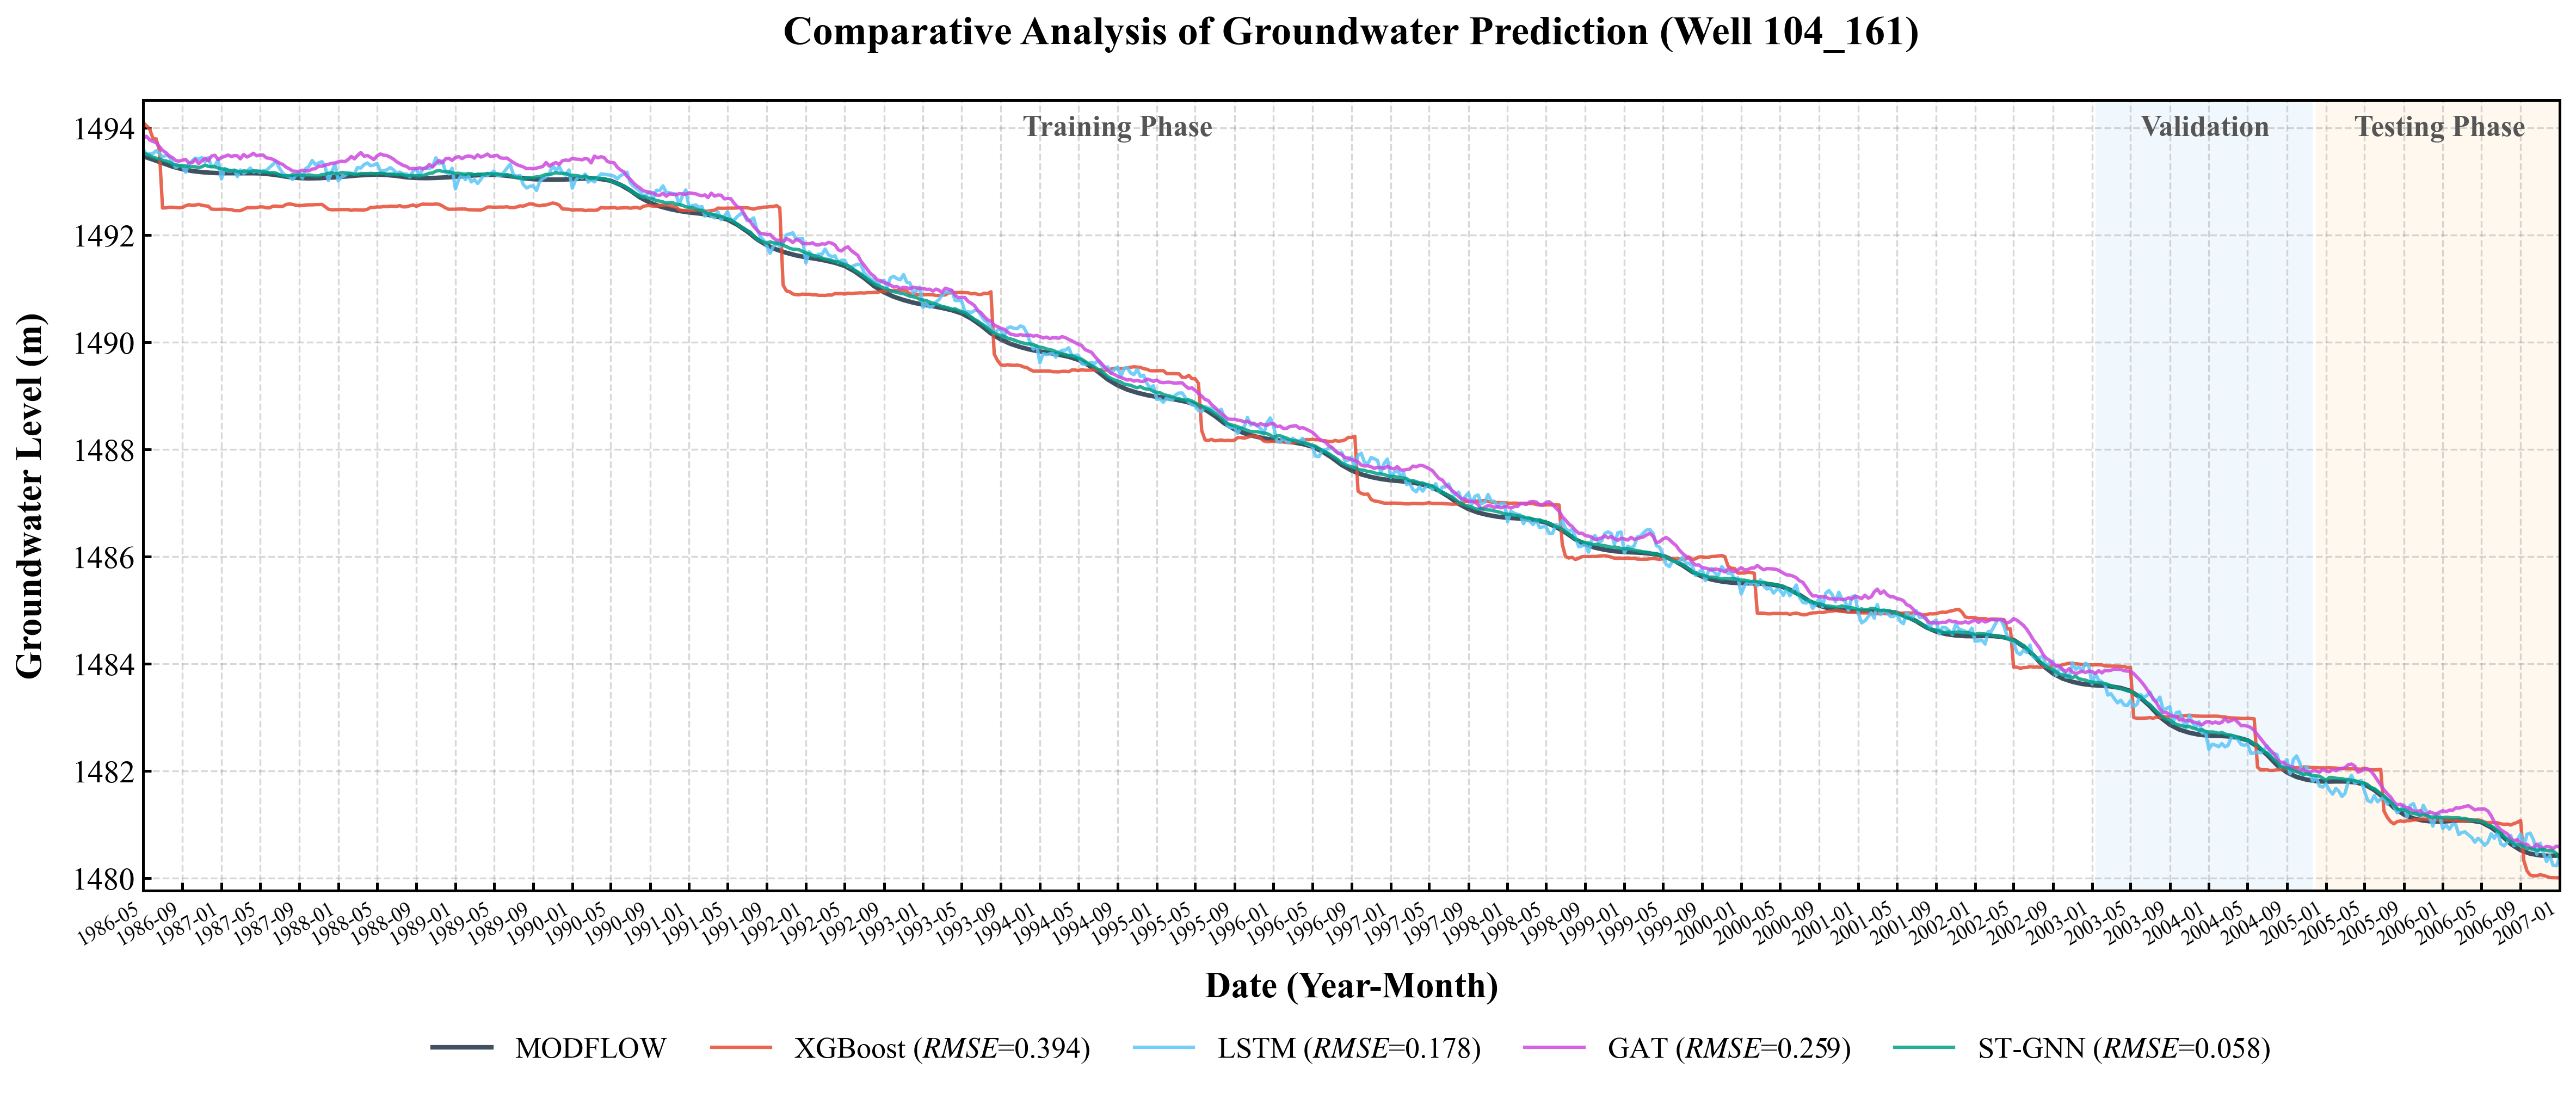

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import os
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ==========================================
# 0. 顶刊绘图风格配置
# ==========================================
config = {
    "font.family": 'serif',
    "font.serif": ['Times New Roman'],
    "font.size": 14,
    "axes.unicode_minus": False,
    "mathtext.fontset": 'stix',
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.direction": 'in',
    "ytick.direction": 'in',
}
plt.rcParams.update(config)

COLOR_OBS = '#2C3E50' 
model_colors_map = {
    'XGBoost': '#E64B35',
    'LSTM':    "#5BC6F7",
    'GAT':     "#CD49DF",
    'ST-GNN':  '#00A087'
}

# ==========================================
# 1. 配置文件列表
# ==========================================
models_config = [
    {'file': 'XGBOOST results_well_104_161_my_model.npz', 'label': 'XGBoost', 'linestyle': '-'},
    {'file': 'lstm results_well_104_161_my_model.npz',    'label': 'LSTM',    'linestyle': '-'},
    {'file': 'GAT results_well_104_161_my_model.npz',     'label': 'GAT',     'linestyle': '-'},
    {'file': '51results_well_104_161_my_model.npz',       'label': 'ST-GNN',  'linestyle': '-'}
]

for item in models_config:
    item['color'] = model_colors_map.get(item['label'], '#000000')

# ==========================================
# 2. 读取基准数据
# ==========================================
base_file = None
for item in models_config:
    if os.path.exists(item['file']):
        base_file = item['file']
        break

if base_file is None:
    print("错误：找不到数据文件！")
    exit()

try:
    print(f"Loading data from: {base_file}")
    base_data = np.load(base_file, allow_pickle=True)
    dates_train, dates_val, dates_test = base_data['train_date'], base_data['val_date'], base_data['test_date']
    all_dates = np.concatenate([dates_train, dates_val, dates_test])
    
    true_train, true_val, true_test = base_data['train_true'], base_data['val_true'], base_data['test_true']
    all_trues = np.concatenate([true_train, true_val, true_test])
    
    coords = base_data['coords']
    idx_train_end = len(dates_train)
    idx_val_end = len(dates_train) + len(dates_val)

except Exception as e:
    print(f"读取失败: {e}")
    exit()

# ==========================================
# 3. 开始绘图
# ==========================================
fig, ax = plt.subplots(figsize=(16, 7), dpi=300)

# --- A. 绘制背景分区 (Shading) ---
y_lims = (np.min(all_trues), np.max(all_trues))
ax.axvspan(all_dates[0], all_dates[idx_train_end-1], facecolor='white', alpha=1.0)
ax.axvspan(all_dates[idx_train_end], all_dates[idx_val_end-1], facecolor='#E3F2FD', alpha=0.5) 
ax.axvspan(all_dates[idx_val_end], all_dates[-1], facecolor='#FFF3E0', alpha=0.5)

# --- B. 绘制真实值 ---
ax.plot(all_dates, all_trues, color=COLOR_OBS, linewidth=2.0, label='MODFLOW', alpha=0.9, zorder=1)

# --- C. 循环绘制模型 ---
metrics_text = []
for model_cfg in models_config:
    if not os.path.exists(model_cfg['file']): continue
    try:
        data = np.load(model_cfg['file'], allow_pickle=True)
        all_preds = np.concatenate([data['train_pred'], data['val_pred'], data['test_pred']])
        
        if len(all_preds) != len(all_trues): continue

        rmse = np.sqrt(mean_squared_error(all_trues, all_preds))
        r2 = r2_score(all_trues, all_preds)
        
        # 标签格式
        label_str = f"{model_cfg['label']} ($RMSE$={rmse:.3f})"
        
        ax.plot(all_dates, all_preds, label=label_str, color=model_cfg['color'], 
                linestyle=model_cfg['linestyle'], linewidth=1.5, alpha=0.85, zorder=2)
        metrics_text.append(f"{model_cfg['label']}: RMSE={rmse:.4f}, R2={r2:.4f}")
    except Exception as e:
        print(f"Error {model_cfg['label']}: {e}")

# --- D. 添加顶部阶段文字 ---
y_range = y_lims[1] - y_lims[0]
text_y_pos = y_lims[1] + 0.02 * y_range
date_train_mid = all_dates[idx_train_end // 2]
date_val_mid = all_dates[idx_train_end + (len(dates_val) // 2)]
date_test_mid = all_dates[idx_val_end + (len(dates_test) // 2)]

ax.text(date_train_mid, text_y_pos, "Training Phase", ha='center', va='bottom', fontsize=13, fontweight='bold', color='#555555')
if len(dates_val) > 0:
    ax.text(date_val_mid, text_y_pos, "Validation", ha='center', va='bottom', fontsize=13, fontweight='bold', color='#555555')
ax.text(date_test_mid, text_y_pos, "Testing Phase", ha='center', va='bottom', fontsize=13, fontweight='bold', color='#555555')

# --- E. 坐标轴与美化 (关键修改) ---
ax.set_ylabel('Groundwater Level (m)', fontsize=16, fontweight='bold', labelpad=10)
ax.set_xlabel('Date (Year-Month)', fontsize=16, fontweight='bold', labelpad=10)
ax.set_title(f'Comparative Analysis of Groundwater Prediction (Well {coords[0]}_{coords[1]})', 
             fontsize=18, fontweight='bold', pad=25)

# 日期格式化与旋转
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4)) # 缩小间隔，展示更多刻度，因为斜着放得下了
# [关键修改] 旋转30度，ha='right' 保证对齐美观
plt.xticks(rotation=30, ha='right', fontsize=9) 

ax.grid(True, which='major', linestyle='--', linewidth=0.8, color='gray', alpha=0.3)
ax.set_ylim(y_lims[0] - 0.05*y_range, y_lims[1] + 0.08*y_range)
ax.set_xlim(all_dates[0], all_dates[-1])

# --- F. 图例优化 (关键修改) ---
# ncol=5 表示强制一行放5个 (1 Obs + 4 Models)
# 稍微把 bbox_to_anchor 的y值调低 (-0.15)，给倾斜的日期留空间
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
          ncol=5, fontsize=13, frameon=False, 
          columnspacing=1.5) 

# --- G. 保存 ---
save_name = f'TopTier_Rotated_Well_{coords[0]}_{coords[1]}.png'
plt.tight_layout()
plt.savefig(save_name, dpi=300, bbox_inches='tight')
plt.savefig(save_name.replace('.png', '.pdf'), dpi=300, bbox_inches='tight')

print(f"图表已保存: {save_name}")
plt.show()


Loading data from: XGBOOST results_well_108_136_my_model.npz
图表已保存: TopTier_Rotated_Well_108_136.png


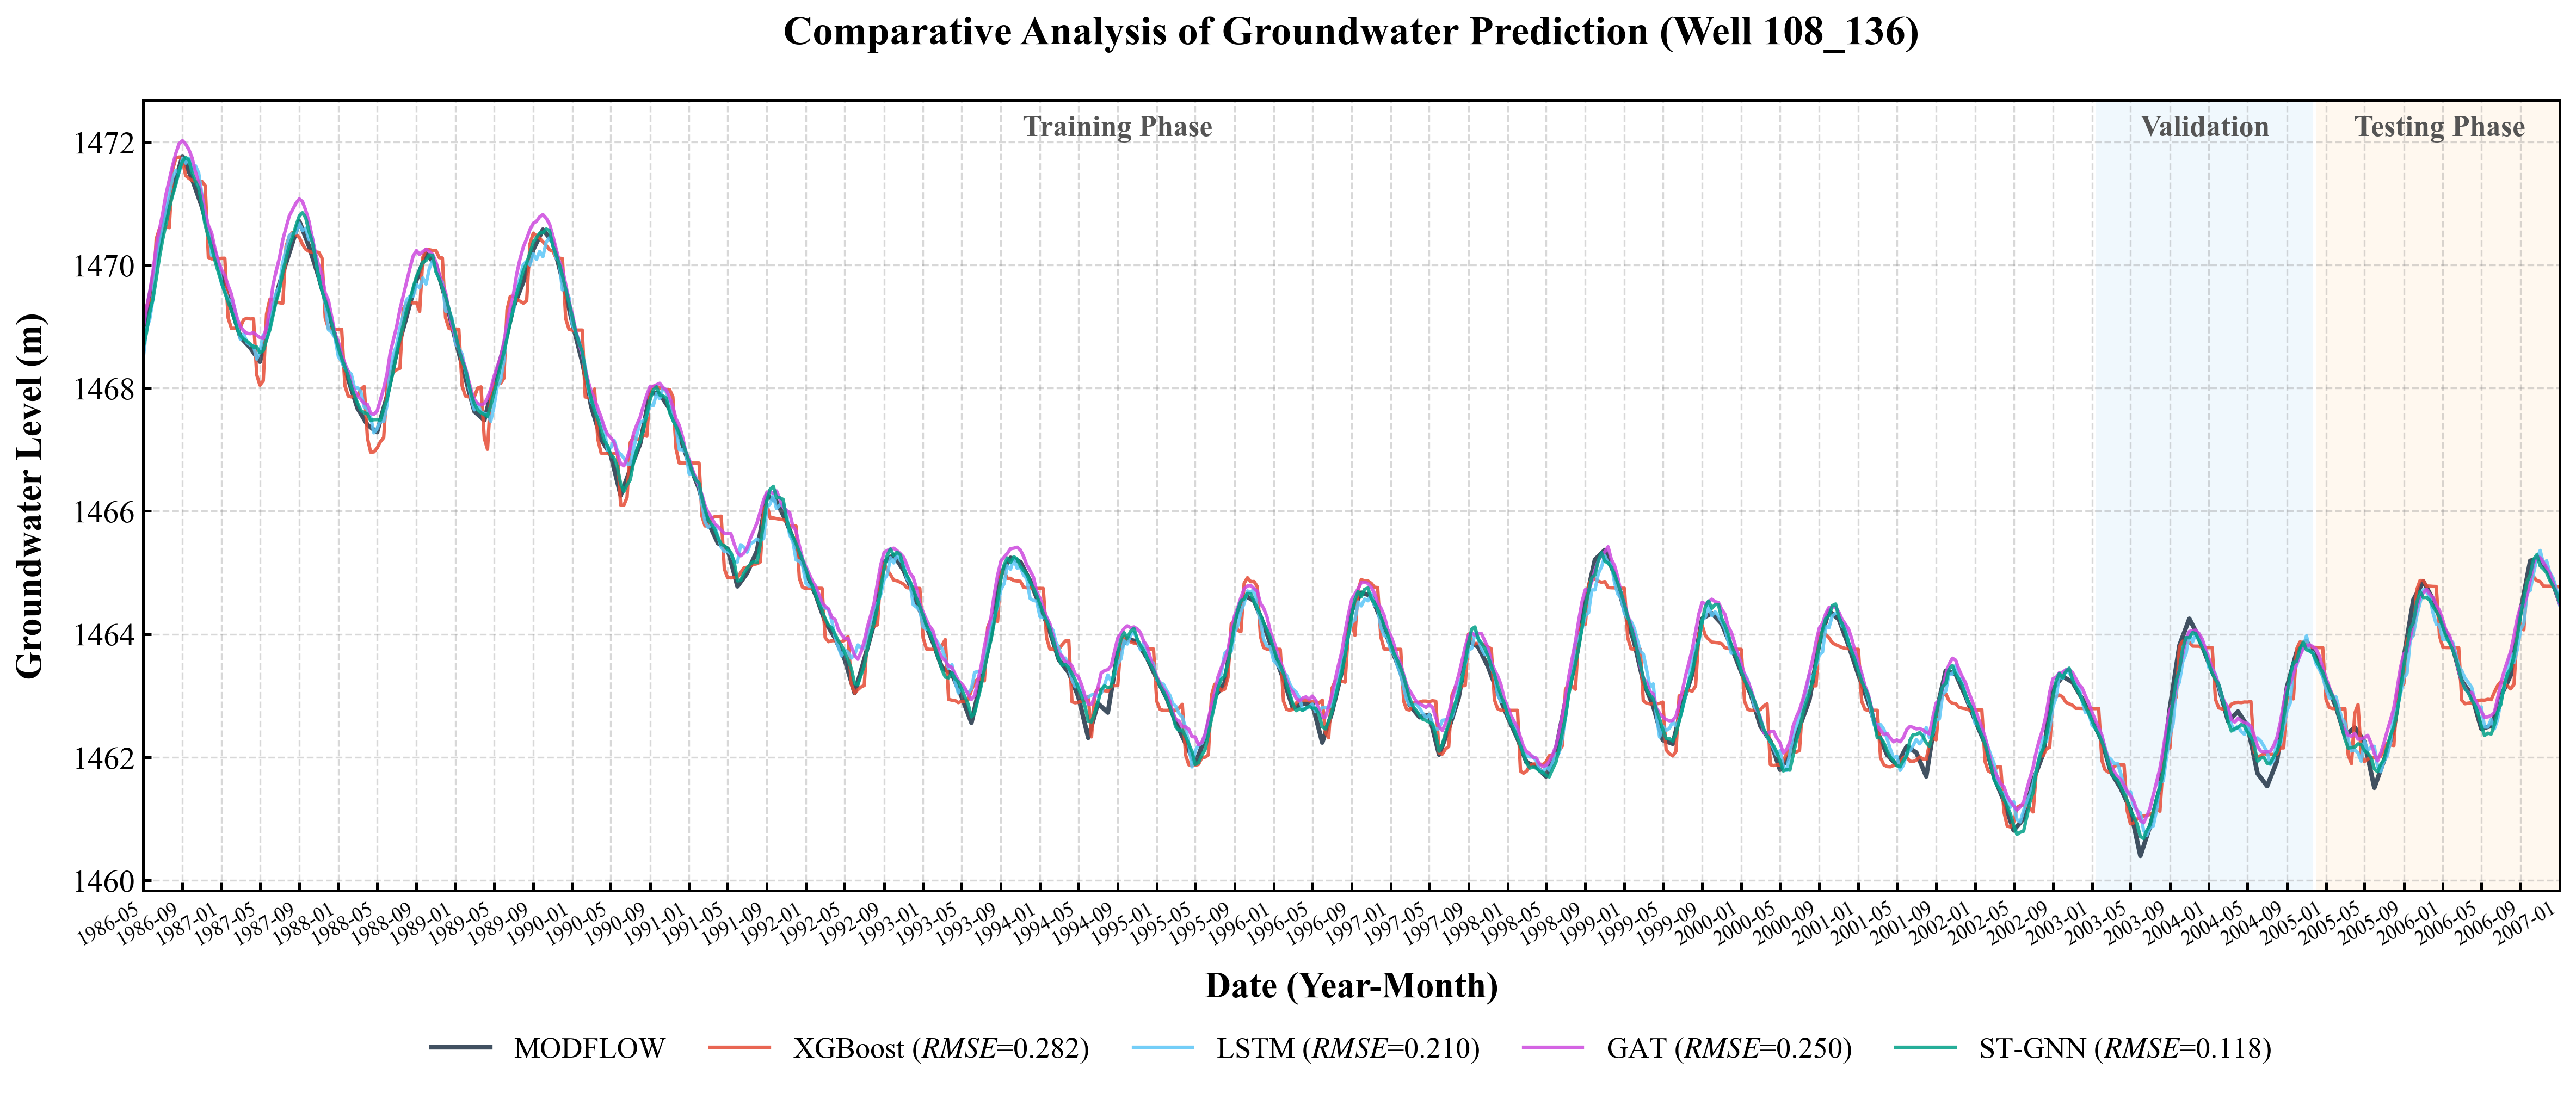

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import os
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ==========================================
# 0. 顶刊绘图风格配置
# ==========================================
config = {
    "font.family": 'serif',
    "font.serif": ['Times New Roman'],
    "font.size": 14,
    "axes.unicode_minus": False,
    "mathtext.fontset": 'stix',
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.direction": 'in',
    "ytick.direction": 'in',
}
plt.rcParams.update(config)

COLOR_OBS = '#2C3E50' 
model_colors_map = {
    'XGBoost': '#E64B35',
    'LSTM':    "#5BC6F7",
    'GAT':     "#CD49DF",
    'ST-GNN':  '#00A087'
}

# ==========================================
# 1. 配置文件列表
# ==========================================
models_config = [
    {'file': 'XGBOOST results_well_108_136_my_model.npz', 'label': 'XGBoost', 'linestyle': '-'},
    {'file': 'lstm results_well_108_136_my_model.npz',    'label': 'LSTM',    'linestyle': '-'},
    {'file': 'GAT results_well_108_136_my_model.npz',     'label': 'GAT',     'linestyle': '-'},
    {'file': '51results_well_108_136_my_model.npz',       'label': 'ST-GNN',  'linestyle': '-'}
]

for item in models_config:
    item['color'] = model_colors_map.get(item['label'], '#000000')

# ==========================================
# 2. 读取基准数据
# ==========================================
base_file = None
for item in models_config:
    if os.path.exists(item['file']):
        base_file = item['file']
        break

if base_file is None:
    print("错误：找不到数据文件！")
    exit()

try:
    print(f"Loading data from: {base_file}")
    base_data = np.load(base_file, allow_pickle=True)
    dates_train, dates_val, dates_test = base_data['train_date'], base_data['val_date'], base_data['test_date']
    all_dates = np.concatenate([dates_train, dates_val, dates_test])
    
    true_train, true_val, true_test = base_data['train_true'], base_data['val_true'], base_data['test_true']
    all_trues = np.concatenate([true_train, true_val, true_test])
    
    coords = base_data['coords']
    idx_train_end = len(dates_train)
    idx_val_end = len(dates_train) + len(dates_val)

except Exception as e:
    print(f"读取失败: {e}")
    exit()

# ==========================================
# 3. 开始绘图
# ==========================================
fig, ax = plt.subplots(figsize=(16, 7), dpi=300)

# --- A. 绘制背景分区 (Shading) ---
y_lims = (np.min(all_trues), np.max(all_trues))
ax.axvspan(all_dates[0], all_dates[idx_train_end-1], facecolor='white', alpha=1.0)
ax.axvspan(all_dates[idx_train_end], all_dates[idx_val_end-1], facecolor='#E3F2FD', alpha=0.5) 
ax.axvspan(all_dates[idx_val_end], all_dates[-1], facecolor='#FFF3E0', alpha=0.5)

# --- B. 绘制真实值 ---
ax.plot(all_dates, all_trues, color=COLOR_OBS, linewidth=2.0, label='MODFLOW', alpha=0.9, zorder=1)

# --- C. 循环绘制模型 ---
metrics_text = []
for model_cfg in models_config:
    if not os.path.exists(model_cfg['file']): continue
    try:
        data = np.load(model_cfg['file'], allow_pickle=True)
        all_preds = np.concatenate([data['train_pred'], data['val_pred'], data['test_pred']])
        
        if len(all_preds) != len(all_trues): continue

        rmse = np.sqrt(mean_squared_error(all_trues, all_preds))
        r2 = r2_score(all_trues, all_preds)
        
        # 标签格式
        label_str = f"{model_cfg['label']} ($RMSE$={rmse:.3f})"
        
        ax.plot(all_dates, all_preds, label=label_str, color=model_cfg['color'], 
                linestyle=model_cfg['linestyle'], linewidth=1.5, alpha=0.85, zorder=2)
        metrics_text.append(f"{model_cfg['label']}: RMSE={rmse:.4f}, R2={r2:.4f}")
    except Exception as e:
        print(f"Error {model_cfg['label']}: {e}")

# --- D. 添加顶部阶段文字 ---
y_range = y_lims[1] - y_lims[0]
text_y_pos = y_lims[1] + 0.02 * y_range
date_train_mid = all_dates[idx_train_end // 2]
date_val_mid = all_dates[idx_train_end + (len(dates_val) // 2)]
date_test_mid = all_dates[idx_val_end + (len(dates_test) // 2)]

ax.text(date_train_mid, text_y_pos, "Training Phase", ha='center', va='bottom', fontsize=13, fontweight='bold', color='#555555')
if len(dates_val) > 0:
    ax.text(date_val_mid, text_y_pos, "Validation", ha='center', va='bottom', fontsize=13, fontweight='bold', color='#555555')
ax.text(date_test_mid, text_y_pos, "Testing Phase", ha='center', va='bottom', fontsize=13, fontweight='bold', color='#555555')

# --- E. 坐标轴与美化 (关键修改) ---
ax.set_ylabel('Groundwater Level (m)', fontsize=16, fontweight='bold', labelpad=10)
ax.set_xlabel('Date (Year-Month)', fontsize=16, fontweight='bold', labelpad=10)
ax.set_title(f'Comparative Analysis of Groundwater Prediction (Well {coords[0]}_{coords[1]})', 
             fontsize=18, fontweight='bold', pad=25)

# 日期格式化与旋转
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4)) # 缩小间隔，展示更多刻度，因为斜着放得下了
# [关键修改] 旋转30度，ha='right' 保证对齐美观
plt.xticks(rotation=30, ha='right', fontsize=9) 

ax.grid(True, which='major', linestyle='--', linewidth=0.8, color='gray', alpha=0.3)
ax.set_ylim(y_lims[0] - 0.05*y_range, y_lims[1] + 0.08*y_range)
ax.set_xlim(all_dates[0], all_dates[-1])

# --- F. 图例优化 (关键修改) ---
# ncol=5 表示强制一行放5个 (1 Obs + 4 Models)
# 稍微把 bbox_to_anchor 的y值调低 (-0.15)，给倾斜的日期留空间
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
          ncol=5, fontsize=13, frameon=False, 
          columnspacing=1.5) 

# --- G. 保存 ---
save_name = f'TopTier_Rotated_Well_{coords[0]}_{coords[1]}.png'
plt.tight_layout()
plt.savefig(save_name, dpi=300, bbox_inches='tight')
plt.savefig(save_name.replace('.png', '.pdf'), dpi=300, bbox_inches='tight')

print(f"图表已保存: {save_name}")
plt.show()


Loading data from: XGBOOST results_well_118_135_my_model.npz
图表已保存: TopTier_Rotated_Well_118_135.png


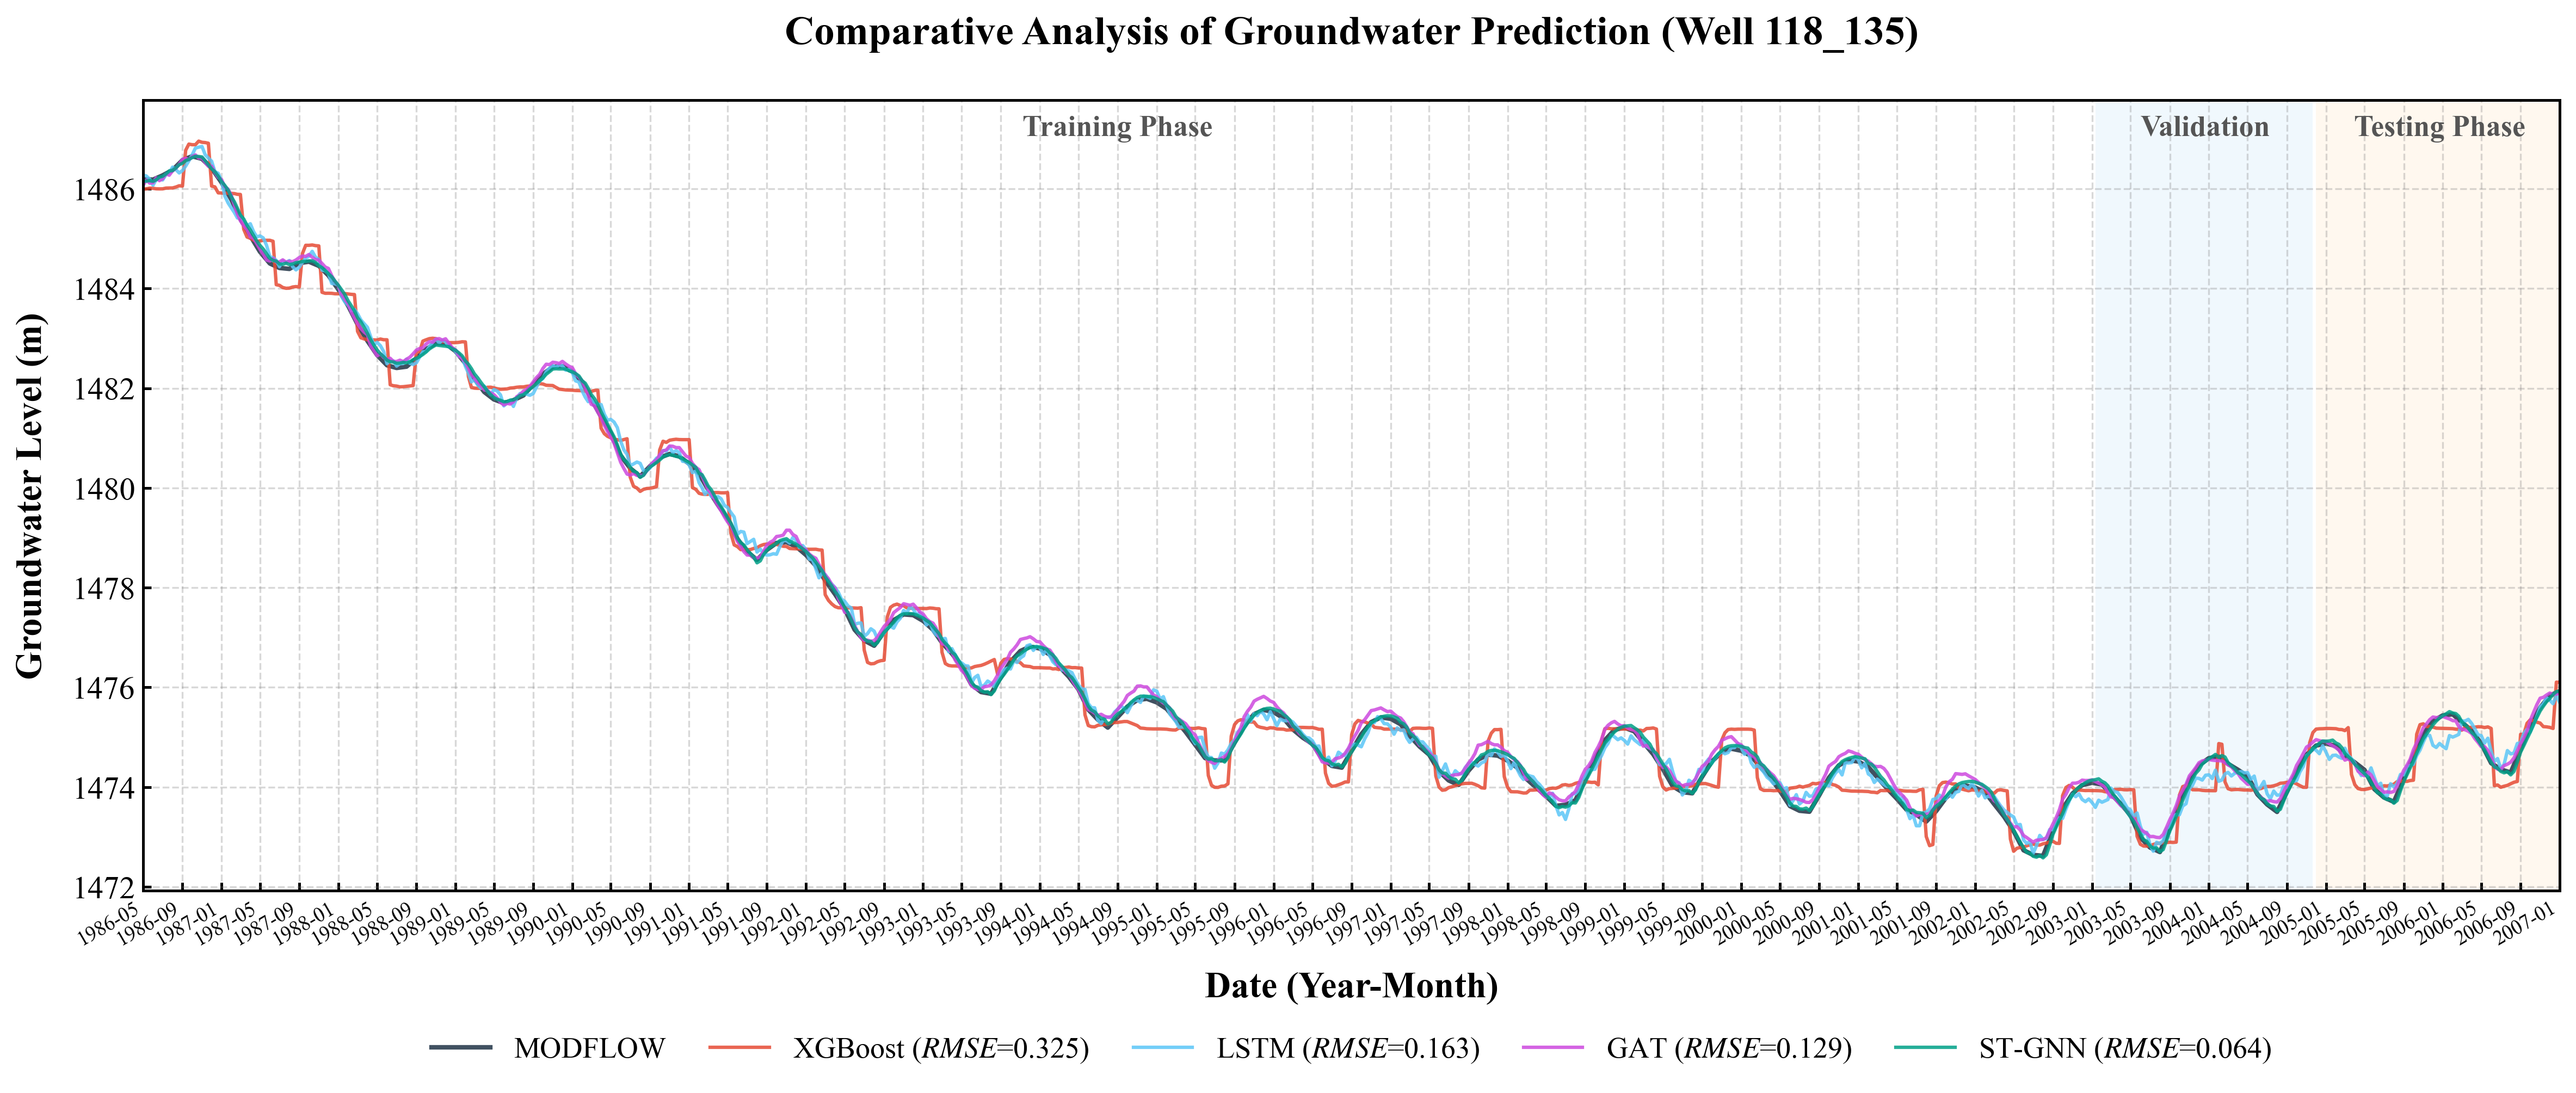

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import os
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ==========================================
# 0. 顶刊绘图风格配置
# ==========================================
config = {
    "font.family": 'serif',
    "font.serif": ['Times New Roman'],
    "font.size": 14,
    "axes.unicode_minus": False,
    "mathtext.fontset": 'stix',
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.direction": 'in',
    "ytick.direction": 'in',
}
plt.rcParams.update(config)

COLOR_OBS = '#2C3E50' 
model_colors_map = {
    'XGBoost': '#E64B35',
    'LSTM':    "#5BC6F7",
    'GAT':     "#CD49DF",
    'ST-GNN':  '#00A087'
}

# ==========================================
# 1. 配置文件列表
# ==========================================
models_config = [
    {'file': 'XGBOOST results_well_118_135_my_model.npz', 'label': 'XGBoost', 'linestyle': '-'},
    {'file': 'lstm results_well_118_135_my_model.npz',    'label': 'LSTM',    'linestyle': '-'},
    {'file': 'GAT results_well_118_135_my_model.npz',     'label': 'GAT',     'linestyle': '-'},
    {'file': '51results_well_118_135_my_model.npz',       'label': 'ST-GNN',  'linestyle': '-'}
]

for item in models_config:
    item['color'] = model_colors_map.get(item['label'], '#000000')

# ==========================================
# 2. 读取基准数据
# ==========================================
base_file = None
for item in models_config:
    if os.path.exists(item['file']):
        base_file = item['file']
        break

if base_file is None:
    print("错误：找不到数据文件！")
    exit()

try:
    print(f"Loading data from: {base_file}")
    base_data = np.load(base_file, allow_pickle=True)
    dates_train, dates_val, dates_test = base_data['train_date'], base_data['val_date'], base_data['test_date']
    all_dates = np.concatenate([dates_train, dates_val, dates_test])
    
    true_train, true_val, true_test = base_data['train_true'], base_data['val_true'], base_data['test_true']
    all_trues = np.concatenate([true_train, true_val, true_test])
    
    coords = base_data['coords']
    idx_train_end = len(dates_train)
    idx_val_end = len(dates_train) + len(dates_val)

except Exception as e:
    print(f"读取失败: {e}")
    exit()

# ==========================================
# 3. 开始绘图
# ==========================================
fig, ax = plt.subplots(figsize=(16, 7), dpi=300)

# --- A. 绘制背景分区 (Shading) ---
y_lims = (np.min(all_trues), np.max(all_trues))
ax.axvspan(all_dates[0], all_dates[idx_train_end-1], facecolor='white', alpha=1.0)
ax.axvspan(all_dates[idx_train_end], all_dates[idx_val_end-1], facecolor='#E3F2FD', alpha=0.5) 
ax.axvspan(all_dates[idx_val_end], all_dates[-1], facecolor='#FFF3E0', alpha=0.5)

# --- B. 绘制真实值 ---
ax.plot(all_dates, all_trues, color=COLOR_OBS, linewidth=2.0, label='MODFLOW', alpha=0.9, zorder=1)

# --- C. 循环绘制模型 ---
metrics_text = []
for model_cfg in models_config:
    if not os.path.exists(model_cfg['file']): continue
    try:
        data = np.load(model_cfg['file'], allow_pickle=True)
        all_preds = np.concatenate([data['train_pred'], data['val_pred'], data['test_pred']])
        
        if len(all_preds) != len(all_trues): continue

        rmse = np.sqrt(mean_squared_error(all_trues, all_preds))
        r2 = r2_score(all_trues, all_preds)
        
        # 标签格式
        label_str = f"{model_cfg['label']} ($RMSE$={rmse:.3f})"
        
        ax.plot(all_dates, all_preds, label=label_str, color=model_cfg['color'], 
                linestyle=model_cfg['linestyle'], linewidth=1.5, alpha=0.85, zorder=2)
        metrics_text.append(f"{model_cfg['label']}: RMSE={rmse:.4f}, R2={r2:.4f}")
    except Exception as e:
        print(f"Error {model_cfg['label']}: {e}")

# --- D. 添加顶部阶段文字 ---
y_range = y_lims[1] - y_lims[0]
text_y_pos = y_lims[1] + 0.02 * y_range
date_train_mid = all_dates[idx_train_end // 2]
date_val_mid = all_dates[idx_train_end + (len(dates_val) // 2)]
date_test_mid = all_dates[idx_val_end + (len(dates_test) // 2)]

ax.text(date_train_mid, text_y_pos, "Training Phase", ha='center', va='bottom', fontsize=13, fontweight='bold', color='#555555')
if len(dates_val) > 0:
    ax.text(date_val_mid, text_y_pos, "Validation", ha='center', va='bottom', fontsize=13, fontweight='bold', color='#555555')
ax.text(date_test_mid, text_y_pos, "Testing Phase", ha='center', va='bottom', fontsize=13, fontweight='bold', color='#555555')

# --- E. 坐标轴与美化 (关键修改) ---
ax.set_ylabel('Groundwater Level (m)', fontsize=16, fontweight='bold', labelpad=10)
ax.set_xlabel('Date (Year-Month)', fontsize=16, fontweight='bold', labelpad=10)
ax.set_title(f'Comparative Analysis of Groundwater Prediction (Well {coords[0]}_{coords[1]})', 
             fontsize=18, fontweight='bold', pad=25)

# 日期格式化与旋转
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4)) # 缩小间隔，展示更多刻度，因为斜着放得下了
# [关键修改] 旋转30度，ha='right' 保证对齐美观
plt.xticks(rotation=30, ha='right', fontsize=9) 

ax.grid(True, which='major', linestyle='--', linewidth=0.8, color='gray', alpha=0.3)
ax.set_ylim(y_lims[0] - 0.05*y_range, y_lims[1] + 0.08*y_range)
ax.set_xlim(all_dates[0], all_dates[-1])

# --- F. 图例优化 (关键修改) ---
# ncol=5 表示强制一行放5个 (1 Obs + 4 Models)
# 稍微把 bbox_to_anchor 的y值调低 (-0.15)，给倾斜的日期留空间
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
          ncol=5, fontsize=13, frameon=False, 
          columnspacing=1.5) 

# --- G. 保存 ---
save_name = f'TopTier_Rotated_Well_{coords[0]}_{coords[1]}.png'
plt.tight_layout()
plt.savefig(save_name, dpi=300, bbox_inches='tight')
plt.savefig(save_name.replace('.png', '.pdf'), dpi=300, bbox_inches='tight')

print(f"图表已保存: {save_name}")
plt.show()


Loading base data from: XGBOOST results_well_118_135_my_model.npz
放大版风格化图表已保存: TopTier_Zoomed_Well_118_135.png


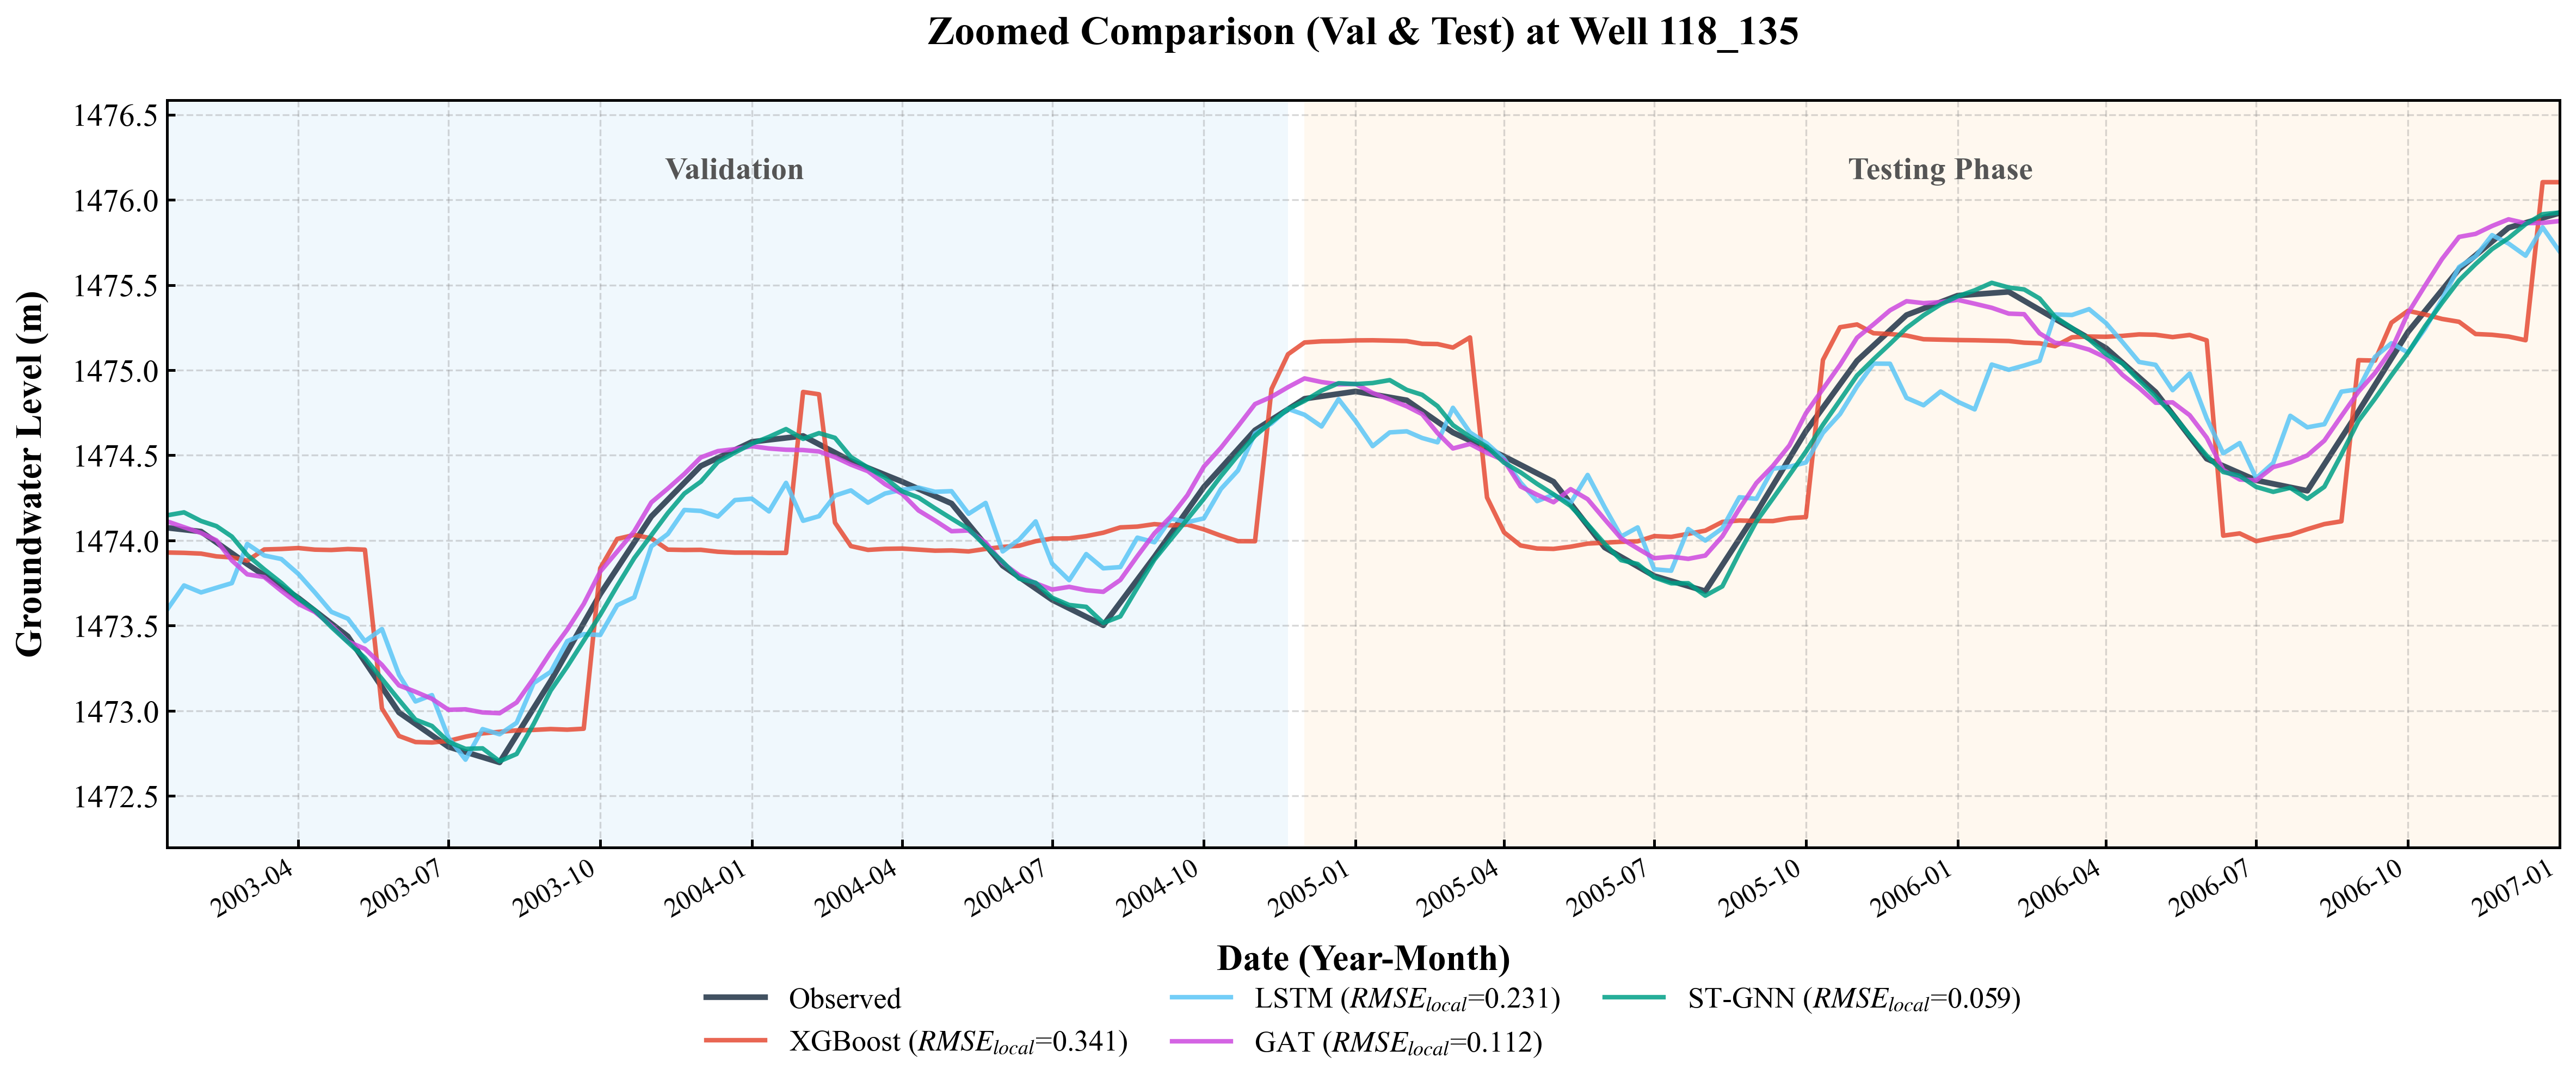

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import os
from sklearn.metrics import mean_squared_error

# ==========================================
# 0. 顶刊绘图风格配置 (与主图保持一致)
# ==========================================
config = {
    "font.family": 'serif',
    "font.serif": ['Times New Roman'],
    "font.size": 14,
    "axes.unicode_minus": False,
    "mathtext.fontset": 'stix',
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.direction": 'in',
    "ytick.direction": 'in',
}
plt.rcParams.update(config)

# 定义统一的颜色映射
COLOR_OBS = '#2C3E50' 
model_colors_map = {
    'XGBoost': '#E64B35',
    'LSTM':    "#5BC6F7",
    'GAT':     "#CD49DF",
    'ST-GNN':  '#00A087'
}

# ==========================================
# 1. 配置文件列表
# ==========================================
models_config = [
    {'file': 'XGBOOST results_well_118_135_my_model.npz', 'label': 'XGBoost', 'linestyle': '-'},
    {'file': 'lstm results_well_118_135_my_model.npz',    'label': 'LSTM',    'linestyle': '-'},
    {'file': 'GAT results_well_118_135_my_model.npz',     'label': 'GAT',     'linestyle': '-'},
    {'file': '51results_well_118_135_my_model.npz',       'label': 'ST-GNN',  'linestyle': '-'}
]

# 自动分配颜色
for item in models_config:
    item['color'] = model_colors_map.get(item['label'], '#000000')

# ==========================================
# 2. 读取基准数据 (日期和真实值)
# ==========================================
base_file = None
for item in models_config:
    if os.path.exists(item['file']):
        base_file = item['file']
        break

if base_file is None:
    print("错误：找不到任何配置文件中的数据文件！")
    exit()

try:
    print(f"Loading base data from: {base_file}")
    base_data = np.load(base_file, allow_pickle=True)
    
    dates_train = base_data['train_date']
    dates_val = base_data['val_date']
    dates_test = base_data['test_date']
    all_dates = np.concatenate([dates_train, dates_val, dates_test])
    
    true_train = base_data['train_true']
    true_val = base_data['val_true']
    true_test = base_data['test_true']
    all_trues = np.concatenate([true_train, true_val, true_test])
    
    # 记录分割点索引用于背景绘制
    idx_train_end = len(dates_train)
    idx_val_end = len(dates_train) + len(dates_val)
    
    coords = base_data['coords']
    
except Exception as e:
    print(f"读取基准文件失败: {e}")
    exit()

# ==========================================
# 3. 开始绘图
# ==========================================
# 使用 subplots 以便更好地控制图层
fig, ax = plt.subplots(figsize=(16, 7), dpi=300)

# --- A. 绘制背景分区 (Shading) ---
# 即使是放大图，加上背景色也能帮助区分阶段
# 验证集区域 (浅蓝)
if len(dates_val) > 0:
    ax.axvspan(all_dates[idx_train_end], all_dates[idx_val_end-1], 
               facecolor='#E3F2FD', alpha=0.5, label='_nolegend_')
# 测试集区域 (浅橙)
if len(dates_test) > 0:
    ax.axvspan(all_dates[idx_val_end], all_dates[-1], 
               facecolor='#FFF3E0', alpha=0.5, label='_nolegend_')

# --- B. 绘制真实值 ---
ax.plot(all_dates, all_trues, color=COLOR_OBS, linewidth=2.5, label='Observed', alpha=0.9, zorder=1)

# --- C. 循环绘制各个模型 (计算局部 RMSE) ---
for model_cfg in models_config:
    file_path = model_cfg['file']
    if not os.path.exists(file_path): continue
        
    try:
        data = np.load(file_path, allow_pickle=True)
        pred_train = data['train_pred']
        pred_val = data['val_pred']
        pred_test = data['test_pred']
        all_preds = np.concatenate([pred_train, pred_val, pred_test])
        
        if len(all_preds) != len(all_trues): continue

        # [关键逻辑] 只计算 验证集+测试集 的 RMSE
        # 对应放大区域的误差
        start_idx = idx_train_end # 跳过训练集
        val_test_true = all_trues[start_idx:]
        val_test_pred = all_preds[start_idx:]
        
        rmse = np.sqrt(mean_squared_error(val_test_true, val_test_pred))
        
        # 标签带上局部 RMSE
        label_str = f"{model_cfg['label']} ($RMSE_{{local}}$={rmse:.3f})"

        ax.plot(all_dates, all_preds, 
                label=label_str, 
                color=model_cfg['color'], 
                linestyle=model_cfg['linestyle'],
                linewidth=2,
                alpha=0.85,
                zorder=2)
                 
    except Exception as e:
        print(f"Error {model_cfg['label']}: {e}")

# --- D. 添加阶段文字标注 (可选) ---
# 计算Y轴位置以便放置文字
# 我们需要先确定放大后的Y轴范围，这里先简单估算一下局部数据的极值
local_y_min = np.min(all_trues[idx_train_end:])
local_y_max = np.max(all_trues[idx_train_end:])
text_y_pos = local_y_max + 0.05 * (local_y_max - local_y_min)

# 验证集文字
if len(dates_val) > 0:
    date_val_mid = all_dates[idx_train_end + (len(dates_val) // 2)]
    ax.text(date_val_mid, text_y_pos, "Validation", 
            ha='center', va='bottom', fontsize=14, fontweight='bold', color='#555555')

# 测试集文字
if len(dates_test) > 0:
    date_test_mid = all_dates[idx_val_end + (len(dates_test) // 2)]
    ax.text(date_test_mid, text_y_pos, "Testing Phase", 
            ha='center', va='bottom', fontsize=14, fontweight='bold', color='#555555')

# --- E. 坐标轴设置与放大 ---
ax.set_title(f'Zoomed Comparison (Val & Test) at Well {coords[0]}_{coords[1]}', 
             fontsize=18, fontweight='bold', pad=25)
ax.set_ylabel('Groundwater Level (m)', fontsize=16, fontweight='bold', labelpad=10)
ax.set_xlabel('Date (Year-Month)', fontsize=16, fontweight='bold', labelpad=10)

# [关键步骤] 设置 X 轴范围实现放大 (Validation Start -> Test End)
if len(dates_val) > 0:
    # 从验证集开始前一点点
    start_date = dates_val[0]
    end_date = dates_test[-1]
    ax.set_xlim(start_date, end_date)
    
    # 自动调整Y轴以适应视图
    ax.set_ylim(local_y_min - 0.5, text_y_pos + 0.5)

# 日期格式化
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3)) # 放大后刻度可以密一点
plt.xticks(rotation=30, ha='right', fontsize=12)

ax.grid(True, which='major', linestyle='--', linewidth=0.8, color='gray', alpha=0.3)

# --- F. 图例优化 ---
# 保持与主图一致的底部排列风格
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),
          ncol=3, # 这里的标签比较长，一行放3个可能比较合适，或者5个看宽度
          fontsize=13, frameon=False, 
          columnspacing=1.5)

# --- G. 保存 ---
save_name = f'TopTier_Zoomed_Well_{coords[0]}_{coords[1]}.png'
plt.tight_layout()
plt.savefig(save_name, dpi=300, bbox_inches='tight')
print(f"放大版风格化图表已保存: {save_name}")

plt.show()


正在提取节点 7963 的数据...
提取验证集 (Validation)...
提取测试集 (Test)...
图表已保存至: val_test_seasonal_prediction_106_136.png


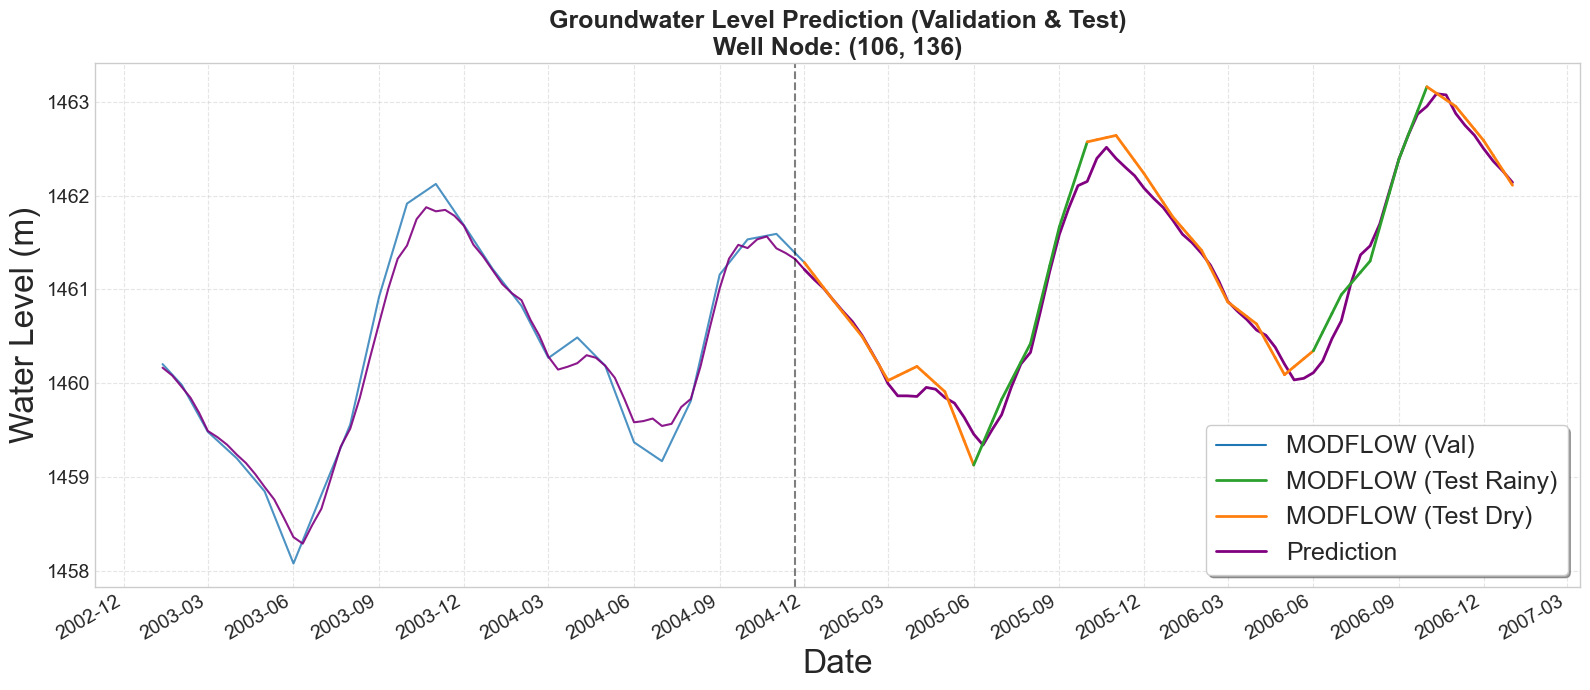


模型性能评估报告 (Node (106, 136))
[Validation Set ] R²: 0.9785 | RMSE: 0.1585 | MAE: 0.1171
--------------------------------------------------
[Test Set (All) ] R²: 0.9830 | RMSE: 0.1398 | MAE: 0.1024
[Test (Rainy)   ] R²: 0.9771 | RMSE: 0.1547 | MAE: 0.1167
[Test (Dry)     ] R²: 0.9850 | RMSE: 0.1324 | MAE: 0.0958

正在保存数据到: my_prediction_data_106_1362.npz ...
保存成功！


In [66]:
# ... (保留上面的 processor, model, train_model_with_physics, classes 等所有定义) ...

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import numpy as np
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# 辅助函数
# ==========================================

def find_node_index(processor, target_row, target_col):
    """根据网格坐标查找节点索引"""
    valid_rows = processor.valid_coords[0]
    valid_cols = processor.valid_coords[1]
    matches = np.where((valid_rows == target_row) & (valid_cols == target_col))[0]
    return matches[0] if len(matches) > 0 else None

def inverse_transform_array(processor, data_array):
    """一维数组反归一化"""
    reshaped = data_array.reshape(-1, 1)
    inversed = processor.target_scaler.inverse_transform(reshaped) 
    return inversed.flatten()

def extract_one_step_prediction(model, dataset, node_idx, processor, device):
    """提取单步预测序列"""
    model.eval()
    preds, trues, dates = [], [], []
    
    with torch.no_grad():
        for data in dataset:
            data = data.to(device)
            # 模型输出 [nodes, forecast_len]
            out = model.predict(data)['output']
            
            # 提取 Step=1 (即 t+1 时刻) 的数据
            pred_val = out[node_idx, 0].item()
            true_val = data.y[node_idx, 0].item()
            
            # 获取对应的时间
            target_time_idx = data.t + 1
            if target_time_idx < len(processor.dates):
                date = processor.dates[target_time_idx]
                preds.append(pred_val)
                trues.append(true_val)
                dates.append(date)
                
    return dates, np.array(preds), np.array(trues)

# ==========================================
# 主绘图与评估代码 (验证集 + 测试集)
# ==========================================

# 1. 设置参数
# 1. 设置参数
target_coords = (106, 136) # 目标井坐标
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

# 确保模型已加载
# model = trained_model 
trained_model=trained_model.to(device)
# 2. 查找节点索引
node_idx = find_node_index(processor, target_coords[0], target_coords[1])

if node_idx is None:
    print(f"坐标 {target_coords} 无效。")
else:
    print(f"正在提取节点 {node_idx} 的数据...")
    
    # --- A. 提取数据 (验证集 + 测试集) ---
    print("提取验证集 (Validation)...")
    dates_val, preds_val_raw, trues_val_raw = extract_one_step_prediction(trained_model, val, node_idx, processor, device)
    
    print("提取测试集 (Test)...")
    dates_test, preds_test_raw, trues_test_raw = extract_one_step_prediction(trained_model, test, node_idx, processor, device)
    
    # --- B. 数据反归一化 ---
    trues_val = inverse_transform_array(processor, trues_val_raw)
    preds_val = inverse_transform_array(processor, preds_val_raw)
    
    trues_test = inverse_transform_array(processor, trues_test_raw)
    preds_test = inverse_transform_array(processor, preds_test_raw)
    
    # 3. 开始绘图
    plt.figure(figsize=(16, 7))
    
    # ================= 1. 绘制验证集 (Validation) =================
    # 实际值：蓝色
    plt.plot(dates_val, trues_val, color='#1f77b4', linewidth=1.5, alpha=0.8, label='Validation Actual')
    # 预测值：紫色
    plt.plot(dates_val, preds_val, color='purple', linewidth=1.5, alpha=0.9, linestyle='-', label='Validation Prediction')

    # ================= 2. 绘制连接桥梁 (Bridge Gap) =================
    # 这一步是让曲线连贯的关键
    if len(dates_val) > 0 and len(dates_test) > 0:
        # 连接实际值 (用验证集的蓝色连接到测试集起点)
        gap_dates = [dates_val[-1], dates_test[0]]
        gap_trues = [trues_val[-1], trues_test[0]]
        plt.plot(gap_dates, gap_trues, color='#1f77b4', linewidth=1.5, alpha=0.8)
        
        # 连接预测值 (用紫色连接)
        gap_preds = [preds_val[-1], preds_test[0]]
        plt.plot(gap_dates, gap_preds, color='purple', linewidth=1.5, linestyle='-') 

    # ================= 3. 绘制测试集 (Test) =================
    # 预测值：统一紫色
    plt.plot(dates_test, preds_test, color='purple', linewidth=2, linestyle='-', label='Test Prediction')
    
    # 实际值：分段变色 (雨季绿/旱季橙)
    rainy_months = [6, 7, 8, 9] # 定义雨季
    
    for i in range(len(dates_test) - 1):
        current_date = dates_test[i]
        current_month = current_date.month
        
        # 确定颜色
        if current_month in rainy_months:
            seg_color = '#2ca02c' # 绿色 (雨季)
        else:
            seg_color = '#ff7f0e' # 橙色 (旱季)
            
        # 绘制微小线段连接 i 到 i+1
        plt.plot(dates_test[i:i+2], trues_test[i:i+2], 
                 color=seg_color, linewidth=2, marker='')

    # --- 4. 添加分割线 ---
    if len(dates_val) > 0:
        # 在验证集和测试集的分界处画竖线
        separator_date = dates_val[-1]
        plt.axvline(separator_date, color='black', linestyle='--', linewidth=1.5, alpha=0.5)

    # --- 5. 图表装饰与自定义图例 ---
    plt.title(f'Groundwater Level Prediction (Validation & Test)\nWell Node: {target_coords}', fontsize=18, fontweight='bold')
    plt.ylabel('Water Level (m)', fontsize=24)
    plt.xlabel('Date', fontsize=24)
    plt.tick_params(axis='both', which='major', labelsize=14)
    
    # 自定义图例 (精准控制显示的颜色和标签)
    legend_elements = [
        # 验证集
        mlines.Line2D([], [], color='#1f77b4', linewidth=1.5, label='MODFLOW (Val)'),
        # 测试集
        mlines.Line2D([], [], color='#2ca02c', linewidth=2, label='MODFLOW (Test Rainy)'),
        mlines.Line2D([], [], color='#ff7f0e', linewidth=2, label='MODFLOW (Test Dry)'),
        # 预测值 (合并展示)
        mlines.Line2D([], [], color='purple', linewidth=2, linestyle='-', label='Prediction')
    ]
    plt.legend(handles=legend_elements, loc='best', fontsize=18, frameon=True, shadow=True)
    
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # 日期格式化
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3)) 
    plt.gcf().autofmt_xdate()
    
    plt.tight_layout()
    save_path = f'val_test_seasonal_prediction_{target_coords[0]}_{target_coords[1]}.png'
    plt.savefig(save_path, dpi=300)
    print(f"图表已保存至: {save_path}")
    plt.show()

    # ==========================================
    # 6. 打印评估指标
    # ==========================================
    def print_metrics(name, y_true, y_pred):
        if len(y_true) < 1: return
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        print(f"[{name:<15}] R²: {r2:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")

    print("\n" + "="*50)
    print(f"模型性能评估报告 (Node {target_coords})")
    print("="*50)
    
    # 1. 验证集整体
    print_metrics("Validation Set", trues_val, preds_val)
    print("-" * 50)
    
    # 2. 测试集整体
    print_metrics("Test Set (All)", trues_test, preds_test)
    
    # 3. 测试集分季节
    test_months = np.array([d.month for d in dates_test])
    test_rainy_mask = np.isin(test_months, rainy_months)
    
    print_metrics("Test (Rainy)", trues_test[test_rainy_mask], preds_test[test_rainy_mask])
    print_metrics("Test (Dry)", trues_test[~test_rainy_mask], preds_test[~test_rainy_mask])
    print("="*50)

    # ==========================================
    # 7. 保存数据为 NPZ 文件 (新增部分)
    # ==========================================
    
    npz_filename = f'my_prediction_data_{target_coords[0]}_{target_coords[1]}2.npz'
    
    # 将日期转换为 numpy datetime64 格式，方便保存和加载
    dates_val_np = np.array(dates_val, dtype='datetime64')
    dates_test_np = np.array(dates_test, dtype='datetime64')
    
    print(f"\n正在保存数据到: {npz_filename} ...")
    np.savez(
        npz_filename,
        # 验证集数据
        dates_val=dates_val_np,
        trues_val=trues_val,
        preds_val=preds_val,
        # 测试集数据
        dates_test=dates_test_np,
        trues_test=trues_test,
        preds_test=preds_test,
        # 元数据
        coords=np.array(target_coords)
    )
    print("保存成功！")

正在提取节点 7961 的数据...
提取验证集 (Validation)...
提取测试集 (Test)...
图表已保存至: val_test_seasonal_prediction_106_134.png


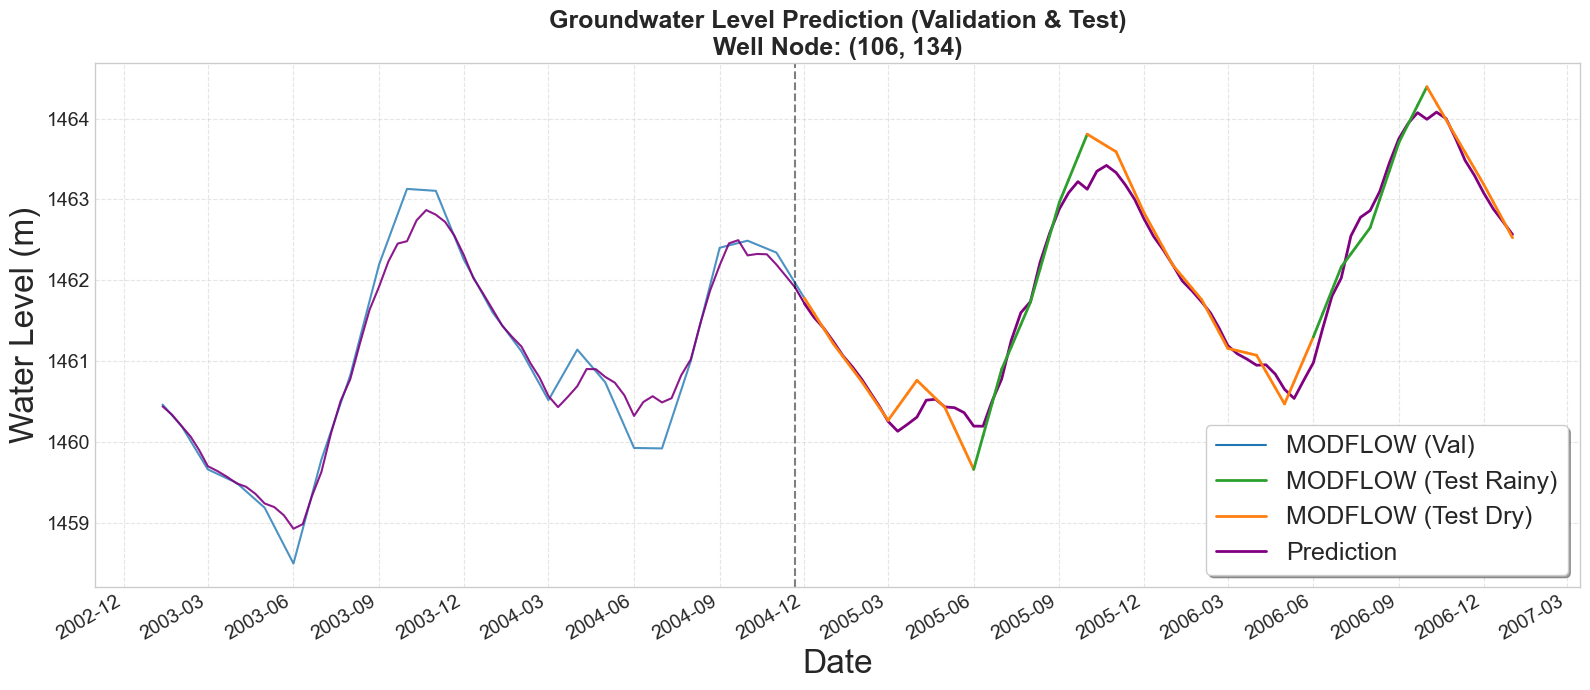


模型性能评估报告 (Node (106, 134))
[Validation Set ] R²: 0.9659 | RMSE: 0.2300 | MAE: 0.1555
--------------------------------------------------
[Test Set (All) ] R²: 0.9767 | RMSE: 0.1915 | MAE: 0.1327
[Test (Rainy)   ] R²: 0.9749 | RMSE: 0.1878 | MAE: 0.1451
[Test (Dry)     ] R²: 0.9769 | RMSE: 0.1931 | MAE: 0.1270

正在保存数据到: my_prediction_data_106_1342.npz ...
保存成功！


In [67]:
# ... (保留上面的 processor, model, train_model_with_physics, classes 等所有定义) ...

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import numpy as np
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# 辅助函数
# ==========================================

def find_node_index(processor, target_row, target_col):
    """根据网格坐标查找节点索引"""
    valid_rows = processor.valid_coords[0]
    valid_cols = processor.valid_coords[1]
    matches = np.where((valid_rows == target_row) & (valid_cols == target_col))[0]
    return matches[0] if len(matches) > 0 else None

def inverse_transform_array(processor, data_array):
    """一维数组反归一化"""
    reshaped = data_array.reshape(-1, 1)
    inversed = processor.target_scaler.inverse_transform(reshaped) 
    return inversed.flatten()

def extract_one_step_prediction(model, dataset, node_idx, processor, device):
    """提取单步预测序列"""
    model.eval()
    preds, trues, dates = [], [], []
    
    with torch.no_grad():
        for data in dataset:
            data = data.to(device)
            # 模型输出 [nodes, forecast_len]
            out = model.predict(data)['output']
            
            # 提取 Step=1 (即 t+1 时刻) 的数据
            pred_val = out[node_idx, 0].item()
            true_val = data.y[node_idx, 0].item()
            
            # 获取对应的时间
            target_time_idx = data.t + 1
            if target_time_idx < len(processor.dates):
                date = processor.dates[target_time_idx]
                preds.append(pred_val)
                trues.append(true_val)
                dates.append(date)
                
    return dates, np.array(preds), np.array(trues)

# ==========================================
# 主绘图与评估代码 (验证集 + 测试集)
# ==========================================

# 1. 设置参数
# 1. 设置参数
target_coords = (106, 134) # 目标井坐标
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

# 确保模型已加载
# model = trained_model 
trained_model=trained_model.to(device)
# 2. 查找节点索引
node_idx = find_node_index(processor, target_coords[0], target_coords[1])

if node_idx is None:
    print(f"坐标 {target_coords} 无效。")
else:
    print(f"正在提取节点 {node_idx} 的数据...")
    
    # --- A. 提取数据 (验证集 + 测试集) ---
    print("提取验证集 (Validation)...")
    dates_val, preds_val_raw, trues_val_raw = extract_one_step_prediction(trained_model, val, node_idx, processor, device)
    
    print("提取测试集 (Test)...")
    dates_test, preds_test_raw, trues_test_raw = extract_one_step_prediction(trained_model, test, node_idx, processor, device)
    
    # --- B. 数据反归一化 ---
    trues_val = inverse_transform_array(processor, trues_val_raw)
    preds_val = inverse_transform_array(processor, preds_val_raw)
    
    trues_test = inverse_transform_array(processor, trues_test_raw)
    preds_test = inverse_transform_array(processor, preds_test_raw)
    
    # 3. 开始绘图
    plt.figure(figsize=(16, 7))
    
    # ================= 1. 绘制验证集 (Validation) =================
    # 实际值：蓝色
    plt.plot(dates_val, trues_val, color='#1f77b4', linewidth=1.5, alpha=0.8, label='Validation Actual')
    # 预测值：紫色
    plt.plot(dates_val, preds_val, color='purple', linewidth=1.5, alpha=0.9, linestyle='-', label='Validation Prediction')

    # ================= 2. 绘制连接桥梁 (Bridge Gap) =================
    # 这一步是让曲线连贯的关键
    if len(dates_val) > 0 and len(dates_test) > 0:
        # 连接实际值 (用验证集的蓝色连接到测试集起点)
        gap_dates = [dates_val[-1], dates_test[0]]
        gap_trues = [trues_val[-1], trues_test[0]]
        plt.plot(gap_dates, gap_trues, color='#1f77b4', linewidth=1.5, alpha=0.8)
        
        # 连接预测值 (用紫色连接)
        gap_preds = [preds_val[-1], preds_test[0]]
        plt.plot(gap_dates, gap_preds, color='purple', linewidth=1.5, linestyle='-') 

    # ================= 3. 绘制测试集 (Test) =================
    # 预测值：统一紫色
    plt.plot(dates_test, preds_test, color='purple', linewidth=2, linestyle='-', label='Test Prediction')
    
    # 实际值：分段变色 (雨季绿/旱季橙)
    rainy_months = [6, 7, 8, 9] # 定义雨季
    
    for i in range(len(dates_test) - 1):
        current_date = dates_test[i]
        current_month = current_date.month
        
        # 确定颜色
        if current_month in rainy_months:
            seg_color = '#2ca02c' # 绿色 (雨季)
        else:
            seg_color = '#ff7f0e' # 橙色 (旱季)
            
        # 绘制微小线段连接 i 到 i+1
        plt.plot(dates_test[i:i+2], trues_test[i:i+2], 
                 color=seg_color, linewidth=2, marker='')

    # --- 4. 添加分割线 ---
    if len(dates_val) > 0:
        # 在验证集和测试集的分界处画竖线
        separator_date = dates_val[-1]
        plt.axvline(separator_date, color='black', linestyle='--', linewidth=1.5, alpha=0.5)

    # --- 5. 图表装饰与自定义图例 ---
    plt.title(f'Groundwater Level Prediction (Validation & Test)\nWell Node: {target_coords}', fontsize=18, fontweight='bold')
    plt.ylabel('Water Level (m)', fontsize=24)
    plt.xlabel('Date', fontsize=24)
    plt.tick_params(axis='both', which='major', labelsize=14)
    
    # 自定义图例 (精准控制显示的颜色和标签)
    legend_elements = [
        # 验证集
        mlines.Line2D([], [], color='#1f77b4', linewidth=1.5, label='MODFLOW (Val)'),
        # 测试集
        mlines.Line2D([], [], color='#2ca02c', linewidth=2, label='MODFLOW (Test Rainy)'),
        mlines.Line2D([], [], color='#ff7f0e', linewidth=2, label='MODFLOW (Test Dry)'),
        # 预测值 (合并展示)
        mlines.Line2D([], [], color='purple', linewidth=2, linestyle='-', label='Prediction')
    ]
    plt.legend(handles=legend_elements, loc='best', fontsize=18, frameon=True, shadow=True)
    
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # 日期格式化
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3)) 
    plt.gcf().autofmt_xdate()
    
    plt.tight_layout()
    save_path = f'val_test_seasonal_prediction_{target_coords[0]}_{target_coords[1]}.png'
    plt.savefig(save_path, dpi=300)
    print(f"图表已保存至: {save_path}")
    plt.show()

    # ==========================================
    # 6. 打印评估指标
    # ==========================================
    def print_metrics(name, y_true, y_pred):
        if len(y_true) < 1: return
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        print(f"[{name:<15}] R²: {r2:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")

    print("\n" + "="*50)
    print(f"模型性能评估报告 (Node {target_coords})")
    print("="*50)
    
    # 1. 验证集整体
    print_metrics("Validation Set", trues_val, preds_val)
    print("-" * 50)
    
    # 2. 测试集整体
    print_metrics("Test Set (All)", trues_test, preds_test)
    
    # 3. 测试集分季节
    test_months = np.array([d.month for d in dates_test])
    test_rainy_mask = np.isin(test_months, rainy_months)
    
    print_metrics("Test (Rainy)", trues_test[test_rainy_mask], preds_test[test_rainy_mask])
    print_metrics("Test (Dry)", trues_test[~test_rainy_mask], preds_test[~test_rainy_mask])
    print("="*50)

    # ==========================================
    # 7. 保存数据为 NPZ 文件 (新增部分)
    # ==========================================
    
    npz_filename = f'my_prediction_data_{target_coords[0]}_{target_coords[1]}2.npz'
    
    # 将日期转换为 numpy datetime64 格式，方便保存和加载
    dates_val_np = np.array(dates_val, dtype='datetime64')
    dates_test_np = np.array(dates_test, dtype='datetime64')
    
    print(f"\n正在保存数据到: {npz_filename} ...")
    np.savez(
        npz_filename,
        # 验证集数据
        dates_val=dates_val_np,
        trues_val=trues_val,
        preds_val=preds_val,
        # 测试集数据
        dates_test=dates_test_np,
        trues_test=trues_test,
        preds_test=preds_test,
        # 元数据
        coords=np.array(target_coords)
    )
    print("保存成功！")

正在提取节点 8066 的数据...
提取验证集 (Validation)...
提取测试集 (Test)...
图表已保存至: val_test_seasonal_prediction_108_136.png


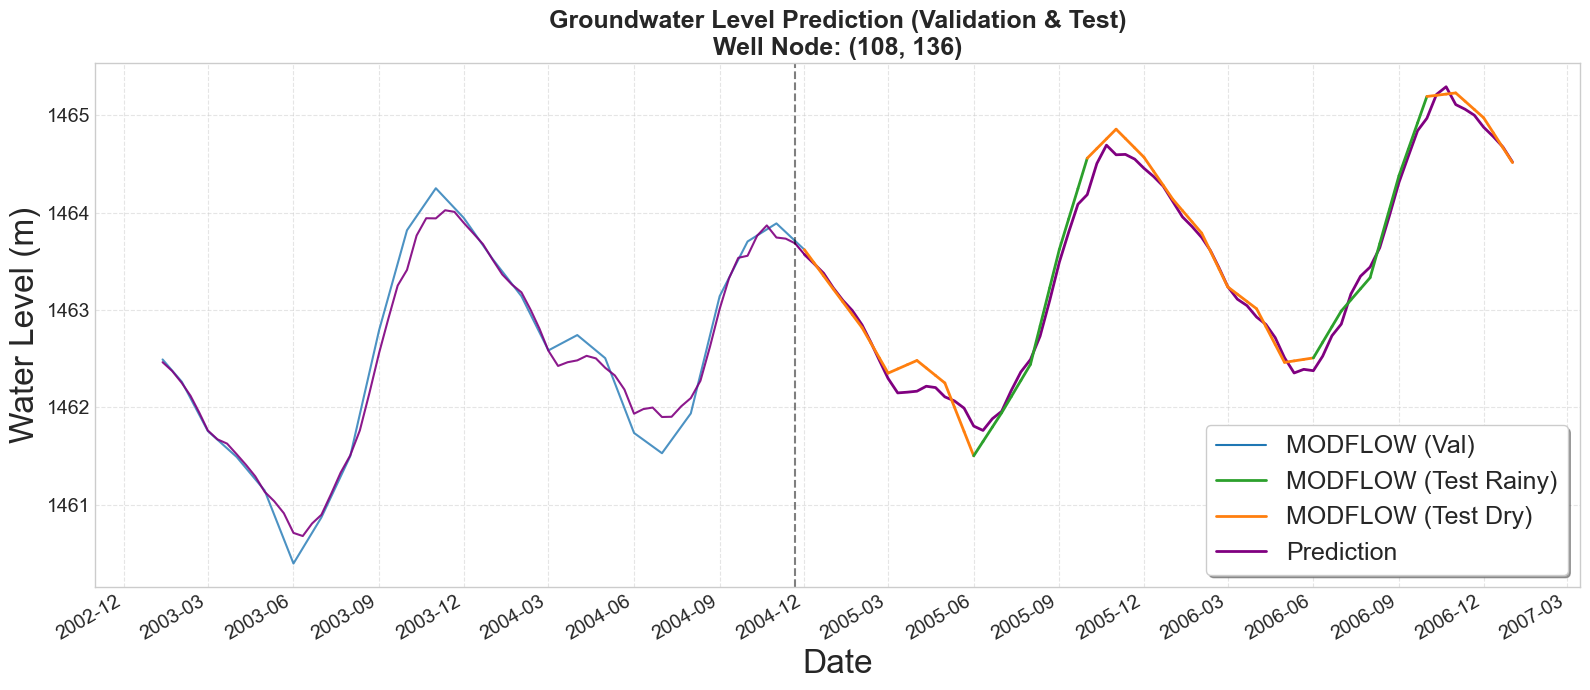


模型性能评估报告 (Node (108, 136))
[Validation Set ] R²: 0.9773 | RMSE: 0.1578 | MAE: 0.1146
--------------------------------------------------
[Test Set (All) ] R²: 0.9860 | RMSE: 0.1234 | MAE: 0.0942
[Test (Rainy)   ] R²: 0.9843 | RMSE: 0.1183 | MAE: 0.1046
[Test (Dry)     ] R²: 0.9855 | RMSE: 0.1257 | MAE: 0.0894

正在保存数据到: my_prediction_data_108_1362.npz ...
保存成功！


In [68]:
# ... (保留上面的 processor, model, train_model_with_physics, classes 等所有定义) ...

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import numpy as np
import torch
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# 辅助函数
# ==========================================

def find_node_index(processor, target_row, target_col):
    """根据网格坐标查找节点索引"""
    valid_rows = processor.valid_coords[0]
    valid_cols = processor.valid_coords[1]
    matches = np.where((valid_rows == target_row) & (valid_cols == target_col))[0]
    return matches[0] if len(matches) > 0 else None

def inverse_transform_array(processor, data_array):
    """一维数组反归一化"""
    reshaped = data_array.reshape(-1, 1)
    inversed = processor.target_scaler.inverse_transform(reshaped) 
    return inversed.flatten()

def extract_one_step_prediction(model, dataset, node_idx, processor, device):
    """提取单步预测序列"""
    model.eval()
    preds, trues, dates = [], [], []
    
    with torch.no_grad():
        for data in dataset:
            data = data.to(device)
            # 模型输出 [nodes, forecast_len]
            out = model.predict(data)['output']
            
            # 提取 Step=1 (即 t+1 时刻) 的数据
            pred_val = out[node_idx, 0].item()
            true_val = data.y[node_idx, 0].item()
            
            # 获取对应的时间
            target_time_idx = data.t + 1
            if target_time_idx < len(processor.dates):
                date = processor.dates[target_time_idx]
                preds.append(pred_val)
                trues.append(true_val)
                dates.append(date)
                
    return dates, np.array(preds), np.array(trues)

# ==========================================
# 主绘图与评估代码 (验证集 + 测试集)
# ==========================================

# 1. 设置参数
# 1. 设置参数
target_coords = (108, 136) # 目标井坐标
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')

# 确保模型已加载
# model = trained_model 
trained_model=trained_model.to(device)
# 2. 查找节点索引
node_idx = find_node_index(processor, target_coords[0], target_coords[1])

if node_idx is None:
    print(f"坐标 {target_coords} 无效。")
else:
    print(f"正在提取节点 {node_idx} 的数据...")
    
    # --- A. 提取数据 (验证集 + 测试集) ---
    print("提取验证集 (Validation)...")
    dates_val, preds_val_raw, trues_val_raw = extract_one_step_prediction(trained_model, val, node_idx, processor, device)
    
    print("提取测试集 (Test)...")
    dates_test, preds_test_raw, trues_test_raw = extract_one_step_prediction(trained_model, test, node_idx, processor, device)
    
    # --- B. 数据反归一化 ---
    trues_val = inverse_transform_array(processor, trues_val_raw)
    preds_val = inverse_transform_array(processor, preds_val_raw)
    
    trues_test = inverse_transform_array(processor, trues_test_raw)
    preds_test = inverse_transform_array(processor, preds_test_raw)
    
    # 3. 开始绘图
    plt.figure(figsize=(16, 7))
    
    # ================= 1. 绘制验证集 (Validation) =================
    # 实际值：蓝色
    plt.plot(dates_val, trues_val, color='#1f77b4', linewidth=1.5, alpha=0.8, label='Validation Actual')
    # 预测值：紫色
    plt.plot(dates_val, preds_val, color='purple', linewidth=1.5, alpha=0.9, linestyle='-', label='Validation Prediction')

    # ================= 2. 绘制连接桥梁 (Bridge Gap) =================
    # 这一步是让曲线连贯的关键
    if len(dates_val) > 0 and len(dates_test) > 0:
        # 连接实际值 (用验证集的蓝色连接到测试集起点)
        gap_dates = [dates_val[-1], dates_test[0]]
        gap_trues = [trues_val[-1], trues_test[0]]
        plt.plot(gap_dates, gap_trues, color='#1f77b4', linewidth=1.5, alpha=0.8)
        
        # 连接预测值 (用紫色连接)
        gap_preds = [preds_val[-1], preds_test[0]]
        plt.plot(gap_dates, gap_preds, color='purple', linewidth=1.5, linestyle='-') 

    # ================= 3. 绘制测试集 (Test) =================
    # 预测值：统一紫色
    plt.plot(dates_test, preds_test, color='purple', linewidth=2, linestyle='-', label='Test Prediction')
    
    # 实际值：分段变色 (雨季绿/旱季橙)
    rainy_months = [6, 7, 8, 9] # 定义雨季
    
    for i in range(len(dates_test) - 1):
        current_date = dates_test[i]
        current_month = current_date.month
        
        # 确定颜色
        if current_month in rainy_months:
            seg_color = '#2ca02c' # 绿色 (雨季)
        else:
            seg_color = '#ff7f0e' # 橙色 (旱季)
            
        # 绘制微小线段连接 i 到 i+1
        plt.plot(dates_test[i:i+2], trues_test[i:i+2], 
                 color=seg_color, linewidth=2, marker='')

    # --- 4. 添加分割线 ---
    if len(dates_val) > 0:
        # 在验证集和测试集的分界处画竖线
        separator_date = dates_val[-1]
        plt.axvline(separator_date, color='black', linestyle='--', linewidth=1.5, alpha=0.5)

    # --- 5. 图表装饰与自定义图例 ---
    plt.title(f'Groundwater Level Prediction (Validation & Test)\nWell Node: {target_coords}', fontsize=18, fontweight='bold')
    plt.ylabel('Water Level (m)', fontsize=24)
    plt.xlabel('Date', fontsize=24)
    plt.tick_params(axis='both', which='major', labelsize=14)
    
    # 自定义图例 (精准控制显示的颜色和标签)
    legend_elements = [
        # 验证集
        mlines.Line2D([], [], color='#1f77b4', linewidth=1.5, label='MODFLOW (Val)'),
        # 测试集
        mlines.Line2D([], [], color='#2ca02c', linewidth=2, label='MODFLOW (Test Rainy)'),
        mlines.Line2D([], [], color='#ff7f0e', linewidth=2, label='MODFLOW (Test Dry)'),
        # 预测值 (合并展示)
        mlines.Line2D([], [], color='purple', linewidth=2, linestyle='-', label='Prediction')
    ]
    plt.legend(handles=legend_elements, loc='best', fontsize=18, frameon=True, shadow=True)
    
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # 日期格式化
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3)) 
    plt.gcf().autofmt_xdate()
    
    plt.tight_layout()
    save_path = f'val_test_seasonal_prediction_{target_coords[0]}_{target_coords[1]}.png'
    plt.savefig(save_path, dpi=300)
    print(f"图表已保存至: {save_path}")
    plt.show()

    # ==========================================
    # 6. 打印评估指标
    # ==========================================
    def print_metrics(name, y_true, y_pred):
        if len(y_true) < 1: return
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        print(f"[{name:<15}] R²: {r2:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")

    print("\n" + "="*50)
    print(f"模型性能评估报告 (Node {target_coords})")
    print("="*50)
    
    # 1. 验证集整体
    print_metrics("Validation Set", trues_val, preds_val)
    print("-" * 50)
    
    # 2. 测试集整体
    print_metrics("Test Set (All)", trues_test, preds_test)
    
    # 3. 测试集分季节
    test_months = np.array([d.month for d in dates_test])
    test_rainy_mask = np.isin(test_months, rainy_months)
    
    print_metrics("Test (Rainy)", trues_test[test_rainy_mask], preds_test[test_rainy_mask])
    print_metrics("Test (Dry)", trues_test[~test_rainy_mask], preds_test[~test_rainy_mask])
    print("="*50)

    # ==========================================
    # 7. 保存数据为 NPZ 文件 (新增部分)
    # ==========================================
    
    npz_filename = f'my_prediction_data_{target_coords[0]}_{target_coords[1]}2.npz'
    
    # 将日期转换为 numpy datetime64 格式，方便保存和加载
    dates_val_np = np.array(dates_val, dtype='datetime64')
    dates_test_np = np.array(dates_test, dtype='datetime64')
    
    print(f"\n正在保存数据到: {npz_filename} ...")
    np.savez(
        npz_filename,
        # 验证集数据
        dates_val=dates_val_np,
        trues_val=trues_val,
        preds_val=preds_val,
        # 测试集数据
        dates_test=dates_test_np,
        trues_test=trues_test,
        preds_test=preds_test,
        # 元数据
        coords=np.array(target_coords)
    )
    print("保存成功！")

扁平化对比图已保存至: model_comparison_flat_trends.png


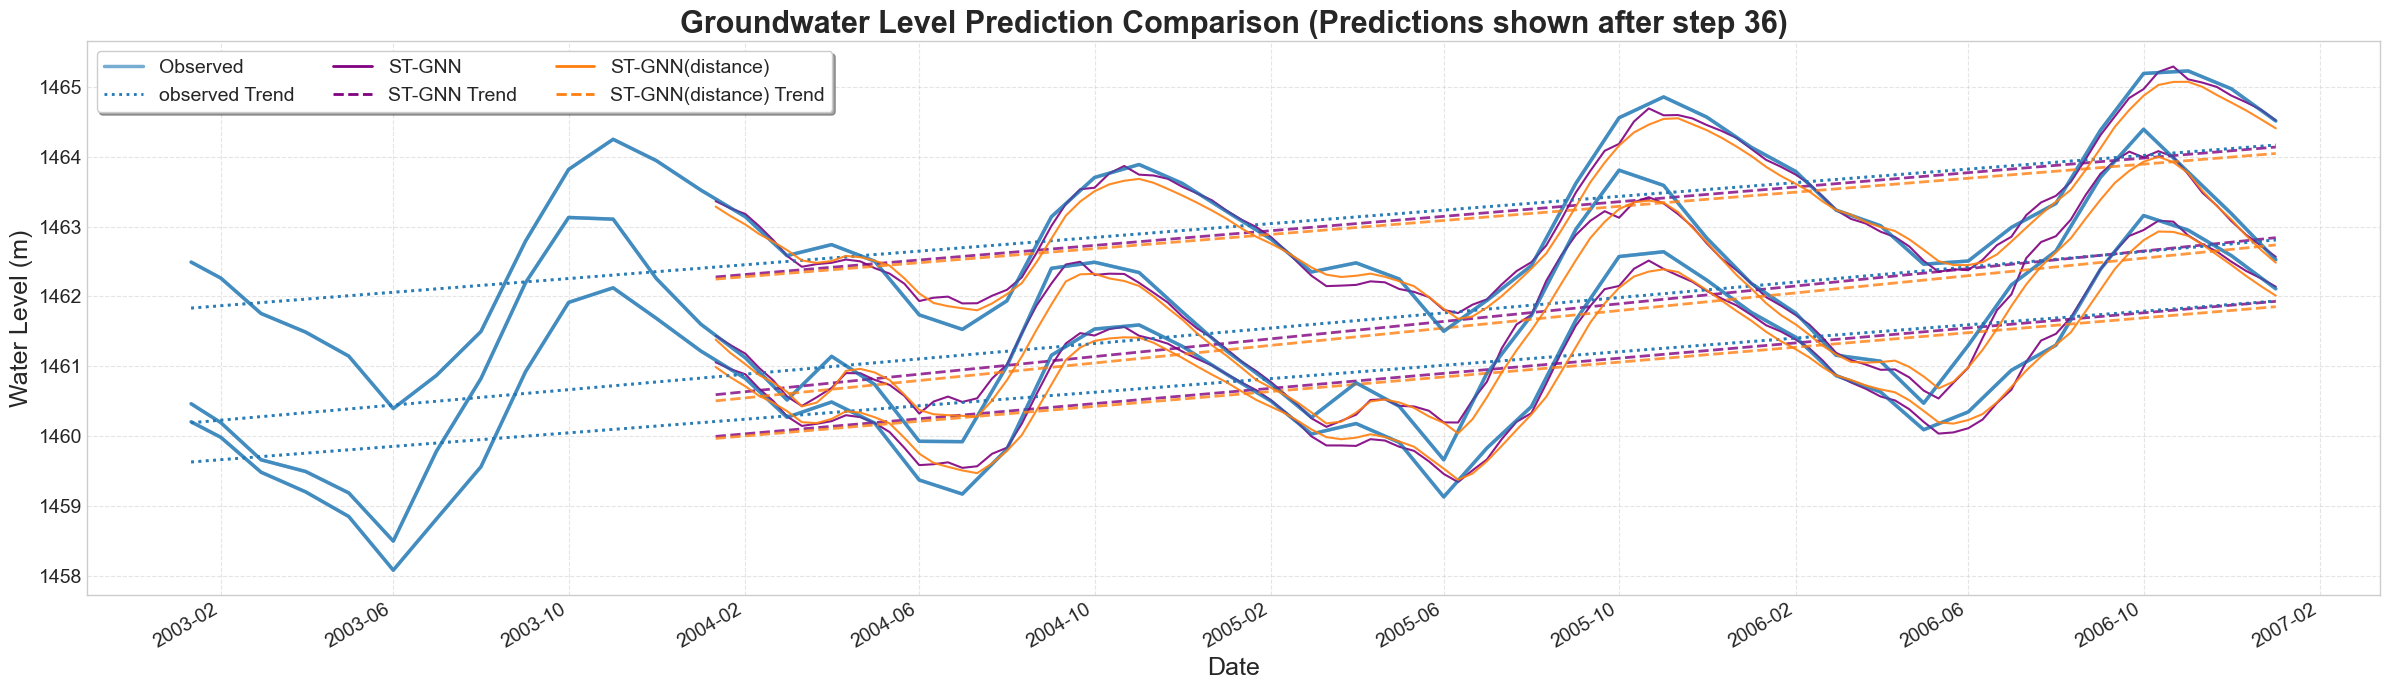

In [71]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import numpy as np
import pandas as pd
import os

# ==========================================
# 1. 配置部分
# ==========================================

# 文件列表
files = [
    'my_prediction_data_106_1362.npz',
    'my_prediction_data_106_1342.npz',
    'my_prediction_data_108_1362.npz',
    'danyiyilai_prediction_data_106_136.npz',
    'danyiyilai_prediction_data_106_134.npz',
    'danyiyilai_prediction_data_108_136.npz'
]

# 颜色配置
COLOR_ACTUAL = '#1f77b4'  # 蓝色
COLOR_MY_MODEL = 'purple' # 紫色
COLOR_DANYI = '#ff7f0e'   # 橙色

# 预测值起始绘制点 (前36个时间步只画真实值)
START_PLOT_IDX = 36 

def parse_filename(filename):
    parts = filename.replace('.npz', '').split('_')
    row, col = parts[-2], parts[-1]
    coords = f"({row}, {col})"
    
    if filename.startswith('my'):
        model_name = "My Model"
        color = COLOR_MY_MODEL
    elif filename.startswith('danyiyilai'):
        model_name = "Danyiyilai"
        color = COLOR_DANYI
    else:
        model_name = "Unknown"
        color = 'gray'
        
    return model_name, coords, color

def get_trend_line(dates, values):
    """计算趋势线"""
    if len(values) < 2: return None, None
    x_nums = mdates.date2num(dates)
    mask = ~np.isnan(values)
    if mask.sum() < 2: return None, None
    
    z = np.polyfit(x_nums[mask], values[mask], 1)
    p = np.poly1d(z)
    trend_values = p(x_nums)
    return dates, trend_values

# ==========================================
# 2. 绘图逻辑
# ==========================================

# 设置更扁平的画布 (宽24, 高7)
plt.figure(figsize=(24, 7))

plotted_actual_coords = set()

for filename in files:
    if not os.path.exists(filename):
        print(f"警告: 文件 {filename} 不存在，跳过。")
        continue
        
    # 加载数据
    data = np.load(filename, allow_pickle=True)
    model_name, coords, line_color = parse_filename(filename)
    
    # 拼接完整时间序列
    dates_full = np.concatenate([data['dates_val'], data['dates_test']])
    dates_full = pd.to_datetime(dates_full)
    
    trues_full = np.concatenate([data['trues_val'], data['trues_test']])
    preds_full = np.concatenate([data['preds_val'], data['preds_test']])
    
    # -------------------------------------------
    # A. 绘制真实值 (Actual) - 全部绘制，蓝色
    # -------------------------------------------
    if coords not in plotted_actual_coords:
        # 绘制实线
        plt.plot(dates_full, trues_full, color=COLOR_ACTUAL, linewidth=2.5, alpha=0.6, 
                 label=f'_nolegend_') # 这里的label不放在循环里，最后统一加图例
        
        # 绘制趋势线 (蓝色点线)
        t_dates, t_values = get_trend_line(dates_full, trues_full)
        if t_dates is not None:
            plt.plot(t_dates, t_values, color=COLOR_ACTUAL, linestyle=':', linewidth=2, alpha=0.8)
            
        plotted_actual_coords.add(coords)

    # -------------------------------------------
    # B. 绘制预测值 (Predictions) - 从第36个时间步开始绘制
    # -------------------------------------------
    if len(dates_full) > START_PLOT_IDX:
        # 切片：只取第36个点及之后的数据
        plot_dates = dates_full[START_PLOT_IDX:]
        plot_preds = preds_full[START_PLOT_IDX:]
        
        # 绘制预测曲线 (实线)
        plt.plot(plot_dates, plot_preds, color=line_color, linewidth=1.5, alpha=0.9,
                 label=f'_nolegend_')
        
        # 绘制预测趋势线 (对应颜色的长虚线)
        # 注意：趋势线也是基于切片后的数据计算的，这样能反映后期的趋势
        t_dates, t_values = get_trend_line(plot_dates, plot_preds)
        if t_dates is not None:
            plt.plot(t_dates, t_values, color=line_color, linestyle='--', linewidth=2, alpha=0.8)

# ==========================================
# 3. 图表美化
# ==========================================

plt.title('Groundwater Level Prediction Comparison (Predictions shown after step 36)', fontsize=22, fontweight='bold')
plt.ylabel('Water Level (m)', fontsize=18)
plt.xlabel('Date', fontsize=18)

# 设置网格
plt.grid(True, linestyle='--', alpha=0.5)

# 日期格式化
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=4)) # 间隔稍微拉大一点，防止扁平图上重叠
plt.gcf().autofmt_xdate()

# 坐标轴字体
plt.tick_params(axis='both', which='major', labelsize=14)

# -------------------------------------------
# 自定义图例 (Legend)
# -------------------------------------------
# 因为有很多条线，我们手动创建一个清晰的图例
legend_elements = [
    # 真实值
    mlines.Line2D([], [], color=COLOR_ACTUAL, linewidth=2.5, alpha=0.6, label='Observed'),
    mlines.Line2D([], [], color=COLOR_ACTUAL, linestyle=':', linewidth=2, label='observed Trend'),
    
    # My Model
    mlines.Line2D([], [], color=COLOR_MY_MODEL, linewidth=2, label='ST-GNN'),
    mlines.Line2D([], [], color=COLOR_MY_MODEL, linestyle='--', linewidth=2, label='ST-GNN Trend'),
    
    # Danyiyilai
    mlines.Line2D([], [], color=COLOR_DANYI, linewidth=2, label='ST-GNN(distance)'),
    mlines.Line2D([], [], color=COLOR_DANYI, linestyle='--', linewidth=2, label='ST-GNN(distance) Trend'),
]

# 图例放在右侧外边，或者上方
plt.legend(handles=legend_elements, loc='upper left', fontsize=14, frameon=True, shadow=True, ncol=3)

# 保存
plt.tight_layout()
save_path = 'model_comparison_flat_trends.png'
plt.savefig(save_path, dpi=300)
print(f"扁平化对比图已保存至: {save_path}")
plt.show()


In [13]:
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from torch_geometric.loader import DataLoader
from tqdm import tqdm
from scipy.stats import spearmanr



# 设置 Matplotlib 样式
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk')

# (您的其他导入和函数定义保持不变)

# (您的其他导入和函数定义保持不变)

def analyze_correlation_with_features(model, test_data, processor, device):
    """
    对模型性能与水文地质特征进行斯皮尔曼相关性分析。

    Args:
        model: 训练好的模型。
        test_data (list): 测试数据集。
        processor (HydroDataProcessor): 数据处理器实例。
        device (str): 'cuda' 或 'cpu'。
    """
    print("--- 开始模型性能与特征的相关性分析 ---")
    model.eval()
    model.to(device)

    # 1. 生成预测和计算误差 (此部分不变)
    # =================================================
    print("步骤 1/4: 生成模型预测并计算误差...")
    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)
    all_preds_seq, all_actuals_seq = [], []
    with torch.no_grad():
        for data in tqdm(test_loader, desc="模型预测"):
            data = data.to(device)
            predictions = model.predict(data)
            all_preds_seq.append(predictions['output'].cpu().numpy())
            all_actuals_seq.append(data.y.cpu().numpy())
    if not all_preds_seq:
        print("错误：未能生成任何预测结果。")
        return
    all_preds_norm = np.vstack(all_preds_seq)
    all_actuals_norm = np.vstack(all_actuals_seq)
    preds_orig = processor.inverse_transform(all_preds_norm.flatten().reshape(-1, 1)).reshape(all_preds_norm.shape)
    actuals_orig = processor.inverse_transform(all_actuals_norm.flatten().reshape(-1, 1)).reshape(all_actuals_norm.shape)
    absolute_errors = np.abs(preds_orig - actuals_orig)
    num_nodes, forecast_horizon = absolute_errors.shape
    print(f"误差矩阵形状: {absolute_errors.shape} (节点数, 预测步长)")

    # 2. 准备特征数据 (此部分已修改)
    # =================================================
    print("步骤 2/4: 对齐静态和动态特征...")

    # --- START: 静态特征对齐修改 ---
    # 我们直接从 test_data 对象中提取静态特征，以保证节点数量和顺序完全一致。
    static_feature_names = ['Elevation', 'Land_Use', 'Slope', 'Aspect', 'Permeability_K']

    # 1. 从 test_data 的每个样本中收集 x_static
    all_static_features_list = [data.x_static.cpu().numpy() for data in test_data]

    # 2. 将它们垂直堆叠成一个大数组
    # 其形状为 [num_nodes, num_static_features]，与误差矩阵的行数完美匹配
    concatenated_static_features = np.vstack(all_static_features_list)

    # 3. 将其分解并对齐到 (num_nodes, forecast_horizon)
    aligned_static_features = {}
    for i, name in enumerate(static_feature_names):
        # 提取第 i 个特征列 (形状: [num_nodes, 1])
        feature_column = concatenated_static_features[:, i:i+1]
        # 沿预测步长维度平铺 (形状: [num_nodes, forecast_horizon])
        aligned_static_features[name] = np.tile(feature_column, (1, forecast_horizon))

    print(f"静态特征已对齐，形状示例: {aligned_static_features['Elevation'].shape}")
    # --- END: 静态特征对齐修改 ---


    # --- 动态特征对齐 (此逻辑保持不变) ---
    dynamic_feature_names = ['Rainfall', 'Temperature', 'Evaporation', 'Pumping', 'Irrigation', 'River_Flow']
    num_dynamic_features = len(dynamic_feature_names)
    aligned_dynamic_features_array = np.zeros((num_nodes, forecast_horizon, num_dynamic_features))

    try:
        dynamic_features_np = np.array(processor.dynamic_features)
    except Exception as e:
        print(f"将 dynamic_features 转换为 NumPy 数组时出错: {e}")
        return

    current_row = 0
    valid_coords = processor.valid_coords
    for data in tqdm(test_data, desc="对齐动态特征"):
        nodes_in_sample = data.num_nodes
        start_t = data.t + 1
        end_t = start_t + forecast_horizon
        raw_dynamic_chunk = dynamic_features_np[:, start_t:end_t]
        valid_dynamic_chunk = raw_dynamic_chunk[:, :, valid_coords[0], valid_coords[1]]
        aligned_chunk = np.transpose(valid_dynamic_chunk, (2, 1, 0))
        aligned_dynamic_features_array[current_row : current_row + nodes_in_sample, :, :] = aligned_chunk
        current_row += nodes_in_sample

    aligned_dynamic_features = {
        name: aligned_dynamic_features_array[:, :, i]
        for i, name in enumerate(dynamic_feature_names)
    }

    # 3. 创建 DataFrame 并计算相关性 (此部分不变)
    # =================================================
    print("步骤 3/4: 计算斯皮尔曼相关性...")
    analysis_data = {'absolute_error': absolute_errors.flatten()}
    for name, feature_matrix in aligned_static_features.items():
        analysis_data[name] = feature_matrix.flatten()
    for name, feature_matrix in aligned_dynamic_features.items():
        analysis_data[name] = feature_matrix.flatten()

    # (代码的其余部分保持不变)
    # ...
    df = pd.DataFrame(analysis_data)
    df.dropna(inplace=True)

    # 打印每个数组的长度进行调试
    print("\n--- DataFrame 各列长度调试信息 ---")
    for key, value in analysis_data.items():
        print(f"列 '{key}': 长度 {len(value)}")
    print("---------------------------------\n")

    correlation_matrix = df.corr(method='spearman')
    error_correlations = correlation_matrix['absolute_error'].drop('absolute_error').sort_values()
    print("\n--- 与绝对误差的斯皮尔曼相关性系数 ---")
    print(error_correlations)

    # 4. 可视化与 5. 解读 (不变)
    # ...



    # 4. 可视化结果
    # =================================================
    print("步骤 4/4: 生成可视化图表...")

    # 图 1: 特征与误差的相关性条形图
    plt.figure(figsize=(12, 10))
    error_correlations.plot(kind='barh', color=np.where(error_correlations > 0, 'crimson', 'royalblue'))
    plt.title('Spearman Correlation between Features and Absolute Prediction Error', fontsize=18)
    plt.xlabel('Spearman Correlation Coefficient', fontsize=14)
    plt.axvline(x=0, color='grey', linestyle='--')
    plt.tight_layout()
    plt.savefig('correlation_with_error.png', dpi=300)
    print("图表 'correlation_with_error.png' 已保存。")

    # 图 2: 所有特征间的相关性热力图
    plt.figure(figsize=(16, 14))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
    plt.title('Full Feature Correlation Matrix (Spearman)', fontsize=20)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig('full_correlation_heatmap.png', dpi=300)
    print("图表 'full_correlation_heatmap.png' 已保存。")

    plt.show()

    # 5. 解读
    # =================================================
    print("\n--- 结果解读 ---")
    print("正相关 (红色条):")
    print("  - 含义: 当该特征值增大时，模型的预测误差也倾向于增大。")
    print("  - 结论: 模型在处理这些特征的高值区域时可能表现不佳或不稳定。")
    print("  - 示例: 如果 'Pumping' 呈强正相关，说明在高强度抽水区域，模型预测的难度更大。")

    print("\n负相关 (蓝色条):")
    print("  - 含义: 当该特征值增大时，模型的预测误差反而倾向于减小。")
    print("  - 结论: 模型在这些特征的高值区域表现更好，或者这些特征代表了某种稳定或易于预测的条件。")
    print("  - 示例: 如果 'Permeability_K' 呈强负相关，可能意味着在高渗透性区域，地下水流动模式更均匀，模型更容易捕捉。")

    print("\n接近零的相关性:")
    print("  - 含义: 该特征值的大小与模型误差之间没有明显的单调关系。")

if __name__ == '__main__':
    # --- 准备工作：加载所需的一切 ---
    
    # 0. 设置设备
    device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
    print(f"使用设备: {device}")

    # 1. 重新实例化数据处理器并加载数据
    #    这是为了访问原始数据，即使您已经保存了处理过的数据集
    print("正在加载数据处理器和原始数据...")
    file_paths = [
        "pre_data_by_time3.xlsx", "tmp_data_by_time3.xlsx", "evt_data3.xlsx",
        "choushui_data3.xlsx", "guangai_data3-.xlsx", "river_data3.xlsx",
        "dixing_data3.xlsx", "tudiliyong_data3.xlsx", "podu_data3.xlsx",
        "poxiang_data3.xlsx", "integrated_k_values.xlsx", "groundwater_heads3.xlsx"
    ]
    #processor = HydroDataProcessor(file_paths)
    #processor.load_data() # 加载原始数据
    #processor.fit_scalers() # 确保反归一化可用

    # 2. 加载测试数据集
    print("正在加载已处理的测试数据集...")
    try:
        test_data = torch.load('./datasets/test_data.pt')
        print(f"成功加载 {len(test_data)} 个测试样本。")
    except FileNotFoundError:
        print("错误: 未找到 'test_data.pt'。请先运行数据预处理和划分脚本。")
        exit()

    # 3. 实例化模型并加载训练好的权重
    print("正在加载训练好的模型...")
    sample_data = test_data[0]
    static_feat_dim = sample_data.x_static.shape[1]
    dynamic_feat_dim = sample_data.x_dynamic_encoder.shape[2]
    time_feat_dim = sample_data.x_time_encoder.shape[2]

    # 提取坐标范围
    all_coords_tensor = torch.cat([data.coords for data in test_data], dim=0)
    coord_min = all_coords_tensor.min(dim=0).values.tolist()
    coord_max = all_coords_tensor.max(dim=0).values.tolist()

    trained_model = PhysicsGuidedGNN(
        static_feat_dim=static_feat_dim,
        dynamic_feat_dim=dynamic_feat_dim,
        time_feat_dim=time_feat_dim,
        hidden_dim=128,
        edge_dim=sample_data.edge_attr.shape[1],
        coord_min=coord_min,
        coord_max=coord_max
    )

    try:
        trained_model.load_state_dict(torch.load('51-NHITS_model.pth', map_location=device))
        print("模型权重加载成功。")
    except FileNotFoundError:
        print("错误: 未找到模型权重文件 'seq2seq_model.pth'。请先完成模型训练。")
        exit()
    
    # --- 运行分析 ---
    #analyze_correlation_with_features(model, test, processor, device)



使用设备: cuda:1
正在加载数据处理器和原始数据...
正在加载已处理的测试数据集...


C:\Users\dell\AppData\Local\Temp\ipykernel_35176\863336742.py:207: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  test_data = torch.load('./datasets/test_data.pt')


成功加载 76 个测试样本。
正在加载训练好的模型...
模型权重加载成功。


C:\Users\dell\AppData\Local\Temp\ipykernel_35176\863336742.py:236: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  trained_model.load_state_dict(torch.load('51-NHITS_model.pth

--- 开始序列到序列模型评估 ---
正在处理 76 个测试序列...


模型预测: 100%|██████████| 76/76 [00:42<00:00,  1.78it/s]



正在聚合和反归一化数据...
总节点-时间步数量: 8107680
预测范围 (Horizon): 12 个时间步

--- 总体性能指标 (所有预测步) ---
  RMSE (均方根误差): 0.1601 m
  MAE (平均绝对误差): 0.0686 m
  R² (决定系数): 1.0000

--- 逐预测步性能分析 ---
  步数 |   RMSE   |   MAE    |    R²
---------------------------------------
  1    |   0.0696 |   0.0331 |   1.0000
  2    |   0.0986 |   0.0383 |   1.0000
  3    |   0.1299 |   0.0465 |   1.0000
  4    |   0.1436 |   0.0552 |   1.0000
  5    |   0.1538 |   0.0622 |   1.0000
  6    |   0.1625 |   0.0696 |   1.0000
  7    |   0.1676 |   0.0726 |   1.0000
  8    |   0.1742 |   0.0787 |   1.0000
  9    |   0.1772 |   0.0823 |   1.0000
  10   |   0.1878 |   0.0891 |   1.0000
  11   |   0.2016 |   0.0974 |   1.0000
  12   |   0.2001 |   0.0988 |   1.0000

正在生成可视化图表...


C:\Users\dell\AppData\Local\Temp\ipykernel_31508\246235336.py:228: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
C:\Users\dell\AppData\Local\Temp\ipykernel_31508\246235336.py:229: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('seq2seq_evaluation_results_with_decomposition.png', dpi=300)
c:\Users\dell\.conda\envs\nyxpytorch\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


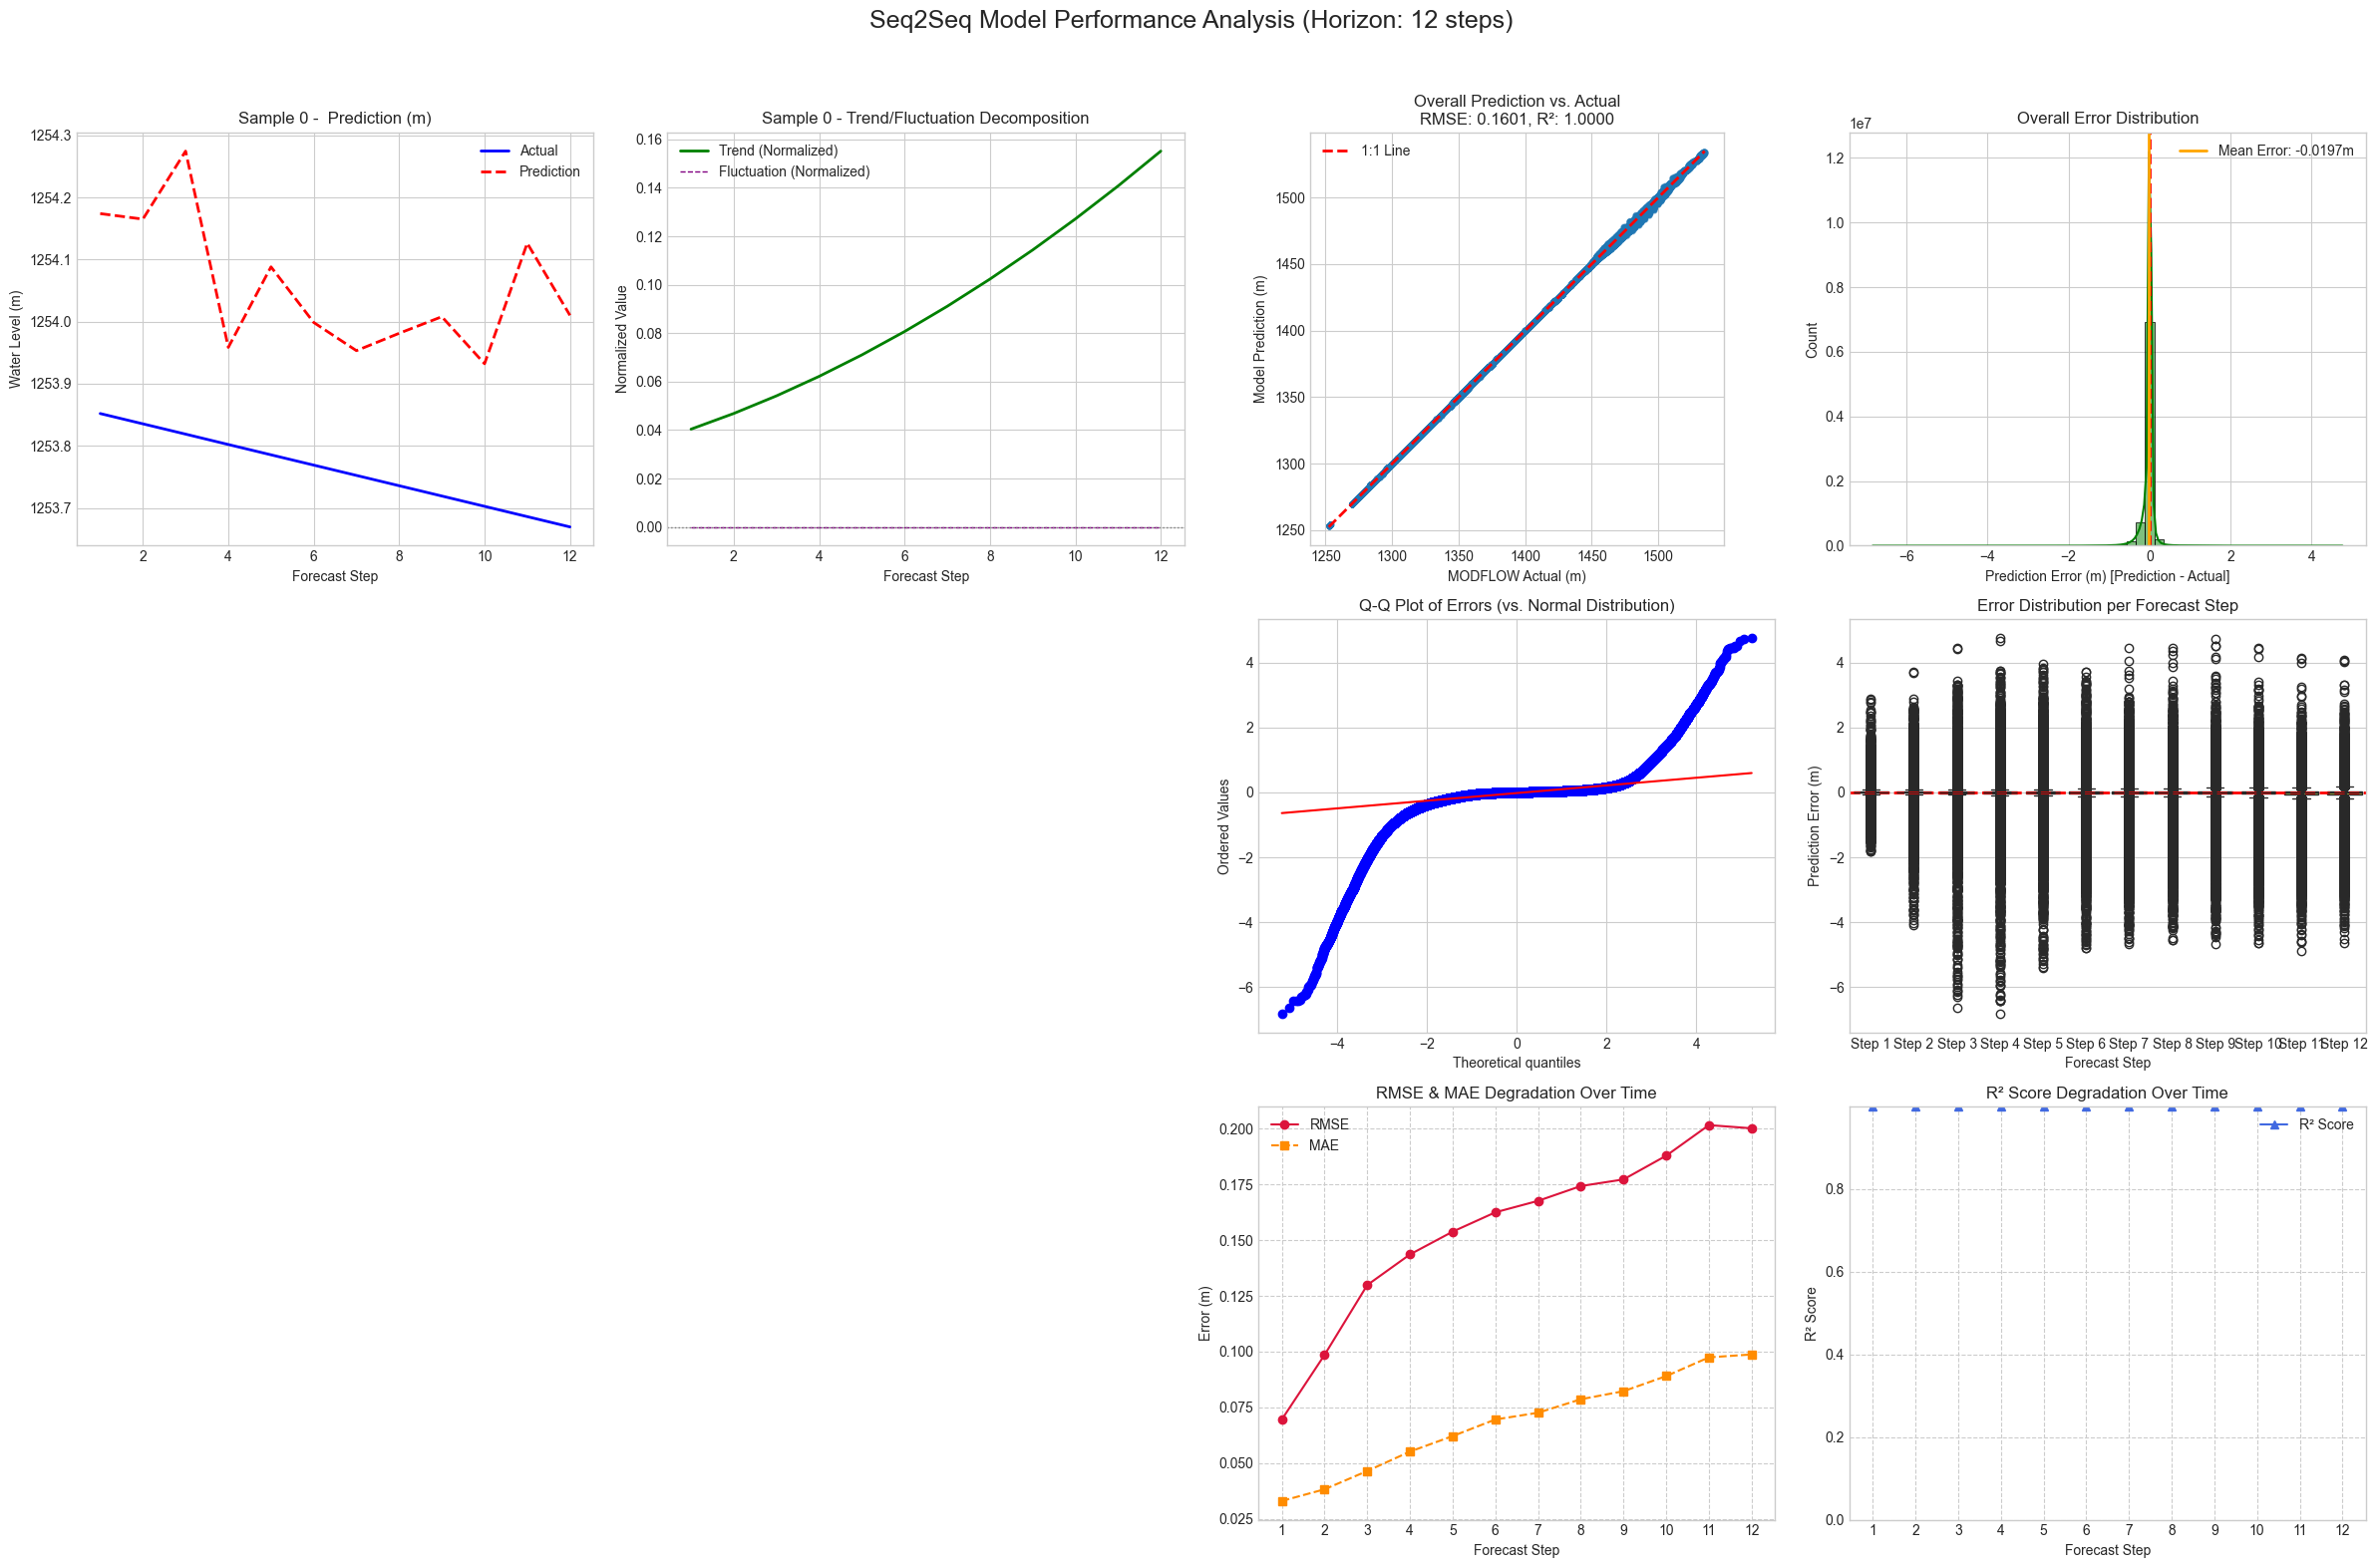

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch_geometric.loader import DataLoader # 注意：使用DataLoader进行批量处理
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns
from scipy import stats
from tqdm import tqdm # 用于显示进度

def evaluate_and_visualize_seq2seq(model, test_data, processor, device='cuda' if torch.cuda.is_available() else 'cpu'):
    """
    为序列到序列（Seq2Seq）模型设计的评估与可视化函数。
    【已针对非自回归多尺度模型（如N-HiTS风格）优化】:
    一次性获取整个预测序列，并新增趋势/波动分量的
    可视化。

    Parameters:
        model: 训练好的 PhysicsGuidedGNN 模型。
        test_data (list): 包含 torch_geometric.data.Data 对象的测试数据集。
        processor (HydroDataProcessor): 数据处理器实例，用于反归一化预测结果。
        device (str): 运行模型的设备 ('cuda' 或 'cpu')。
    """
    print("--- 开始序列到序列模型评估 ---")
    model.eval()
    model.to(device)

    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

    all_preds_seq = []
    all_actuals_seq = []

    # 额外存储一个样本的分解结果用于可视化
    sample_decomposition = None
    sample_idx_for_viz = 0 # 选择第一个样本进行可视化

    # 1. 循环预测所有测试样本
    print(f"正在处理 {len(test_data)} 个测试序列...")
    with torch.no_grad():
        for i, data in enumerate(tqdm(test_loader, desc="模型预测")):
            try:
                data = data.to(device)

                # 调用模型的 predict 方法，它内部会调用一次性的 forward
                predictions = model.predict(data)

                # 获取预测序列和真实序列，形状应为: [num_nodes, forecast_horizon]
                pred_output_seq = predictions['output']
                actual_output_seq = data.y

                all_preds_seq.append(pred_output_seq.cpu().numpy())
                all_actuals_seq.append(actual_output_seq.cpu().numpy())

                # 提取第一个样本的分解结果用于可视化
                if i == sample_idx_for_viz:
                    # 仅选择第一个节点进行可视化
                    node_idx = 0
                    sample_decomposition = {
                        'output': pred_output_seq[node_idx].cpu().numpy(),
                        'actual': actual_output_seq[node_idx].cpu().numpy(),
                        'trend': predictions.get('trend', torch.zeros_like(pred_output_seq))[node_idx].cpu().numpy(),
                        'fluctuation': predictions.get('fluctuation', torch.zeros_like(pred_output_seq))[node_idx].cpu().numpy(),
                    }

            except Exception as e:
                print(f"处理一个批次时出错: {e}")
                continue

    if not all_preds_seq:
        print("错误：未能生成任何预测结果。请检查测试数据或模型。")
        return None

    # 2. 数据聚合与反归一化
    print("\n正在聚合和反归一化数据...")

    all_preds_np = np.concatenate(all_preds_seq, axis=0)
    all_actuals_np = np.concatenate(all_actuals_seq, axis=0)

    num_total_nodes, forecast_horizon = all_preds_np.shape
    print(f"总节点-时间步数量: {num_total_nodes * forecast_horizon}")
    print(f"预测范围 (Horizon): {forecast_horizon} 个时间步")

    # 为了使用 inverse_transform，需要将数据展平
    preds_flat = all_preds_np.flatten()
    actuals_flat = all_actuals_np.flatten()

    preds_orig = processor.inverse_transform(preds_flat.reshape(-1, 1)).flatten()
    actuals_orig = processor.inverse_transform(actuals_flat.reshape(-1, 1)).flatten()

    # 将反归一化后的数据恢复为 [total_nodes, forecast_horizon] 的形状
    all_preds_orig = preds_orig.reshape(num_total_nodes, forecast_horizon)
    all_actuals_orig = actuals_orig.reshape(num_total_nodes, forecast_horizon)
    errors_orig = all_preds_orig - all_actuals_orig

    # 反归一化可视化样本
    if sample_decomposition:
        # 只需反归一化输出和实际值，因为趋势和波动项的和是输出，反归一化后无法简单相加还原。
        # 这里仅将输出和实际值进行反归一化，趋势和波动项保持归一化状态进行绘图。
        # 如果需要反归一化趋势/波动，需要复杂的逐项还原，通常在N-HiTS的分解可视化中不这样做，而是直接展示分解项。
        # 简单起见，我们对分解后的项不进行反归一化，只对最终结果进行。
        sample_decomposition['output_orig'] = processor.inverse_transform(sample_decomposition['output'].reshape(-1, 1)).flatten()
        sample_decomposition['actual_orig'] = processor.inverse_transform(sample_decomposition['actual'].reshape(-1, 1)).flatten()

    # 3. 计算总体性能指标 (保持不变)
    overall_rmse = np.sqrt(mean_squared_error(all_actuals_orig, all_preds_orig))
    overall_mae = mean_absolute_error(all_actuals_orig, all_preds_orig)
    overall_r2 = r2_score(all_actuals_orig, all_preds_orig)

    print("\n--- 总体性能指标 (所有预测步) ---")
    print(f"  RMSE (均方根误差): {overall_rmse:.4f} m")
    print(f"  MAE (平均绝对误差): {overall_mae:.4f} m")
    print(f"  R² (决定系数): {overall_r2:.4f}")

    # 4. 计算逐预测步的性能指标 (保持不变)
    step_metrics = []
    print("\n--- 逐预测步性能分析 ---")
    print("  步数 |   RMSE   |   MAE    |    R²")
    print("---------------------------------------")
    for i in range(forecast_horizon):
        rmse = np.sqrt(mean_squared_error(all_actuals_orig[:, i], all_preds_orig[:, i]))
        mae = mean_absolute_error(all_actuals_orig[:, i], all_preds_orig[:, i])
        r2 = r2_score(all_actuals_orig[:, i], all_preds_orig[:, i])
        step_metrics.append({'rmse': rmse, 'mae': mae, 'r2': r2})
        print(f"  {i+1:<4} | {rmse:8.4f} | {mae:8.4f} | {r2:8.4f}")

    # 5. 可视化
    print("\n正在生成可视化图表...")
    plt.style.use('seaborn-v0_8-whitegrid')

    # 调整图表布局以容纳分解图 (2行 4列 或 3行 3列)
    fig = plt.figure(figsize=(24, 16))
    plt.suptitle(f'Seq2Seq Model Performance Analysis (Horizon: {forecast_horizon} steps)', fontsize=18)


    # ------------------------------------------------
    # 新增: 预测分解图 (N-HiTS风格)
    # ------------------------------------------------
    if sample_decomposition:
        steps = np.arange(1, forecast_horizon + 1)
        ax0 = plt.subplot(3, 4, 1) # 调整布局

        # 预测与实际
        ax0.plot(steps, sample_decomposition['actual_orig'], label='Actual', color='blue', linewidth=2)
        ax0.plot(steps, sample_decomposition['output_orig'], label='Prediction', color='red', linestyle='--', linewidth=2)
        ax0.set_title(f'Sample {sample_idx_for_viz} -  Prediction (m)')
        ax0.set_xlabel('Forecast Step')
        ax0.set_ylabel('Water Level (m)')
        ax0.legend()

        ax0_decomp = plt.subplot(3, 4, 2) # 调整布局
        # 趋势和波动项
        ax0_decomp.plot(steps, sample_decomposition['trend'], label='Trend (Normalized)', color='green', linewidth=2)
        ax0_decomp.plot(steps, sample_decomposition['fluctuation'], label='Fluctuation (Normalized)', color='purple', linestyle='--', linewidth=1)
        ax0_decomp.axhline(y=0, color='gray', linestyle=':', linewidth=1)
        ax0_decomp.set_title(f'Sample {sample_idx_for_viz} - Trend/Fluctuation Decomposition')
        ax0_decomp.set_xlabel('Forecast Step')
        ax0_decomp.set_ylabel('Normalized Value')
        ax0_decomp.legend()

        start_plot_index = 3 # 后续图从第3个位置开始
    else:
        start_plot_index = 1 # 如果没有分解信息，从第1个位置开始


    # ------------------------------------------------
    # 总体性能指标图 (与原逻辑一致，调整子图位置)
    # ------------------------------------------------

    # 图1: 总体预测 vs 实际散点图
    ax1 = plt.subplot(3, 4, start_plot_index)
    ax1.scatter(actuals_orig, preds_orig, alpha=0.3, s=10)
    min_val = min(np.min(actuals_orig), np.min(preds_orig))
    max_val = max(np.max(actuals_orig), np.max(preds_orig))
    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='1:1 Line')
    ax1.set_xlabel('MODFLOW Actual (m)')
    ax1.set_ylabel('Model Prediction (m)')
    ax1.set_title(f'Overall Prediction vs. Actual\nRMSE: {overall_rmse:.4f}, R²: {overall_r2:.4f}')
    ax1.set_aspect('equal', 'box')
    ax1.legend()

    # 图2: 总体误差分布直方图
    ax2 = plt.subplot(3, 4, start_plot_index + 1)
    sns.histplot(errors_orig.flatten(), bins=50, kde=True, ax=ax2, color='green')
    ax2.axvline(x=0, color='r', linestyle='--', linewidth=2)
    mean_error = np.mean(errors_orig)
    ax2.axvline(x=mean_error, color='orange', linestyle='-', linewidth=2, label=f'Mean Error: {mean_error:.4f}m')
    ax2.set_xlabel('Prediction Error (m) [Prediction - Actual]')
    ax2.set_title('Overall Error Distribution')
    ax2.legend()

    # 图3: Q-Q图检查误差正态性
    ax3 = plt.subplot(3, 4, start_plot_index + 4) # 调整到下一行
    stats.probplot(errors_orig.flatten(), dist="norm", plot=ax3)
    ax3.set_title('Q-Q Plot of Errors (vs. Normal Distribution)')

    # 图4: 逐预测步的误差箱线图
    ax4 = plt.subplot(3, 4, start_plot_index + 5) # 调整到下一行
    df_errors = pd.DataFrame(errors_orig, columns=[f'Step {i+1}' for i in range(forecast_horizon)])
    sns.boxplot(data=df_errors, ax=ax4, palette='viridis')
    ax4.axhline(y=0, color='r', linestyle='--', linewidth=2)
    ax4.set_xlabel('Forecast Step')
    ax4.set_ylabel('Prediction Error (m)')
    ax4.set_title('Error Distribution per Forecast Step')

    # 图5: 逐预测步的RMSE和MAE变化曲线
    ax5 = plt.subplot(3, 4, start_plot_index + 8) # 调整到下一行
    steps = np.arange(1, forecast_horizon + 1)
    ax5.plot(steps, [m['rmse'] for m in step_metrics], 'o-', color='crimson', label='RMSE')
    ax5.plot(steps, [m['mae'] for m in step_metrics], 's--', color='darkorange', label='MAE')
    ax5.set_xlabel('Forecast Step')
    ax5.set_ylabel('Error (m)')
    ax5.set_title('RMSE & MAE Degradation Over Time')
    ax5.set_xticks(steps)
    ax5.grid(True, which='both', linestyle='--')
    ax5.legend()

    # 图6: 逐预测步的R²变化曲线
    ax6 = plt.subplot(3, 4, start_plot_index + 9) # 调整到下一行
    ax6.plot(steps, [m['r2'] for m in step_metrics], '^-', color='royalblue', label='R² Score')
    ax6.set_xlabel('Forecast Step')
    ax6.set_ylabel('R² Score')
    ax6.set_title('R² Score Degradation Over Time')
    ax6.set_xticks(steps)
    ax6.set_ylim(bottom=min(0, ax6.get_ylim()[0])) # 确保y轴从0或更低开始
    ax6.grid(True, which='both', linestyle='--')
    ax6.legend()

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig('seq2seq_evaluation_results_with_decomposition.png', dpi=300)
    plt.show()

    return {
        'overall_metrics': {'rmse': overall_rmse, 'mae': overall_mae, 'r2': overall_r2},
        'step_metrics': step_metrics,
        'predictions': all_preds_orig,
        'actuals': all_actuals_orig
    }

evaluation_results = evaluate_and_visualize_seq2seq(
         model=trained_model,
         test_data=test, # 'test' 是您的测试集列表
         processor=processor,
         device=device
     )


图表已按照顶刊标准生成并保存！


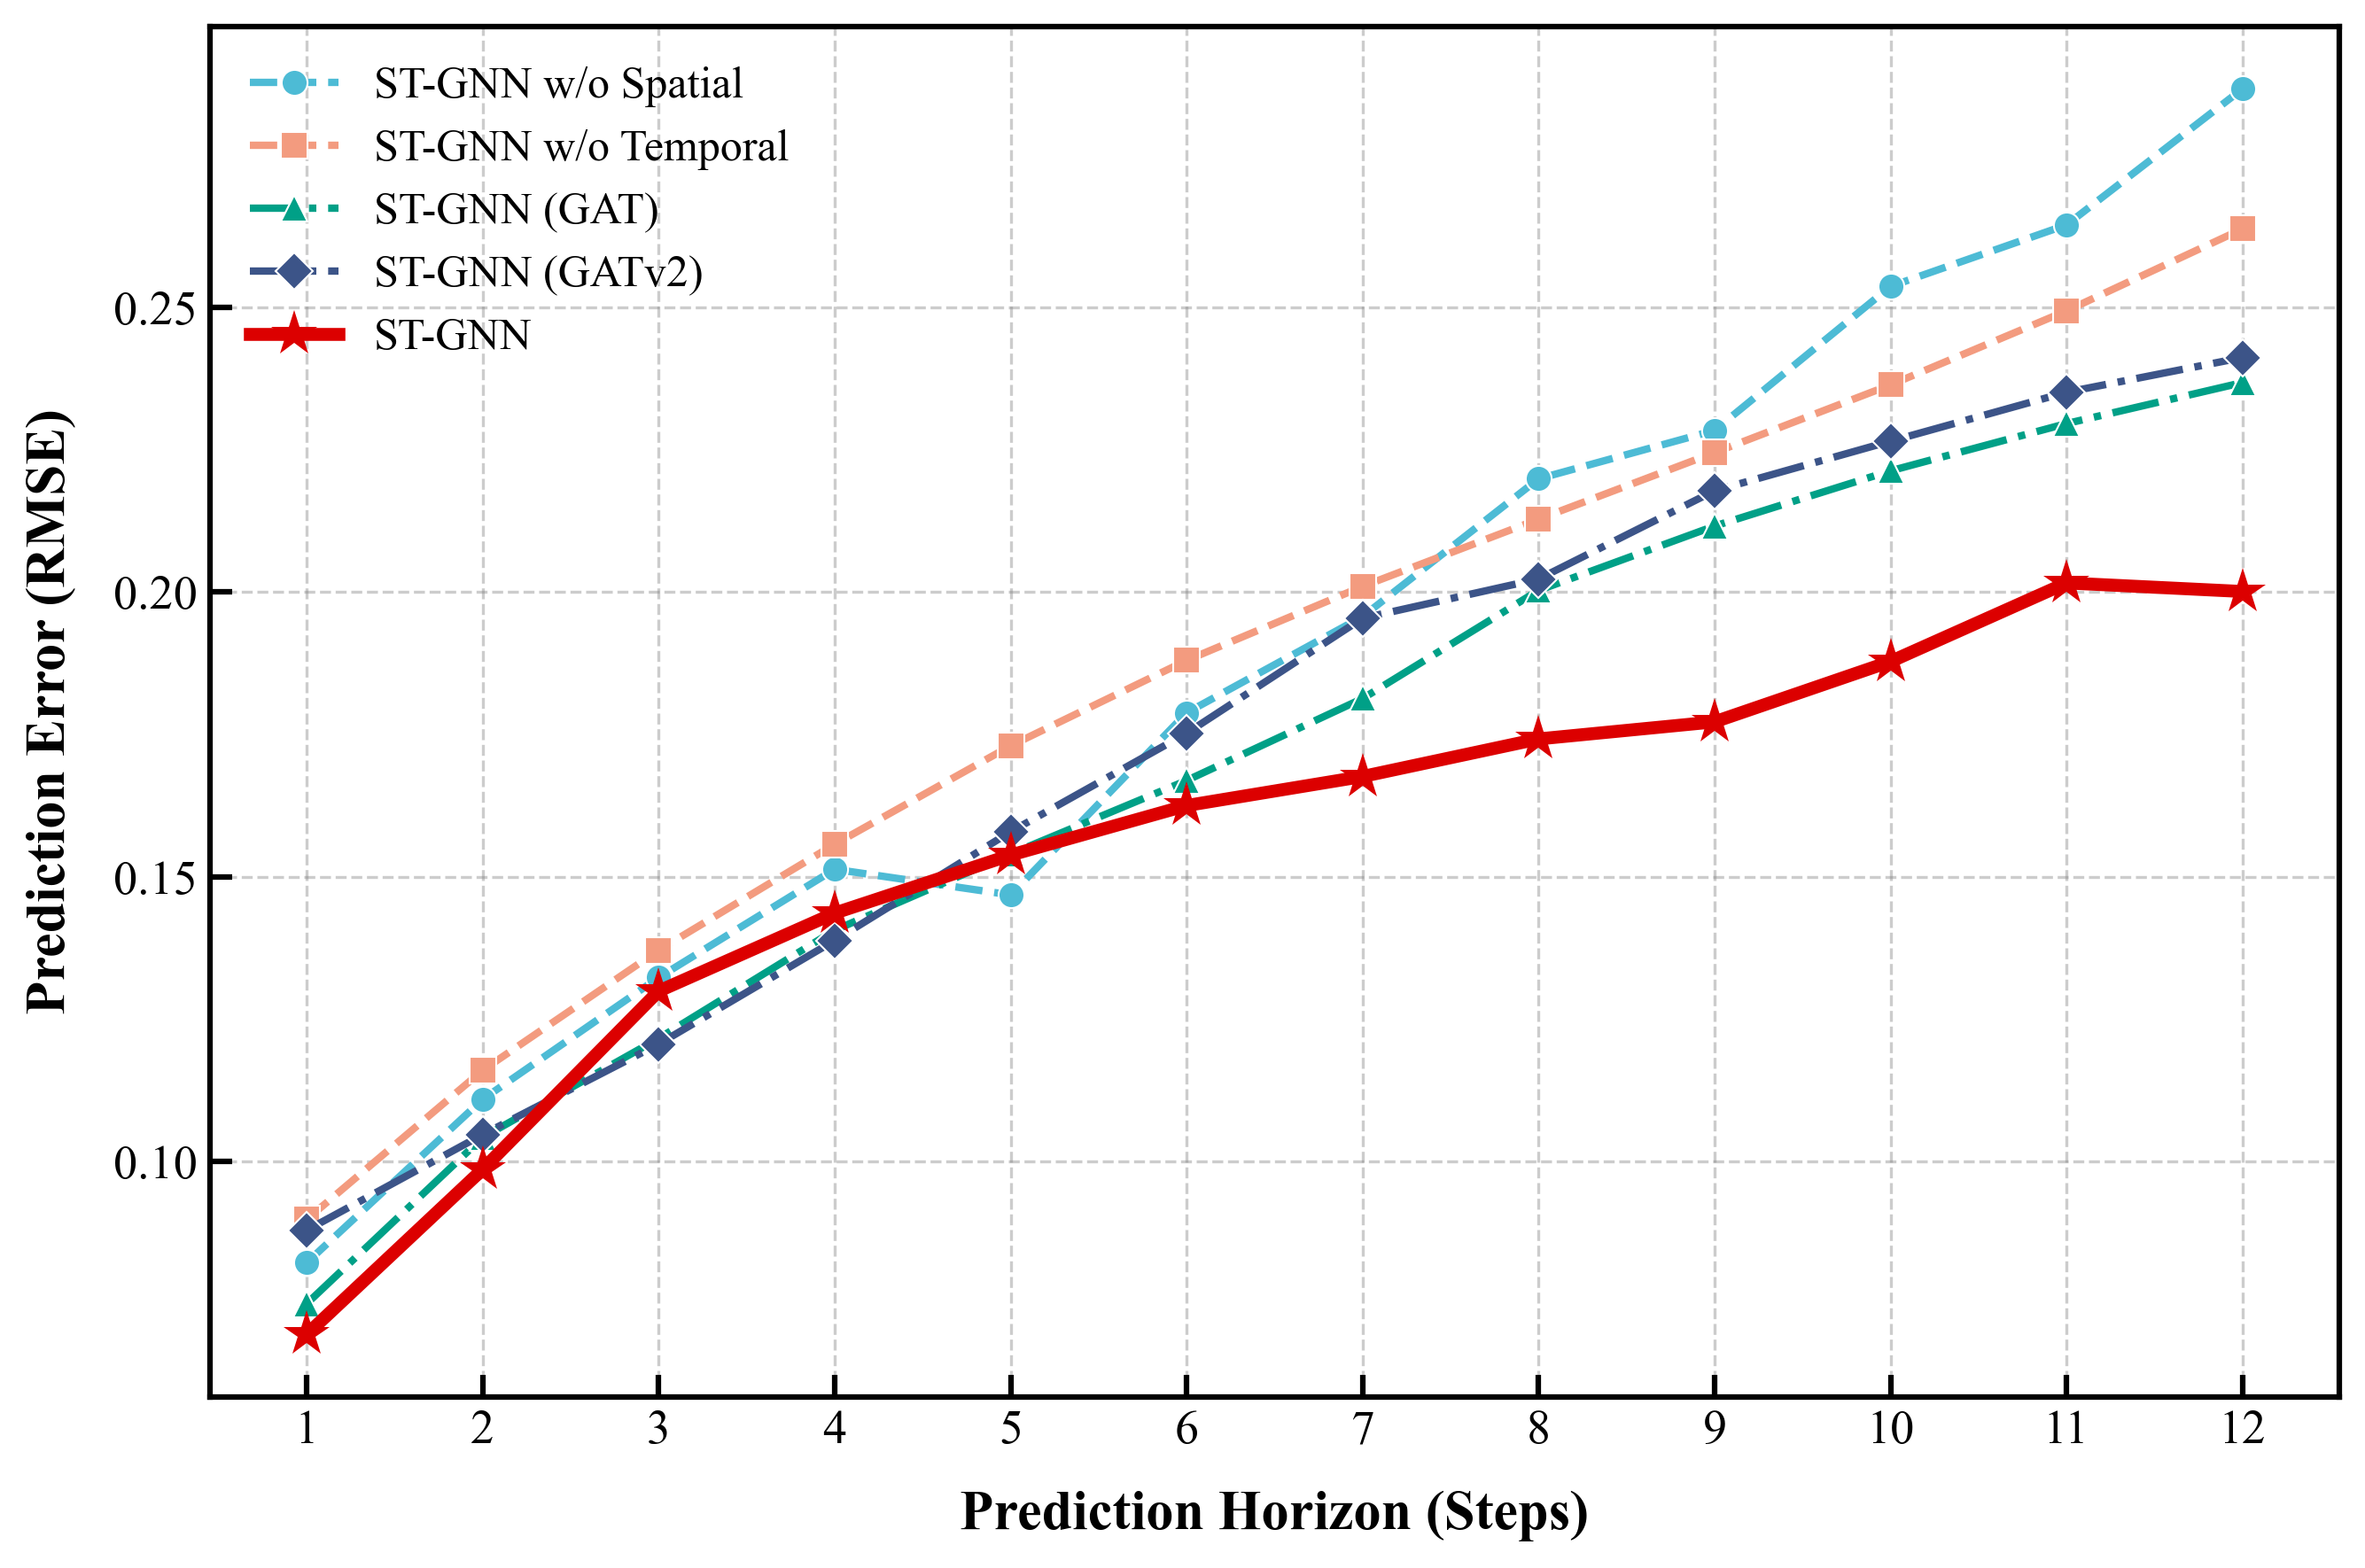

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ==========================================
# 1. 全局学术风格设置 (Top-Tier Journal Style)
# ==========================================
# 强制使用 Times New Roman 字体（国际顶刊标准）
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'  # 使得数学符号的字体也匹配

# 设置坐标轴线宽和刻度方向
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['xtick.direction'] = 'in'  # 刻度向内
plt.rcParams['ytick.direction'] = 'in'

# 如果你的期刊是中文顶刊（如《水利学报》），请取消下面两行的注释以支持中文
# plt.rcParams['font.serif'] = ['SimSun', 'Times New Roman'] # 宋体+Times New Roman
# plt.rcParams['axes.unicode_minus'] = False 

# ==========================================
# 2. 数据准备
# ==========================================
data = {
    '1': [0.0822, 0.0898, 0.0750, 0.0879, 0.0696],
    '2': [0.1109, 0.1160, 0.1042, 0.1047, 0.0986],
    '3': [0.1323, 0.1371, 0.1216, 0.1206, 0.1299],
    '4': [0.1513, 0.1557, 0.1406, 0.1388, 0.1436],
    '5': [0.1468, 0.1730, 0.1540, 0.1579, 0.1538], 
    '6': [0.1788, 0.1880, 0.1669, 0.1752, 0.1625],
    '7': [0.1957, 0.2010, 0.1813, 0.1954, 0.1676],
    '8': [0.2199, 0.2128, 0.2003, 0.2023, 0.1742],
    '9': [0.2284, 0.2245, 0.2116, 0.2178, 0.1772],
    '10': [0.2537, 0.2364, 0.2213, 0.2265, 0.1878],
    '11': [0.2645, 0.2494, 0.2296, 0.2351, 0.2016],
    '12': [0.2884, 0.2638, 0.2368, 0.2412, 0.2001]
}
index_labels = ['ST-GNN w/o Spatial', 'ST-GNN w/o Temporal', 'ST-GNN (GAT)', 'ST-GNN (GATv2)', 'ST-GNN']

df = pd.DataFrame(data, index=index_labels)
df_t = df.T
# 将 x 轴的字符串时间步转换为整数，以保证横坐标刻度平滑
df_t.index = df_t.index.astype(int)

# ==========================================
# 3. 定制化线型与配色 (Nature Science Palette)
# ==========================================
# 我们为你的主模型 ST-GNN 分配醒目的红色粗线和五角星
# 为其他消融模型分配冷色调/中性色的虚线或点划线
styles = {
    'ST-GNN w/o Spatial': {'color': '#4DBBD5', 'marker': 'o', 'linestyle': '--', 'linewidth': 2, 'markersize': 7, 'zorder': 2},
    'ST-GNN w/o Temporal': {'color': '#E64B35', 'marker': 's', 'linestyle': '--', 'linewidth': 2, 'markersize': 7, 'zorder': 2, 'color': '#F39B7F'},
    'ST-GNN (GAT)':       {'color': '#00A087', 'marker': '^', 'linestyle': '-.', 'linewidth': 2, 'markersize': 7, 'zorder': 3},
    'ST-GNN (GATv2)':     {'color': '#3C5488', 'marker': 'D', 'linestyle': '-.', 'linewidth': 2, 'markersize': 7, 'zorder': 3},
    'ST-GNN':             {'color': '#DC0000', 'marker': '*', 'linestyle': '-', 'linewidth': 3.5, 'markersize': 13, 'zorder': 10} # 绝对主角
}

# ==========================================
# 4. 开始绘图
# ==========================================
fig, ax = plt.subplots(figsize=(9, 6), dpi=300) # 300 DPI 是出版级分辨率要求

for col in df_t.columns:
    s = styles[col]
    ax.plot(df_t.index, df_t[col], 
            label=col, 
            color=s['color'], 
            marker=s['marker'],
            linestyle=s['linestyle'], 
            linewidth=s['linewidth'], 
            markersize=s['markersize'],
            zorder=s['zorder'],
            markeredgecolor='white' if col != 'ST-GNN' else 'none', # 给小标记加个白边，更精致
            markeredgewidth=0.5)

# 设置标签和标题 (推荐英文)
# ax.set_title('Ablation Study on Prediction Horizon', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Prediction Horizon (Steps)', fontsize=15, fontweight='bold', labelpad=10)
ax.set_ylabel('Prediction Error (RMSE)', fontsize=15, fontweight='bold', labelpad=10) # 请根据实际修改为 RMSE 或 MAE

# 设置坐标轴刻度字体大小
ax.tick_params(axis='both', which='major', labelsize=13, length=6)
# 强制 x 轴显示整数刻度
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))

# 添加轻量级的网格线，不会喧宾夺主
ax.grid(True, which='major', linestyle='--', alpha=0.4, color='gray')

# 图例设置：去边框，半透明背景，字体适中
legend = ax.legend(loc='upper left', fontsize=12, frameon=False)
# 调整图例项之间的间距


# 如果需要极简风格，可以隐藏顶部和右侧的边框 (按需取消注释)
# ax.spines['top'].set_visible(False)
# ax.spines['right'].set_visible(False)

# 保存图片（PDF 矢量图和高分辨率 PNG）
plt.tight_layout()
plt.savefig('line_chart_top_tier.pdf', format='pdf', bbox_inches='tight') # 投递顶刊首选 PDF 格式
plt.savefig('line_chart_top_tier.png', dpi=300, bbox_inches='tight')

print("图表已按照顶刊标准生成并保存！")
plt.show()


In [43]:
# 保存模型
torch.save(trained_model.state_dict(), '51-NHITS_model.pth')
print('Curriculum trained model saved to curriculum_trained_model.pth')

Curriculum trained model saved to curriculum_trained_model.pth



--- 开始修正后的未来预测 (Target: (48, 69)) ---
初始时间步 t=755 (对应日期: 2006-12-21 16:00:00)
历史水位初始化完成。
停止：找不到时间步 t=827 的样本 (数据耗尽)。

--- 坐标点 (48, 69) 的预测评估指标 ---
  平均绝对误差 (MAE):   0.0554
  均方根误差 (RMSE):    0.0631
  决定系数 (R²):        0.9561
  纳什效率系数 (NSE): 0.9561
------------------------------------
指标说明:
  - MAE/RMSE: 越接近0越好。
  - R²/NSE:   越接近1越好。NSE是水文学常用指标。


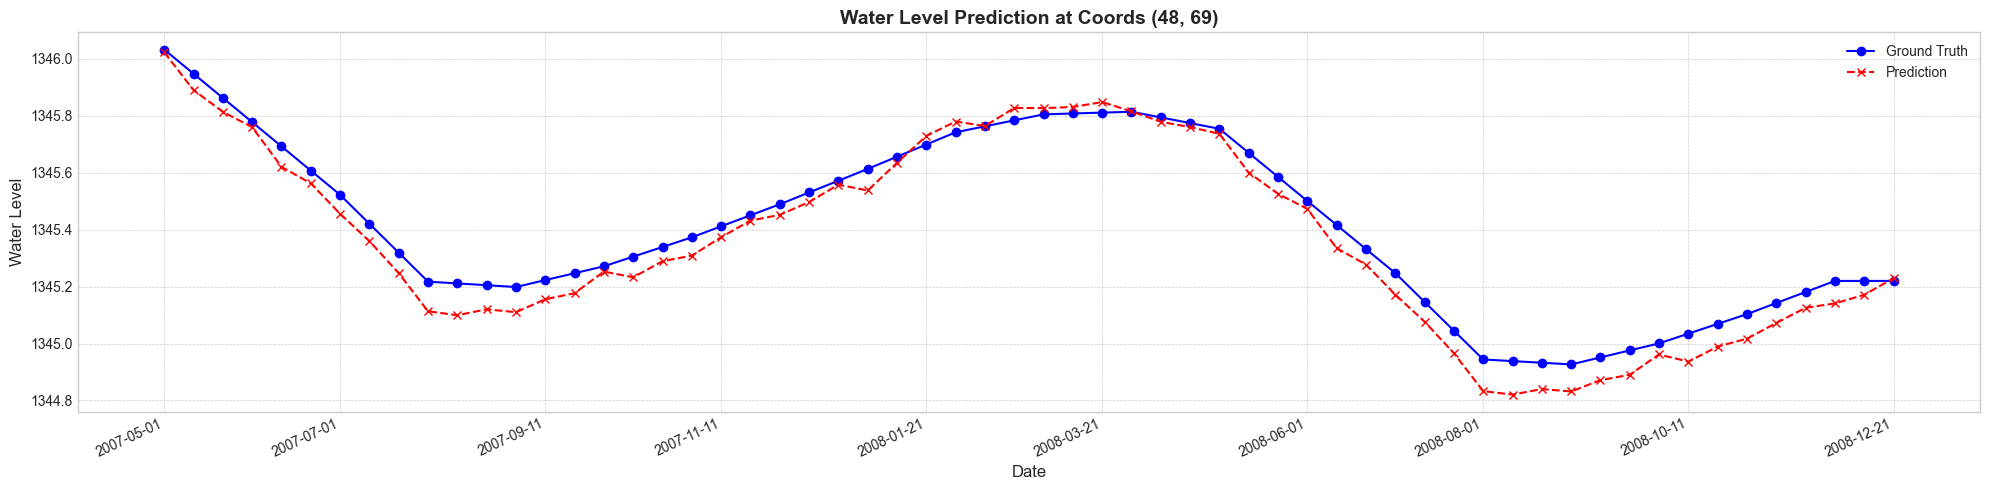


--- 正在保存预测结果到 weilai prediction_results_well_48_69.npz ---
保存成功！


In [86]:
# Import a
from collections import defaultdict
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
# [[核心修改]] 导入 scikit-learn 用于计算评估指标
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# =============================================================================
# --- STEP 1: 计算训练集平均特征 (此函数无需修改) ---
# =============================================================================

def calculate_training_avg_features(train_data, processor):
    """
    遍历训练集，为每个时间点（由月份和旬定义）计算平均动态特征。
    """
    print("\n--- 正在计算训练集的平均动态特征 ---")

    feature_accumulator = defaultdict(list)
    encoder_len = 12  # 假设 encoder window size 为 12

    for i, graph_sample in enumerate(tqdm(train_data, desc="分析训练样本")):
        if not hasattr(graph_sample, 't'):
            print(f"警告: 样本 {i} 缺少 't' 属性, 跳过。")
            continue

        for step_idx in range(encoder_len):
            original_timestep = graph_sample.t - (encoder_len - 1) + step_idx
            if original_timestep < 0 or original_timestep >= len(processor.dates):
                continue

            date = processor.dates[original_timestep]
            month = date.month
            day_of_month = date.day
            if day_of_month <= 10: dekad = 1
            elif day_of_month <= 20: dekad = 2
            else: dekad = 3

            features_at_t = processor._rolling_normalization(original_timestep)
            feature_accumulator[(month, dekad)].append(torch.from_numpy(features_at_t))

    training_averages = {}
    print("\n正在为每个时间点计算平均值...")
    for key, tensor_list in feature_accumulator.items():
        if tensor_list:
            stacked_tensors = torch.stack(tensor_list, dim=0)
            training_averages[key] = torch.mean(stacked_tensors, dim=0)

    print(f"计算完成！已为 {len(training_averages)} 个不同的时间点（月, 旬）创建了平均特征。")
    return training_averages


# =============================================================================
# --- STEP 2: 新的未来预测函数 (此函数无需修改) ---
# =============================================================================

def predict_future_in_blocks(model, test_data, graph_data_list, processor, target_coords, device):
    """
    修正版：基于全局时间步索引查找正确的未来样本
    """
    print(f"\n--- 开始修正后的未来预测 (Target: {target_coords}) ---")
    model.eval()

    # 1. 找到目标节点索引
    valid_coords_np = np.array(list(zip(*processor.valid_coords)))
    target_node_idx_arr = np.where(
        (valid_coords_np[:, 0] == target_coords[0]) & 
        (valid_coords_np[:, 1] == target_coords[1])
    )[0]

    if len(target_node_idx_arr) == 0:
        print(f"错误: 目标坐标 {target_coords} 无效。")
        return None, None, None
    target_node_idx = target_node_idx_arr[0]
    
    forecast_len = model.forecast_len # 12

    # 2. 建立 graph_data_list 的索引映射 (t -> index)
    # 这样我们可以根据时间步 t 快速找到对应的图数据
    timestep_map = {data.t: i for i, data in enumerate(graph_data_list)}
    
    with torch.no_grad():
        # --- 初始化 ---
        # 获取测试集最后一个样本
        last_test_sample = test_data[-1].to(device)
        last_t = last_test_sample.t
        
        # 使用测试集最后的 Ground Truth 作为第一块预测的历史
        # 形状: [nodes, 12] -> [nodes, 12, 1]
        current_history = last_test_sample.y.unsqueeze(-1).clone()
        
        print(f"初始时间步 t={last_t} (对应日期: {processor.dates[last_t]})")
        print(f"历史水位初始化完成。")

        all_predicted_blocks_norm = []
        all_true_blocks_norm = []
        collected_dates = []
        
        # 设定我们要预测多少轮 (例如往后预测 12 * 5 = 60 个时间步)
        # 或者直到没有数据为止
        max_blocks = 10 
        
        # 当前处理的时间步（作为 Input Window 的结束点）
        # 第一轮预测需要的样本，其输入窗口应该结束于 last_t + 12
        # 因为 last_test_sample 预测了 [t+1 ... t+12]
        # 下一个样本需要以 t+12 为结束的历史数据，来预测 [t+13 ... t+24]
        current_t_end = last_t + forecast_len

        for block_idx in range(max_blocks):
            # --- 关键修正：通过 t 查找样本 ---
            if current_t_end not in timestep_map:
                print(f"停止：找不到时间步 t={current_t_end} 的样本 (数据耗尽)。")
                break
            
            global_idx = timestep_map[current_t_end]
            current_sample = graph_data_list[global_idx].to(device)
            
            # 复制样本
            prediction_input = current_sample.clone()
            
            # --- 注入生成的历史水位 ---
            # 这里必须非常小心：current_history 是上一步预测出来的 [nodes, 12, 1]
            # 只有当 forecast_len == encoder_window_size 时，才能直接覆盖
            # 如果不相等，需要做切片或拼接。假设这里都是 12。
            prediction_input.x_history_encoder = current_history

            # --- 预测 ---
            prediction_dict = model.predict(prediction_input)
            predicted_block_norm = prediction_dict['output'] # [nodes, 12]
            
            # 保存
            all_predicted_blocks_norm.append(predicted_block_norm.cpu())
            if hasattr(current_sample, 'y') and current_sample.y is not None:
                all_true_blocks_norm.append(current_sample.y.cpu())
            
            # --- 收集日期 ---
            # 该样本预测的时间范围是 t+1 到 t+forecast_len
            start_idx = current_sample.t + 1
            end_idx = start_idx + forecast_len
            if end_idx <= len(processor.dates):
                collected_dates.extend(processor.dates[start_idx:end_idx])

            # --- 更新状态 ---
            # 1. 更新历史输入：将本次预测值作为下一次的历史
            current_history = predicted_block_norm.unsqueeze(-1)
            # 2. 更新时间指针：跳过 forecast_len
            current_t_end += forecast_len

        if not all_predicted_blocks_norm:
            return None, None, None

        # --- 后处理 ---
        predictions_tensor_norm = torch.cat(all_predicted_blocks_norm, dim=1)
        
        target_series_true_orig = None
        if all_true_blocks_norm:
            true_tensor_norm = torch.cat(all_true_blocks_norm, dim=1)
            target_series_true_norm = true_tensor_norm[target_node_idx, :].numpy()
            target_series_true_orig = processor.inverse_transform(target_series_true_norm.reshape(-1, 1)).flatten()

        target_series_pred_norm = predictions_tensor_norm[target_node_idx, :].numpy()
        target_series_pred_orig = processor.inverse_transform(target_series_pred_norm.reshape(-1, 1)).flatten()
        
        return collected_dates, target_series_pred_orig, target_series_true_orig

# 调用方式修改：传入完整的 graph_data_list 以便全局索引
# future_dates, predicted_levels, true_levels = predict_future_in_blocks(
#     model=trained_model,
#     test_data=test,
#     graph_data_list=graph_data_list, # 注意这里传入整个列表
#     processor=processor,
#     target_coords=target_coordinates,
#     device=device
# )




# =============================================================================
# --- STEP 3: 绘图函数 (此函数无需修改) ---
# =============================================================================

def plot_with_custom_aspect(dates, preds, trues, coords, figsize=(15, 6), title=None):
    """
    使用指定的宽高比绘制预测和真实值曲线。
    """
    plt.figure(figsize=figsize)
    plt.plot(trues, label='Ground Truth', color='blue', marker='o', linestyle='-')
    plt.plot(preds, label='Prediction', color='red', marker='x', linestyle='--')

    tick_indices = np.linspace(0, len(dates) - 1, num=10, dtype=int)
    plt.xticks(ticks=tick_indices, labels=[pd.to_datetime(dates[i]).strftime('%Y-%m-%d') for i in tick_indices], rotation=25, ha="right")

    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Water Level", fontsize=12)
    final_title = title if title is not None else f"Water Level Prediction at Coords {coords}"
    plt.title(final_title, fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.tight_layout()
    plt.show()

# =============================================================================
# --- [[核心修改]]: 新增评估指标计算与展示函数 ---
# =============================================================================

def calculate_and_print_metrics(true_values, predicted_values, coords):
    """
    计算并打印一套标准的回归和水文预测评估指标。

    Args:
        true_values (np.ndarray): 真实的观测值序列。
        predicted_values (np.ndarray): 模型预测的值序列。
        coords (tuple): 评估所针对的坐标点，用于标题显示。
    """
    # 确保输入是numpy数组
    true_values = np.asarray(true_values)
    predicted_values = np.asarray(predicted_values)

    # 过滤掉NaN值，以防万一
    valid_indices = ~np.isnan(true_values) & ~np.isnan(predicted_values)
    if np.sum(~valid_indices) > 0:
        print(f"警告: 在计算指标前，已移除 {np.sum(~valid_indices)} 个NaN值。")
        true_values = true_values[valid_indices]
        predicted_values = predicted_values[valid_indices]

    if true_values.size == 0:
        print("错误: 没有有效的真值和预测值对，无法计算指标。")
        return

    # 计算基础指标
    mae = mean_absolute_error(true_values, predicted_values)
    mse = mean_squared_error(true_values, predicted_values)
    rmse = np.sqrt(mse)
    r2 = r2_score(true_values, predicted_values)

    # 计算纳什效率系数 (NSE)
    numerator = np.sum((true_values - predicted_values) ** 2)
    denominator = np.sum((true_values - np.mean(true_values)) ** 2)
    # 避免除以零
    nse = 1 - (numerator / denominator) if denominator != 0 else -np.inf

    # 打印结果
    print(f"\n--- 坐标点 {coords} 的预测评估指标 ---")
    print(f"  平均绝对误差 (MAE):   {mae:.4f}")
    print(f"  均方根误差 (RMSE):    {rmse:.4f}")
    print(f"  决定系数 (R²):        {r2:.4f}")
    print(f"  纳什效率系数 (NSE): {nse:.4f}")
    print("------------------------------------")
    print("指标说明:")
    print("  - MAE/RMSE: 越接近0越好。")
    print("  - R²/NSE:   越接近1越好。NSE是水文学常用指标。")


# =============================================================================
# --- STEP 4: [[核心修改]] 调用包含评估的完整工作流 ---
# =============================================================================

# 假设以下变量已经定义好:
# train, processor, trained_model, device, test, future_prediction

# 确保模型在正确的设备上
trained_model.to(device)

# 1. (如果需要) 重新计算平均动态特征
# 注意：这个过程可能比较耗时，如果已计算过可以加载缓存
#training_averages = calculate_training_avg_features(train, processor)

# 2. 定义预测的目标坐标
target_coordinates = (48, 69)

# 3. 调用新的、基于分块预测的函数
future_dates, predicted_levels, true_levels = predict_future_in_blocks(
    model=trained_model,
    test_data=test,
    graph_data_list=graph_data_list, # 这里面包含了未来的真实降雨/抽水数据
    target_coords=target_coordinates,
    processor=processor,
    device=device
)

# 4. 检查预测结果，然后计算指标并绘图
if future_dates and predicted_levels is not None and true_levels is not None:
#     # [[核心修改]] 调用函数计算并打印评估指标
    calculate_and_print_metrics(true_levels, predicted_levels, target_coordinates)

#     # 使用绘图函数进行可视化
#   print("\n--- 正在生成“扁平化”图像，宽高比 (20, 5) ---")
    plot_with_custom_aspect(
        future_dates,
        predicted_levels,
        true_levels,
        target_coordinates,
        figsize=(20, 5) # [[核心参数]] 宽度=20, 高度=5
    )

 # 构造文件名，包含坐标信息，防止覆盖
    save_filename = f"weilai prediction_results_well_{target_coordinates[0]}_{target_coordinates[1]}.npz"
    
    print(f"\n--- 正在保存预测结果到 {save_filename} ---")
    
    # 将日期列表转换为 numpy 数组，方便保存
    dates_array = np.array(future_dates)
    
    # 使用 np.savez 保存
    # files 关键字参数对应加载时的键名
    np.savez(
        save_filename,
        dates=dates_array,      # 保存日期
        preds=predicted_levels, # 保存预测值
        trues=true_levels,      # 保存真实值
        coords=np.array(target_coordinates) # 保存坐标信息
    )
    
    print("保存成功！")   
else:
    print("预测失败，无法绘图。")



图表已按照顶刊标准生成并保存！(含 PDF 与 PNG)


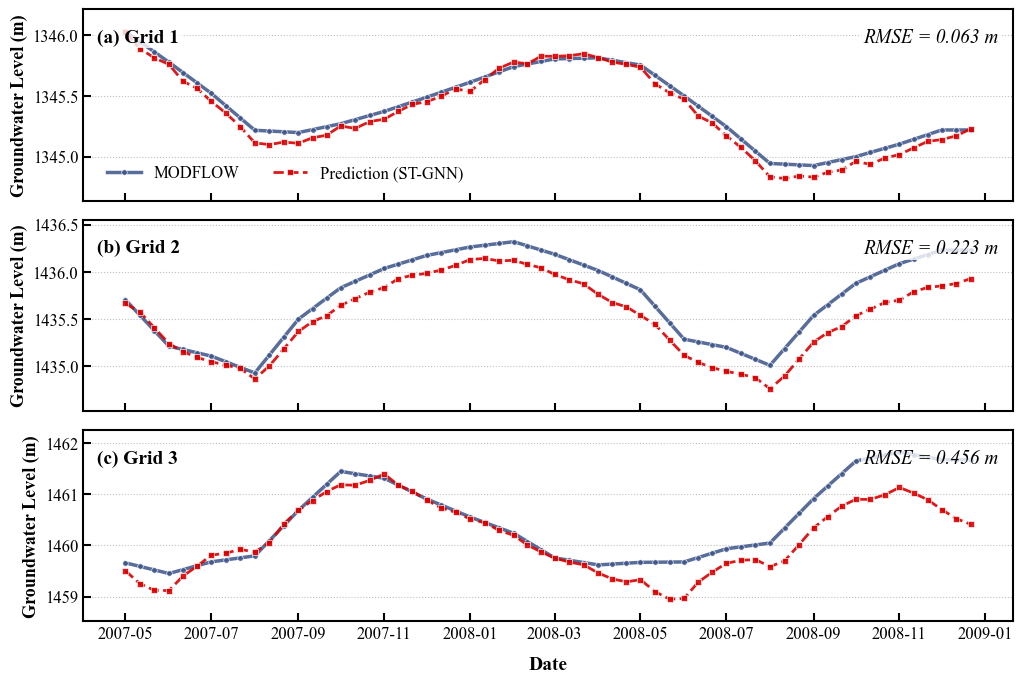

In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import os
from sklearn.metrics import mean_squared_error

# ==========================================
# 1. 全局学术风格设置 (Top-Tier Journal Style)
# ==========================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'  # 数学公式字体匹配
plt.rcParams['axes.linewidth'] = 1.5       # 加粗边框
plt.rcParams['xtick.major.width'] = 1.5    # 加粗刻度线
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['xtick.direction'] = 'in'     # 刻度向内
plt.rcParams['ytick.direction'] = 'in'
# 如果需要坐标轴支持中文，取消下一行注释
# plt.rcParams['axes.unicode_minus'] = False 

# 文件列表
files = [
    'weilai prediction_results_well_48_69.npz',
    'weilai prediction_results_well_81_117.npz',
    'weilai prediction_results_well_105_139.npz'
]

def plot_multiple_wells_subplots_aesthetic(file_list):
    num_files = len(file_list)
    
    # 创建画布：宽 12，高 3 * 文件数量 (调整为更符合期刊双栏排版的长宽比)
    fig, axes = plt.subplots(num_files, 1, figsize=(12, 3 * num_files), sharex=True)
    if num_files == 1:
        axes = [axes]
    
    # === 【Nature/Science 经典配色】 ===
    color_true = "#3C5488"  # 深钢蓝 (沉稳、代表真实观测)
    color_pred = "#DC0000"  # 经典深红 (醒目、代表模型预测)
    
    for i, filename in enumerate(file_list):
        if not os.path.exists(filename):
            print(f"警告: 文件 {filename} 不存在，跳过。")
            continue
            
        # 1. 加载数据
        data = np.load(filename, allow_pickle=True)
        dates = pd.to_datetime(data['dates'])
        preds = data['preds']
        trues = data['trues']
        
        # 2. 计算指标 (仅保留 RMSE)
        mask = ~np.isnan(trues) & ~np.isnan(preds)
        if mask.sum() > 0:
            rmse = np.sqrt(mean_squared_error(trues[mask], preds[mask]))
            metric_str = f"RMSE = {rmse:.3f} m"
        else:
            metric_str = "No Valid Data"

        # 3. 绘图
        ax = axes[i]
        
        # 画真实值：使用较粗的半透明实线，配合极小的圆点
        ax.plot(dates, trues, color=color_true, label='MODFLOW', 
                linewidth=2.5, marker='o', markersize=4, 
                markeredgecolor='white', markeredgewidth=0.5, alpha=0.85, zorder=2)
        
        # 画预测值：使用略细的虚线，确保真实值不被完全覆盖
        ax.plot(dates, preds, color=color_pred, label='Prediction (ST-GNN)', 
                linewidth=2, linestyle='--', marker='s', markersize=4, 
                markeredgecolor='white', markeredgewidth=0.5, alpha=0.9, zorder=3)
        
        # 4. 顶刊级排版：内嵌标签与指标
        # 左上角放置 (a) Grid 1
        panel_label = f"({chr(97+i)}) Grid {i + 1}"

        ax.text(0.015, 0.90, panel_label, transform=ax.transAxes, 
                fontsize=14, fontweight='bold', va='top', ha='left',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2)) # 加一点白色底色防遮挡
        
        # 右上角放置 RMSE 指标
        ax.text(0.985, 0.90, metric_str, transform=ax.transAxes,
                fontsize=14, fontstyle='italic', va='top', ha='right',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=2))
        
        # 5. 坐标轴与网格设置
        ax.set_ylabel("Groundwater Level (m)", fontsize=13, fontweight='bold')
        ax.tick_params(axis='both', which='major', labelsize=12, length=6)
        
        # 添加极轻微的水平网格线引导视觉
        ax.yaxis.grid(True, linestyle=':', alpha=0.5, color='gray')
        
        # 稍微调整Y轴范围，让曲线不顶格
        if mask.sum() > 0:
            y_min = min(np.min(trues[mask]), np.min(preds[mask]))
            y_max = max(np.max(trues[mask]), np.max(preds[mask]))
            margin = (y_max - y_min) * 0.15  # 留出 15% 空间给顶部的文字
            ax.set_ylim(y_min - margin, y_max + margin)

        # 仅在第一个子图绘制图例 (统一简洁)
        if i == 0:
            ax.legend(loc='lower left', fontsize=12, frameon=False, ncol=2, 
                      bbox_to_anchor=(0.01, 0.02))

    # 6. 统一设置X轴格式
    axes[-1].set_xlabel("Date", fontsize=14, fontweight='bold', labelpad=10)
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m')) # 通常到月即可
    
    # 为了避免日期标签重叠，可以让标签倾斜或减少刻度密度
    plt.gcf().autofmt_xdate(rotation=0, ha='center') 

    # 调整子图间距，去除多余留白
    plt.subplots_adjust(hspace=0.1)
    
    # 7. 保存高质量图片
    #plt.savefig('timeseries_aesthetic_top_tier.pdf', format='pdf', bbox_inches='tight')
    plt.savefig('timeseries_aesthetic_top_tier.png', dpi=300, bbox_inches='tight')
    
    print("图表已按照顶刊标准生成并保存！(含 PDF 与 PNG)")
    plt.show()

# 运行
if __name__ == "__main__":
    plot_multiple_wells_subplots_aesthetic(files)



--- 为未来预测构建输入样本 ---
使用历史数据的最后一个时间步: t = 755 (2006-12-21) 作为输入窗口的终点。
编码器输入时间步范围: 744 to 755
解码器/目标时间步范围: 756 to 767
计算时间步 t=755 的动态边属性...
边索引形状: torch.Size([2, 205642]), 边特征形状: torch.Size([205642, 7])
未来预测样本构建完成。

--- 开始非自回归（单次预测）的未来空间预测 ---
目标预测时间步 (0-indexed): [0, 3, 6, 9]
警告: 无法自动获取模型的预测长度，假设为12
执行单次前向传播以获取完整的未来12步预测...
从预测序列中提取目标月份的数据...
  ...捕获第 1 个月的预测结果 (时间步索引 0)
  ...捕获第 2 个月的预测结果 (时间步索引 3)
  ...捕获第 3 个月的预测结果 (时间步索引 6)
  ...捕获第 4 个月的预测结果 (时间步索引 9)
对捕获的预测结果进行反归一化...
图表已保存: ./spatial_forecast_perfect_replica.png


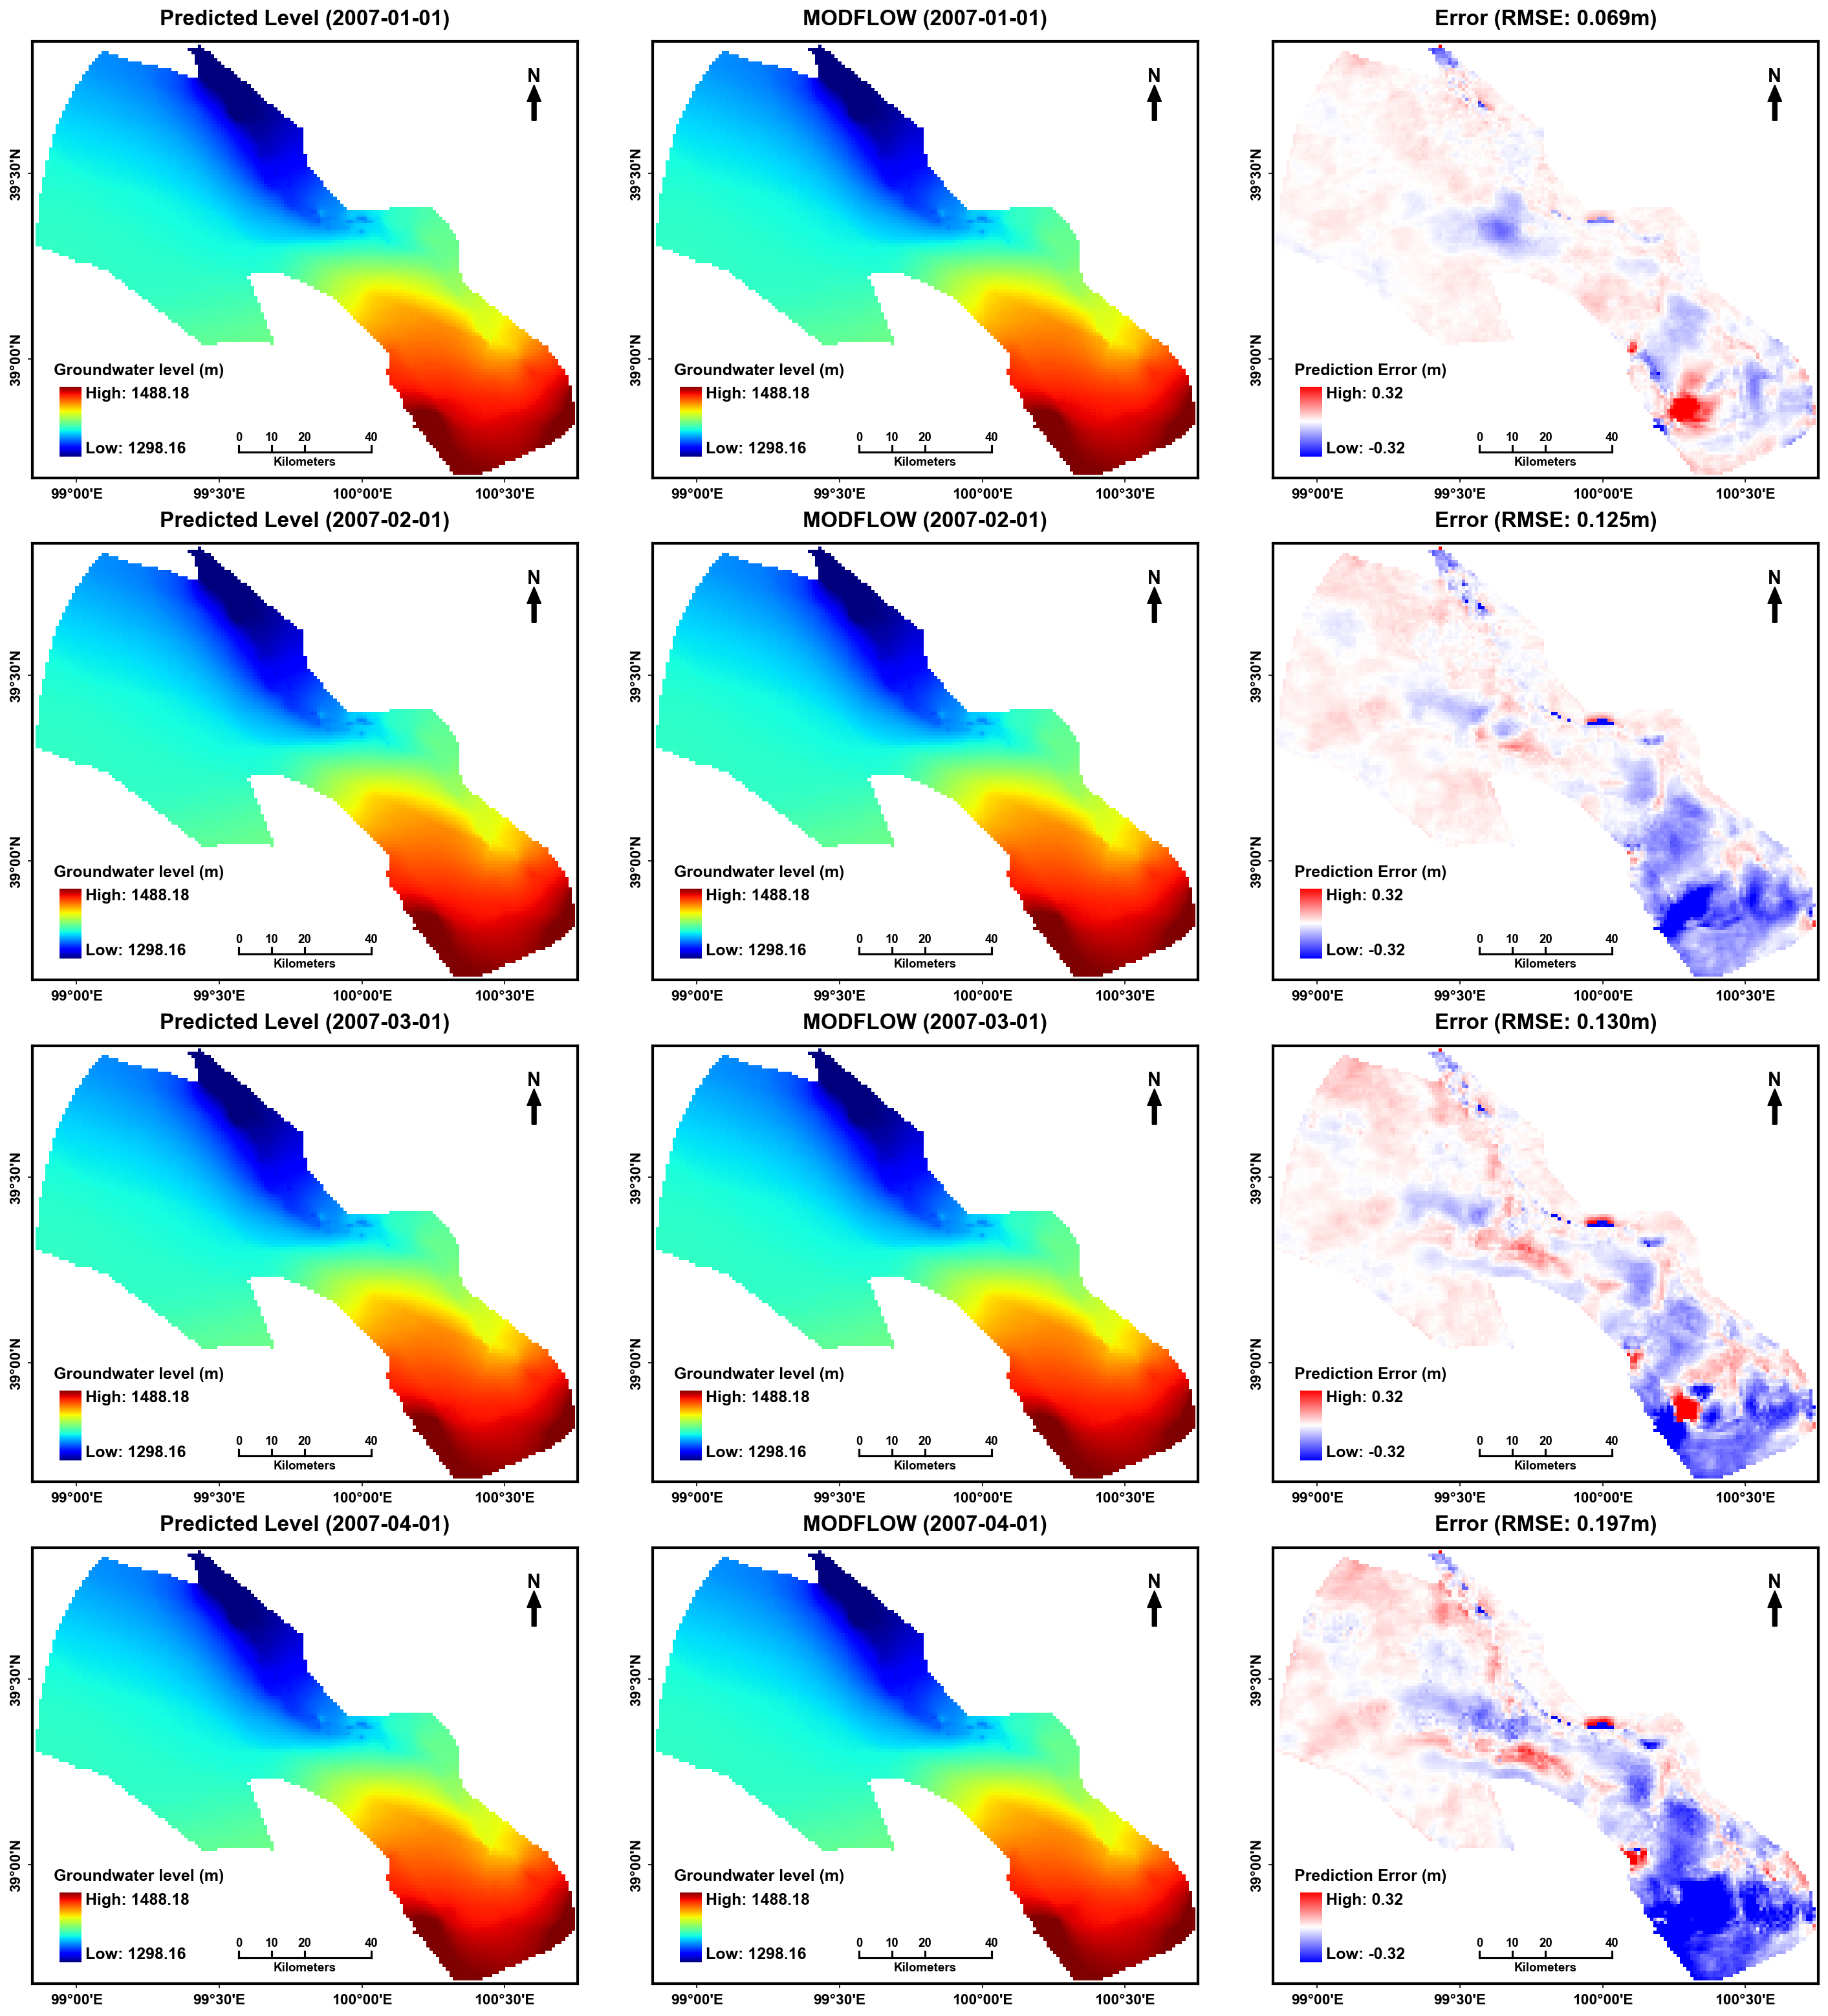

In [15]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from tqdm import tqdm
import numpy as np
import os
import torch
from torch_geometric.data import Data
from mpl_toolkits.axes_grid1 import make_axes_locatable

# =============================================================================
# --- 步骤 1: 创建一个函数来手动构建用于未来预测的单个Graph Data样本 ---
# =============================================================================
def create_forecast_sample(processor, t_last_historical):
    """
    根据历史数据的最后一个时间点，手动构建一个用于未来12步预测的Data对象。

    Args:
        processor (HydroDataProcessor): 预处理器实例。
        t_last_historical (int): 历史数据（训练+验证+测试集）的最后一个时间步索引。

    Returns:
        torch_geometric.data.Data: 一个为未来预测专门构建的图数据样本。
    """
    print(f"\n--- 为未来预测构建输入样本 ---")
    print(f"使用历史数据的最后一个时间步: t = {t_last_historical} ({processor.dates[t_last_historical].strftime('%Y-%m-%d')}) 作为输入窗口的终点。")

    num_nodes = len(processor.valid_coords[0])
    encoder_window_size = 12  # 与预处理时保持一致
    forecast_horizon = 12   # 与预处理时保持一致

    # --- a. 收集编码器输入序列 (从 t_last_historical-11 到 t_last_historical) ---
    encoder_indices = range(t_last_historical - encoder_window_size + 1, t_last_historical + 1)
    print(f"编码器输入时间步范围: {encoder_indices[0]} to {encoder_indices[-1]}")

    dynamic_encoder_seq, history_encoder_seq, time_encoder_seq = [], [], []
    for ts in encoder_indices:
        dynamic_encoder_seq.append(processor._rolling_normalization(ts))
        hist_level = processor.target_data[ts][processor.valid_coords]
        hist_level = np.nan_to_num(hist_level, nan=np.nanmean(hist_level))
        history_encoder_seq.append(processor.target_scaler.transform(hist_level.reshape(-1, 1)))
        time_encoder_seq.append(processor._encode_time(processor.dates[ts]))

    # --- b. 收集解码器输入和目标序列 (从 t_last_historical+1 到 t_last_historical+12) ---
    decoder_indices = range(t_last_historical + 1, t_last_historical + 1 + forecast_horizon)
    print(f"解码器/目标时间步范围: {decoder_indices[0]} to {decoder_indices[-1]}")

    target_y_seq, dynamic_decoder_seq, time_decoder_seq = [], [], []
    for ts in decoder_indices:
        target_level = processor.target_data[ts][processor.valid_coords]
        target_level = np.nan_to_num(target_level, nan=np.nanmean(target_level))
        target_y_seq.append(processor.target_scaler.transform(target_level.reshape(-1, 1)).flatten())
        dynamic_decoder_seq.append(processor._rolling_normalization(ts))
        time_decoder_seq.append(processor._encode_time(processor.dates[ts]))

    # --- c. 堆叠成Numpy数组 ---
    dtype = processor.dtype
    x_dynamic_encoder_arr = np.stack(dynamic_encoder_seq, axis=1)
    x_history_encoder_arr = np.stack(history_encoder_seq, axis=1)
    time_encoder_arr = np.array(time_encoder_seq)
    x_time_encoder_arr = np.tile(time_encoder_arr, (num_nodes, 1, 1))

    y_arr = np.stack(target_y_seq, axis=1)
    x_dynamic_decoder_arr = np.stack(dynamic_decoder_seq, axis=1)
    time_decoder_arr = np.array(time_decoder_seq)
    x_time_decoder_arr = np.tile(time_decoder_arr, (num_nodes, 1, 1))

    # --- d. 【关键修改】获取图结构：使用静态图基础 + 动态边属性 ---
    # 确保静态图已构建
    if not hasattr(processor, 'static_graph_cache') or processor.static_graph_cache is None:
        print("静态图缓存不存在，正在构建...")
        processor._build_static_graph_base()
    
    # 获取静态图结构
    edge_index, static_edge_features, _ = processor.static_graph_cache
    
    # 计算当前时间步的动态边属性
    print(f"计算时间步 t={t_last_historical} 的动态边属性...")
    dynamic_edge_attrs = processor._compute_dynamic_edge_attrs(t_last_historical)
    
    # 合并静态和动态边特征，保持与预处理时一致的7维特征
    # 原始顺序: [landuse, pump, irrig, river, grad, k_log, dist]
    final_edge_attr = torch.cat([
        static_edge_features[:, 0:1],  # landuse_w
        dynamic_edge_attrs[:, 0:3],    # pumping_effect, irrigation_effect, river_effect
        static_edge_features[:, 1:4]   # elevation_gradient, effective_k_log, norm_dist
    ], dim=1)
    
    print(f"边索引形状: {edge_index.shape}, 边特征形状: {final_edge_attr.shape}")

    # --- e. 创建PyG图数据对象 ---
    forecast_data_sample = Data(
        x_static=torch.tensor(processor.processed_static, dtype=dtype),
        x_dynamic_encoder=torch.tensor(x_dynamic_encoder_arr, dtype=dtype),
        x_history_encoder=torch.tensor(x_history_encoder_arr, dtype=dtype),
        x_time_encoder=torch.tensor(x_time_encoder_arr, dtype=dtype),
        y=torch.tensor(y_arr, dtype=dtype),
        x_dynamic_decoder=torch.tensor(x_dynamic_decoder_arr, dtype=dtype),
        x_time_decoder=torch.tensor(x_time_decoder_arr, dtype=dtype),
        edge_index=edge_index,
        edge_attr=final_edge_attr,  # 使用合并后的边特征
        grad=processor.ground_truth_grad,
        curv=processor.ground_truth_curv,
        coords=torch.tensor(np.array(processor.valid_coords).T, dtype=dtype),
        t=t_last_historical,
        date=processor.dates[t_last_historical]
    )
    forecast_data_sample.num_nodes = num_nodes

    print("未来预测样本构建完成。")
    return forecast_data_sample


# =============================================================================
# --- 步骤 2: 修改后的未来空间预测函数（支持自回归和非自回归两种模式） ---
# =============================================================================
def predict_future_spatial_non_autoregressive(model, future_prediction_data_sample, processor, device, months_to_visualize=[1, 2, 3, 4]):
    """
    使用非自回归模型预测未来的空间水位分布。
    """
    print("\n--- 开始非自回归（单次预测）的未来空间预测 ---")
    model.eval()

    # 假设每月有3个时间步，我们可视化每个月最后一个时间步的结果。
    # 月份 1 -> 索引 2, 月份 2 -> 索引 5, ...
    target_indices = [(m * 3) - 3 for m in months_to_visualize]
    print(f"目标预测时间步 (0-indexed): {target_indices}")

    # 检查模型的预测长度是否足够
    try:
        forecast_horizon = model.decoder.forecast_len
    except AttributeError:
        try:
            forecast_horizon = model.decoder_stacks[0][0].forecast_len
        except:
            print("警告: 无法自动获取模型的预测长度，假设为12")
            forecast_horizon = 12

    if forecast_horizon <= max(target_indices):
        print(f"错误：模型预测长度为 {forecast_horizon}, 不足以预测到第 {max(months_to_visualize)} 个月（需要索引 {max(target_indices)}）。")
        return {}, {}, {}

    spatial_predictions_norm = {}
    spatial_true_values_norm = {}
    prediction_dates = {}

    with torch.no_grad():
        data = future_prediction_data_sample.to(device)
        print("执行单次前向传播以获取完整的未来12步预测...")
        prediction_result = model.predict(data)

        prediction_sequence = prediction_result['output']
        true_sequence = data.y

        print("从预测序列中提取目标月份的数据...")
        for month in months_to_visualize:
            idx = (month * 3) - 3
            if idx < forecast_horizon:
                month_key = month
                print(f"  ...捕获第 {month_key} 个月的预测结果 (时间步索引 {idx})")

                spatial_predictions_norm[month_key] = prediction_sequence[:, idx].cpu().numpy()
                spatial_true_values_norm[month_key] = true_sequence[:, idx].cpu().numpy()

                # 日期计算
                global_date_index = data.t + 1 + idx
                if global_date_index < len(processor.dates):
                    prediction_dates[month_key] = processor.dates[global_date_index]
                else:
                    prediction_dates[month_key] = data.date

    print("对捕获的预测结果进行反归一化...")
    spatial_predictions_orig = {}
    spatial_true_values_orig = {}
    for month, pred_norm in spatial_predictions_norm.items():
        spatial_predictions_orig[month] = processor.inverse_transform(pred_norm.reshape(-1, 1)).flatten()
        true_norm = spatial_true_values_norm[month]
        spatial_true_values_orig[month] = processor.inverse_transform(true_norm.reshape(-1, 1)).flatten()

    return spatial_predictions_orig, spatial_true_values_orig, prediction_dates

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import os
import torch

# =============================================================================
# --- 步骤 0: 常量与配置 ---
# =============================================================================
LAT_START_DEG = 39 + 51/60.0  # Row 0
LAT_END_DEG = 38 + 41/60.0    # Row 131
LON_START_DEG = 98 + 51/60.0  # Col 0
LON_END_DEG = 100 + 45/60.0   # Col 164

N_ROWS_TOTAL = 132
N_COLS_TOTAL = 165

# 假设网格分辨率为1km，用于比例尺计算
GRID_RES_KM = 1.0 

# =============================================================================
# --- 步骤 1: 绘图组件函数 (核心修改部分) ---
# =============================================================================

def add_perfect_north_arrow(ax):
    """
    复刻图片中的指北针：右上角，N字在上，简单箭头在下
    """
    # 坐标系使用 axes fraction (0-1)
    # 位置设定在右上角
    x, y = 0.92, 0.90
    arrow_len = 0.08
    
    # 1. 画 'N' 字
    ax.text(x, y, 'N', transform=ax.transAxes, 
            ha='center', va='bottom', fontsize=14, fontweight='bold', color='black', zorder=100)
    
    # 2. 画箭头 (使用 annotate 绘制)
    # 箭头从下往上指 (xy是箭头尖端，xytext是尾端)
    ax.annotate('', xy=(x, y), xytext=(x, y - arrow_len),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(facecolor='black', width=3, headwidth=10, headlength=12),
                zorder=100)

def add_perfect_scale_bar(ax):
    """
    复刻图片中的比例尺：
    - 刻度: 0, 10, 20, 40 km
    - 样式: 线段，竖线刻度朝上
    - 位置: 底部居中
    """
    # 比例尺的总长度 (km)
    max_km = 40
    ticks_km = [0, 10, 20, 40]
    
    # 将 km 转换为 axes 比例 (0-1)
    # 地图总宽 N_COLS_TOTAL (165 km)
    map_width_km = N_COLS_TOTAL * GRID_RES_KM
    
    # 比例尺在图上的宽度比例
    bar_width_ratio = max_km / map_width_km
    
    # 确定起始位置 (底部居中)
    # x_center = 0.55 (稍微偏右一点以免撞到左边的图例)
    x_center = 0.50
    y_base = 0.06 # 底部高度
    
    x_start = x_center - (bar_width_ratio / 2)
    x_end = x_center + (bar_width_ratio / 2)
    
    # 1. 绘制主横线
    ax.plot([x_start, x_end], [y_base, y_base], transform=ax.transAxes, 
            color='black', linewidth=1.5, zorder=100)
    
    # 2. 绘制竖刻度和文字
    tick_height = 0.015 # 刻度线高度 (axes fraction)
    
    for km in ticks_km:
        # 计算当前刻度的相对x坐标
        # 当前km占总长(40km)的比例 -> 再映射到axes宽度
        km_ratio = km / map_width_km 
        x_tick = x_start + km_ratio
        
        # 画竖线 (朝上)
        ax.plot([x_tick, x_tick], [y_base, y_base + tick_height], transform=ax.transAxes, 
                color='black', linewidth=1.5, zorder=100)
        
        # 写数字 (在竖线上方)
        ax.text(x_tick, y_base + tick_height + 0.005, str(km), transform=ax.transAxes,
                ha='center', va='bottom', fontsize=9, fontweight='bold', color='black', zorder=100)
        
    # 3. 写单位 "Kilometers" (在比例尺下方居中)
    ax.text(x_center, y_base - 0.01, "Kilometers", transform=ax.transAxes,
            ha='center', va='top', fontsize=9, fontweight='bold', color='black', zorder=100)


def add_arcgis_style_legend(ax, im, vmin, vmax, title_text):
    """
    ArcGIS 风格图例 (保持之前满意的效果)
    """
    # 背景框
    rect = patches.Rectangle((0.02, 0.03), 0.35, 0.25, transform=ax.transAxes,
                             linewidth=0, facecolor='white', alpha=0.8, zorder=100)
    ax.add_patch(rect)

    # 嵌入色条
    axins = inset_axes(ax, width="4%", height="16%", loc='lower left',
                       bbox_to_anchor=(0.05, 0.05, 1, 1), bbox_transform=ax.transAxes, borderpad=0)
    axins.set_zorder(101)

    cbar = plt.colorbar(im, cax=axins, orientation='vertical')
    cbar.set_ticks([])
    cbar.outline.set_visible(False)

    # 文字
    ax.text(0.04, 0.23, title_text, transform=ax.transAxes, ha='left', va='bottom',
            fontsize=12, fontweight='bold', color='black', zorder=102, linespacing=1.2)
    axins.text(1.2, 1.0, f"High: {vmax:.2f}", transform=axins.transAxes,
               ha='left', va='top', fontsize=12, fontweight='bold', color='black', zorder=102)
    axins.text(1.2, 0.0, f"Low: {vmin:.2f}", transform=axins.transAxes,
               ha='left', va='bottom', fontsize=12, fontweight='bold', color='black', zorder=102)

# =============================================================================
# --- 步骤 2: 辅助函数 (坐标) ---
# =============================================================================
def decimal_to_dms_str(decimal_deg, is_lat=True):
    degrees = int(decimal_deg)
    minutes = round((abs(decimal_deg) - abs(degrees)) * 60)
    if minutes == 60:
        degrees += 1 if degrees >= 0 else -1
        minutes = 0
    direction = ('N' if degrees >= 0 else 'S') if is_lat else ('E' if degrees >= 0 else 'W')
    return f"{abs(degrees)}°{minutes:02d}'{direction}"

def lat_to_row_idx(target_lat):
    return ((target_lat - LAT_START_DEG) / (LAT_END_DEG - LAT_START_DEG)) * (N_ROWS_TOTAL - 1)

def lon_to_col_idx(target_lon):
    return ((target_lon - LON_START_DEG) / (LON_END_DEG - LON_START_DEG)) * (N_COLS_TOTAL - 1)

# =============================================================================
# --- 步骤 3: 主绘图函数 ---
# =============================================================================
def plot_spatial_predictions(predictions_dict, true_values_dict, dates_dict, processor, save_dir='./'):
    if not predictions_dict:
        return

    os.makedirs(save_dir, exist_ok=True)
    num_months = len(predictions_dict)
    sorted_months = sorted(predictions_dict.keys())

    # 刻度准备
    target_lats = [39 + 30/60.0, 39.0]
    target_lons = [99.0, 99 + 30/60.0, 100.0, 100 + 30/60.0]
    yticks_pos = [lat_to_row_idx(lat) for lat in target_lats]
    yticks_labels = [decimal_to_dms_str(lat, True) for lat in target_lats]
    xticks_pos = [lon_to_col_idx(lon) for lon in target_lons]
    xticks_labels = [decimal_to_dms_str(lon, False) for lon in target_lons]

    plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial'], 'font.size': 12, 'font.weight': 'bold', 'axes.linewidth': 2.0})

    # 数值范围
    all_values = np.concatenate([v for v in list(predictions_dict.values()) + list(true_values_dict.values())])
    vmin, vmax = np.nanpercentile(all_values, [2, 98])
    norm = colors.Normalize(vmin=vmin, vmax=vmax)

    all_errors = np.concatenate([predictions_dict[m] - true_values_dict[m] for m in predictions_dict.keys()])
    max_err = np.nanpercentile(np.abs(all_errors), 98)
    error_norm = colors.Normalize(vmin=-max_err, vmax=max_err)

    # 绘图循环
    fig = plt.figure(figsize=(24, 6.5 * num_months), dpi=150)
    gs = gridspec.GridSpec(num_months, 3, figure=fig, wspace=0.1, hspace=0.15)

    def style_axis(ax):
        ax.set_yticks(yticks_pos)
        ax.set_yticklabels(yticks_labels, fontweight='bold', fontsize=11, rotation='vertical', va='center') # 竖排Y轴
        ax.set_xticks(xticks_pos)
        ax.set_xticklabels(xticks_labels, fontweight='bold', fontsize=11)
        ax.set_ylim(N_ROWS_TOTAL - 0.5, -0.5)
        ax.set_xlim(-0.5, N_COLS_TOTAL - 0.5)
        for spine in ax.spines.values(): spine.set_linewidth(2.0)

    for i, month in enumerate(sorted_months):
        date_str = dates_dict[month].strftime('%Y-%m-%d')

        # --- A. 预测图 ---
        ax_pred = fig.add_subplot(gs[i, 0])
        im_p = ax_pred.imshow(np.full(processor.grid_shape, np.nan), cmap='jet', norm=norm) # Placeholder
        pred_map = np.full(processor.grid_shape, np.nan)
        pred_map[processor.valid_coords] = predictions_dict[month]
        im_p = ax_pred.imshow(pred_map, cmap='jet', norm=norm, interpolation='nearest')
        style_axis(ax_pred)
        ax_pred.set_title(f"Predicted Level ({date_str})", y=1.02, fontsize=16, fontweight='bold')
        
        # 添加图例、指北针、比例尺
        add_arcgis_style_legend(ax_pred, im_p, vmin, vmax, "Groundwater level (m)")
        add_perfect_north_arrow(ax_pred)
        add_perfect_scale_bar(ax_pred)

        # --- B. 真实值图 ---
        ax_true = fig.add_subplot(gs[i, 1])
        true_map = np.full(processor.grid_shape, np.nan)
        true_map[processor.valid_coords] = true_values_dict[month]
        im_t = ax_true.imshow(true_map, cmap='jet', norm=norm, interpolation='nearest')
        style_axis(ax_true)
        ax_true.set_title(f"MODFLOW ({date_str})", y=1.02, fontsize=16, fontweight='bold')
        
        add_arcgis_style_legend(ax_true, im_t, vmin, vmax, "Groundwater level (m)")
        add_perfect_north_arrow(ax_true)
        add_perfect_scale_bar(ax_true)

        # --- C. 误差图 ---
        ax_err = fig.add_subplot(gs[i, 2])
        error = predictions_dict[month] - true_values_dict[month]
        rmse = np.sqrt(np.nanmean(error**2))
        err_map = np.full(processor.grid_shape, np.nan)
        err_map[processor.valid_coords] = error
        im_e = ax_err.imshow(err_map, cmap='bwr', norm=error_norm, interpolation='nearest')
        style_axis(ax_err)
        ax_err.set_title(f"Error (RMSE: {rmse:.3f}m)", y=1.02, fontsize=16, fontweight='bold')
        
        add_arcgis_style_legend(ax_err, im_e, -max_err, max_err, "Prediction Error (m)")
        add_perfect_north_arrow(ax_err)
        add_perfect_scale_bar(ax_err)

    save_path = os.path.join(save_dir, 'spatial_forecast_perfect_replica.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"图表已保存: {save_path}")
    plt.show()
    plt.rcParams.update(plt.rcParamsDefault)





# =============================================================================
# --- 步骤 4: 主调用逻辑 ---
# =============================================================================

# 使用示例
if __name__ == "__main__":
    # 假设这些变量已在之前定义
    # trained_model, processor, device, raw_test_indices
    
    trained_model.to(device)
    trained_model.eval()

    if raw_test_indices:
        last_historical_timestep = raw_test_indices[-1]

        # 创建预测样本
        forecast_sample = create_forecast_sample(
            processor=processor,
            t_last_historical=last_historical_timestep
        )

        # 执行预测
        spatial_preds, spatial_trues, pred_dates = predict_future_spatial_non_autoregressive(
            model=trained_model,
            future_prediction_data_sample=forecast_sample,
            processor=processor,
            device=device,
            months_to_visualize=[1, 2, 3, 4]
        )

        # 可视化结果
        if spatial_preds:
            plot_spatial_predictions(
                predictions_dict=spatial_preds,
                true_values_dict=spatial_trues,
                dates_dict=pred_dates,
                processor=processor
            )
        else:
            print("未能生成空间预测结果，无法进行可视化。")
    else:
        print("`raw_test_indices` 为空，无法确定历史数据的终点，无法进行未来预测。")

--- 开始空间NSE评估与可视化 ---
正在对 76 个测试样本进行预测...


模型预测: 100%|██████████| 76/76 [00:42<00:00,  1.80it/s]



正在聚合数据并进行反归一化...
正在为每个空间节点计算NSE...


计算空间NSE: 100%|██████████| 8890/8890 [00:00<00:00, 16460.31it/s]



空间平均NSE (Step 1): -400.4541
空间平均NSE (Step 12): -550.2077

正在生成NSE空间分布图...
图像已保存为 'spatial_nse_step1_vs_step12.png'


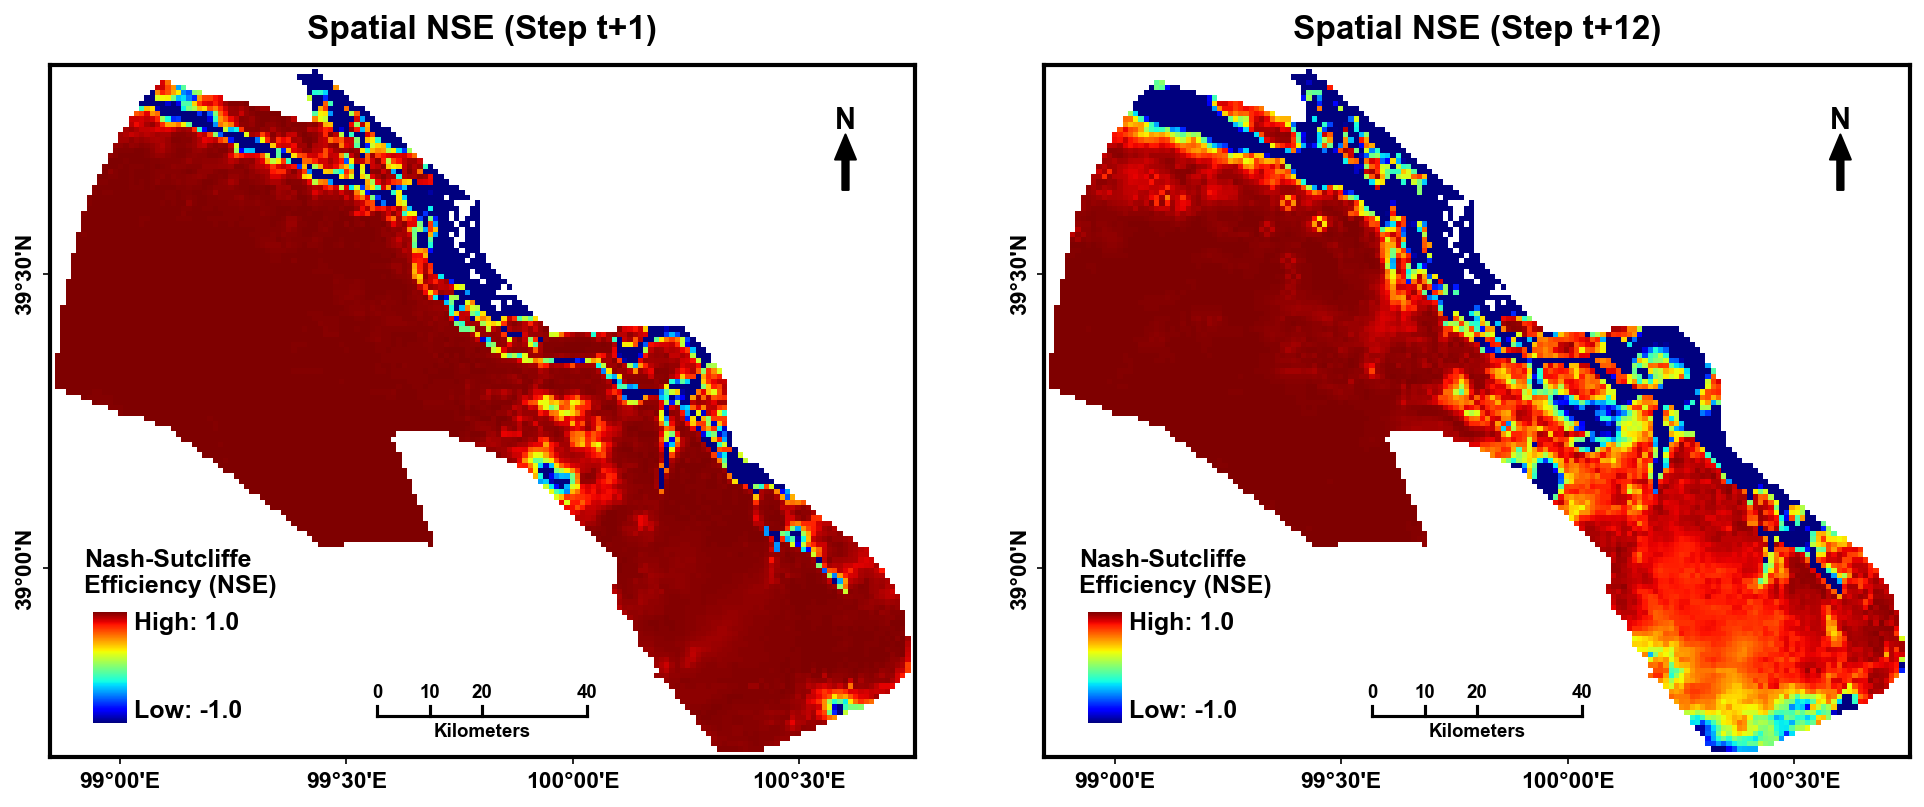

In [137]:
import numpy as np
import torch
from torch_geometric.loader import DataLoader
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from tqdm import tqdm
import warnings
import os

# 忽略运行时可能出现的除零警告
warnings.filterwarnings("ignore", category=RuntimeWarning)

# =============================================================================
# --- 1. 地理常量与配置 ---
# =============================================================================
LAT_START_DEG = 39 + 51/60.0  # Row 0
LAT_END_DEG = 38 + 41/60.0    # Row 131
LON_START_DEG = 98 + 51/60.0  # Col 0
LON_END_DEG = 100 + 45/60.0   # Col 164

N_ROWS_TOTAL = 132
N_COLS_TOTAL = 165
GRID_RES_KM = 1.0 

# =============================================================================
# --- 2. 绘图辅助函数 (保持样式一致) ---
# =============================================================================

def add_perfect_north_arrow(ax):
    """复刻指北针"""
    x, y = 0.92, 0.90
    arrow_len = 0.08
    ax.text(x, y, 'N', transform=ax.transAxes, 
            ha='center', va='bottom', fontsize=14, fontweight='bold', color='black', zorder=100)
    ax.annotate('', xy=(x, y), xytext=(x, y - arrow_len),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(facecolor='black', width=3, headwidth=10, headlength=12),
                zorder=100)

def add_perfect_scale_bar(ax):
    """复刻比例尺"""
    max_km = 40
    ticks_km = [0, 10, 20, 40]
    map_width_km = N_COLS_TOTAL * GRID_RES_KM
    bar_width_ratio = max_km / map_width_km
    
    x_center = 0.50
    y_base = 0.06 
    x_start = x_center - (bar_width_ratio / 2)
    x_end = x_center + (bar_width_ratio / 2)
    
    ax.plot([x_start, x_end], [y_base, y_base], transform=ax.transAxes, 
            color='black', linewidth=1.5, zorder=100)
    
    tick_height = 0.015
    for km in ticks_km:
        km_ratio = km / map_width_km 
        x_tick = x_start + km_ratio
        ax.plot([x_tick, x_tick], [y_base, y_base + tick_height], transform=ax.transAxes, 
                color='black', linewidth=1.5, zorder=100)
        ax.text(x_tick, y_base + tick_height + 0.005, str(km), transform=ax.transAxes,
                ha='center', va='bottom', fontsize=9, fontweight='bold', color='black', zorder=100)
        
    ax.text(x_center, y_base - 0.01, "Kilometers", transform=ax.transAxes,
            ha='center', va='top', fontsize=9, fontweight='bold', color='black', zorder=100)

def add_arcgis_style_legend(ax, im, vmin, vmax, title_text):
    """ArcGIS 风格嵌入式图例"""
    rect = patches.Rectangle((0.02, 0.03), 0.35, 0.25, transform=ax.transAxes,
                             linewidth=0, facecolor='white', alpha=0.8, zorder=100)
    ax.add_patch(rect)

    axins = inset_axes(ax, width="4%", height="16%", loc='lower left',
                       bbox_to_anchor=(0.05, 0.05, 1, 1), bbox_transform=ax.transAxes, borderpad=0)
    axins.set_zorder(101)

    cbar = plt.colorbar(im, cax=axins, orientation='vertical')
    cbar.set_ticks([])
    cbar.outline.set_visible(False)

    ax.text(0.04, 0.23, title_text, transform=ax.transAxes, ha='left', va='bottom',
            fontsize=12, fontweight='bold', color='black', zorder=102, linespacing=1.2)
    axins.text(1.2, 1.0, f"High: {vmax:.1f}", transform=axins.transAxes,
               ha='left', va='top', fontsize=12, fontweight='bold', color='black', zorder=102)
    axins.text(1.2, 0.0, f"Low: {vmin:.1f}", transform=axins.transAxes,
               ha='left', va='bottom', fontsize=12, fontweight='bold', color='black', zorder=102)

def decimal_to_dms_str(decimal_deg, is_lat=True):
    degrees = int(decimal_deg)
    minutes = round((abs(decimal_deg) - abs(degrees)) * 60)
    if minutes == 60:
        degrees += 1 if degrees >= 0 else -1
        minutes = 0
    direction = ('N' if degrees >= 0 else 'S') if is_lat else ('E' if degrees >= 0 else 'W')
    return f"{abs(degrees)}°{minutes:02d}'{direction}"

def lat_to_row_idx(target_lat):
    return ((target_lat - LAT_START_DEG) / (LAT_END_DEG - LAT_START_DEG)) * (N_ROWS_TOTAL - 1)

def lon_to_col_idx(target_lon):
    return ((target_lon - LON_START_DEG) / (LON_END_DEG - LON_START_DEG)) * (N_COLS_TOTAL - 1)


# =============================================================================
# --- 3. 核心计算与绘图 (修改了Step 12的逻辑) ---
# =============================================================================

def calculate_nse(predictions, targets):
    """计算纳什效率系数 (NSE)"""
    if np.var(targets) == 0:
        return np.nan
    nse = 1 - (np.sum((targets - predictions) ** 2) / np.sum((targets - np.mean(targets)) ** 2))
    return nse

def calculate_and_visualize_spatial_nse(model, test_data, processor, device):
    """
    对Seq2Seq模型进行空间NSE评估。
    图1: 第1步预测 (t+1)
    图2: 第12步预测 (t+12) [已修改]
    """
    print("--- 开始空间NSE评估与可视化 ---")
    model.eval()
    model.to(device)

    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

    # 1. 收集预测值和真实值
    all_preds_norm_list = []
    all_actuals_norm_list = []

    print(f"正在对 {len(test_data)} 个测试样本进行预测...")
    with torch.no_grad():
        for data in tqdm(test_loader, desc="模型预测"):
            data = data.to(device)
            predictions = model.predict(data)
            all_preds_norm_list.append(predictions['output'].cpu().numpy())
            all_actuals_norm_list.append(data.y.cpu().numpy())

    if not all_preds_norm_list:
        print("错误：未能生成任何预测结果。")
        return

    # 2. 数据聚合与反归一化
    print("\n正在聚合数据并进行反归一化...")
    preds_cube_norm = np.stack(all_preds_norm_list, axis=0)
    actuals_cube_norm = np.stack(all_actuals_norm_list, axis=0)
    num_samples, num_nodes, forecast_horizon = preds_cube_norm.shape
    
    # 检查是否有足够的步长进行第12步预测
    if forecast_horizon < 12:
        print(f"警告: 预测步长为 {forecast_horizon}，不足12步，无法计算 Step 12 NSE。")
        return

    preds_flat_orig = processor.inverse_transform(preds_cube_norm.flatten().reshape(-1, 1))
    actuals_flat_orig = processor.inverse_transform(actuals_cube_norm.flatten().reshape(-1, 1))

    preds_cube_orig = preds_flat_orig.reshape(num_samples, num_nodes, forecast_horizon)
    actuals_cube_orig = actuals_flat_orig.reshape(num_samples, num_nodes, forecast_horizon)

    # 3. 计算NSE (修改处)
    print("正在为每个空间节点计算NSE...")
    node_coords = test_data[0].coords.cpu().numpy()
    grid_shape = processor.grid_shape
    
    nse_grid_step1 = np.full(grid_shape, np.nan, dtype=np.float32)
    nse_grid_step12 = np.full(grid_shape, np.nan, dtype=np.float32) # 重命名变量

    for i in tqdm(range(num_nodes), desc="计算空间NSE"):
        row, col = int(node_coords[i, 0]), int(node_coords[i, 1])
        node_preds_series = preds_cube_orig[:, i, :]
        node_actuals_series = actuals_cube_orig[:, i, :]

        # --- Step 1 NSE (索引 0) ---
        nse_grid_step1[row, col] = calculate_nse(node_preds_series[:, 0], node_actuals_series[:, 0])
        
        # --- Step 12 NSE (索引 11) --- [修改点]
        # 使用切片 [:, 11] 获取所有样本的第12个预测步
        nse_grid_step12[row, col] = calculate_nse(node_preds_series[:, 11], node_actuals_series[:, 11])
        
    print(f"\n空间平均NSE (Step 1): {np.nanmean(nse_grid_step1):.4f}")
    print(f"空间平均NSE (Step 12): {np.nanmean(nse_grid_step12):.4f}")

    # =========================================================================
    # --- 4. 可视化 (样式保持 Code 2 风格) ---
    # =========================================================================
    print("\n正在生成NSE空间分布图...")

    plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial'], 'font.size': 12, 'font.weight': 'bold', 'axes.linewidth': 2.0})

    target_lats = [39 + 30/60.0, 39.0]
    target_lons = [99.0, 99 + 30/60.0, 100.0, 100 + 30/60.0]
    yticks_pos = [lat_to_row_idx(lat) for lat in target_lats]
    yticks_labels = [decimal_to_dms_str(lat, True) for lat in target_lats]
    xticks_pos = [lon_to_col_idx(lon) for lon in target_lons]
    xticks_labels = [decimal_to_dms_str(lon, False) for lon in target_lons]

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=150)
    plt.subplots_adjust(wspace=0.15) 

    def style_axis_local(ax):
        ax.set_yticks(yticks_pos)
        ax.set_yticklabels(yticks_labels, fontweight='bold', fontsize=11, rotation='vertical', va='center')
        ax.set_xticks(xticks_pos)
        ax.set_xticklabels(xticks_labels, fontweight='bold', fontsize=11)
        ax.set_ylim(N_ROWS_TOTAL - 0.5, -0.5)
        ax.set_xlim(-0.5, N_COLS_TOTAL - 0.5)
        for spine in ax.spines.values(): spine.set_linewidth(2.0)

    # NSE 参数
    cmap = 'jet' 
    vmin, vmax = -1.0, 1.0
    valid_mask = processor.valid_mask

    # --- 绘图 1: Step 1 NSE ---
    ax1 = axes[0]
    nse_map1 = np.full(processor.grid_shape, np.nan)
    nse_map1[valid_mask] = nse_grid_step1[valid_mask]
    
    im1 = ax1.imshow(nse_map1, cmap=cmap, vmin=vmin, vmax=vmax, interpolation='nearest')
    style_axis_local(ax1)
    ax1.set_title('Spatial NSE (Step t+1)', y=1.02, fontsize=16, fontweight='bold')

    add_arcgis_style_legend(ax1, im1, vmin, vmax, "Nash-Sutcliffe\nEfficiency (NSE)")
    add_perfect_north_arrow(ax1)
    add_perfect_scale_bar(ax1)

    # --- 绘图 2: Step 12 NSE (修改点) ---
    ax2 = axes[1]
    nse_map2 = np.full(processor.grid_shape, np.nan)
    nse_map2[valid_mask] = nse_grid_step12[valid_mask]

    im2 = ax2.imshow(nse_map2, cmap=cmap, vmin=vmin, vmax=vmax, interpolation='nearest')
    style_axis_local(ax2)
    # 标题修改
    ax2.set_title('Spatial NSE (Step t+12)', y=1.02, fontsize=16, fontweight='bold')

    add_arcgis_style_legend(ax2, im2, vmin, vmax, "Nash-Sutcliffe\nEfficiency (NSE)")
    add_perfect_north_arrow(ax2)
    add_perfect_scale_bar(ax2)

    save_path = "spatial_nse_step1_vs_step12.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"图像已保存为 '{save_path}'")
    plt.show()
    plt.rcParams.update(plt.rcParamsDefault)

# =============================================================================
# 调用代码
# =============================================================================
try:
    if 'trained_model' in locals() and 'test' in locals() and 'processor' in locals() and 'device' in locals():
        calculate_and_visualize_spatial_nse(
            model=trained_model,
            test_data=test,
            processor=processor,
            device=device
        )
    else:
        print("注意：未检测到 'trained_model' 等变量，如果是作为模块导入请忽略此消息。")
except Exception as e:
    print(f"发生错误: {e}")

数据集索引范围：
  训练集: 0 - 600
  验证集: 601 - 668
  测试集: 669 - 744

--- 开始在测试集上进行非自回归(逐月)空间预测 ---


逐月预测:  25%|██▌       | 1/4 [00:00<00:02,  1.33it/s]

月份 1: 全局索引=669, 输入窗口结束于时间步 680 (2004-11-21 00:00:00), 预测时间步 681 (2004-12-01 00:00:00)


逐月预测:  50%|█████     | 2/4 [00:01<00:01,  1.61it/s]

月份 2: 全局索引=670, 输入窗口结束于时间步 681 (2004-12-01 00:00:00), 预测时间步 682 (2004-12-11 08:00:00)


逐月预测:  75%|███████▌  | 3/4 [00:01<00:00,  1.73it/s]

月份 3: 全局索引=671, 输入窗口结束于时间步 682 (2004-12-11 08:00:00), 预测时间步 683 (2004-12-21 16:00:00)


逐月预测: 100%|██████████| 4/4 [00:02<00:00,  1.71it/s]

月份 4: 全局索引=672, 输入窗口结束于时间步 683 (2004-12-21 16:00:00), 预测时间步 684 (2005-01-01 00:00:00)
对捕获的预测结果进行逆标准化...


图表已保存: ./spatial_forecast_perfect_replica.png


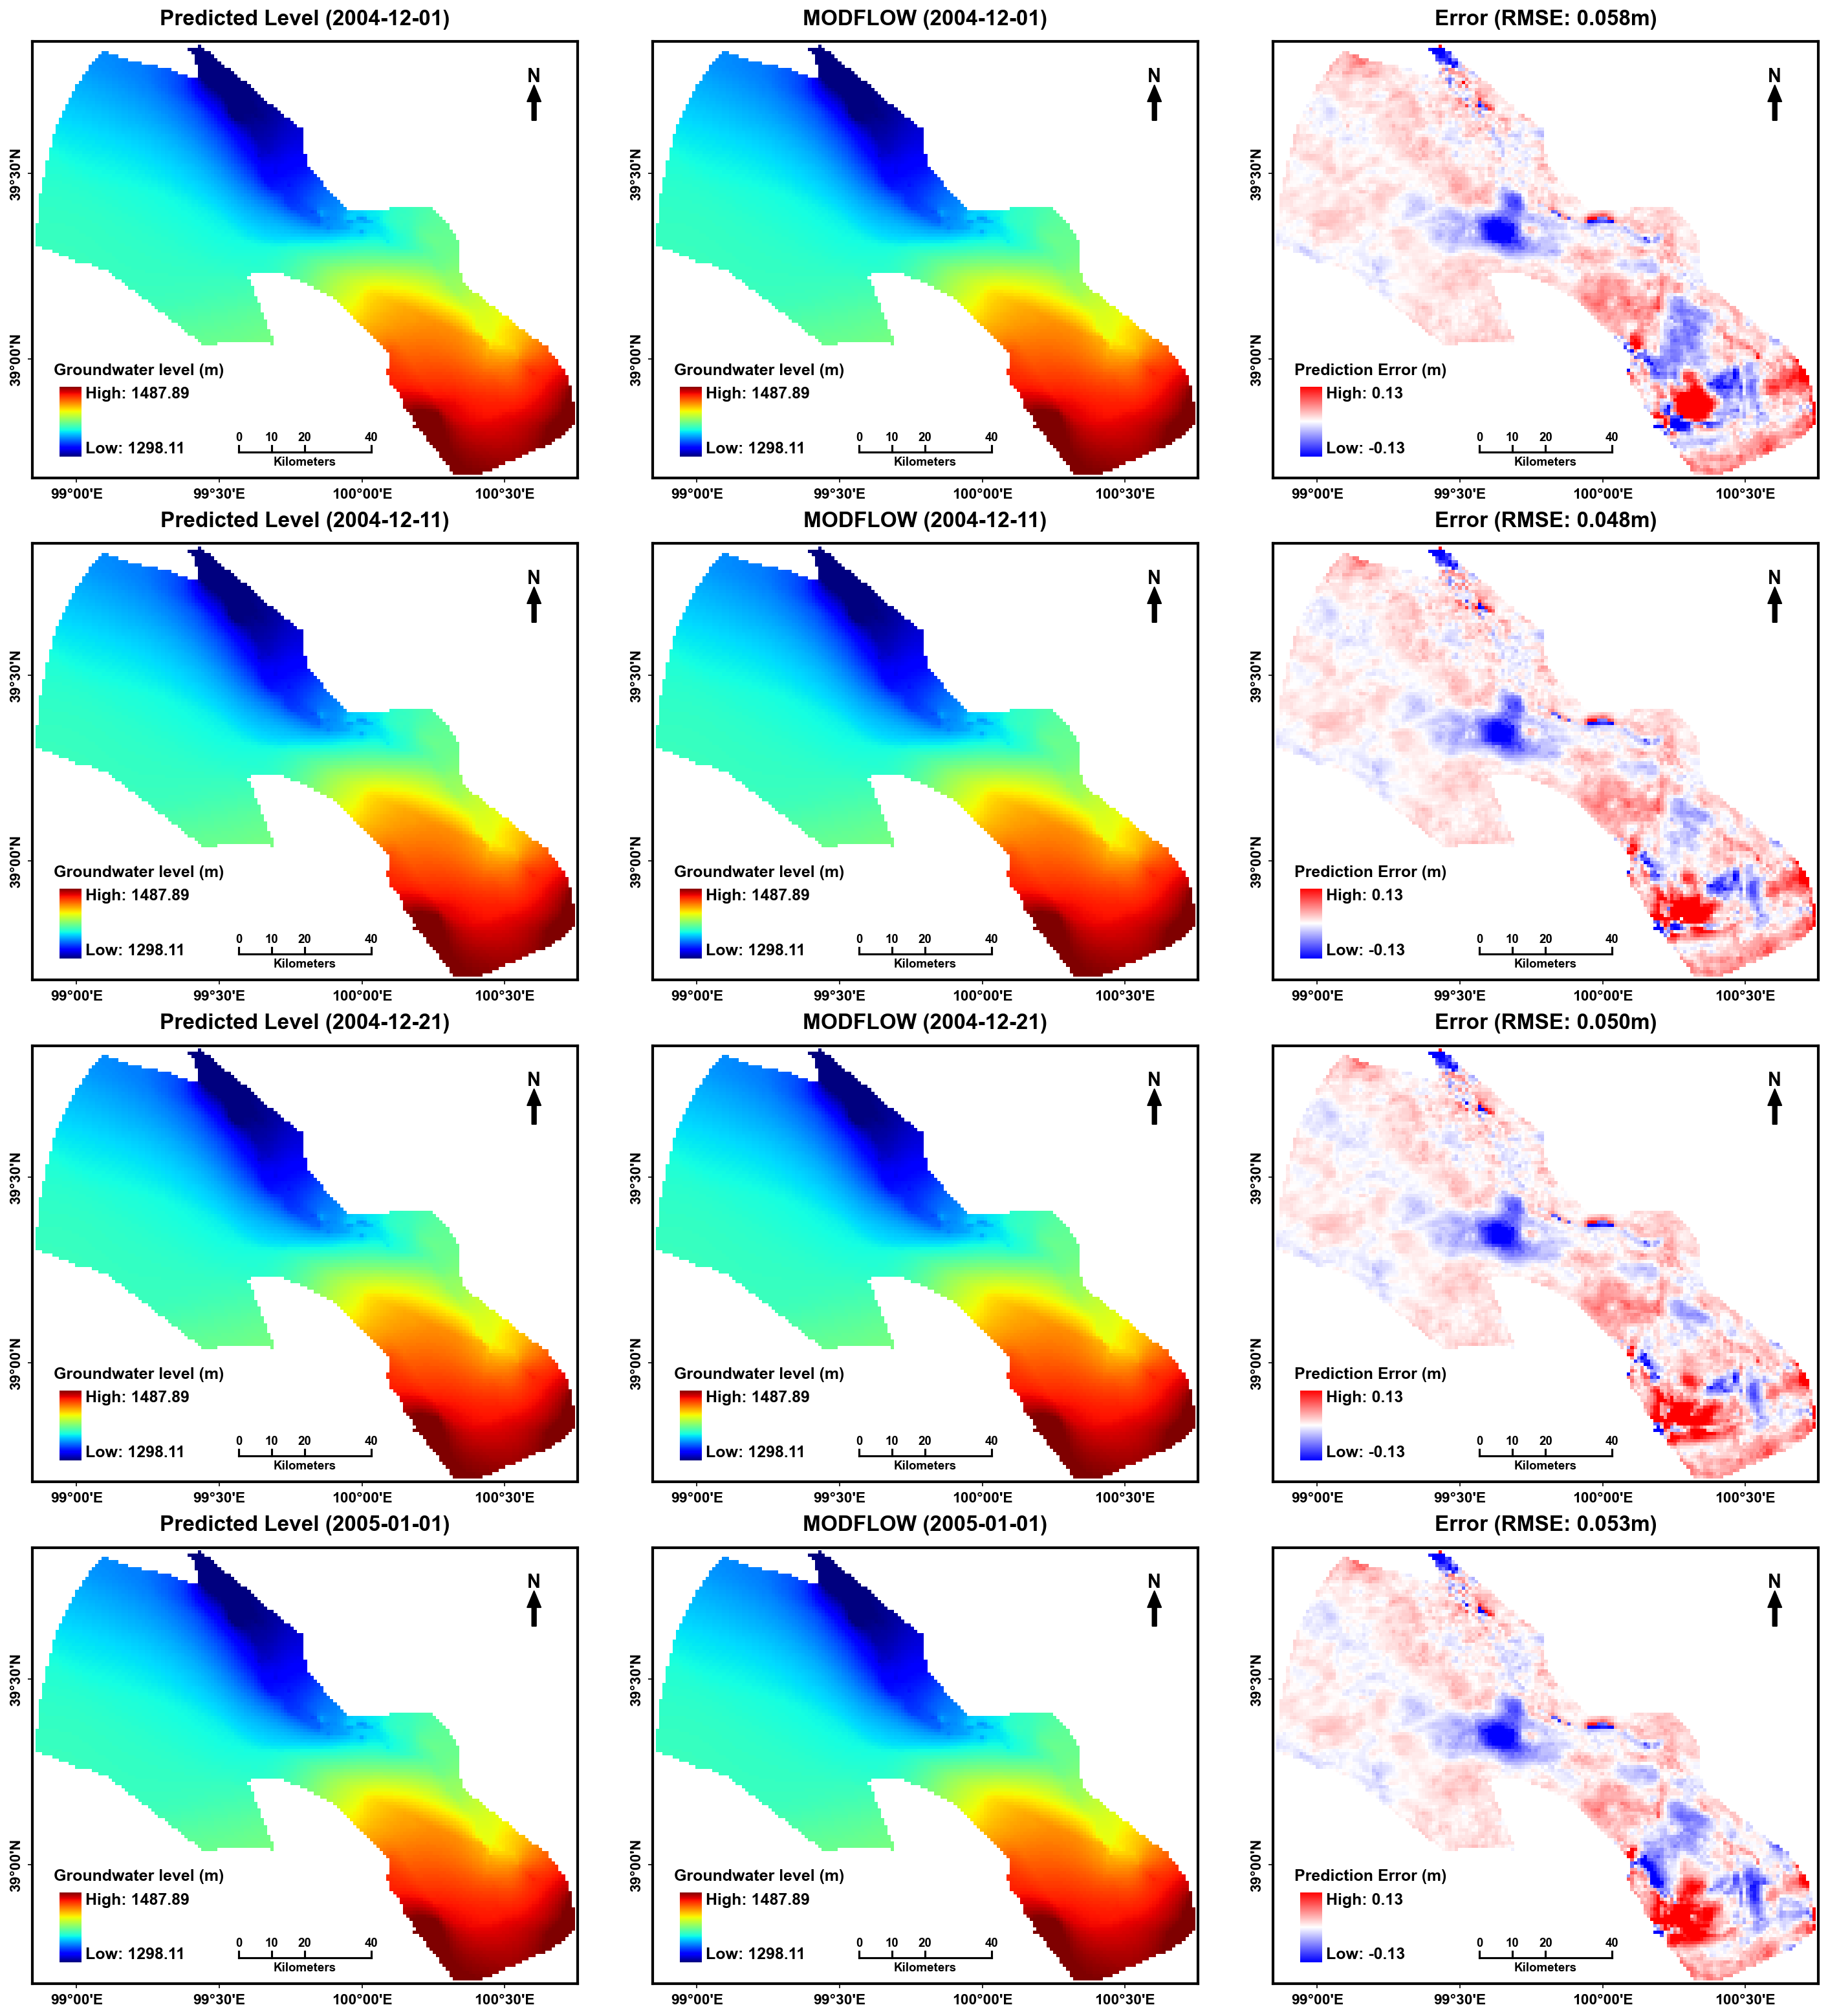

In [16]:
def predict_test_set_step_by_step(model, test_data, processor, device, 
                                  test_start_idx=0,  # 新增参数
                                  months_to_visualize=[1, 2, 3, 4]):
    """
    使用非自回归方式,逐月预测测试集数据并收集结果。
    
    Args:
        test_start_idx: 测试集在完整图数据列表中的起始索引
    """
    print("\n--- 开始在测试集上进行非自回归(逐月)空间预测 ---")
    if not months_to_visualize:
        print("未指定需要可视化的月份。")
        return {}, {}, {}

    # 确定需要预测的样本索引
    target_indices = [m - 1 for m in months_to_visualize]
    
    max_index = max(target_indices)
    if len(test_data) <= max_index:
        print(f"错误: 测试集长度为 {len(test_data)}, 不足以预测到第 {max(months_to_visualize)} 月。")
        return {}, {}, {}
        
    model.eval()
    
    predictions_norm = {}
    true_values_norm = {}
    prediction_dates = {}

    with torch.no_grad():
        for local_t in tqdm(target_indices, desc="逐月预测"):
            data_sample = test_data[local_t].to(device)
            
            # 使用模型进行一次完整的Seq2Seq预测
            prediction_sequence = model.predict(data_sample)
            
            # 1. 提取预测序列的第一个点 (t+1 时刻)
            prediction_t_plus_1 = prediction_sequence['output'][:, 0].cpu().numpy()
            
            # 2. 提取对应的真实值
            true_value_t_plus_1 = data_sample.y[:, 0].cpu().numpy()
            
            # ===== 关键修改: 计算全局索引 =====
            global_idx = test_start_idx + local_t
            
            # 方法1: 从 metadata 中获取
            if global_idx < len(processor.window_metadata):
                sample_metadata = processor.window_metadata[global_idx]
                input_end_timestep = sample_metadata['t']
                predicted_timestep = input_end_timestep + 1
                
                if predicted_timestep < len(processor.dates):
                    predicted_date = processor.dates[predicted_timestep]
                else:
                    last_date = processor.dates[input_end_timestep]
                    predicted_date = last_date + datetime.timedelta(days=10)
            else:
                # 备用方案：直接从data_sample获取
                predicted_date = data_sample.date
            
            print(f"月份 {local_t+1}: 全局索引={global_idx}, "
                  f"输入窗口结束于时间步 {input_end_timestep} ({processor.dates[input_end_timestep]}), "
                  f"预测时间步 {predicted_timestep} ({predicted_date})")
            # ===== 修改结束 =====

            # 使用月份作为key来存储
            month_key = local_t + 1
            predictions_norm[month_key] = prediction_t_plus_1
            true_values_norm[month_key] = true_value_t_plus_1
            prediction_dates[month_key] = predicted_date

    # 对收集到的所有结果进行逆标准化
    print("对捕获的预测结果进行逆标准化...")
    predictions_orig = {m: processor.inverse_transform(p) for m, p in predictions_norm.items()}
    true_values_orig = {m: processor.inverse_transform(t) for m, t in true_values_norm.items()}

    return predictions_orig, true_values_orig, prediction_dates
# 1. 计算测试集在完整图数据列表中的起始索引
test_start_global_idx = len(train) + len(val)

print(f"数据集索引范围：")
print(f"  训练集: 0 - {len(train)-1}")
print(f"  验证集: {len(train)} - {len(train)+len(val)-1}")
print(f"  测试集: {test_start_global_idx} - {test_start_global_idx+len(test)-1}")

# 2. 调用修正后的预测函数
spatial_preds_test, spatial_trues_test, pred_dates_test = predict_test_set_step_by_step(
    model=trained_model,
    test_data=test,
    processor=processor,
    device=device,
    test_start_idx=test_start_global_idx,  # 传入正确的起始索引
    months_to_visualize=[1, 2, 3, 4]
)

# 3. 可视化
if spatial_preds_test:
    plot_spatial_predictions(
        predictions_dict=spatial_preds_test,
        true_values_dict=spatial_trues_test,
        dates_dict=pred_dates_test,
        processor=processor,
        save_dir='./'
    )
else:
    print("未能生成测试集的空间预测结果，无法进行可视化。")


--- 开始空间RMSE评估与可视化 ---
正在对 76 个测试样本进行预测...


模型预测: 100%|██████████| 76/76 [00:42<00:00,  1.80it/s]



正在聚合数据并进行反归一化...
正在为每个空间节点计算RMSE...


计算空间RMSE: 100%|██████████| 8890/8890 [00:02<00:00, 3241.32it/s]


正在生成RMSE空间分布图...

空间RMSE评估完成，图像已保存为 'spatial_rmse_step1_vs_step12.png'


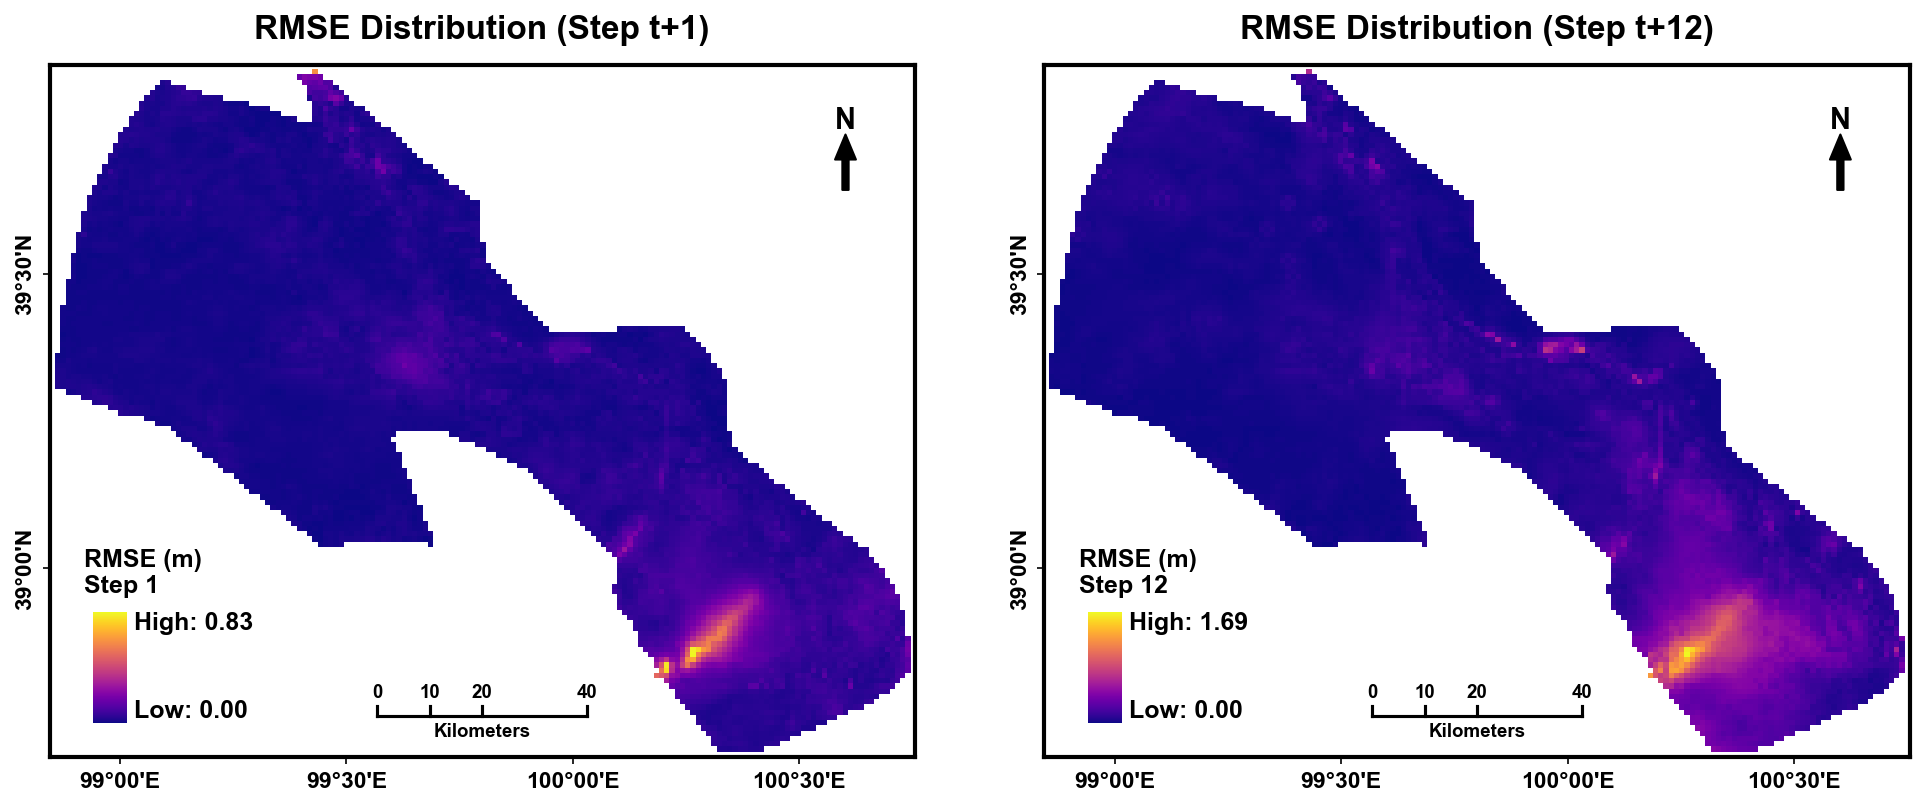

In [138]:
import numpy as np
import torch
from torch_geometric.loader import DataLoader
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from tqdm import tqdm
from sklearn.metrics import mean_squared_error
import warnings
import os

# 忽略运行时可能出现的警告
warnings.filterwarnings("ignore", category=RuntimeWarning)

# =============================================================================
# --- 1. 地理常量与配置 (保持风格统一) ---
# =============================================================================
LAT_START_DEG = 39 + 51/60.0  # Row 0
LAT_END_DEG = 38 + 41/60.0    # Row 131
LON_START_DEG = 98 + 51/60.0  # Col 0
LON_END_DEG = 100 + 45/60.0   # Col 164

N_ROWS_TOTAL = 132
N_COLS_TOTAL = 165
GRID_RES_KM = 1.0 

# =============================================================================
# --- 2. 绘图辅助函数 (保持风格统一) ---
# =============================================================================

def decimal_to_dms_str(decimal_deg, is_lat=True):
    """将十进制度数转换为度分秒字符串"""
    degrees = int(decimal_deg)
    minutes = round((abs(decimal_deg) - abs(degrees)) * 60)
    if minutes == 60:
        degrees += 1 if degrees >= 0 else -1
        minutes = 0
    direction = ('N' if degrees >= 0 else 'S') if is_lat else ('E' if degrees >= 0 else 'W')
    return f"{abs(degrees)}°{minutes:02d}'{direction}"

def lat_to_row_idx(target_lat):
    return ((target_lat - LAT_START_DEG) / (LAT_END_DEG - LAT_START_DEG)) * (N_ROWS_TOTAL - 1)

def lon_to_col_idx(target_lon):
    return ((target_lon - LON_START_DEG) / (LON_END_DEG - LON_START_DEG)) * (N_COLS_TOTAL - 1)

def add_perfect_north_arrow(ax):
    """复刻指北针"""
    x, y = 0.92, 0.90
    arrow_len = 0.08
    ax.text(x, y, 'N', transform=ax.transAxes, 
            ha='center', va='bottom', fontsize=14, fontweight='bold', color='black', zorder=100)
    ax.annotate('', xy=(x, y), xytext=(x, y - arrow_len),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(facecolor='black', width=3, headwidth=10, headlength=12),
                zorder=100)

def add_perfect_scale_bar(ax):
    """复刻比例尺"""
    max_km = 40
    ticks_km = [0, 10, 20, 40]
    map_width_km = N_COLS_TOTAL * GRID_RES_KM
    bar_width_ratio = max_km / map_width_km
    x_center = 0.50
    y_base = 0.06
    x_start = x_center - (bar_width_ratio / 2)
    x_end = x_center + (bar_width_ratio / 2)
    
    ax.plot([x_start, x_end], [y_base, y_base], transform=ax.transAxes, 
            color='black', linewidth=1.5, zorder=100)
    
    tick_height = 0.015
    for km in ticks_km:
        km_ratio = km / map_width_km 
        x_tick = x_start + km_ratio
        ax.plot([x_tick, x_tick], [y_base, y_base + tick_height], transform=ax.transAxes, 
                color='black', linewidth=1.5, zorder=100)
        ax.text(x_tick, y_base + tick_height + 0.005, str(km), transform=ax.transAxes,
                ha='center', va='bottom', fontsize=9, fontweight='bold', color='black', zorder=100)
        
    ax.text(x_center, y_base - 0.01, "Kilometers", transform=ax.transAxes,
            ha='center', va='top', fontsize=9, fontweight='bold', color='black', zorder=100)

def add_arcgis_style_legend(ax, im, vmin, vmax, title_text):
    """复刻ArcGIS风格图例"""
    rect = patches.Rectangle((0.02, 0.03), 0.35, 0.25, transform=ax.transAxes,
                             linewidth=0, facecolor='white', alpha=0.8, zorder=100)
    ax.add_patch(rect)

    axins = inset_axes(ax, width="4%", height="16%", loc='lower left',
                       bbox_to_anchor=(0.05, 0.05, 1, 1), bbox_transform=ax.transAxes, borderpad=0)
    axins.set_zorder(101)

    cbar = plt.colorbar(im, cax=axins, orientation='vertical')
    cbar.set_ticks([])
    cbar.outline.set_visible(False)

    ax.text(0.04, 0.23, title_text, transform=ax.transAxes, ha='left', va='bottom',
            fontsize=12, fontweight='bold', color='black', zorder=102, linespacing=1.2)
    axins.text(1.2, 1.0, f"High: {vmax:.2f}", transform=axins.transAxes,
               ha='left', va='top', fontsize=12, fontweight='bold', color='black', zorder=102)
    axins.text(1.2, 0.0, f"Low: {vmin:.2f}", transform=axins.transAxes,
               ha='left', va='bottom', fontsize=12, fontweight='bold', color='black', zorder=102)


# =============================================================================
# --- 步骤 2: 核心计算与绘图 (修改了Step 12的逻辑) ---
# =============================================================================

def calculate_rmse(predictions, targets):
    """计算均方根误差 (RMSE)"""
    return np.sqrt(mean_squared_error(targets, predictions))

def calculate_and_visualize_spatial_rmse(model, test_data, processor, device):
    """
    对Seq2Seq模型进行空间RMSE评估。
    图1: 第1步预测 (t+1)
    图2: 第12步预测 (t+12) [已修改]
    """
    print("--- 开始空间RMSE评估与可视化 ---")
    model.eval()
    model.to(device)

    test_loader = DataLoader(test_data, batch_size=1, shuffle=False)

    # 1. 收集所有样本的预测和真实值
    all_preds_norm_list = []
    all_actuals_norm_list = []

    print(f"正在对 {len(test_data)} 个测试样本进行预测...")
    with torch.no_grad():
        for data in tqdm(test_loader, desc="模型预测"):
            data = data.to(device)
            predictions = model.predict(data)
            pred_output_seq = predictions['output'].cpu().numpy()
            actual_output_seq = data.y.cpu().numpy()
            all_preds_norm_list.append(pred_output_seq)
            all_actuals_norm_list.append(actual_output_seq)

    if not all_preds_norm_list:
        print("错误：未能生成任何预测结果。")
        return

    # 2. 数据聚合与反归一化
    print("\n正在聚合数据并进行反归一化...")
    preds_cube_norm = np.stack(all_preds_norm_list, axis=0)
    actuals_cube_norm = np.stack(all_actuals_norm_list, axis=0)
    num_samples, num_nodes, forecast_horizon = preds_cube_norm.shape

    # 检查是否有足够的步长进行第12步预测
    if forecast_horizon < 12:
        print(f"警告: 预测步长为 {forecast_horizon}，不足12步，无法计算 Step 12 RMSE。")
        return

    preds_flat_norm = preds_cube_norm.flatten().reshape(-1, 1)
    actuals_flat_norm = actuals_cube_norm.flatten().reshape(-1, 1)

    preds_flat_orig = processor.inverse_transform(preds_flat_norm)
    actuals_flat_orig = processor.inverse_transform(actuals_flat_norm)

    preds_cube_orig = preds_flat_orig.reshape(num_samples, num_nodes, forecast_horizon)
    actuals_cube_orig = actuals_flat_orig.reshape(num_samples, num_nodes, forecast_horizon)

    # 3. 计算每个节点的空间RMSE
    print("正在为每个空间节点计算RMSE...")
    node_coords = test_data[0].coords.cpu().numpy()
    grid_shape = processor.grid_shape
    
    rmse_grid_step1 = np.full(grid_shape, np.nan, dtype=np.float32)
    rmse_grid_step12 = np.full(grid_shape, np.nan, dtype=np.float32) # [重命名]

    for i in tqdm(range(num_nodes), desc="计算空间RMSE"):
        row, col = int(node_coords[i, 0]), int(node_coords[i, 1])
        node_preds_series = preds_cube_orig[:, i, :]
        node_actuals_series = actuals_cube_orig[:, i, :]

        # --- 计算第一个预测步 (t+1, index 0) 的RMSE ---
        preds_step1 = node_preds_series[:, 0]
        actuals_step1 = node_actuals_series[:, 0]
        rmse_grid_step1[row, col] = calculate_rmse(preds_step1, actuals_step1)

        # --- 计算第12个预测步 (t+12, index 11) 的RMSE [修改逻辑] ---
        preds_step12 = node_preds_series[:, 11] # 取第12列
        actuals_step12 = node_actuals_series[:, 11]
        rmse_grid_step12[row, col] = calculate_rmse(preds_step12, actuals_step12)

    # 4. 可视化
    print("正在生成RMSE空间分布图...")
    
    target_lats = [39 + 30/60.0, 39.0]
    target_lons = [99.0, 99 + 30/60.0, 100.0, 100 + 30/60.0]
    yticks_pos = [lat_to_row_idx(lat) for lat in target_lats]
    yticks_labels = [decimal_to_dms_str(lat, True) for lat in target_lats]
    xticks_pos = [lon_to_col_idx(lon) for lon in target_lons]
    xticks_labels = [decimal_to_dms_str(lon, False) for lon in target_lons]

    # 全局字体和线宽设置
    plt.rcParams.update({'font.family': 'sans-serif', 'font.sans-serif': ['Arial'], 'font.size': 12, 'font.weight': 'bold', 'axes.linewidth': 2.0})

    fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=150)
    plt.subplots_adjust(wspace=0.15) 

    def style_axis(ax):
        ax.set_yticks(yticks_pos)
        ax.set_yticklabels(yticks_labels, fontweight='bold', fontsize=11, rotation='vertical', va='center')
        ax.set_xticks(xticks_pos)
        ax.set_xticklabels(xticks_labels, fontweight='bold', fontsize=11)
        ax.set_ylim(N_ROWS_TOTAL - 0.5, -0.5)
        ax.set_xlim(-0.5, N_COLS_TOTAL - 0.5)
        for spine in ax.spines.values(): spine.set_linewidth(2.0)

    # --- 绘图 1: 第一个预测步的RMSE ---
    ax1 = axes[0]
    vals1 = rmse_grid_step1[~np.isnan(rmse_grid_step1)]
    vmin1 = np.nanmin(vals1) if len(vals1) > 0 else 0
    vmax1 = np.nanmax(vals1) if len(vals1) > 0 else 1
    norm1 = colors.Normalize(vmin=vmin1, vmax=vmax1)
    
    im1 = ax1.imshow(rmse_grid_step1, cmap='plasma', norm=norm1, interpolation='nearest')
    style_axis(ax1)
    ax1.set_title(f"RMSE Distribution (Step t+1)", y=1.02, fontsize=16, fontweight='bold')
    
    add_arcgis_style_legend(ax1, im1, vmin1, vmax1, "RMSE (m)\nStep 1")
    add_perfect_north_arrow(ax1)
    add_perfect_scale_bar(ax1)

    # --- 绘图 2: 第12个预测步的RMSE [修改] ---
    ax2 = axes[1]
    
    vals2 = rmse_grid_step12[~np.isnan(rmse_grid_step12)]
    vmin2 = np.nanmin(vals2) if len(vals2) > 0 else 0
    vmax2 = np.nanmax(vals2) if len(vals2) > 0 else 1
    norm2 = colors.Normalize(vmin=vmin2, vmax=vmax2)
    
    im2 = ax2.imshow(rmse_grid_step12, cmap='plasma', norm=norm2, interpolation='nearest')
    style_axis(ax2)
    # 修改标题为 Step t+12
    ax2.set_title(f"RMSE Distribution (Step t+12)", y=1.02, fontsize=16, fontweight='bold')
    
    # 修改图例文本
    add_arcgis_style_legend(ax2, im2, vmin2, vmax2, "RMSE (m)\nStep 12")
    add_perfect_north_arrow(ax2)
    add_perfect_scale_bar(ax2)

    save_path = "spatial_rmse_step1_vs_step12.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"\n空间RMSE评估完成，图像已保存为 '{save_path}'")
    plt.show()
    plt.rcParams.update(plt.rcParamsDefault)

# =============================================================================
# 调用代码示例
# =============================================================================
try:
    if 'trained_model' in locals() and 'test' in locals() and 'processor' in locals() and 'device' in locals():
        calculate_and_visualize_spatial_rmse(
            model=trained_model,
            test_data=test,
            processor=processor,
            device=device
        )
    else:
        print("错误：无法找到 'trained_model', 'test', 'processor', 'device' 变量。")
except NameError as e:
    print(f"发生错误: {e}")

--- 开始生成多数据集（定制山脊图 - 黑色透明文字）指标分布图 ---


Inference on Test: 100%|██████████| 76/76 [00:42<00:00,  1.79it/s]


调整后的山脊图已保存至: metrics_distribution_mae_adjusted.png


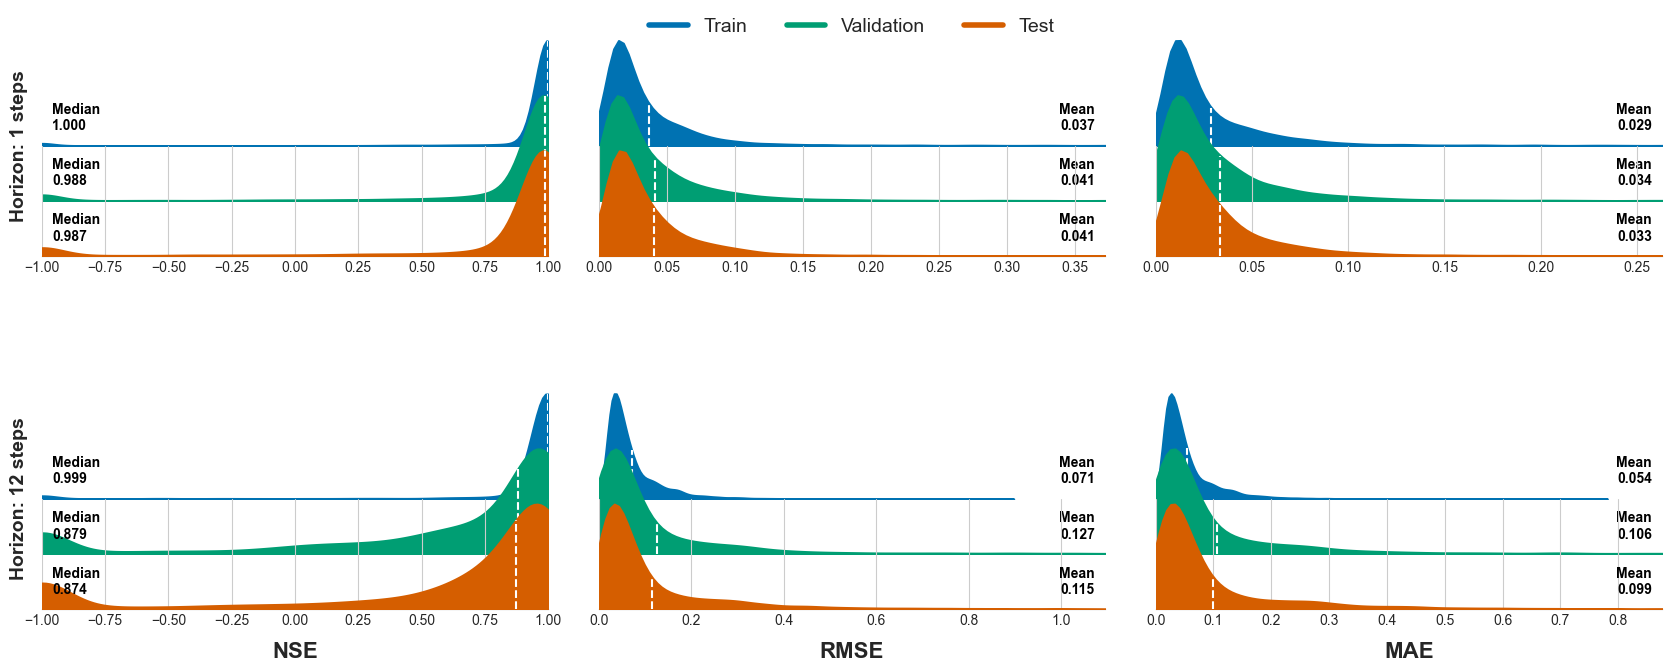

In [42]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec # <--- 新增引入
import seaborn as sns
import pandas as pd
import numpy as np
import torch
from scipy.stats import gaussian_kde # <--- 新增引入，用于计算中位线高度
from torch_geometric.loader import DataLoader
from tqdm import tqdm

# 指标计算函数 (与你的一致，无需修改)
def calculate_node_metrics(y_true, y_pred):
    """
    计算单个节点的时间序列指标
    y_true, y_pred: shape [TimeSteps]
    """
    # 1. RMSE
    rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))

    # 2. rMBE (Relative Mean Bias Error)
    mean_true = np.mean(y_true)
    if abs(mean_true) < 1e-6:
        rmbe = np.nan 
    else:
        rmbe = (np.mean(y_pred) - np.mean(y_true)) / mean_true

    # 3. NSE (Nash-Sutcliffe Efficiency)
    numerator = np.sum((y_true - y_pred) ** 2)
    denominator = np.sum((y_true - mean_true) ** 2)
    
    if denominator < 1e-6:
        nse = np.nan
    else:
        nse = 1 - (numerator / denominator)
        
    # 4. MAPE (Mean Absolute Percentage Error) <--- 关键新增
    # 避免除以零：过滤掉 y_true 接近零的点
    non_zero_mask = np.abs(y_true) > 1e-6
    if np.sum(non_zero_mask) == 0:
        mape = np.nan # 如果所有真实值都为0，则无法计算
    else:
        y_true_filt = y_true[non_zero_mask]
        y_pred_filt = y_pred[non_zero_mask]
        mape = np.mean(np.abs((y_true_filt - y_pred_filt) / y_true_filt)) * 100.0
    # 5. MAE (Mean Absolute Error) <--- 关键新增
    mae = np.mean(np.abs(y_pred - y_true))
        
    return nse, rmse, rmbe, mape, mae # <--- 关键修改：返回五个值
        
    



# ---------------------------------------------------------------------------
# 新的辅助函数：只计算一个数据集的指标
# ---------------------------------------------------------------------------
def get_metrics_for_dataset(model, data_loader, processor, device, horizons, dataset_name):
    """
    为单个数据集计算所有节点和步长的指标。
    """
    model.eval()
    
    all_preds = []
    all_actuals = []
    
    # 1. 收集数据 (不变)
    with torch.no_grad():
        for data in tqdm(data_loader, desc=f"Inference on {dataset_name}"):
            data = data.to(device)
            predictions = model.predict(data)
            all_preds.append(predictions['output'].cpu().numpy())
            all_actuals.append(data.y.cpu().numpy())
            
    preds_np = np.array(all_preds)   
    actuals_np = np.array(all_actuals)
    
    num_time, num_nodes, num_horizon = preds_np.shape

    # 2. 反归一化 (不变)
    preds_inv = np.zeros_like(preds_np)
    actuals_inv = np.zeros_like(actuals_np)
    
    for h in range(num_horizon):
        preds_slice_h = preds_np[:, :, h]
        actuals_slice_h = actuals_np[:, :, h]
        preds_inv[:, :, h] = processor.inverse_transform(preds_slice_h)
        actuals_inv[:, :, h] = processor.inverse_transform(actuals_slice_h)
    
    # 3. 计算指标
    results = []
    for h_idx in horizons:
        array_idx = h_idx - 1 
        if array_idx >= num_horizon:
            continue
            
        for node_idx in range(num_nodes):
            y_p = preds_inv[:, node_idx, array_idx]
            y_t = actuals_inv[:, node_idx, array_idx]
            
            # <--- 关键修改：捕获 mae ---
            nse, rmse, rmbe, mape, mae = calculate_node_metrics(y_t, y_p)
            
            results.append({
                'Horizon': f'Horizon: {h_idx} steps',
                'Node': node_idx,
                'NSE': nse,
                'RMSE': rmse,
                'rMBE': rmbe, 
                'MAPE': mape,
                'MAE': mae, # <--- 关键新增
                'Dataset': dataset_name
            })
            
    return pd.DataFrame(results)




def visualize_multi_dataset_metrics(model, data_loaders, processor, device, horizons=[1, 12]):
    """
    生成定制版“山脊图”。
    修改点：
    1. NSE 文字在左，RMSE 和 MAE 文字在右。
    2. 文字颜色统一为黑色。
    3. 文字背景透明。
    4. (新) Mean/Median 文字下移。
    5. (新) Horizon 侧标题垂直居中。
    """
    print("--- 开始生成多数据集（定制山脊图 - 黑色透明文字）指标分布图 ---")
    
    # --- 数据准备 ---
    all_metrics_dfs = []
    dataset_order = ["Train", "Validation", "Test"] 
    
    for dataset_name in dataset_order:
        if dataset_name in data_loaders:
            loader = data_loaders[dataset_name]
            df = get_metrics_for_dataset(model, loader, processor, device, horizons, dataset_name)
            all_metrics_dfs.append(df)
            
    if not all_metrics_dfs:
        print("没有提供任何有效的数据集。")
        return

    plot_df = pd.concat(all_metrics_dfs)
    plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna()
    plot_df['NSE'] = plot_df['NSE'].clip(lower=-1.0, upper=1.0)
    
    # --- 绘图设置 ---
    metrics_to_plot = ['NSE', 'RMSE', 'MAE'] 
    
    unique_horizons = plot_df['Horizon'].unique()
    unique_datasets = [name for name in dataset_order if name in plot_df['Dataset'].unique()]
    colors = {"Train": "#0072B2", "Validation": "#009E73", "Test": "#D55E00"} 

    n_horizons = len(unique_horizons)
    n_datasets = len(unique_datasets)
    n_metrics = len(metrics_to_plot)
    
    fig = plt.figure(figsize=(18, 2.5 * n_horizons + 2)) 
    outer_grid = gridspec.GridSpec(n_horizons, 1, figure=fig, hspace=0.6)

    for h_idx, horizon in enumerate(unique_horizons):
        inner_grid = gridspec.GridSpecFromSubplotSpec(
            n_datasets, n_metrics, 
            subplot_spec=outer_grid[h_idx],
            hspace=-0.5, # 关键：重叠
            wspace=0.1
        )
        
        horizon_subset_all = plot_df[plot_df['Horizon'] == horizon]

        for d_idx, dataset_name in enumerate(unique_datasets):
            is_last_row_in_group = (d_idx == n_datasets - 1)
            is_very_last_row_of_chart = (h_idx == n_horizons - 1) and is_last_row_in_group
            
            subset = plot_df[
                (plot_df['Horizon'] == horizon) & 
                (plot_df['Dataset'] == dataset_name)
            ]

            for m_idx, metric in enumerate(metrics_to_plot):
                ax = fig.add_subplot(inner_grid[d_idx, m_idx])
                ax.set_facecolor('none')

                if subset.empty or subset[metric].isnull().all() or len(subset[metric].dropna().values) == 0:
                    ax.axis('off')
                    continue

                data = subset[metric].dropna().values
                if len(data) == 0:
                    ax.axis('off')
                    continue
                    
                if metric == 'NSE':
                    stat_val = np.median(data)
                    stat_name = "Median"
                else:
                    stat_val = np.mean(data)
                    stat_name = "Mean"
                
                color = colors.get(dataset_name, "#333333")

                # 1. 绘制 KDE
                sns.kdeplot(
                    x=data,
                    fill=True, 
                    alpha=1.0,
                    linewidth=1.5,
                    color=color, 
                    label=dataset_name, 
                    ax=ax, 
                    zorder=5
                )
                
                # 2. 计算中位线/均值线高度
                try:
                    kde = gaussian_kde(data)
                    y_density = kde(stat_val)[0]
                except Exception:
                    y_density = ax.get_ylim()[1]

                # 3. 画线
                ax.vlines(
                    x=stat_val, 
                    ymin=0, 
                    ymax=y_density, 
                    colors='white', 
                    linestyles='--',
                    linewidth=1.5, 
                    zorder=10
                )
                
                # 4. 文字显示
                if metric == 'NSE':
                    x_pos = 0.02
                    ha_align = 'left'
                elif metric in ['RMSE', 'MAE']: 
                    x_pos = 0.98
                    ha_align = 'right'
                
                # ==================================================
                # === 修改 1：Mean/Median 文字下移 ===
                # 将 y=0.4 修改为 y=0.25 (或您希望的其他值)
                # ==================================================
                ax.text(
                    x=x_pos, y=0.25, # <--- 从 0.4 修改为 0.25
                    s=f"{stat_name}\n{stat_val:.3f}", 
                    transform=ax.transAxes, 
                    ha=ha_align, va='center',
                    fontsize=10, fontweight='bold', 
                    color='black', 
                    bbox=dict(boxstyle="round,pad=0.1", fc="none", ec="none"),
                    zorder=20
                )

                # --- 样式调整 ---
                ax.set_ylabel("")
                ax.set_yticks([])
                ax.spines['left'].set_visible(False)
                ax.spines['right'].set_visible(False)
                ax.spines['top'].set_visible(False)
                
                # X 轴范围
                if metric == 'NSE':
                    ax.set_xlim(-1.0, 1.0)
                elif metric == 'RMSE':
                    q_high_rmse = horizon_subset_all['RMSE'].quantile(0.99)
                    limit_rmse = max(q_high_rmse * 1.2, 0.1) 
                    ax.set_xlim(0, limit_rmse)
                elif metric == 'MAE':
                    q_high_mae = horizon_subset_all['MAE'].quantile(0.99)
                    limit_mae = max(q_high_mae * 1.2, 0.1) 
                    ax.set_xlim(0, limit_mae)
                
                # 坐标轴可见性
                if is_last_row_in_group:
                    ax.spines['bottom'].set_visible(True)
                    if is_very_last_row_of_chart:
                        ax.set_xlabel(metric, fontsize=16, fontweight='bold', labelpad=10)
                    else:
                        ax.set_xlabel("")
                else:
                    ax.spines['bottom'].set_visible(False)
                    ax.set_xticks([])
                    ax.set_xlabel("")

                # ==================================================
                # === 修改 2：Horizon 侧标题垂直居中 ===
                # 仅在第一列 (m_idx == 0) 和第一行 (d_idx == 0) 添加
                # 通过计算 y 坐标使其居中
                # 逻辑: 顶轴中心是 0.5。总共有 n_datasets 个轴。
                # 它们重叠了 hspace=-0.5 (即 50%)。
                # 总的中心下移了 (n_datasets - 1) * 0.5 / 2
                # ==================================================
                if m_idx == 0 and d_idx == 0:
                    # 计算y轴标签的中心位置
                    # 0.5 是顶部轴的中心
                    # (n_datasets - 1) * 0.5 是总的重叠高度
                    # 除以 2 找到中心点偏移量
                    label_y_pos = 0.5 - ((n_datasets - 1) * 0.5 / 2.0)
                    
                    ax.set_ylabel(
                        horizon, 
                        fontsize=14, 
                        fontweight='bold', 
                        labelpad=10,
                        y=label_y_pos # <--- 应用计算出的 y 坐标
                    )
                    
    # --- 图例 ---
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color=colors[name], lw=4, label=name) 
        for name in dataset_order if name in unique_datasets
    ]
    
    fig.legend(
        handles=legend_elements,
        loc='upper center',
        bbox_to_anchor=(0.5, 0.95),
        ncol=len(unique_datasets),
        fontsize=14, 
        frameon=False
    )

    plt.subplots_adjust(top=0.90, bottom=0.08, left=0.05, right=0.95)
    
    save_path = 'metrics_distribution_mae_adjusted.png'
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"调整后的山脊图已保存至: {save_path}")
    plt.show()







# 1. 确保你已经创建了 DataLoader
# (假设你已经有了 train, test, 并且可选的 val 数据集)
# (假设你的 HydroDataProcessor 实例叫做 processor)
# (假设你的模型实例叫做 trained_model)

train_loader = DataLoader(train, batch_size=1, shuffle=False)
val_loader = DataLoader(val, batch_size=1, shuffle=False)
test_loader = DataLoader(test, batch_size=1, shuffle=False)

# 2. 将它们放入一个字典
# 你可以只放你想对比的数据集
data_loaders_to_compare = {
    "Train": train_loader,
    "Validation": val_loader,
    "Test": test_loader
}

# 3. 定义你想查看的预测步长
target_horizons = [1, 12] 

# 4. 运行新的可视化函数
visualize_multi_dataset_metrics(
    model=trained_model,
    data_loaders=data_loaders_to_compare,
    processor=processor,
    device=device,
    horizons=target_horizons
)



坐标 (108, 136) 对应图节点索引: 8066
正在提取训练集数据...
正在提取验证集数据...
正在提取测试集数据...


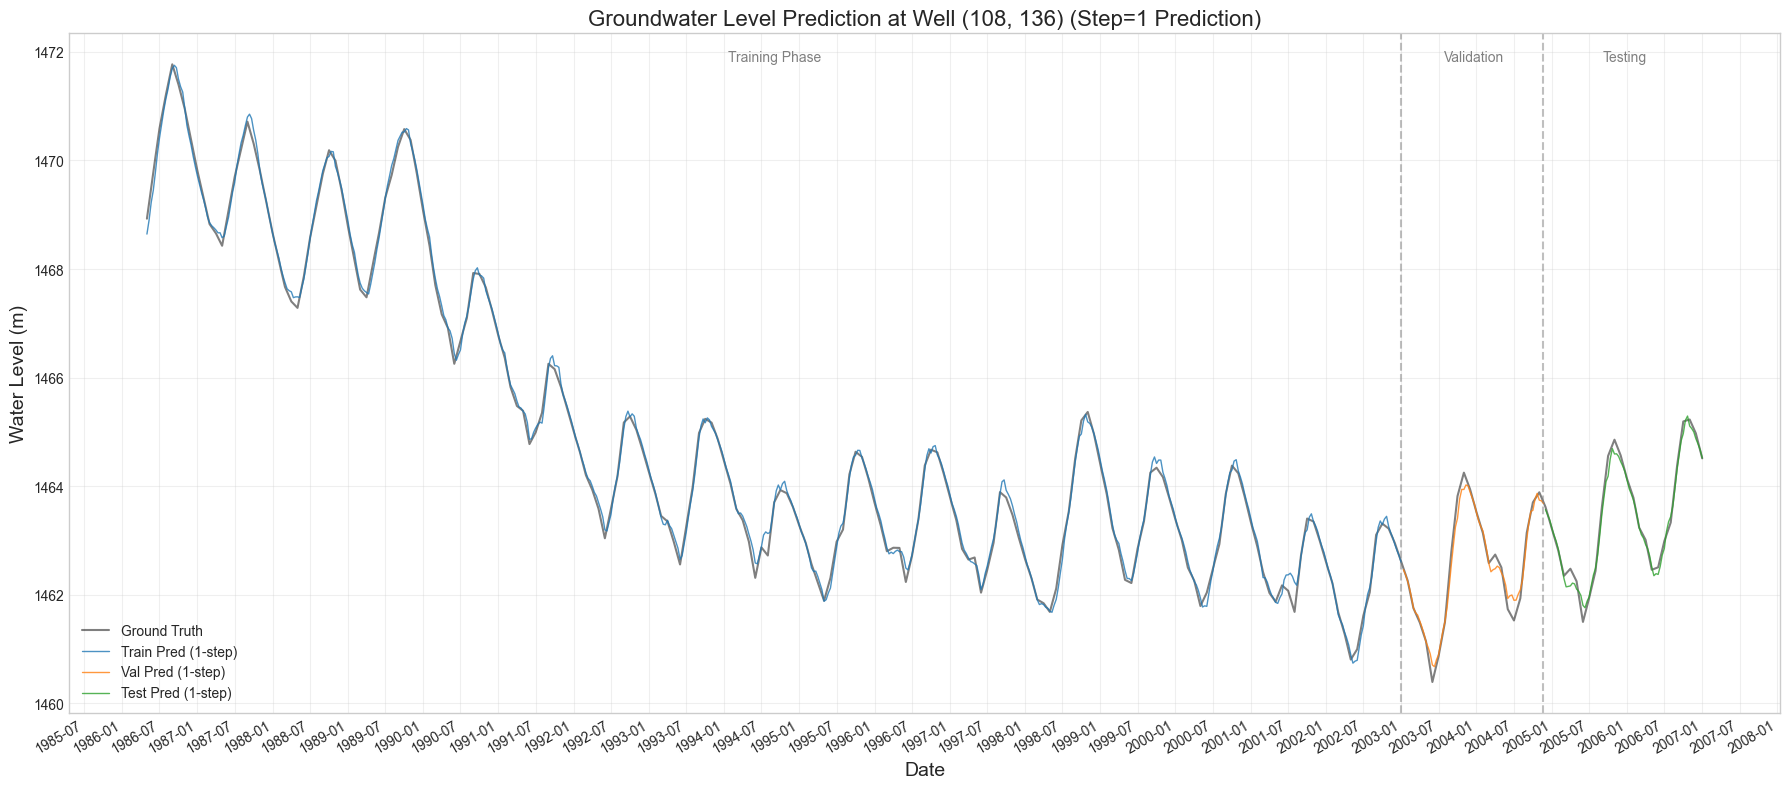


--- 单井性能评估 ---
[Train] MAE: 0.0840 | RMSE: 0.1114 | R2: 0.9983
[Val  ] MAE: 0.1146 | RMSE: 0.1578 | R2: 0.9773
[Test ] MAE: 0.0942 | RMSE: 0.1234 | R2: 0.9860


In [49]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd

def find_node_index(processor, target_row, target_col):
    """
    根据网格坐标 (row, col) 查找对应的图节点索引。
    """
    # processor.valid_coords 是一个 tuple (rows_array, cols_array)
    valid_rows = processor.valid_coords[0]
    valid_cols = processor.valid_coords[1]
    
    # 查找匹配的索引
    matches = np.where((valid_rows == target_row) & (valid_cols == target_col))[0]
    
    if len(matches) == 0:
        return None
    return matches[0]

def extract_one_step_prediction(model, dataset, node_idx, processor, device):
    """
    从数据集中提取指定节点的单步预测值（One-Step-Ahead）和真实值。
    """
    model.eval()
    preds = []
    trues = []
    dates = []
    
    with torch.no_grad():
        for data in dataset:
            data = data.to(device)
            
            # 模型预测 [num_nodes, forecast_len]
            # output_dict['output'] 是主预测结果
            out = model.predict(data)['output'] 
            
            # === 核心逻辑：Step=1 (提取预测序列的第0个索引) ===
            # data.t 是输入窗口的最后一个时间步
            # prediction[:, 0] 对应 data.t + 1 的预测
            
            # 提取指定节点的预测值 (normalized)
            pred_val = out[node_idx, 0].item()
            
            # 提取指定节点的真实值 (normalized)
            # data.y 的形状也是 [num_nodes, forecast_len]
            true_val = data.y[node_idx, 0].item()
            
            # 计算对应的日期
            # processor.dates 是完整的时间列表
            # 预测的是 t + 1 时刻
            target_time_idx = data.t + 1
            if target_time_idx < len(processor.dates):
                date = processor.dates[target_time_idx]
            else:
                date = None # 边界情况
                
            if date is not None:
                preds.append(pred_val)
                trues.append(true_val)
                dates.append(date)
                
    return dates, np.array(preds), np.array(trues)

def inverse_transform_array(processor, data_array):
    """
    辅助函数：将一维数组反归一化
    """
    # 转换为 (N, 1) 以适配 inverse_transform
    reshaped = data_array.reshape(-1, 1)
    # 反归一化
    inversed = processor.inverse_transform(reshaped)
    # 展平回一维
    return inversed.flatten()

# ==========================================
# 主执行代码
# ==========================================

# 1. 设置参数
target_coords = (108, 136)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
trained_model.to(device)

# 2. 查找节点索引
node_idx = find_node_index(processor, target_coords[0], target_coords[1])

if node_idx is None:
    print(f"错误：坐标 {target_coords} 在有效掩膜(valid_mask)之外，或者是无效数据点（NaN）。")
    print("请选择 processor.valid_coords 中的坐标。")
else:
    print(f"坐标 {target_coords} 对应图节点索引: {node_idx}")
    
    # 3. 分别提取训练、验证、测试集的数据
    print("正在提取训练集数据...")
    dates_train, preds_train_norm, trues_train_norm = extract_one_step_prediction(
        trained_model, train, node_idx, processor, device
    )
    
    print("正在提取验证集数据...")
    dates_val, preds_val_norm, trues_val_norm = extract_one_step_prediction(
        trained_model, val, node_idx, processor, device
    )
    
    print("正在提取测试集数据...")
    dates_test, preds_test_norm, trues_test_norm = extract_one_step_prediction(
        trained_model, test, node_idx, processor, device
    )
    
    # 4. 反归一化
    # 注意：我们使用真实值的反归一化作为基准。
    # 如果你的 processor.inverse_transform 是针对 target_scaler 的，可以直接用。
    preds_train_real = inverse_transform_array(processor, preds_train_norm)
    trues_train_real = inverse_transform_array(processor, trues_train_norm)
    
    preds_val_real = inverse_transform_array(processor, preds_val_norm)
    trues_val_real = inverse_transform_array(processor, trues_val_norm)
    
    preds_test_real = inverse_transform_array(processor, preds_test_norm)
    trues_test_real = inverse_transform_array(processor, trues_test_norm)
    
    # 5. 绘图
    plt.figure(figsize=(18, 8))
    
    # --- 绘制真实值 (连接起来形成一条完整的线) ---
    # 为了让线条连续，我们把日期和数值拼起来
    all_dates = dates_train + dates_val + dates_test
    all_trues = np.concatenate([trues_train_real, trues_val_real, trues_test_real])
    
    plt.plot(all_dates, all_trues, color='black', alpha=0.5, label='Ground Truth', linewidth=1.5)
    
    # --- 绘制预测值 (分段绘制以区分数据集) ---
    plt.plot(dates_train, preds_train_real, color='#1f77b4', label='Train Pred (1-step)', alpha=0.8, linewidth=1)
    plt.plot(dates_val, preds_val_real, color='#ff7f0e', label='Val Pred (1-step)', alpha=0.8, linewidth=1)
    plt.plot(dates_test, preds_test_real, color='#2ca02c', label='Test Pred (1-step)', alpha=0.8, linewidth=1)
    
    # --- 添加分割线 ---
    # 训练集结束线
    if len(dates_train) > 0:
        plt.axvline(dates_train[-1], color='gray', linestyle='--', alpha=0.5)
        plt.text(dates_train[len(dates_train)//2], np.max(all_trues), "Training Phase", ha='center', va='bottom', fontsize=10, color='gray')

    # 验证集结束线
    if len(dates_val) > 0:
        plt.axvline(dates_val[-1], color='gray', linestyle='--', alpha=0.5)
        plt.text(dates_val[len(dates_val)//2], np.max(all_trues), "Validation", ha='center', va='bottom', fontsize=10, color='gray')
        
    if len(dates_test) > 0:
        plt.text(dates_test[len(dates_test)//2], np.max(all_trues), "Testing", ha='center', va='bottom', fontsize=10, color='gray')

    # 设置图表格式
    plt.title(f'Groundwater Level Prediction at Well {target_coords} (Step=1 Prediction)', fontsize=16)
    plt.ylabel('Water Level (m)', fontsize=14)
    plt.xlabel('Date', fontsize=14)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    
    # 优化X轴日期显示
    import matplotlib.dates as mdates
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6)) # 每6个月显示一次
    plt.gcf().autofmt_xdate()
    
    plt.tight_layout()
    plt.savefig(f'well_prediction_{target_coords[0]}_{target_coords[1]}.png', dpi=300)
    plt.show()

    # 6. 计算该井的单独指标
    from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
    
    def print_metrics(phase, y_true, y_pred):
        if len(y_true) < 2: return
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        print(f"[{phase}] MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")

    print("\n--- 单井性能评估 ---")
    print_metrics("Train", trues_train_real, preds_train_real)
    print_metrics("Val  ", trues_val_real, preds_val_real)
    print_metrics("Test ", trues_test_real, preds_test_real)


In [50]:
# 定义文件名，建议包含坐标和模型名称
save_filename = f'51results_well_{target_coords[0]}_{target_coords[1]}_my_model.npz'

print(f"正在保存数据到 {save_filename} ...")

np.savez(
    save_filename,
    # --- 训练集 ---
    train_date=np.array(dates_train), # 自动保存为numpy数组
    train_true=trues_train_real,
    train_pred=preds_train_real,
    
    # --- 验证集 ---
    val_date=np.array(dates_val),
    val_true=trues_val_real,
    val_pred=preds_val_real,
    
    # --- 测试集 ---
    test_date=np.array(dates_test),
    test_true=trues_test_real,
    test_pred=preds_test_real,
    
    # --- 元数据 ---
    coords=np.array(target_coords),
    node_idx=node_idx
)

print("保存完成！")

正在保存数据到 51results_well_108_136_my_model.npz ...
保存完成！


坐标 (118, 135) 对应图节点索引: 8554
正在提取训练集数据...
正在提取验证集数据...
正在提取测试集数据...


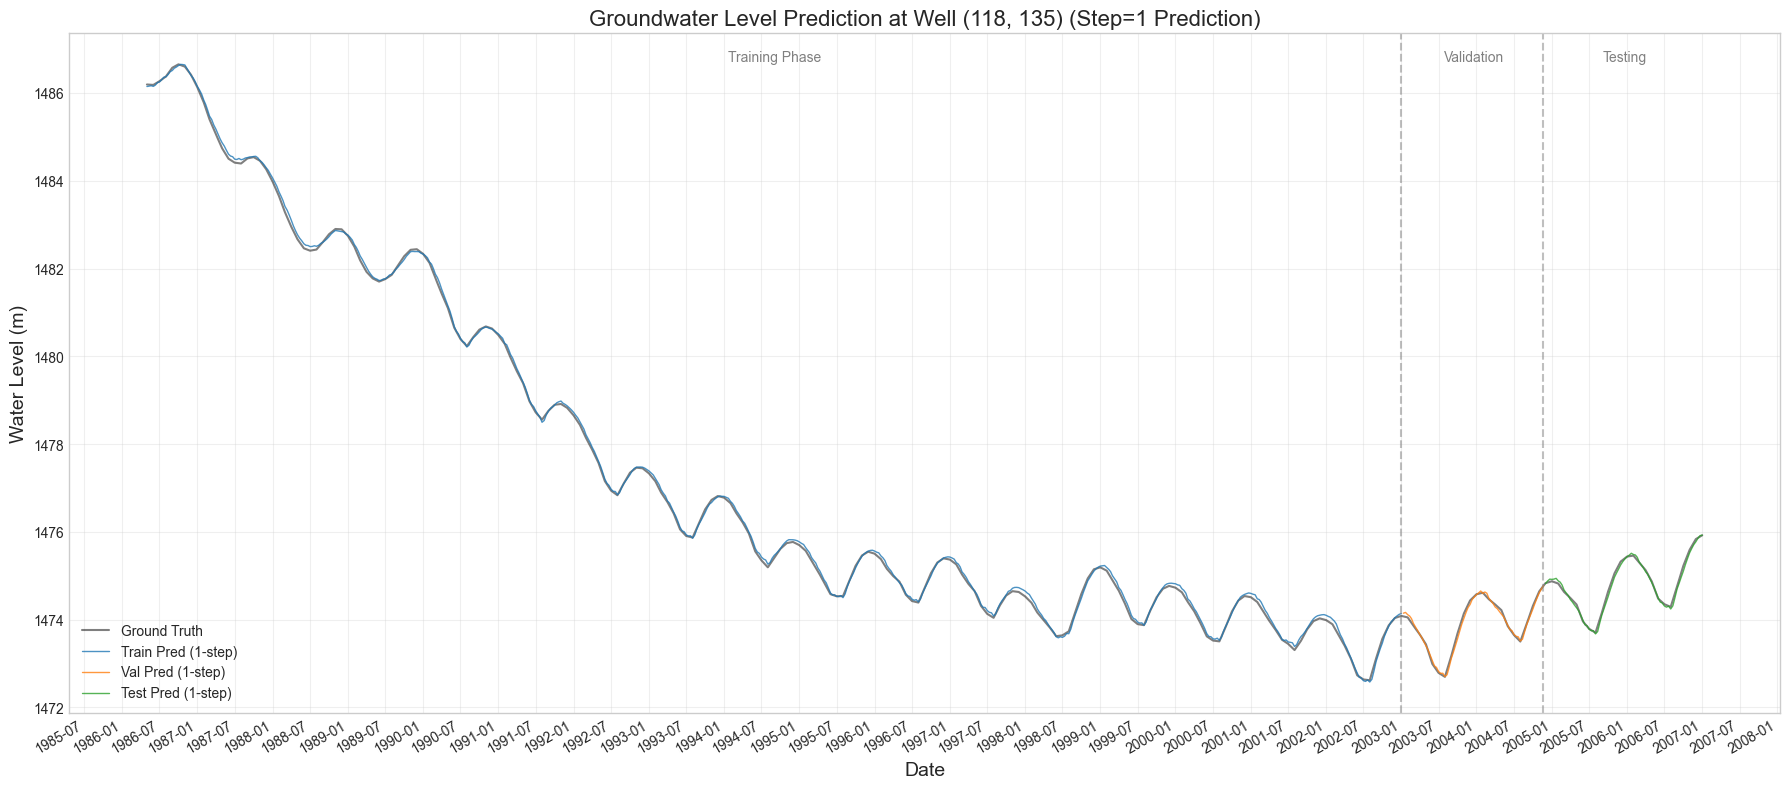


--- 单井性能评估 ---
[Train] MAE: 0.0545 | RMSE: 0.0647 | R2: 0.9997
[Val  ] MAE: 0.0482 | RMSE: 0.0584 | R2: 0.9894
[Test ] MAE: 0.0486 | RMSE: 0.0600 | R2: 0.9889


In [51]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd

def find_node_index(processor, target_row, target_col):
    """
    根据网格坐标 (row, col) 查找对应的图节点索引。
    """
    # processor.valid_coords 是一个 tuple (rows_array, cols_array)
    valid_rows = processor.valid_coords[0]
    valid_cols = processor.valid_coords[1]
    
    # 查找匹配的索引
    matches = np.where((valid_rows == target_row) & (valid_cols == target_col))[0]
    
    if len(matches) == 0:
        return None
    return matches[0]

def extract_one_step_prediction(model, dataset, node_idx, processor, device):
    """
    从数据集中提取指定节点的单步预测值（One-Step-Ahead）和真实值。
    """
    model.eval()
    preds = []
    trues = []
    dates = []
    
    with torch.no_grad():
        for data in dataset:
            data = data.to(device)
            
            # 模型预测 [num_nodes, forecast_len]
            # output_dict['output'] 是主预测结果
            out = model.predict(data)['output'] 
            
            # === 核心逻辑：Step=1 (提取预测序列的第0个索引) ===
            # data.t 是输入窗口的最后一个时间步
            # prediction[:, 0] 对应 data.t + 1 的预测
            
            # 提取指定节点的预测值 (normalized)
            pred_val = out[node_idx, 0].item()
            
            # 提取指定节点的真实值 (normalized)
            # data.y 的形状也是 [num_nodes, forecast_len]
            true_val = data.y[node_idx, 0].item()
            
            # 计算对应的日期
            # processor.dates 是完整的时间列表
            # 预测的是 t + 1 时刻
            target_time_idx = data.t + 1
            if target_time_idx < len(processor.dates):
                date = processor.dates[target_time_idx]
            else:
                date = None # 边界情况
                
            if date is not None:
                preds.append(pred_val)
                trues.append(true_val)
                dates.append(date)
                
    return dates, np.array(preds), np.array(trues)

def inverse_transform_array(processor, data_array):
    """
    辅助函数：将一维数组反归一化
    """
    # 转换为 (N, 1) 以适配 inverse_transform
    reshaped = data_array.reshape(-1, 1)
    # 反归一化
    inversed = processor.inverse_transform(reshaped)
    # 展平回一维
    return inversed.flatten()

# ==========================================
# 主执行代码
# ==========================================

# 1. 设置参数
target_coords = (118, 135)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
trained_model.to(device)

# 2. 查找节点索引
node_idx = find_node_index(processor, target_coords[0], target_coords[1])

if node_idx is None:
    print(f"错误：坐标 {target_coords} 在有效掩膜(valid_mask)之外，或者是无效数据点（NaN）。")
    print("请选择 processor.valid_coords 中的坐标。")
else:
    print(f"坐标 {target_coords} 对应图节点索引: {node_idx}")
    
    # 3. 分别提取训练、验证、测试集的数据
    print("正在提取训练集数据...")
    dates_train, preds_train_norm, trues_train_norm = extract_one_step_prediction(
        trained_model, train, node_idx, processor, device
    )
    
    print("正在提取验证集数据...")
    dates_val, preds_val_norm, trues_val_norm = extract_one_step_prediction(
        trained_model, val, node_idx, processor, device
    )
    
    print("正在提取测试集数据...")
    dates_test, preds_test_norm, trues_test_norm = extract_one_step_prediction(
        trained_model, test, node_idx, processor, device
    )
    
    # 4. 反归一化
    # 注意：我们使用真实值的反归一化作为基准。
    # 如果你的 processor.inverse_transform 是针对 target_scaler 的，可以直接用。
    preds_train_real = inverse_transform_array(processor, preds_train_norm)
    trues_train_real = inverse_transform_array(processor, trues_train_norm)
    
    preds_val_real = inverse_transform_array(processor, preds_val_norm)
    trues_val_real = inverse_transform_array(processor, trues_val_norm)
    
    preds_test_real = inverse_transform_array(processor, preds_test_norm)
    trues_test_real = inverse_transform_array(processor, trues_test_norm)
    
    # 5. 绘图
    plt.figure(figsize=(18, 8))
    
    # --- 绘制真实值 (连接起来形成一条完整的线) ---
    # 为了让线条连续，我们把日期和数值拼起来
    all_dates = dates_train + dates_val + dates_test
    all_trues = np.concatenate([trues_train_real, trues_val_real, trues_test_real])
    
    plt.plot(all_dates, all_trues, color='black', alpha=0.5, label='Ground Truth', linewidth=1.5)
    
    # --- 绘制预测值 (分段绘制以区分数据集) ---
    plt.plot(dates_train, preds_train_real, color='#1f77b4', label='Train Pred (1-step)', alpha=0.8, linewidth=1)
    plt.plot(dates_val, preds_val_real, color='#ff7f0e', label='Val Pred (1-step)', alpha=0.8, linewidth=1)
    plt.plot(dates_test, preds_test_real, color='#2ca02c', label='Test Pred (1-step)', alpha=0.8, linewidth=1)
    
    # --- 添加分割线 ---
    # 训练集结束线
    if len(dates_train) > 0:
        plt.axvline(dates_train[-1], color='gray', linestyle='--', alpha=0.5)
        plt.text(dates_train[len(dates_train)//2], np.max(all_trues), "Training Phase", ha='center', va='bottom', fontsize=10, color='gray')

    # 验证集结束线
    if len(dates_val) > 0:
        plt.axvline(dates_val[-1], color='gray', linestyle='--', alpha=0.5)
        plt.text(dates_val[len(dates_val)//2], np.max(all_trues), "Validation", ha='center', va='bottom', fontsize=10, color='gray')
        
    if len(dates_test) > 0:
        plt.text(dates_test[len(dates_test)//2], np.max(all_trues), "Testing", ha='center', va='bottom', fontsize=10, color='gray')

    # 设置图表格式
    plt.title(f'Groundwater Level Prediction at Well {target_coords} (Step=1 Prediction)', fontsize=16)
    plt.ylabel('Water Level (m)', fontsize=14)
    plt.xlabel('Date', fontsize=14)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    
    # 优化X轴日期显示
    import matplotlib.dates as mdates
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6)) # 每6个月显示一次
    plt.gcf().autofmt_xdate()
    
    plt.tight_layout()
    plt.savefig(f'well_prediction_{target_coords[0]}_{target_coords[1]}.png', dpi=300)
    plt.show()

    # 6. 计算该井的单独指标
    from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
    
    def print_metrics(phase, y_true, y_pred):
        if len(y_true) < 2: return
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        print(f"[{phase}] MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")

    print("\n--- 单井性能评估 ---")
    print_metrics("Train", trues_train_real, preds_train_real)
    print_metrics("Val  ", trues_val_real, preds_val_real)
    print_metrics("Test ", trues_test_real, preds_test_real)


In [52]:
# 定义文件名，建议包含坐标和模型名称
save_filename = f'51results_well_{target_coords[0]}_{target_coords[1]}_my_model.npz'

print(f"正在保存数据到 {save_filename} ...")

np.savez(
    save_filename,
    # --- 训练集 ---
    train_date=np.array(dates_train), # 自动保存为numpy数组
    train_true=trues_train_real,
    train_pred=preds_train_real,
    
    # --- 验证集 ---
    val_date=np.array(dates_val),
    val_true=trues_val_real,
    val_pred=preds_val_real,
    
    # --- 测试集 ---
    test_date=np.array(dates_test),
    test_true=trues_test_real,
    test_pred=preds_test_real,
    
    # --- 元数据 ---
    coords=np.array(target_coords),
    node_idx=node_idx
)

print("保存完成！")

正在保存数据到 51results_well_118_135_my_model.npz ...
保存完成！


坐标 (104, 161) 对应图节点索引: 7883
正在提取训练集数据...
正在提取验证集数据...
正在提取测试集数据...


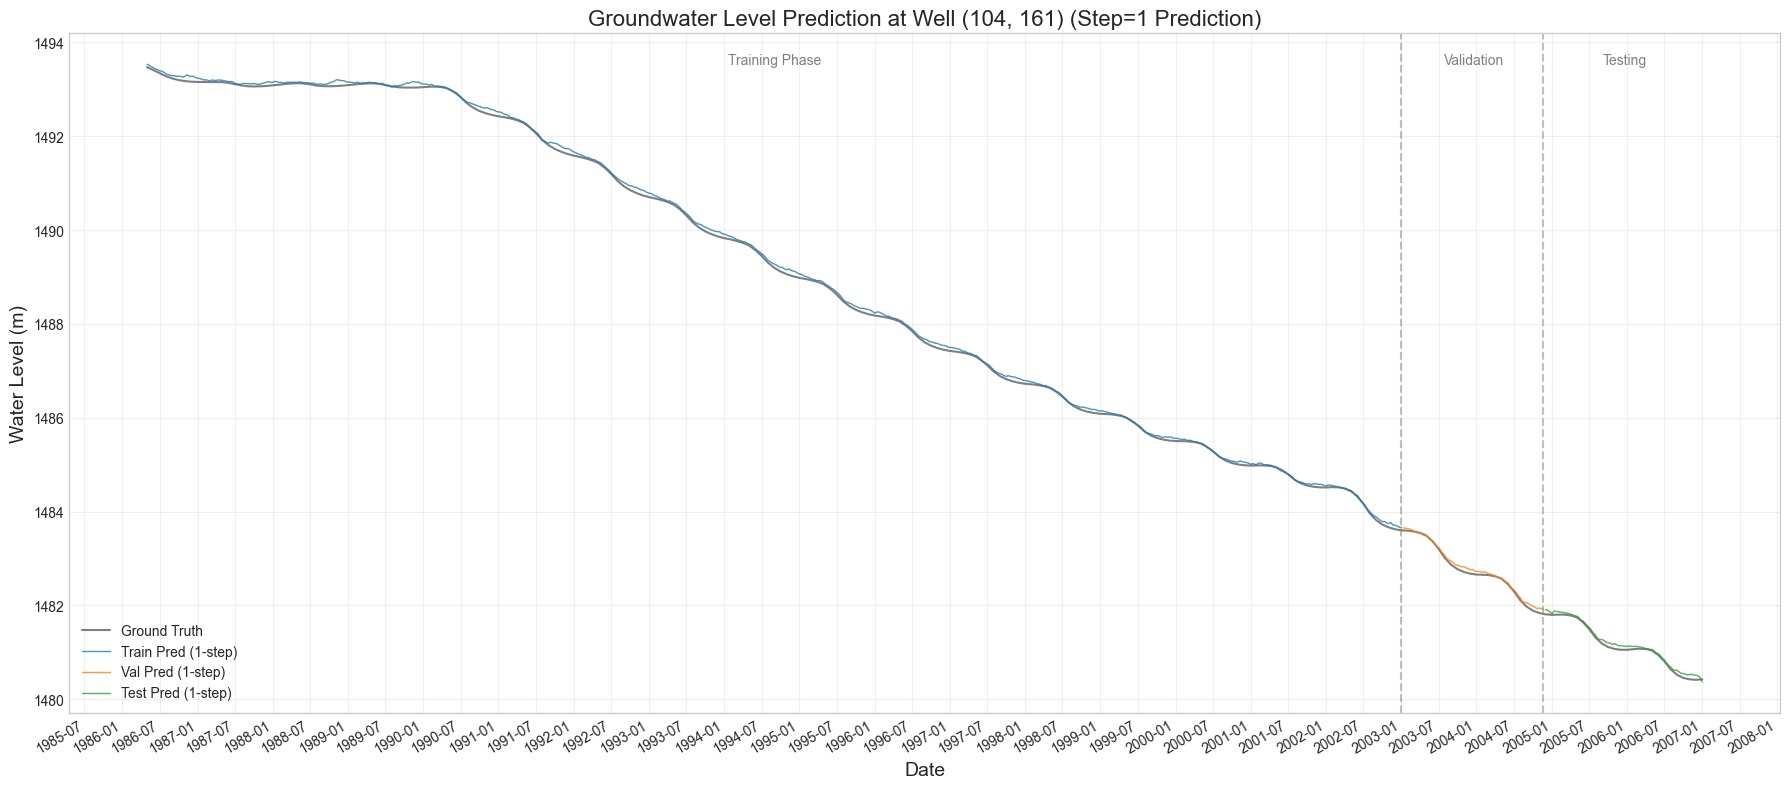


--- 单井性能评估 ---
[Train] MAE: 0.0483 | RMSE: 0.0578 | R2: 0.9997
[Val  ] MAE: 0.0474 | RMSE: 0.0580 | R2: 0.9886
[Test ] MAE: 0.0551 | RMSE: 0.0624 | R2: 0.9819


In [53]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd

def find_node_index(processor, target_row, target_col):
    """
    根据网格坐标 (row, col) 查找对应的图节点索引。
    """
    # processor.valid_coords 是一个 tuple (rows_array, cols_array)
    valid_rows = processor.valid_coords[0]
    valid_cols = processor.valid_coords[1]
    
    # 查找匹配的索引
    matches = np.where((valid_rows == target_row) & (valid_cols == target_col))[0]
    
    if len(matches) == 0:
        return None
    return matches[0]

def extract_one_step_prediction(model, dataset, node_idx, processor, device):
    """
    从数据集中提取指定节点的单步预测值（One-Step-Ahead）和真实值。
    """
    model.eval()
    preds = []
    trues = []
    dates = []
    
    with torch.no_grad():
        for data in dataset:
            data = data.to(device)
            
            # 模型预测 [num_nodes, forecast_len]
            # output_dict['output'] 是主预测结果
            out = model.predict(data)['output'] 
            
            # === 核心逻辑：Step=1 (提取预测序列的第0个索引) ===
            # data.t 是输入窗口的最后一个时间步
            # prediction[:, 0] 对应 data.t + 1 的预测
            
            # 提取指定节点的预测值 (normalized)
            pred_val = out[node_idx, 0].item()
            
            # 提取指定节点的真实值 (normalized)
            # data.y 的形状也是 [num_nodes, forecast_len]
            true_val = data.y[node_idx, 0].item()
            
            # 计算对应的日期
            # processor.dates 是完整的时间列表
            # 预测的是 t + 1 时刻
            target_time_idx = data.t + 1
            if target_time_idx < len(processor.dates):
                date = processor.dates[target_time_idx]
            else:
                date = None # 边界情况
                
            if date is not None:
                preds.append(pred_val)
                trues.append(true_val)
                dates.append(date)
                
    return dates, np.array(preds), np.array(trues)

def inverse_transform_array(processor, data_array):
    """
    辅助函数：将一维数组反归一化
    """
    # 转换为 (N, 1) 以适配 inverse_transform
    reshaped = data_array.reshape(-1, 1)
    # 反归一化
    inversed = processor.inverse_transform(reshaped)
    # 展平回一维
    return inversed.flatten()

# ==========================================
# 主执行代码
# ==========================================

# 1. 设置参数
target_coords = (104, 161)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
trained_model.to(device)

# 2. 查找节点索引
node_idx = find_node_index(processor, target_coords[0], target_coords[1])

if node_idx is None:
    print(f"错误：坐标 {target_coords} 在有效掩膜(valid_mask)之外，或者是无效数据点（NaN）。")
    print("请选择 processor.valid_coords 中的坐标。")
else:
    print(f"坐标 {target_coords} 对应图节点索引: {node_idx}")
    
    # 3. 分别提取训练、验证、测试集的数据
    print("正在提取训练集数据...")
    dates_train, preds_train_norm, trues_train_norm = extract_one_step_prediction(
        trained_model, train, node_idx, processor, device
    )
    
    print("正在提取验证集数据...")
    dates_val, preds_val_norm, trues_val_norm = extract_one_step_prediction(
        trained_model, val, node_idx, processor, device
    )
    
    print("正在提取测试集数据...")
    dates_test, preds_test_norm, trues_test_norm = extract_one_step_prediction(
        trained_model, test, node_idx, processor, device
    )
    
    # 4. 反归一化
    # 注意：我们使用真实值的反归一化作为基准。
    # 如果你的 processor.inverse_transform 是针对 target_scaler 的，可以直接用。
    preds_train_real = inverse_transform_array(processor, preds_train_norm)
    trues_train_real = inverse_transform_array(processor, trues_train_norm)
    
    preds_val_real = inverse_transform_array(processor, preds_val_norm)
    trues_val_real = inverse_transform_array(processor, trues_val_norm)
    
    preds_test_real = inverse_transform_array(processor, preds_test_norm)
    trues_test_real = inverse_transform_array(processor, trues_test_norm)
    
    # 5. 绘图
    plt.figure(figsize=(18, 8))
    
    # --- 绘制真实值 (连接起来形成一条完整的线) ---
    # 为了让线条连续，我们把日期和数值拼起来
    all_dates = dates_train + dates_val + dates_test
    all_trues = np.concatenate([trues_train_real, trues_val_real, trues_test_real])
    
    plt.plot(all_dates, all_trues, color='black', alpha=0.5, label='Ground Truth', linewidth=1.5)
    
    # --- 绘制预测值 (分段绘制以区分数据集) ---
    plt.plot(dates_train, preds_train_real, color='#1f77b4', label='Train Pred (1-step)', alpha=0.8, linewidth=1)
    plt.plot(dates_val, preds_val_real, color='#ff7f0e', label='Val Pred (1-step)', alpha=0.8, linewidth=1)
    plt.plot(dates_test, preds_test_real, color='#2ca02c', label='Test Pred (1-step)', alpha=0.8, linewidth=1)
    
    # --- 添加分割线 ---
    # 训练集结束线
    if len(dates_train) > 0:
        plt.axvline(dates_train[-1], color='gray', linestyle='--', alpha=0.5)
        plt.text(dates_train[len(dates_train)//2], np.max(all_trues), "Training Phase", ha='center', va='bottom', fontsize=10, color='gray')

    # 验证集结束线
    if len(dates_val) > 0:
        plt.axvline(dates_val[-1], color='gray', linestyle='--', alpha=0.5)
        plt.text(dates_val[len(dates_val)//2], np.max(all_trues), "Validation", ha='center', va='bottom', fontsize=10, color='gray')
        
    if len(dates_test) > 0:
        plt.text(dates_test[len(dates_test)//2], np.max(all_trues), "Testing", ha='center', va='bottom', fontsize=10, color='gray')

    # 设置图表格式
    plt.title(f'Groundwater Level Prediction at Well {target_coords} (Step=1 Prediction)', fontsize=16)
    plt.ylabel('Water Level (m)', fontsize=14)
    plt.xlabel('Date', fontsize=14)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    
    # 优化X轴日期显示
    import matplotlib.dates as mdates
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=6)) # 每6个月显示一次
    plt.gcf().autofmt_xdate()
    
    plt.tight_layout()
    plt.savefig(f'well_prediction_{target_coords[0]}_{target_coords[1]}.png', dpi=300)
    plt.show()

    # 6. 计算该井的单独指标
    from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
    
    def print_metrics(phase, y_true, y_pred):
        if len(y_true) < 2: return
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        print(f"[{phase}] MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")

    print("\n--- 单井性能评估 ---")
    print_metrics("Train", trues_train_real, preds_train_real)
    print_metrics("Val  ", trues_val_real, preds_val_real)
    print_metrics("Test ", trues_test_real, preds_test_real)


In [54]:
# 定义文件名，建议包含坐标和模型名称
save_filename = f'51results_well_{target_coords[0]}_{target_coords[1]}_my_model.npz'

print(f"正在保存数据到 {save_filename} ...")

np.savez(
    save_filename,
    # --- 训练集 ---
    train_date=np.array(dates_train), # 自动保存为numpy数组
    train_true=trues_train_real,
    train_pred=preds_train_real,
    
    # --- 验证集 ---
    val_date=np.array(dates_val),
    val_true=trues_val_real,
    val_pred=preds_val_real,
    
    # --- 测试集 ---
    test_date=np.array(dates_test),
    test_true=trues_test_real,
    test_pred=preds_test_real,
    
    # --- 元数据 ---
    coords=np.array(target_coords),
    node_idx=node_idx
)

print("保存完成！")

正在保存数据到 51results_well_104_161_my_model.npz ...
保存完成！
